# Final 2D Bubble Notebook

## Introduction

This notebook carries out the **one-dimensional (1D) analysis** of the critical bubble and related observables for vacuum decay at finite charge/density. The workflow is:

1. **Setup and parameters** — Set the project path and model parameters (potential $V(\phi)$, chemical potential $\omega$, spatial dimension $d=3$ for the O(3)-symmetric bounce).
2. **Imports** — Load `Bubble_finder` (potential, bounce solver, observables) and plotting.
3. **Conventions** — Reference for charge $Q$, energy $E$, and densities $\rho_Q = Q/V$, $\rho_E = E/V$ (volume $V = \frac{4}{3}\pi r_{\max}^3$).
4. **Section 1: One-dimensional critical bubble** — Compute the O(3) bounce profile $\phi(r)$ at fixed $\omega$, then charge/energy and densities for the homogeneous configuration and for the bubble; finally the $\omega=0$ (zero-charge) bounce for both O(3) and O(4).

Each code cell is preceded by a short explanation of what it does. All formulas use the same conventions as `Bubble_finder` (e.g. $\Omega(\phi) = V(\phi) - \omega^2\phi^2$, energy with optional background subtraction).

### Project path and parameters

The next cell sets the project root (so that `Bubble_finder` and `Q_ball_finder` can be imported) and the model parameters: $\phi_0$, $V_1$, $V_2$ (false/true vacua of $V$), and $\omega$ (chemical potential).

In [1]:
# ============================================================================
# Project path and configuration
# ============================================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Model parameters (same potential as in the 4D bounce notebook)
PHI0 = 1.999   # field value near the center of the bounce
V1 = 1.0       # false vacuum
V2 = 2.0       # true vacuum
OMEGA = 0.85    # chemical potential ω (can be changed)

print(f"Project root: {PROJECT_ROOT}")
print(f"Potential: false vacuum at φ={V1}, true vacuum at φ={V2}")
print(f"φ0 = {PHI0},  ω = {OMEGA}")

Project root: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX
Potential: false vacuum at φ=1.0, true vacuum at φ=2.0
φ0 = 1.999,  ω = 0.85


### Which energy are we plotting?

- **E_M (Minkowski energy)** — Physical, conserved: use for microcanonical comparison (same Q, compare energies). Code: `compute_energy_minkowski_tau0_ghost_2d` (2D), `compute_energy_minkowski_1d_spherical` (1D).
- **F_ω (grand-canonical functional)** — F_ω = E_M − ω Q; relevant at fixed ω. Use for fixed-ω barrier / branch. Code: `compute_Fomega_1d_spherical` (1D), `compute_Fomega_tau0_ghost_2d` (2D). Do **not** label F_ω as "energy" in physical comparisons.
- **H_E (Euclidean)** — Used in Newton residuals; do **not** use for physical energy (wrong sign structure). Code: `compute_HE_euclidean_tau0_ghost_2d`. Legacy `compute_energy_tau0_ghost_2d` returns H_E (deprecated).

The observables dict from `compute_observables_tau0_ghost` contains `E` (= H_E), `E_M`, and `E_M_hom`. Use **E_M** for physical energy; use **E**/E_hom only as a Newton diagnostic.

**Why “same Q but higher energy” was misleading.** Comparisons that showed a bubble having the same charge as the homogeneous configuration but a different “energy” were partly due to mixing quantities: (i) **E_M** (Minkowski energy) is the conserved physical energy; (ii) **F_ω** = E_M − ω Q is the grand-canonical functional (what the 1D scan and many plots report as “E” or “ρ_E”); (iii) **H_E** is the Euclidean Hamiltonian-like density used in the Newton residual. If one compared F_ω or H_E between bubble and homogeneous instead of E_M, the sign and magnitude differ from the true microcanonical energy difference. For a meaningful “same Q, compare energies” use **E_M** (and ΔE_M = E_M − E_M,hom).

### Imports

This cell imports NumPy, Matplotlib, and the `Bubble_finder` modules (potential, 1D bounce solver, 2D solver, ansatz utilities). It also builds the potential $U(\rho)=V(\phi)$ for the 2D solver and sets LaTeX rendering for plots.

In [2]:
# ============================================================================
# Imports
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from Q_ball_finder.grid import build_grid, RadialTimeGrid

from Bubble_finder.potential_bubble import (
    V_phi, dV_dphi, d2V_dphi2, Omega_phi, dOmega_dphi, d2Omega_dphi2, vacua_of_Omega,
)
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, make_potential_from_V, solve_rho0_for_omega
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.ansatz_bubble import (
    AnsatzParams, build_seed_bubble, compute_negative_mode_1d, compute_Dp_shooting_1d, bc_projector_y,
    make_q_ball_objects, make_bubble_profile_1d_from_solve_bounce, PotentialModel,
)
from Bubble_finder.ansatz_bubble import select_best_seed

# Potential U(ρ)=V(φ) for the 2D solver (requires PHI0, V1, V2 from previous cell)
U, dU, d2U = make_potential_from_V(V_phi, dV_dphi, d2V_dphi2, phi0=PHI0, v1=V1, v2=V2)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})
plt.rcParams["figure.figsize"] = (7, 4.8)

# Cartella per salvare i plot (creata se non esiste)
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

print("Imports completed.")

Imports completed.


## Conventions and Observables (reference)

Reference for the conventions and observables used in the rest of the notebook. All formulas are consistent with the code in `Bubble_finder.observables_2d` and with the 2D solver.

**Twisted boundary conditions.** Half-box $\tau \in [-\beta/2,\, 0]$ with twist closure at $\tau = -\beta/2$. **Rotated frame**: $y = r(\varphi_{\mathrm{rot}} - \rho_0)$, $\bar y = r(\bar\varphi_{\mathrm{rot}} - \rho_0)$; homogeneous background $y = \bar y = 0$.

**Charge $Q$ and density $q(r)$.** We use the same convention as the 1D code:
$$
q(\tau,r) = \frac{1}{2}\,\mathrm{Re}\bigl(\bar\varphi\,\partial_\tau\varphi - \varphi\,\partial_\tau\bar\varphi\bigr)\,, \qquad Q(\tau) = 4\pi\int_0^{r_{\max}}\!\! r^2\, q(\tau,r)\,\mathrm{d}r\,.
$$
At $\tau=0$ the solver has no grid point; we use **ghost reconstruction**: values just above and below $\tau=0$ are defined by the twist ($y_+ = \bar y|_0$, $y_- = y|_0$, etc.), then we form the midpoint and a central $\tau$-derivative. So **ground-truth** $Q$ and $E$ are those at $\tau=0$ from this ghost procedure (`compute_charge_tau0_ghost_2d`, `compute_energy_tau0_ghost_2d`). Optional background subtraction for charge only: $Q \to Q - Q_{\mathrm{hom}}$ with $Q_{\mathrm{hom}} = 4\pi\,\omega\,\rho_0^2\,r_{\max}^3/3$.

**Energy $E$ (canonical, no background subtraction).** $H_E = (\partial_\tau\varphi)(\partial_\tau\bar\varphi) - (\partial_r\varphi)(\partial_r\bar\varphi) - V(\varphi\bar\varphi)$; $E(\tau) = 4\pi\int_0^{r_{\max}}\!\! r^2\, H_E\,\mathrm{d}r$ at $\tau=0$ (ghost procedure, stored as `sol.E_tau0`). Homogeneous: $E_{\mathrm{hom}} = V_{\mathrm{space}}\,(-\omega^2\rho_0^2 - V(\rho_0^2))$; use ratio $E/E_{\mathrm{hom}}$ (`homogeneous_energy_2d` or targets).

**Why $\omega\cdot Q$ is not the energy.** For a homogeneous Q-ball, $E$ and $Q$ are related by the thermodynamic identity, but for an inhomogeneous configuration (e.g. the bubble) $E$ is given by the integral above; $\omega\cdot Q \neq E$. So we never set $E_{\mathrm{target}} = \omega\cdot Q_{\mathrm{target}}$.

**Densities and targets.** Volume $V = \frac{4}{3}\pi\,L_r^3$ with $L_r = r_{\max}$. Charge density $\rho_Q = Q/V$, energy density $\rho_E = E/V$. **Targets** ($Q_{\mathrm{target}}$, $E_{\mathrm{target}}$, $\rho_{Q,\mathrm{target}}$, $\rho_{E,\mathrm{target}}$) are computed by applying the *same* $\tau=0$ ghost observables to the homogeneous configuration ($y = \bar y = 0$) on the same grid (`compute_targets_tau0_ghost`). Use them for ratios $Q/Q_{\mathrm{target}}$, $E/E_{\mathrm{target}}$ in scans.

## 1. One-dimensional critical bubble

In this section we compute the **O(3)-symmetric one-dimensional critical bubble** $\phi_{\mathrm{cb}}(r)$ at fixed chemical potential $\omega$.

The radial equation for the bounce profile in $d$ spatial dimensions is
$$
\phi''(r) + \frac{d-1}{r}\,\phi'(r) = \frac{\partial \Omega(\phi)}{\partial \phi} \, ,
$$
with $d = 3$ and grand potential $\Omega(\phi) = V(\phi) - \omega^2 \phi^2$, so that $\partial\Omega/\partial\phi = V'(\phi) - 2\omega^2\phi$. The **energy** of a 1D profile is
$$
E[\phi] = 4\pi \int_0^{\infty} \mathrm{d}r\, r^2\left[\tfrac12 (\partial_r \phi)^2 + \Omega(\phi)\right] \,.
$$

We impose:
- regularity at the origin, $\phi'(0) = 0$, so that the solution is smooth at $r = 0$;
- approach to the false vacuum as $r \to \infty$, $\phi(r) \to \phi_\text{false}$.

We use a simple **overshoot/undershoot** algorithm with bisection in the initial value $\phi(0)$ to find the bounce profile $\{ r_{\mathrm{cb}},\, \phi_{\mathrm{cb}}(r) \}$, which will later be used as input for the 2D construction.

**Implementation:** we use `solve_bounce` from `Bubble_finder.bounce_1d`; the output arrays `r_bounce` and `phi_bounce` (or equivalents) define the radial profile of the 1D critical bubble.


**Parameters and grand potential.** This cell sets the 1D bounce parameters (radial grid, tolerance), finds the two vacua of $\Omega(\phi) = V(\phi) - \omega^2\phi^2$, and plots $\Omega(\phi)$.

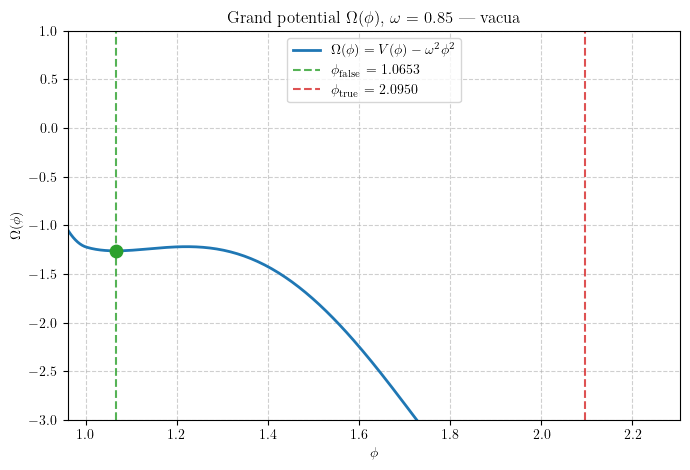

In [3]:
# ============================================================================
# 1D Bounce: parameters, vacua (grid), plot Ω(φ), solve (solve_bounce from bounce_1d)
# ============================================================================

# Parameters
PHI0_BOUNCE = PHI0
V1_BOUNCE = V1
V2_BOUNCE = V2
OMEGA_BOUNCE = OMEGA
D = 3
R0 = 1e-11
RMAX = 10.0
MAX_ITER = 100
VERBOSE = True

# Find vacua of Ω(φ) = V(φ) - ω²φ² using efficient grid method (two grids, then assign false/true by Ω)
phi_grid1 = np.linspace(max(0.5, V1_BOUNCE - 0.2), min(V2_BOUNCE - 0.1, V1_BOUNCE + 0.2), 500)
phi_grid2 = np.linspace(max(V1_BOUNCE + 0.1, V2_BOUNCE - 0.2), V2_BOUNCE+0.2, 500)
Omega_grid1 = np.array([Omega_phi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for phi in phi_grid1])
Omega_grid2 = np.array([Omega_phi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for phi in phi_grid2])
idx_min1 = np.argmin(Omega_grid1)
idx_min2 = np.argmin(Omega_grid2)
phi_near_v1 = phi_grid1[idx_min1]
phi_near_v2 = phi_grid2[idx_min2]
Omega_near_v1 = Omega_phi(phi_near_v1, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE)
Omega_near_v2 = Omega_phi(phi_near_v2, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE)
if Omega_near_v1 > Omega_near_v2:
    phi_false_grid, phi_true_grid = phi_near_v1, phi_near_v2
    Omega_false_grid, Omega_true_grid = Omega_near_v1, Omega_near_v2
else:
    phi_false_grid, phi_true_grid = phi_near_v2, phi_near_v1
    Omega_false_grid, Omega_true_grid = Omega_near_v2, Omega_near_v1

# Plot Ω(φ) and mark the two minima to verify they correspond to the vacua
# Free range: no clipping; extend below v1 and especially above v2
phi_plot = np.linspace(0.5, 3.0, 500)
Omega_plot = np.array([Omega_phi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for phi in phi_plot])
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(phi_plot, Omega_plot, lw=2, color="C0", label=r"$\Omega(\phi) = V(\phi) - \omega^2\phi^2$")
ax.axvline(phi_false_grid, color="C2", ls="--", lw=1.5, label=rf"$\phi_{{\mathrm{{false}}}}$ = {phi_false_grid:.4f}", alpha=0.8)
ax.axvline(phi_true_grid, color="C3", ls="--", lw=1.5, label=rf"$\phi_{{\mathrm{{true}}}}$ = {phi_true_grid:.4f}", alpha=0.8)
ax.scatter([phi_false_grid], [Omega_false_grid], color="C2", s=80, zorder=5)
ax.scatter([phi_true_grid], [Omega_true_grid], color="C3", s=80, zorder=5)
ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"$\Omega(\phi)$")
ax.set_xlim(phi_false_grid*0.9, phi_true_grid*1.1)
ax.set_ylim(-3, 1.0)
ax.set_title(rf"Grand potential $\Omega(\phi)$, $\omega$ = {OMEGA_BOUNCE:.2f} — vacua")
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "omega_vacua.png", dpi=150, bbox_inches="tight")
plt.show()

**Solve and plot.** This cell computes the thin-wall analytical action $S_0$, calls `solve_bounce` for the O(3) bounce at the chosen $\omega$, and plots the bounce profile $\phi(r)$.

Solving O(3) bounce solution...
Parameters: φ₀=1.999, v1=1.0, v2=2.0, ω=0.85
Analytical action (d=4, Q=0): S₀ = 80.590466
[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
Vacua of Ω: phi_false=1.0650387758, phi_true=2.0946557467
  Iteration 0: Overshoot, φ(0)=1.579847, φ(∞)=1.065039, r_stop=0.5260


  Iteration 10: Overshoot, φ(0)=1.307863, φ(∞)=1.065039, r_stop=1.7757
  Iteration 20: Overshoot, φ(0)=1.307702, φ(∞)=1.065039, r_stop=2.9331
  Converged after 27 iterations: φ(0)=1.307702, φ(∞)=1.065067, φ'(∞)=6.776e-20

Bounce solution found:
  φ(0) = 1.307702
  φ(∞) ≈ 1.065067 (target false = 1.065039)
  r_max = 3.27
  Number of points: 1000
  phi range: [1.065067, 1.307702]


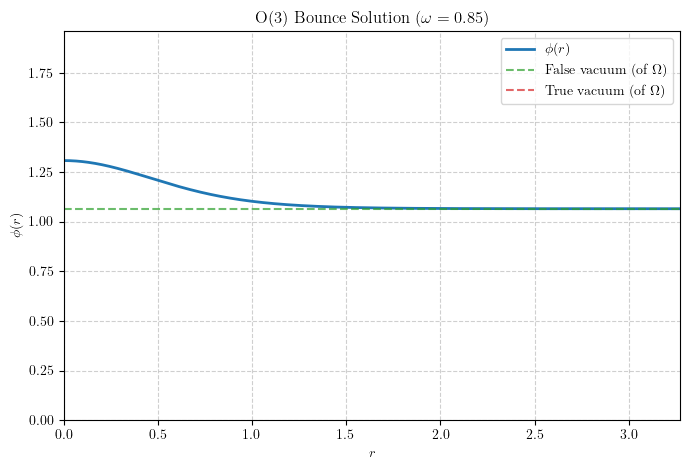

In [ ]:
# Analytical Euclidean action for d=4, Q=0 (used for display only)
from scipy.special import spence
def S0_analytical(phi0):
    """S₀ = -π²/3 [φ₀ - 1 + Li₂((φ₀-1)/(φ₀-2))]; Li₂(z) = spence(1-z)."""
    term = (phi0 - 1) / (phi0 - 2)
    Li2_val = spence(1 - term)
    return -np.pi**2 / 3.0 * (phi0 - 1 + Li2_val)

# Solve bounce with chosen parameters
print("Solving O(3) bounce solution...")
print(f"Parameters: φ₀={PHI0_BOUNCE}, v1={V1_BOUNCE}, v2={V2_BOUNCE}, ω={OMEGA_BOUNCE}")
print(f"Analytical action (d=4, Q=0): S₀ = {S0_analytical(PHI0_BOUNCE):.6f}")
r_bounce, phi_bounce, phi0_bounce, phi_false_bounce, phi_true_bounce = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, 
    d=D,
    r0=R0, rmax=RMAX, max_iter=MAX_ITER, verbose=VERBOSE
)

if r_bounce is not None:
    print(f"\nBounce solution found:")
    print(f"  φ(0) = {phi0_bounce:.6f}")
    print(f"  φ(∞) ≈ {phi_bounce[-1]:.6f} (target false = {phi_false_bounce:.6f})")
    print(f"  r_max = {r_bounce[-1]:.2f}")
    print(f"  Number of points: {len(r_bounce)}")
    print(f"  phi range: [{phi_bounce.min():.6f}, {phi_bounce.max():.6f}]")
    
    # Update phi_false and phi_true with analytical values
    phi_false = phi_false_grid
    phi_true = phi_true_grid
    
    # Plot bounce solution
    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.plot(r_bounce, phi_bounce, lw=2, color='C0', label=r"$\phi(r)$")
    ax.axhline(phi_false, color='C2', ls='--', lw=1.5, label=rf"False vacuum (of $\Omega$)", alpha=0.7)
    ax.axhline(phi_true, color='C3', ls='--', lw=1.5, label=rf"True vacuum (of $\Omega$)", alpha=0.7)
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$\phi(r)$")
    ax.set_xlim(0, r_bounce[-1])
    ax.set_ylim(0, phi_bounce.max()*1.5)
    ax.set_title(rf"O(3) Bounce Solution ($\omega = {OMEGA_BOUNCE:.2f}$)")
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "bounce_profile.png", dpi=150, bbox_inches="tight")
plt.show()

**Charge, energy and densities.** This cell computes total charge $Q$ and energy $E$, and the densities $Q/V$, $E/V$, for (i) the homogeneous configuration and (ii) the bubble configuration, using the volume $V = \frac{4}{3}\pi r_{\max}^3$ with $r_{\max}$ the maximum radius of the bounce.

In [5]:
# Charge, energy and densities (homogeneous vs bubble) — volume = (4/3)π r_max³ with r_max = bubble maximum radius
from Bubble_finder.observables_1d import (
    compute_charge, compute_Fomega_1d_spherical, compute_energy_minkowski_1d_spherical,
    Q_homogeneous_ball,
)

if r_bounce is not None:
    r_max = float(r_bounce[-1])
    V = (4.0 / 3.0) * np.pi * r_max**3

    # Homogeneous: E_M,hom = V·(ω² ρ0² + V(ρ0)),  F_ω,hom = V·Ω(ρ0)
    Q_hom = Q_homogeneous_ball(OMEGA_BOUNCE, phi_false_bounce, r_max)
    V_at_false = float(np.asarray(U(np.array([phi_false_bounce]))).flat[0])
    E_M_hom = V * (OMEGA_BOUNCE**2 * phi_false_bounce**2 + V_at_false)
    F_omega_hom = V * Omega_phi(phi_false_bounce, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE)
    rho_Q_hom = Q_hom / V
    rho_E_M_hom = E_M_hom / V
    rho_F_omega_hom = F_omega_hom / V

    # Bubble: E_M (Minkowski) and F_ω (grand-canonical)
    Q_bubble = compute_charge(r_bounce, phi_bounce, OMEGA_BOUNCE)
    E_M_bubble = compute_energy_minkowski_1d_spherical(r_bounce, phi_bounce, OMEGA_BOUNCE, U, R_ref=r_max)
    F_omega_bubble = compute_Fomega_1d_spherical(
        r_bounce, phi_bounce,
        PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE,
        phi_false_bounce, subtract_background=False
    )
    rho_Q_bubble = Q_bubble / V
    rho_E_M_bubble = E_M_bubble / V
    rho_F_omega_bubble = F_omega_bubble / V

    print("Volume (bubble maximum radius): V = (4/3)π r_max³")
    print(f"  r_max = {r_max:.4f}  →  V = {V:.6f}\n")
    print("Homogeneous (φ = φ_false):")
    print(f"  Q_hom = {Q_hom:.6f}   E_M,hom = {E_M_hom:.6f}   F_ω,hom = {F_omega_hom:.6f}")
    print(f"  Q_hom/V = {rho_Q_hom:.6f}   E_M,hom/V = {rho_E_M_hom:.6f}   F_ω,hom/V = {rho_F_omega_hom:.6f}\n")
    print("Bubble:")
    print(f"  Q_bubble = {Q_bubble:.6f}   E_M,bubble = {E_M_bubble:.6f}   F_ω,bubble = {F_omega_bubble:.6f}")
    print(f"  Q_bubble/V = {rho_Q_bubble:.6f}   E_M,bubble/V = {rho_E_M_bubble:.6f}   F_ω,bubble/V = {rho_F_omega_bubble:.6f}")
else:
    print("No bounce solution: charge/energy cannot be computed.")

Volume (bubble maximum radius): V = (4/3)π r_max³
  r_max = 3.8532  →  V = 239.637614

Homogeneous (φ = φ_false):
  Q_hom = 231.049350   E_M,hom = 90.628116   F_ω,hom = -302.155779
  Q_hom/V = 0.964161   E_M,hom/V = 0.378188   F_ω,hom/V = -1.260886

Bubble:
  Q_bubble = 233.708585   E_M,bubble = 96.465342   F_ω,bubble = -301.629170
  Q_bubble/V = 0.975258   E_M,bubble/V = 0.402547   F_ω,bubble/V = -1.258689


**Zero-charge bounce (ω = 0).** This cell solves and plots the bounce at $\omega=0$ for both O(3) and O(4) symmetry (the latter is the standard Coleman–De Luccia instanton in $d=4$).

Solving O(3) bounce for ω=0 (bubble_zero_charge)...
[vacua_of_Omega] ω=0
  phi_false=1.00000001839  Ω_false=-0.5  dΩ=1.67e-06  (ω²-W)=-8.35e-07  Ω''=9.636e+05
  phi_true =1.99986461045  Ω_true =-1.50000001833  dΩ=-4.20e-08  (ω²-W)=1.05e-08  Ω''=4.001e+00
Vacua of Ω: phi_false=1.0000000184, phi_true=1.9998646105
  Iteration 0: Undershoot, φ(0)=1.499932, φ(∞)=1.336373, r_stop=1.1604
  Iteration 10: Overshoot, φ(0)=1.995471, φ(∞)=1.000000, r_stop=2.5341
  Iteration 20: Undershoot, φ(0)=1.995052, φ(∞)=1.000242, r_stop=3.1309
  Converged after 27 iterations: φ(0)=1.995052, φ(∞)=1.000000, φ'(∞)=-2.497e-04
Solving O(4) bounce for ω=0...
[vacua_of_Omega] ω=0
  phi_false=1.00000001839  Ω_false=-0.5  dΩ=1.67e-06  (ω²-W)=-8.35e-07  Ω''=9.636e+05
  phi_true =1.99986461045  Ω_true =-1.50000001833  dΩ=-4.20e-08  (ω²-W)=1.05e-08  Ω''=4.001e+00
Vacua of Ω: phi_false=1.0000000184, phi_true=1.9998646105
  Iteration 0: Undershoot, φ(0)=1.499932, φ(∞)=1.347982, r_stop=1.3234
  Iteration 10: Overshoot, φ(0

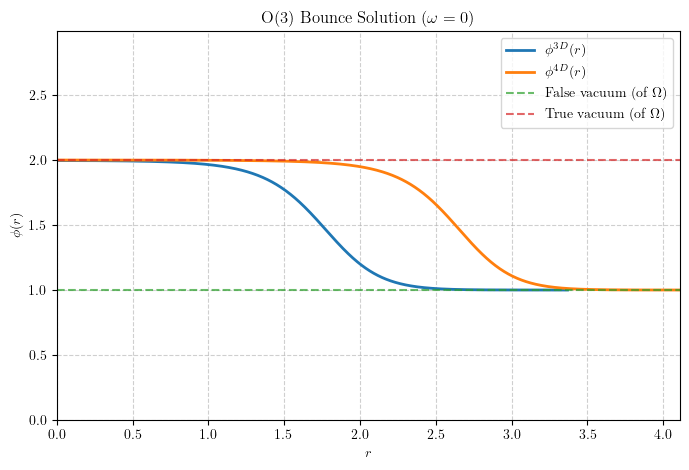

In [6]:
# Bounce for ω=0 (zero charge): same potential, omega=0 → Ω(φ)=V(φ)
print("Solving O(3) bounce for ω=0 (bubble_zero_charge)...")
r_bubble_zero_charge, phi_bubble_zero_charge, phi0_bzc, phi_false_bzc, phi_true_bzc = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, 0.0,
    d=D, r0=1e-6, rmax=RMAX, max_iter=MAX_ITER, verbose=VERBOSE
)

# O(4) bounce for ω=0 (same potential, d=4)
print("Solving O(4) bounce for ω=0...")
r_bubble_zero_d4, phi_bubble_zero_d4, phi0_bzc_d4, phi_false_bzc_d4, phi_true_bzc_d4 = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, 0.0,
    d=4, r0=1e-6, rmax=RMAX, max_iter=MAX_ITER, verbose=VERBOSE
)


if r_bubble_zero_charge is not None:
    print(f"  φ(0) = {phi0_bzc:.6f}, r_max = {r_bubble_zero_charge[-1]:.2f}, N = {len(r_bubble_zero_charge)}")
    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.plot(r_bubble_zero_charge, phi_bubble_zero_charge, lw=2, color="C0", label=r"$\phi^{3D}(r)$")
    ax.plot(r_bubble_zero_d4, phi_bubble_zero_d4, lw=2, color="C1", label=r"$\phi^{4D}(r)$")
    ax.axhline(phi_false_bzc, color="C2", ls="--", lw=1.5, label=rf"False vacuum (of $\Omega$)", alpha=0.7)
    ax.axhline(phi_true_bzc, color="C3", ls="--", lw=1.5, label=rf"True vacuum (of $\Omega$)", alpha=0.7)
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$\phi(r)$")
    ax.set_xlim(0, r_bubble_zero_d4[-1])
    ax.set_ylim(0, phi_bubble_zero_charge.max() * 1.5)
    ax.set_title(r"O(3) Bounce Solution ($\omega = 0$)")
    ax.legend()
    ax.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "bounce_omega0_O3_O4.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("  Failed to find bounce for ω=0.")

**Omega scan.** The next cell finds the range of $\omega$ where $\Omega(\phi)$ has two minima and a barrier, then scans over $\omega$ and stores **total charge $Q$ and total energy $E$** (no background subtraction) for each converged bounce. Results are volume-corrected to a common $r_{\max}$ for comparison.

In [ ]:
# ============================================================================
# Omega scan: total Q, F_ω (grand-canonical) and E_M (Minkowski energy). Volume-corrected to common r_max.
# ============================================================================

from Bubble_finder.observables_1d import compute_charge, compute_Fomega_1d_spherical, compute_energy_minkowski_1d_spherical

def has_barrier(phi0, v1, v2, omega, n_grid=400, barrier_tol=1e-6):
    """Return True if Ω(φ) has two distinct local minima separated by a barrier."""
    try:
        phi_false, phi_true = vacua_of_Omega(phi0, v1, v2, omega)
    except RuntimeError:
        return False
    if abs(phi_true - phi_false) < 1e-4:
        return False
    a, b = (phi_false, phi_true) if phi_false < phi_true else (phi_true, phi_false)
    Om_a = Omega_phi(a, phi0, v1, v2, omega)
    Om_b = Omega_phi(b, phi0, v1, v2, omega)
    grid = np.linspace(a, b, n_grid)
    Om = np.array([Omega_phi(x, phi0, v1, v2, omega) for x in grid])
    i_max = int(np.argmax(Om))
    if i_max == 0 or i_max == len(grid) - 1:
        return False
    Om_max = Om[i_max]
    if Om_max - max(Om_a, Om_b) <= barrier_tol:
        return False
    return True

# Scan parameters (single place)
phi0, v1, v2 = PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE
SCAN_RMAX = 1000.0
SCAN_MAX_ITER = 150
SCAN_N_POINTS = 100
SCAN_GRID_POINTS = 3000
SCAN_R0 = 1e-8

# Find ω_max where the barrier disappears
print("Finding maximum omega with a tunneling barrier...")
omega_test = np.linspace(0.0, 2.0, 400)
omega_lo, omega_hi = 0.0, None
for om in omega_test:
    if has_barrier(phi0, v1, v2, om):
        omega_lo = om
    else:
        omega_hi = om
        break
if omega_hi is None:
    omega_hi = omega_test[-1]
for _ in range(35):
    om_mid = 0.5 * (omega_lo + omega_hi)
    if has_barrier(phi0, v1, v2, om_mid):
        omega_lo = om_mid
    else:
        omega_hi = om_mid
omega_max = omega_lo
print(f"Omega range with tunneling barrier: [0, {omega_max:.6f}]")

# Scan: store total Q, F_ω (grand-canonical) and E_M (Minkowski energy)
print(f"\nScanning over omega in [0, {omega_max:.6f}]...")
print(f"Scan parameters: RMAX={SCAN_RMAX}, max_iter={SCAN_MAX_ITER}, n_points={SCAN_N_POINTS}, r0={SCAN_R0}")
n_omega = SCAN_N_POINTS
omega_scan = np.linspace(0.01, omega_max * 0.98, n_omega)
Q_vals = []
F_vals = []   # F_ω (grand-canonical functional)
E_vals = []   # E_M (Minkowski energy)
omega_valid = []
r_max_vals = []
phi_false_vals = []

for i, om in enumerate(omega_scan):
    if i % 10 == 0:
        print(f"  Processing omega = {om:.6f} ({i+1}/{n_omega})...")
    try:
        r_b, phi_b, phi0_b, phi_false_om, phi_true_om = solve_bounce(
            phi0, v1, v2, om,
            d=3, r0=SCAN_R0, rmax=SCAN_RMAX,
            max_iter=SCAN_MAX_ITER, verbose=False,
            n_grid_points=SCAN_GRID_POINTS
        )
        if r_b is not None and len(r_b) > 10:
            if (r_b[-1] - r_b[0]) <= 1e-12:
                if i % 10 == 0:
                    print(f"    r-range too small. Skipping omega = {om:.6f}")
                continue
            phi_end = phi_b[-1]
            dphi_dr = np.gradient(phi_b, r_b, edge_order=2)
            dphi_end = dphi_dr[-1]
            phi_error = abs(phi_end - phi_false_om)
            dphi_error = abs(dphi_end)
            if phi_error < 1e-3 and dphi_error < 1e-3:
                if len(r_b) < 50:
                    if i % 10 == 0:
                        print(f"    Solution has too few points ({len(r_b)}). Skipping.")
                    continue
                r_unique, idx_unique = np.unique(r_b, return_index=True)
                if len(r_unique) < len(r_b):
                    r_b = r_b[idx_unique]
                    phi_b = phi_b[idx_unique]
                # Total Q, F_ω (grand-canonical) and E_M (Minkowski energy)
                Q = compute_charge(r_b, phi_b, om)
                F_omega = compute_Fomega_1d_spherical(r_b, phi_b, phi0, v1, v2, om, phi_false_om, subtract_background=False)
                E_M = compute_energy_minkowski_1d_spherical(r_b, phi_b, om, U, R_ref=float(r_b[-1]))
                Q_vals.append(Q)
                F_vals.append(F_omega)
                E_vals.append(E_M)
                omega_valid.append(om)
                r_max_vals.append(r_b[-1])
                phi_false_vals.append(phi_false_om)
                if i % 10 == 0:
                    print(f"    Converged (φ error: {phi_error:.2e}, φ' error: {dphi_error:.2e})")
            else:
                if i % 10 == 0:
                    print(f"    Solution not converged (φ error: {phi_error:.2e}, φ' error: {dphi_error:.2e})")
        else:
            if i % 10 == 0:
                print(f"    No valid solution for omega = {om:.6f}")
    except (RuntimeError, ValueError) as e:
        if i % 10 == 0:
            print(f"    Error for omega = {om:.6f}: {str(e)[:50]}")

Q_vals = np.array(Q_vals)
F_vals = np.array(F_vals)
E_vals = np.array(E_vals)
omega_valid = np.array(omega_valid)
r_max_vals = np.array(r_max_vals)
phi_false_vals = np.array(phi_false_vals)

# Volume correction to common r_max_min so all points are comparable
r_max_min = r_max_vals.min()
V_min = (4.0 / 3.0) * np.pi * r_max_min**3
for i in range(len(omega_valid)):
    V_each = (4.0 / 3.0) * np.pi * r_max_vals[i]**3
    dV = V_min - V_each
    om_i = omega_valid[i]
    pf_i = phi_false_vals[i]
    # Total Q: add charge in shell (false vacuum)
    Q_vals[i] += om_i * pf_i**2 * dV
    Omega_false_i = Omega_phi(pf_i, phi0, v1, v2, om_i)
    # F_ω: add grand-canonical density Ω(φ_false) in shell
    F_vals[i] += Omega_false_i * dV
    # E_M: add Minkowski density ω² φ² + V(φ) = Ω(φ) + 2 ω² φ² in shell
    E_vals[i] += (Omega_false_i + 2.0 * om_i**2 * pf_i**2) * dV
print(f"Volume correction applied: r_max_min = {r_max_min:.4f}, common volume V_min = {V_min:.4f}")
print(f"\nScan complete: {len(omega_valid)} successful solutions. Q_vals, F_vals (F_ω), E_vals (E_M) are total (volume-corrected).")

Finding maximum omega with a tunneling barrier...
[vacua_of_Omega] ω=0
  phi_false=1.00000001839  Ω_false=-0.5  dΩ=1.67e-06  (ω²-W)=-8.35e-07  Ω''=9.636e+05
  phi_true =1.99986461045  Ω_true =-1.50000001833  dΩ=-4.20e-08  (ω²-W)=1.05e-08  Ω''=4.001e+00
[vacua_of_Omega] ω=0.00501253
  phi_false=1.00000065931  Ω_false=-0.500025125486  dΩ=2.22e-07  (ω²-W)=-1.11e-07  Ω''=1.161e+05
  phi_true =1.99989292233  Ω_true =-1.50010050797  dΩ=-1.89e-08  (ω²-W)=4.73e-09  Ω''=3.063e+00
[vacua_of_Omega] ω=0.0100251
  phi_false=1.00000284238  Ω_false=-0.500100502159  dΩ=-1.99e-08  (ω²-W)=9.96e-09  Ω''=6.679e+01
  phi_true =2.00021593785  Ω_true =-1.50040209755  dΩ=-1.18e-08  (ω²-W)=2.95e-09  Ω''=5.861e+00
[vacua_of_Omega] ω=0.0150376
  phi_false=1.00000672153  Ω_false=-0.500226130708  dΩ=-1.29e-07  (ω²-W)=6.44e-08  Ω''=6.328e+01
  phi_true =2.0002932091  Ω_true =-1.5009047355  dΩ=9.58e-09  (ω²-W)=-2.39e-09  Ω''=7.085e+00
[vacua_of_Omega] ω=0.0200501
  phi_false=1.00001240357  Ω_false=-0.500402012358  d

**Vacua and densities vs ω.** Below: (1) φ_false and φ_true of Ω(φ) as functions of ω; (2) charge density ρ_Q and energy density ρ_E for the bubble and for the homogeneous configuration vs ω.

[vacua_of_Omega] ω=0.01
  phi_false=1.00000282734  Ω_false=-0.500100000275  dΩ=-1.95e-08  (ω²-W)=9.76e-09  Ω''=6.682e+01
  phi_true =2.00021560335  Ω_true =-1.50040008959  dΩ=3.64e-08  (ω²-W)=-9.09e-09  Ω''=5.855e+00
[vacua_of_Omega] ω=0.0192519
  phi_false=1.00001137589  Ω_false=-0.500370639417  dΩ=-1.89e-08  (ω²-W)=9.46e-09  Ω''=6.116e+01
  phi_true =2.00036960727  Ω_true =-1.50148295192  dΩ=-2.56e-08  (ω²-W)=6.41e-09  Ω''=8.013e+00
[vacua_of_Omega] ω=0.0285038
  phi_false=1.00002628981  Ω_false=-0.500812486326  dΩ=-8.14e-08  (ω²-W)=4.07e-08  Ω''=5.780e+01
  phi_true =2.00056748844  Ω_true =-1.50325110698  dΩ=-6.41e-08  (ω²-W)=1.60e-08  Ω''=9.732e+00
[vacua_of_Omega] ω=0.0377557
  phi_false=1.0000480013  Ω_false=-0.501425557101  dΩ=-9.92e-08  (ω²-W)=4.96e-08  Ω''=5.538e+01
  phi_true =2.00080186027  Ω_true =-1.50570489379  dΩ=7.39e-09  (ω²-W)=-1.85e-09  Ω''=1.112e+01
[vacua_of_Omega] ω=0.0470076
  phi_false=1.0000768534  Ω_false=-0.502209875212  dΩ=-1.79e-07  (ω²-W)=8.97e-08  Ω''=5.3

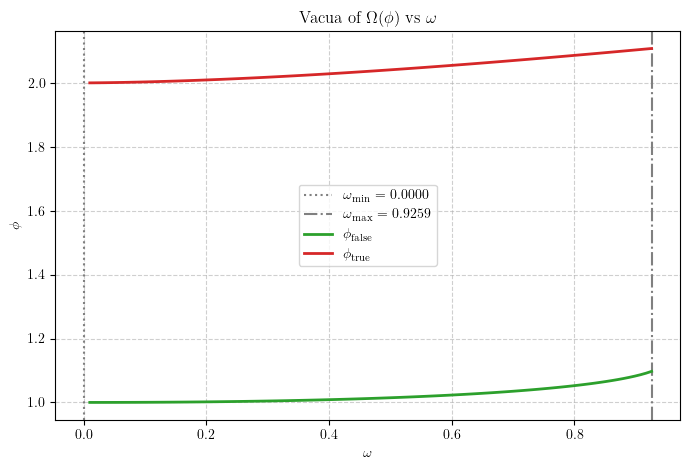

In [8]:
# φ_false and φ_true (minima of Ω(φ)) vs ω
phi_true_vals = np.array([vacua_of_Omega(phi0, v1, v2, om)[1] for om in omega_valid])
omega_min = 0
omega_max_val = omega_valid.max()

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.axvline(omega_min, color="gray", ls=":", lw=1.5, label=rf"$\omega_{{\min}}$ = {omega_min:.4f}")
ax.axvline(omega_max_val, color="gray", ls="-.", lw=1.5, label=rf"$\omega_{{\max}}$ = {omega_max_val:.4f}")
ax.plot(omega_valid, phi_false_vals, lw=2, color="C2", label=r"$\phi_{\mathrm{false}}$")
ax.plot(omega_valid, phi_true_vals, lw=2, color="C3", label=r"$\phi_{\mathrm{true}}$")
ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$\phi$")
ax.set_title(r"Vacua of $\Omega(\phi)$ vs $\omega$")
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "phi_false_true_vs_omega.png", dpi=150, bbox_inches="tight")
plt.show()

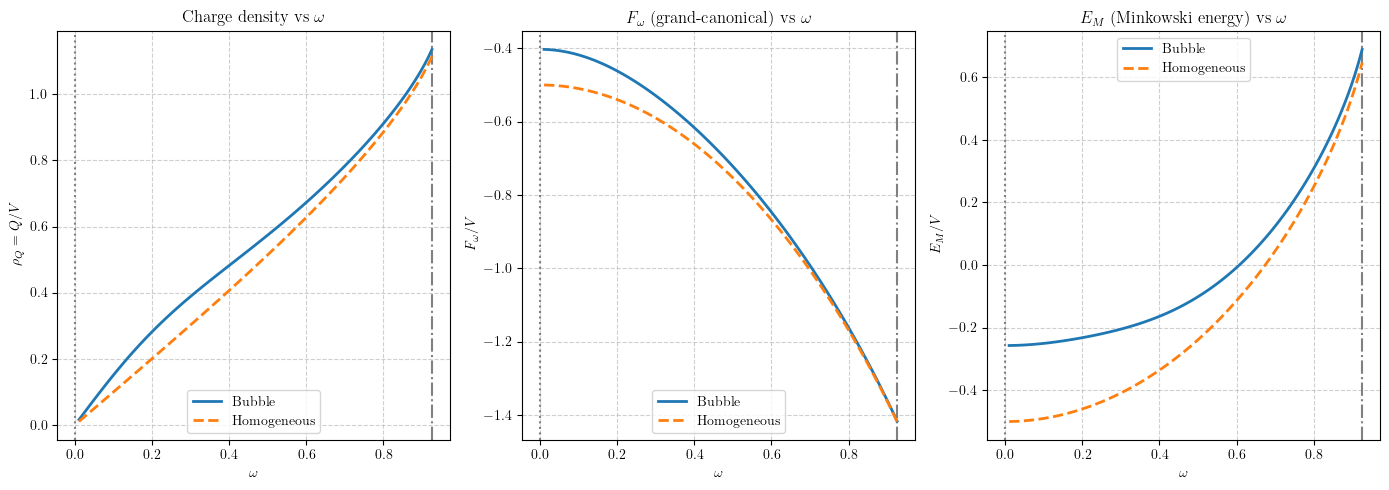

In [9]:
# Three panels: ρ_Q, F_ω/V and E_M/V (bubble vs homogeneous) vs ω
rho_Q_bubble = Q_vals / V_min
rho_F_bubble = F_vals / V_min
rho_E_bubble = E_vals / V_min
rho_Q_hom = omega_valid * phi_false_vals**2
rho_F_hom = np.array([Omega_phi(phi_false_vals[i], phi0, v1, v2, omega_valid[i]) for i in range(len(omega_valid))])
rho_E_hom = np.array([Omega_phi(phi_false_vals[i], phi0, v1, v2, omega_valid[i]) + 2.0 * omega_valid[i]**2 * phi_false_vals[i]**2 for i in range(len(omega_valid))])
omega_min = 0
omega_max_val = omega_valid.max()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))
ax1.axvline(omega_min, color="gray", ls=":", lw=1.5)
ax1.axvline(omega_max_val, color="gray", ls="-.", lw=1.5)
ax1.plot(omega_valid, rho_Q_bubble, lw=2, color="C0", label="Bubble")
ax1.plot(omega_valid, rho_Q_hom, lw=2, color="C1", ls="--", label="Homogeneous")
ax1.set_xlabel(r"$\omega$")
ax1.set_ylabel(r"$\rho_Q = Q/V$")
ax1.set_title(r"Charge density vs $\omega$")
ax1.legend()
ax1.grid(True, ls="--", alpha=0.6)

ax2.axvline(omega_min, color="gray", ls=":", lw=1.5)
ax2.axvline(omega_max_val, color="gray", ls="-.", lw=1.5)
ax2.plot(omega_valid, rho_F_bubble, lw=2, color="C0", label="Bubble")
ax2.plot(omega_valid, rho_F_hom, lw=2, color="C1", ls="--", label="Homogeneous")
ax2.set_xlabel(r"$\omega$")
ax2.set_ylabel(r"$F_\omega/V$")
ax2.set_title(r"$F_\omega$ (grand-canonical) vs $\omega$")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.6)

ax3.axvline(omega_min, color="gray", ls=":", lw=1.5)
ax3.axvline(omega_max_val, color="gray", ls="-.", lw=1.5)
ax3.plot(omega_valid, rho_E_bubble, lw=2, color="C0", label="Bubble")
ax3.plot(omega_valid, rho_E_hom, lw=2, color="C1", ls="--", label="Homogeneous")
ax3.set_xlabel(r"$\omega$")
ax3.set_ylabel(r"$E_M/V$")
ax3.set_title(r"$E_M$ (Minkowski energy) vs $\omega$")
ax3.legend()
ax3.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "rho_Q_F_E_vs_omega.png", dpi=150, bbox_inches="tight")
plt.show()

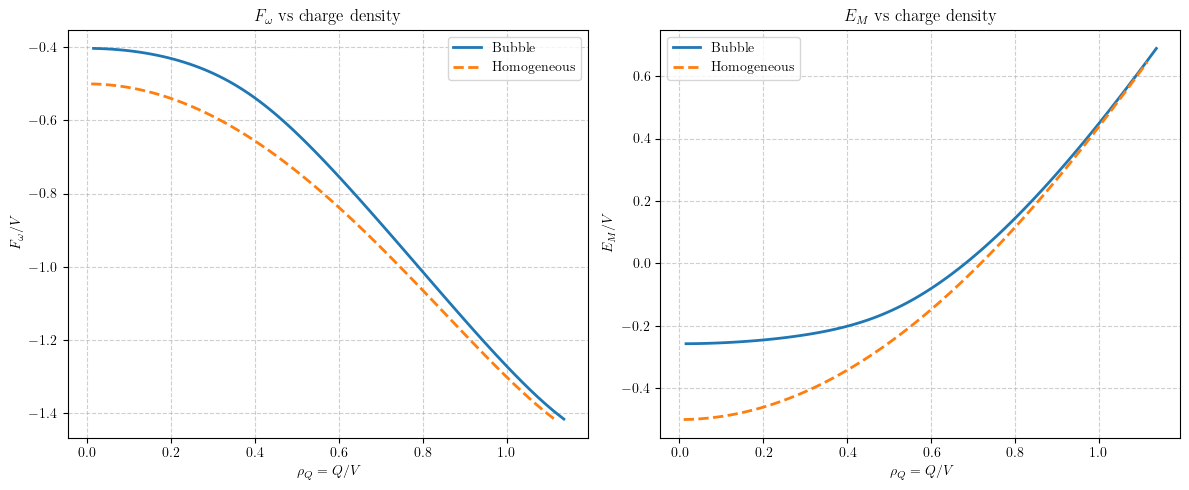

In [10]:
# F_ω/V and E_M/V vs charge density ρ_Q (bubble and homogeneous)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(rho_Q_bubble, rho_F_bubble, lw=2, color="C0", label="Bubble")
ax1.plot(rho_Q_hom, rho_F_hom, lw=2, color="C1", ls="--", label="Homogeneous")
ax1.set_xlabel(r"$\rho_Q = Q/V$")
ax1.set_ylabel(r"$F_\omega/V$")
ax1.set_title(r"$F_\omega$ vs charge density")
ax1.legend()
ax1.grid(True, ls="--", alpha=0.6)
ax2.plot(rho_Q_bubble, rho_E_bubble, lw=2, color="C0", label="Bubble")
ax2.plot(rho_Q_hom, rho_E_hom, lw=2, color="C1", ls="--", label="Homogeneous")
ax2.set_xlabel(r"$\rho_Q = Q/V$")
ax2.set_ylabel(r"$E_M/V$")
ax2.set_title(r"$E_M$ vs charge density")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "F_E_vs_rho_Q.png", dpi=150, bbox_inches="tight")
plt.show()

**Matching ω.** Reference: **homogeneous configuration at $\omega = $ OMEGA** (from the project path cell: PHI0, V1, V2, OMEGA). Compute its charge density $\rho_Q^{\mathrm{ref}}$ and energy density $\rho_E^{\mathrm{ref}}$. Then find which $\omega$ in the scan gives a **bubble** with the same $\rho_Q$ as $\rho_Q^{\mathrm{ref}}$, and which $\omega$ gives a bubble with the same $\rho_E$ as $\rho_E^{\mathrm{ref}}$.

In [11]:
# Reference: homogeneous configuration at ω = OMEGA (from first cell: PHI0, V1, V2, OMEGA)
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

phi_false_ref, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)
rho_Q_ref = OMEGA * phi_false_ref**2
rho_F_ref = Omega_phi(phi_false_ref, PHI0, V1, V2, OMEGA)  # F_ω/V for reference
rho_E_ref = Omega_phi(phi_false_ref, PHI0, V1, V2, OMEGA) + 2.0 * OMEGA**2 * phi_false_ref**2  # E_M/V for reference
print("Reference: homogeneous at ω = OMEGA (from project path cell)")
print(f"  OMEGA = {OMEGA},  φ_false = {phi_false_ref:.6f}")
print(f"  ρ_Q_ref = {rho_Q_ref:.6f},  ρ_Fω_ref = {rho_F_ref:.6f},  ρ_E_M_ref = {rho_E_ref:.6f}")
print()

# Interpolate bubble densities vs ω; find ω where bubble equals reference density
om_min, om_max = omega_valid.min(), omega_valid.max()
rho_Q_bubble_fn = interp1d(omega_valid, rho_Q_bubble, kind="linear", bounds_error=False, fill_value="extrapolate")
rho_F_bubble_fn = interp1d(omega_valid, rho_F_bubble, kind="linear", bounds_error=False, fill_value="extrapolate")
rho_E_bubble_fn = interp1d(omega_valid, rho_E_bubble, kind="linear", bounds_error=False, fill_value="extrapolate")
diff_Q = lambda om: rho_Q_bubble_fn(om) - rho_Q_ref
diff_F = lambda om: rho_F_bubble_fn(om) - rho_F_ref
diff_E = lambda om: rho_E_bubble_fn(om) - rho_E_ref

omega_same_rho_Q = None
omega_same_rho_E = None
omega_same_rho_F = None
if diff_Q(om_min) * diff_Q(om_max) <= 0:
    sol_Q = root_scalar(diff_Q, bracket=[om_min, om_max], method="brentq")
    omega_same_rho_Q = sol_Q.root
if diff_F(om_min) * diff_F(om_max) <= 0:
    sol_F = root_scalar(diff_F, bracket=[om_min, om_max], method="brentq")
    omega_same_rho_F = sol_F.root
if diff_E(om_min) * diff_E(om_max) <= 0:
    sol_E = root_scalar(diff_E, bracket=[om_min, om_max], method="brentq")
    omega_same_rho_E = sol_E.root

print("Bubble with same density as reference homogeneous:")
if omega_same_rho_Q is not None:
    rho_F_bubble_same_Q = float(rho_F_bubble_fn(omega_same_rho_Q))
    rho_E_bubble_same_Q = float(rho_E_bubble_fn(omega_same_rho_Q))
    delta_rho_F_same_Q = rho_F_bubble_same_Q - rho_F_ref
    delta_rho_E_same_Q = rho_E_bubble_same_Q - rho_E_ref
    F_bubble_same_Q = rho_F_bubble_same_Q * V_min
    E_bubble_same_Q = rho_E_bubble_same_Q * V_min
    F_hom_ref = rho_F_ref * V_min
    E_hom_ref = rho_E_ref * V_min
    delta_F_same_Q = F_bubble_same_Q - F_hom_ref
    delta_E_same_Q = E_bubble_same_Q - E_hom_ref
    print(f"  Same ρ_Q as ref:  ω = {omega_same_rho_Q:.6f}  (ρ_Q = {rho_Q_ref:.6f})")
    print(f"    ρ_Fω,bubble = {rho_F_bubble_same_Q:.6f},  Δρ_Fω = {delta_rho_F_same_Q:.6f}")
    print(f"    ρ_E_M,bubble = {rho_E_bubble_same_Q:.6f},  Δρ_E_M = {delta_rho_E_same_Q:.6f}")
    print(f"    F_ω,bubble = {F_bubble_same_Q:.6f},  F_ω,hom = {F_hom_ref:.6f},  ΔF_ω = {delta_F_same_Q:.6f}")
    print(f"    E_M,bubble = {E_bubble_same_Q:.6f},  E_M,hom = {E_hom_ref:.6f},  ΔE_M = {delta_E_same_Q:.6f}")
else:
    print("  Same ρ_Q: no solution in scan range.")
if omega_same_rho_F is not None:
    print(f"  Same ρ_Fω as ref:  ω = {omega_same_rho_F:.6f}  (ρ_Fω = {rho_F_ref:.6f})")
else:
    print("  Same ρ_Fω: no solution in scan range.")
if omega_same_rho_E is not None:
    print(f"  Same ρ_E_M as ref:  ω = {omega_same_rho_E:.6f}  (ρ_E_M = {rho_E_ref:.6f})")
else:
    print("  Same ρ_E_M: no solution in scan range.")

[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
Reference: homogeneous at ω = OMEGA (from project path cell)
  OMEGA = 0.85,  φ_false = 1.065039
  ρ_Q_ref = 0.964161,  ρ_Fω_ref = -1.260886,  ρ_E_M_ref = 0.378188

Bubble with same density as reference homogeneous:
  Same ρ_Q as ref:  ω = 0.835507  (ρ_Q = 0.964161)
    ρ_Fω,bubble = -1.228117,  Δρ_Fω = 0.032770
    ρ_E_M,bubble = 0.390844,  Δρ_E_M = 0.012656
    F_ω,bubble = -143.136497,  F_ω,hom = -146.955771,  ΔF_ω = 3.819274
    E_M,bubble = 45.552724,  E_M,hom = 44.077677,  ΔE_M = 1.475047
  Same ρ_Fω as ref:  ω = 0.852282  (ρ_Fω = -1.260886)
  Same ρ_E_M as ref:  ω = 0.830398  (ρ_E_M = 0.378188)


## 2. 2D analysis

In this section we build the **2D Euclidean (τ, r) setup** and the **homogeneous ansatz** (constant field $y = \bar y = 0$, i.e. $\rho = \rho_0$ everywhere). We plot this ansatz in a single panel, then pass it to **Newton**; the solver converges to the 2D solution (which for the homogeneous initial guess remains homogeneous). We then plot the Newton solution.

The chemical potential $\omega$ used in the 2D solver can be chosen among:
- **OMEGA** — reference value from the project path cell;
- **omega_same_rho_Q** — $\omega$ at which the 1D bubble has the same charge density as the reference homogeneous configuration;
- **omega_same_rho_E** — $\omega$ at which the 1D bubble has the same energy density as the reference homogeneous configuration.

This allows one to compare 2D results at the reference $\omega$ vs at the matching $\omega$ values from the 1D scan.

**Setup, Newton, and plots.** The next cell selects $\omega$ for the 2D run (OMEGA, omega_same_rho_Q, or omega_same_rho_E), builds the solver, runs Newton from the homogeneous ansatz $y=\bar y=0$, then plots: (1) the solution $\rho(r,\tau)$ with a clear color scale; (2) $\rho(r_{\max},\tau)$ vs $\tau$ with $\rho_{\mathrm{false}}$ and $\rho_{\mathrm{seed}}$; (3) $\rho(r,0)$ vs $r$ with $\rho_{\mathrm{false}}$ and $\rho_{\mathrm{seed}}$.

2D run: ω = 0.850000  (choice: OMEGA)
[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
[Newton-explicit] iter=01, ||F||=1.502e-05, rhoQ=9.641596e-01, rhoE=-3.781875e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000
[Newton-explicit] iter=02, ||F||=4.656e-13, rhoQ=9.641596e-01, rhoE=-3.781875e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000
[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01


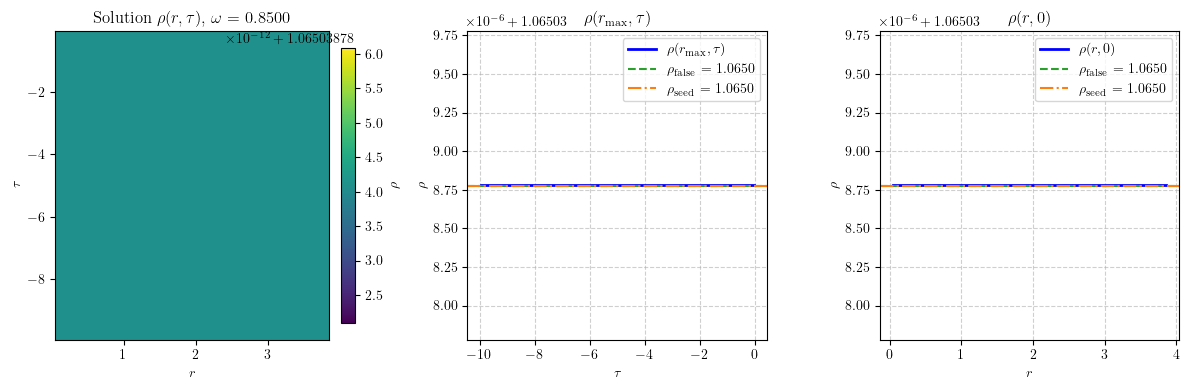

--- Final diagnostics (τ=0 ghost) ---
  Converged: True,  ||F|| = 4.656e-13
  Volume V = (4/3)π Lr³ = 239.637614

  Solution (2D Newton):
    Q(τ=0) = 231.048901,   E(τ=0) = -90.627942
    ρ_Q = Q/V = 0.964160,   ρ_E = E/V = -0.378187

  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):
    Q_hom = 231.049350,   E_hom = -90.628116
    ρ_Q,hom = Q_hom/V = 0.964161,   ρ_E,hom = E_hom/V = -0.378188

  Ratios (solution / homogeneous):  Q/Q_hom = 0.999998,  E/E_hom = 0.999998
  Density ratios:  ρ_Q/ρ_Q,hom = 0.999998,  ρ_E/ρ_E,hom = 0.999998
  Difference:  E - E_hom (H_E) = 0.000174
  Difference:  E_M - E_M_hom(OMEGA) = -0.000174
  F_ω (solution) = -105.763623,  F_ω,hom(OMEGA) = -105.763831
  Difference:  F_ω - F_ω,hom = 0.000208


In [7]:
# ============================================================================
# 2D analysis: homogeneous ansatz → plot → Newton → plot solution
# ω for the 2D solver: choose among OMEGA, omega_same_rho_Q, omega_same_rho_E
# ============================================================================
from Bubble_finder.bounce2d import solve_rho0_for_omega

# Choose ω for the 2D run (change to "omega_same_rho_Q" or "omega_same_rho_E" if desired)
omega_2d_choice = "OMEGA"  # or "omega_same_rho_Q" or "omega_same_rho_E"
try:
    _om_Q = omega_same_rho_Q
except NameError:
    _om_Q = None
try:
    _om_E = omega_same_rho_E
except NameError:
    _om_E = None
if omega_2d_choice == "omega_same_rho_Q" and _om_Q is not None:
    omega_2d = float(_om_Q)
elif omega_2d_choice == "omega_same_rho_E" and _om_E is not None:
    omega_2d = float(_om_E)
else:
    omega_2d = float(OMEGA)
print(f"2D run: ω = {omega_2d:.6f}  (choice: {omega_2d_choice})")

# Grid and solver (Lr from 1D bounce if available)
try:
    Lr_2d = float(r_bounce[-1]) if r_bounce is not None else 10.0
except NameError:
    Lr_2d = 10.0
Nr_2d, Ntau_2d = 80, 100
beta_2d = 20.0
# Seed at false vacuum: rho0 = ρ_false so homogeneous ansatz is φ = ρ_false
rho_false_2d, _ = vacua_of_Omega(PHI0, V1, V2, omega_2d)
rho0_2d = float(rho_false_2d)

settings_2d = Bubble2DSettings(
    Nr=Nr_2d, Ntau=Ntau_2d, Lr=Lr_2d, beta=beta_2d,
    omega_ref=omega_2d, rho0=rho0_2d, rho0_bracket=(V1 * 0.8, V2 + 0.2),
    newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
)
solver_2d = Bubble2DSolver(settings_2d, U, dU, d2U)

# Homogeneous ansatz: y = ybar = 0 → Newton
x0_hom = solver_2d._zero_vec()
sol_2d = solver_2d.solve(x0_hom, verbose=True, verbose_success_block=False)
rho_sol = solver_2d.rho_map(sol_2d.y, sol_2d.ybar)
tau_2d = np.asarray(solver_2d.grid.tau).flatten()
r_2d = np.asarray(solver_2d.grid.r).flatten()
# Seed was prepared at ρ_false, so rho_seed = rho_false
rho_seed_2d = rho0_2d

# Color scale for solution: data range + small margin so structure is visible
vmin_rho = float(np.min(rho_sol))
vmax_rho = float(np.max(rho_sol))
delta = max(vmax_rho - vmin_rho, 1e-10)
vmin_rho -= 0.02 * delta
vmax_rho += 0.02 * delta

# Homogeneous reference always at OMEGA (φ = ρ_false(OMEGA), same V)
from Bubble_finder.observables_1d import Q_homogeneous_ball
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d

rho_false_ref, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)
V_2d = (4.0 / 3.0) * np.pi * Lr_2d**3
Q_hom_ref = float(Q_homogeneous_ball(OMEGA, rho_false_ref, Lr_2d))
E_hom_ref = float(homogeneous_energy_2d(OMEGA, rho_false_ref, Lr_2d, U))
rho_Q_hom_ref = Q_hom_ref / V_2d
rho_E_hom_ref = E_hom_ref / V_2d

# 1) Solution ρ(r, τ) — square panel
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
tau_min_2d, tau_max_2d = float(np.min(tau_2d)), float(np.max(tau_2d))
extent_r_tau = (float(r_2d[0]), float(r_2d[-1]), tau_min_2d, tau_max_2d)
rho_sol_ordered = rho_sol.T[np.argsort(tau_2d)]
im1 = ax1.imshow(rho_sol_ordered, origin="lower", aspect="auto", extent=extent_r_tau, vmin=vmin_rho, vmax=vmax_rho)
cb1 = plt.colorbar(im1, ax=ax1, label=r"$\rho$", fraction=0.046, pad=0.04)
ax1.set_xlabel(r"$r$")
ax1.set_ylabel(r"$\tau$")
ax1.set_title(r"Solution $\rho(r,\tau)$, $\omega$ = " + f"{omega_2d:.4f}")

# 2) ρ(r_max, τ) — zoom + square
rho_at_rmax = rho_sol[-1, :]
ax2.plot(tau_2d, rho_at_rmax, "b-", lw=2, label=r"$\rho(r_{\max},\tau)$")
ax2.axhline(rho_false_2d, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_2d:.4f}")
ax2.axhline(rho_seed_2d, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho_seed_2d:.4f}")
ymin_2 = min(rho_at_rmax.min(), rho_false_2d, rho_seed_2d)
ymax_2 = max(rho_at_rmax.max(), rho_false_2d, rho_seed_2d)
margin_2 = max((ymax_2 - ymin_2) * 0.1, 1e-6)
ax2.set_ylim(ymin_2 - margin_2, ymax_2 + margin_2)
ax2.set_xlabel(r"$\tau$")
ax2.set_ylabel(r"$\rho$")
ax2.set_title(r"$\rho(r_{\max},\tau)$")
#ax2.set_aspect("equal")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.6)

# 3) ρ(r, 0) — slice at τ=0 (index where tau is max)
idx_tau0 = np.argmax(tau_2d)
rho_at_tau0 = rho_sol[:, idx_tau0]
ax3.plot(r_2d, rho_at_tau0, "b-", lw=2, label=r"$\rho(r,0)$")
ax3.axhline(rho_false_2d, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_2d:.4f}")
ax3.axhline(rho_seed_2d, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho_seed_2d:.4f}")
ymin_3 = min(rho_at_tau0.min(), rho_false_2d, rho_seed_2d)
ymax_3 = max(rho_at_tau0.max(), rho_false_2d, rho_seed_2d)
margin_3 = max((ymax_3 - ymin_3) * 0.1, 1e-6)
ax3.set_ylim(ymin_3 - margin_3, ymax_3 + margin_3)
ax3.set_xlabel(r"$r$")
ax3.set_ylabel(r"$\rho$")
ax3.set_title(r"$\rho(r,0)$")
#ax3.set_aspect("equal")
ax3.legend()
ax3.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "homogeneous_2d_plot.png", dpi=150, bbox_inches="tight")
plt.show()

Q_tau0 = float(sol_2d.Q_tau0.real)
E_tau0 = float(sol_2d.E_tau0)
rho_Q_2d = sol_2d.observables_ghost.get("rho_Q") if getattr(sol_2d, "observables_ghost", None) else (Q_tau0 / V_2d)
rho_E_2d = sol_2d.observables_ghost.get("rho_E") if getattr(sol_2d, "observables_ghost", None) else (E_tau0 / V_2d)
rho_Q_2d = float(rho_Q_2d)
rho_E_2d = float(rho_E_2d)

print("--- Final diagnostics (τ=0 ghost) ---")
print(f"  Converged: {sol_2d.success},  ||F|| = {sol_2d.residual_norm:.3e}")
print(f"  Volume V = (4/3)π Lr³ = {V_2d:.6f}")
print("")
print("  Solution (2D Newton):")
print(f"    Q(τ=0) = {Q_tau0:.6f},   E(τ=0) = {E_tau0:.6f}")
print(f"    ρ_Q = Q/V = {rho_Q_2d:.6f},   ρ_E = E/V = {rho_E_2d:.6f}")
print("")
print("  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):")
print(f"    Q_hom = {Q_hom_ref:.6f},   E_hom = {E_hom_ref:.6f}")
print(f"    ρ_Q,hom = Q_hom/V = {rho_Q_hom_ref:.6f},   ρ_E,hom = E_hom/V = {rho_E_hom_ref:.6f}")
print("")
print(f"  Ratios (solution / homogeneous):  Q/Q_hom = {Q_tau0/Q_hom_ref:.6f},  E/E_hom = {E_tau0/E_hom_ref:.6f}")
print(f"  Density ratios:  ρ_Q/ρ_Q,hom = {rho_Q_2d/rho_Q_hom_ref:.6f},  ρ_E/ρ_E,hom = {rho_E_2d/rho_E_hom_ref:.6f}")
print(f"  Difference:  E - E_hom (H_E) = {E_tau0 - E_hom_ref:.6f}")
obs_2d = getattr(sol_2d, "observables_ghost", None) or {}
E_M_hom_ref = float(homogeneous_E_M_2d(OMEGA, rho_false_ref, Lr_2d, U))
if "E_M" in obs_2d:
    print(f"  Difference:  E_M - E_M_hom(OMEGA) = {obs_2d['E_M'] - E_M_hom_ref:.6f}")
if "F_omega" in obs_2d:
    F_hom_ref = E_M_hom_ref - OMEGA * Q_hom_ref
    print(f"  F_ω (solution) = {obs_2d['F_omega']:.6f},  F_ω,hom(OMEGA) = {F_hom_ref:.6f}")
    print(f"  Difference:  F_ω - F_ω,hom = {obs_2d['F_omega'] - F_hom_ref:.6f}")

**Gated bubble: ansatz from 1D bounce + τ-gate → Newton with iteration history.**

This cell repeats the same 2D analysis (same ω choice, same diagnostics) but starts from a **gated bubble** ansatz: the 1D critical bounce profile $\phi(r)$ is modulated by a smooth gate in τ so the bubble is localized in Euclidean time. You can choose **ω** as **OMEGA**, **omega_same_rho_Q**, or **omega_same_rho_E**. The center and right panels plot not only the final solution but **all Newton iterations** (including the initial gated ansatz) so you can see how the solution is reached.

In [8]:
print(r_bounce[-1])

3.8532050930721704


Gated 2D run: ω = 0.850000  (choice: OMEGA)
[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
[Newton-explicit] iter=01, ||F||=9.729e+00, rhoQ=9.752092e-01, rhoE=-4.024322e-01, rho_Q/rho_Q_ref=1.0115, rho_E/rho_E_ref=1.0641
[Newton-explicit] iter=02, ||F||=9.476e+00, rhoQ=9.723501e-01, rhoE=-4.028050e-01, rho_Q/rho_Q_ref=1.0085, rho_E/rho_E_ref=1.0651
[Newton-explicit] iter=03, ||F||=5.634e+00, rhoQ=9.687247e-01, rhoE=-3.978741e-01, rho_Q/rho_Q_ref=1.0047, rho_E/rho_E_ref=1.0521
[Newton-explicit] iter=04, ||F||=1.895e+00, rhoQ=9.676456e-01, rhoE=-3.946743e-01, rho_Q/rho_Q_ref=1.0036, rho_E/rho_E_ref=1.0436
[Newton-explicit] iter=05, ||F||=1.165e-01, rhoQ=9.678555e-01, rhoE=-3.947166e-01, rho_Q/rho_Q_ref=1.0038, rho_E/rho_E_ref=1.0437
[Newton-explicit] iter=06, ||F||=1.051e-03, rhoQ=9.678402e-01, rhoE=-3.946487e-01, rho_Q/rh

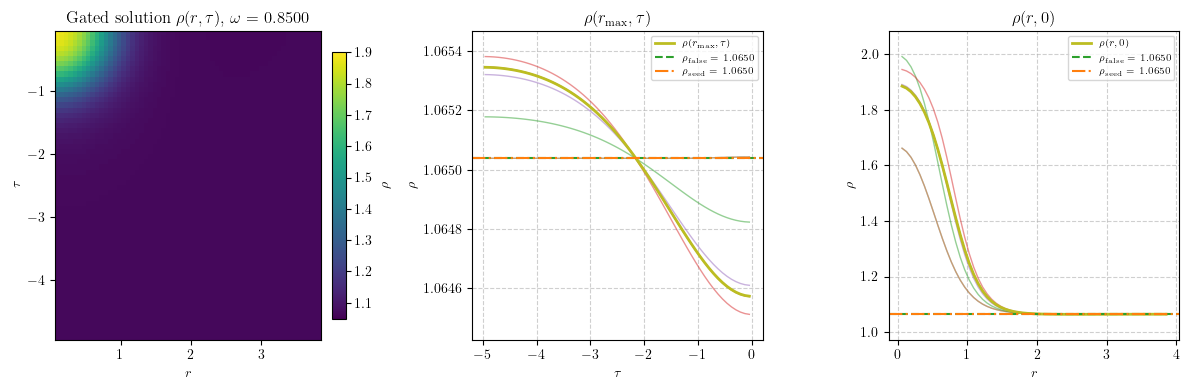

--- Gated bubble diagnostics (τ=0 ghost) ---
  Converged: True,  ||F|| = 4.492e-13
  Volume V = (4/3)π Lr³ = 239.637614

  Solution (2D Newton from gated ansatz):
    Q(τ=0) = 231.930932,   E(τ=0) = -94.572667
    ρ_Q = Q/V = 0.967840,   ρ_E = E/V = -0.394649

  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):
    Q_hom = 231.049350,   E_hom = -90.628116
    ρ_Q,hom = Q_hom/V = 0.964161,   ρ_E,hom = E_hom/V = -0.378188

  Ratios (solution / homogeneous):  Q/Q_hom = 1.003816,  E/E_hom = 1.043525
  Density ratios:  ρ_Q/ρ_Q,hom = 1.003816,  ρ_E/ρ_E,hom = 1.043525
  Difference:  E - E_hom (H_E) = -3.944551
  Difference:  E_M - E_M_hom(OMEGA) = 3.944551
  F_ω (solution) = -102.568625,  F_ω,hom(OMEGA) = -105.763831
  Difference:  F_ω - F_ω,hom = 3.195206


In [ ]:
# ============================================================================
# Gated bubble: 1D bounce + τ-gate → Newton (store_iteration_history=True)
# ω choice: OMEGA, omega_same_rho_Q, or omega_same_rho_E
# ============================================================================
from Bubble_finder.ansatz_bubble import tau_gate, AnsatzParams
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.observables_1d import Q_homogeneous_ball
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d

# Same ω choice as the homogeneous 2D cell
omega_gated_choice = "OMEGA"  # or "omega_same_rho_Q" or "omega_same_rho_E"
try:
    _om_Q = omega_same_rho_Q
except NameError:
    _om_Q = None
try:
    _om_E = omega_same_rho_E
except NameError:
    _om_E = None
if omega_gated_choice == "omega_same_rho_Q" and _om_Q is not None:
    omega_2d_g = float(_om_Q)
elif omega_gated_choice == "omega_same_rho_E" and _om_E is not None:
    omega_2d_g = float(_om_E)
else:
    omega_2d_g = float(OMEGA)

#omega_2d_g = 0
print(f"Gated 2D run: ω = {omega_2d_g:.6f}  (choice: {omega_gated_choice})")

# Grid size (same as homogeneous 2D)
try:
    Lr_2d_g = float(r_bounce[-1]) if r_bounce is not None else 10.0
except NameError:
    Lr_2d_g = 10.0
Nr_2d_g, Ntau_2d_g = 60, 60
beta_2d_g = 10.0
rho_false_2d_g, _ = vacua_of_Omega(PHI0, V1, V2, omega_2d_g)
rho0_2d_g = float(rho_false_2d_g)

# 1D bounce at omega_2d_g for the gated ansatz
try:
    RMAX_1d = float(RMAX)
except NameError:
    RMAX_1d = Lr_2d_g
r_1d_g, phi_1d_g, _, _, _ = solve_bounce(
    PHI0, V1, V2, omega_2d_g,
    d=3, r0=1e-6, rmax=RMAX_1d, max_iter=150, verbose=False,
)
r_1d_g = np.asarray(r_1d_g, float)
phi_1d_g = np.asarray(phi_1d_g, float)

# Solver (same settings as homogeneous 2D)
settings_2d_g = Bubble2DSettings(
    Nr=Nr_2d_g, Ntau=Ntau_2d_g, Lr=Lr_2d_g, beta=beta_2d_g,
    omega_ref=omega_2d_g, rho0=rho0_2d_g, rho0_bracket=(V1 * 0.8, V2 + 0.2),
    newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
)
solver_2d_g = Bubble2DSolver(settings_2d_g, U, dU, d2U)


# Gated ansatz: 1D profile × tau gate
r_grid_g = np.asarray(solver_2d_g.grid.r).flatten()
tau_grid_g = np.asarray(solver_2d_g.grid.tau).flatten()
T_g = beta_2d_g / 2.0
params_gated = AnsatzParams(eps=1.0, k=1, phase=0.0, amp=1.0, tau_gate_frac=0.25, tau_gate_center_frac=1, r_window_frac=0.15)
phi_on_r_g = np.interp(r_grid_g, r_1d_g, phi_1d_g, left=phi_1d_g[0], right=phi_1d_g[-1])
y_slice_g = r_grid_g * (phi_on_r_g - solver_2d_g.rho0)
g_tau = tau_gate(tau_grid_g, T_g, params_gated.tau_gate_frac, center_frac=params_gated.tau_gate_center_frac)
y_gated = params_gated.amp * np.outer(y_slice_g, g_tau).astype(complex)
ybar_gated = y_gated.copy()
x0_gated = solver_2d_g.pack(y_gated, ybar_gated)
rho_seed_2d_g = rho0_2d_g

# Newton with iteration history
sol_2d_g = solver_2d_g.solve(x0_gated, verbose=True, verbose_success_block=False, store_iteration_history=True)
rho_sol_g = solver_2d_g.rho_map(sol_2d_g.y, sol_2d_g.ybar)
tau_2d_g = np.asarray(solver_2d_g.grid.tau).flatten()
r_2d_g = np.asarray(solver_2d_g.grid.r).flatten()

# Color scale
vmin_rho_g = float(np.min(rho_sol_g))
vmax_rho_g = float(np.max(rho_sol_g))
delta_g = max(vmax_rho_g - vmin_rho_g, 1e-10)
vmin_rho_g -= 0.02 * delta_g
vmax_rho_g += 0.02 * delta_g

# Homogeneous reference always at OMEGA (φ = ρ_false(OMEGA), same V)
rho_false_ref_g, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)
V_2d_g = (4.0 / 3.0) * np.pi * Lr_2d_g**3
Q_hom_ref_g = float(Q_homogeneous_ball(OMEGA, rho_false_ref_g, Lr_2d_g))
E_hom_ref_g = float(homogeneous_energy_2d(OMEGA, rho_false_ref_g, Lr_2d_g, U))
rho_Q_hom_ref_g = Q_hom_ref_g / V_2d_g
rho_E_hom_ref_g = E_hom_ref_g / V_2d_g

# Plot: (1) solution; (2) ρ(r_max, τ) with iterations; (3) ρ(r, 0) with iterations
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
tau_min_2d_g, tau_max_2d_g = float(np.min(tau_2d_g)), float(np.max(tau_2d_g))
extent_r_tau_g = (float(r_2d_g[0]), float(r_2d_g[-1]), tau_min_2d_g, tau_max_2d_g)
rho_sol_g_ordered = rho_sol_g.T[np.argsort(tau_2d_g)]
im1 = ax1.imshow(rho_sol_g_ordered, origin="lower", aspect="auto", extent=extent_r_tau_g, vmin=vmin_rho_g, vmax=vmax_rho_g)
plt.colorbar(im1, ax=ax1, label=r"$\rho$", fraction=0.046, pad=0.04)
ax1.set_xlabel(r"$r$")
ax1.set_ylabel(r"$\tau$")
ax1.set_title(r"Gated solution $\rho(r,\tau)$, $\omega$ = " + f"{omega_2d_g:.4f}")

# Center: ρ(r_max, τ) — all iterations + final + refs
hist = sol_2d_g.iteration_history or []
n_hist = len(hist)
print("Newton iterations:", [h["iter"] for h in hist])
for i, h in enumerate(hist):
    rho_2d = h["rho"]
    if rho_2d.ndim == 2:
        rho_rmax = rho_2d[-1, :]
    else:
        rho_rmax = np.reshape(rho_2d, (len(r_2d_g), len(tau_2d_g)))[-1, :]
    lab = r"$\rho(r_{\max},\tau)$" if i == n_hist - 1 else "_nolegend_"
    ax2.plot(tau_2d_g, rho_rmax, alpha=0.5 + 0.5 * (i == n_hist - 1), lw=1 if i < n_hist - 1 else 2, label=lab)
ax2.axhline(rho_false_2d_g, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_2d_g:.4f}")
ax2.axhline(rho_seed_2d_g, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho_seed_2d_g:.4f}")
all_rmax = np.concatenate([(h["rho"][-1, :] if h["rho"].ndim == 2 else np.reshape(h["rho"], (len(r_2d_g), len(tau_2d_g)))[-1, :]) for h in hist])
ymin_2 = min(all_rmax.min(), rho_false_2d_g, rho_seed_2d_g)
ymax_2 = max(all_rmax.max(), rho_false_2d_g, rho_seed_2d_g)
margin_2 = max((ymax_2 - ymin_2) * 0.1, 1e-6)
ax2.set_ylim(ymin_2 - margin_2, ymax_2 + margin_2)
ax2.set_xlabel(r"$\tau$")
ax2.set_ylabel(r"$\rho$")
ax2.set_title(r"$\rho(r_{\max},\tau)$")
ax2.legend(loc="best", fontsize=7)
ax2.grid(True, ls="--", alpha=0.6)

# Right: ρ(r, 0) — slice at τ=0 (index where tau is max)
idx_tau0_g = np.argmax(tau_2d_g)
for i, h in enumerate(hist):
    rho_2d = h["rho"]
    if rho_2d.ndim == 2:
        rho_t0 = rho_2d[:, idx_tau0_g]
    else:
        rho_t0 = np.reshape(rho_2d, (len(r_2d_g), len(tau_2d_g)))[:, idx_tau0_g]
    lab = r"$\rho(r,0)$" if i == n_hist - 1 else "_nolegend_"
    ax3.plot(r_2d_g, rho_t0, alpha=0.5 + 0.5 * (i == n_hist - 1), lw=1 if i < n_hist - 1 else 2, label=lab)
ax3.axhline(rho_false_2d_g, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_2d_g:.4f}")
ax3.axhline(rho_seed_2d_g, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho_seed_2d_g:.4f}")
all_r0 = np.concatenate([(h["rho"][:, idx_tau0_g] if h["rho"].ndim == 2 else np.reshape(h["rho"], (len(r_2d_g), len(tau_2d_g)))[:, idx_tau0_g]) for h in hist])
ymin_3 = min(all_r0.min(), rho_false_2d_g, rho_seed_2d_g)
ymax_3 = max(all_r0.max(), rho_false_2d_g, rho_seed_2d_g)
margin_3 = max((ymax_3 - ymin_3) * 0.1, 1e-6)
ax3.set_ylim(ymin_3 - margin_3, ymax_3 + margin_3)
ax3.set_xlabel(r"$r$")
ax3.set_ylabel(r"$\rho$")
ax3.set_title(r"$\rho(r,0)$")
ax3.legend(loc="best", fontsize=7)
ax3.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "gated_bubble_2d.png", dpi=150, bbox_inches="tight")
plt.show()

# Diagnostics (same as homogeneous 2D)
Q_tau0_g = float(sol_2d_g.Q_tau0.real)
E_tau0_g = float(sol_2d_g.E_tau0)
rho_Q_2d_g = sol_2d_g.observables_ghost.get("rho_Q") if getattr(sol_2d_g, "observables_ghost", None) else (Q_tau0_g / V_2d_g)
rho_E_2d_g = sol_2d_g.observables_ghost.get("rho_E") if getattr(sol_2d_g, "observables_ghost", None) else (E_tau0_g / V_2d_g)
rho_Q_2d_g = float(rho_Q_2d_g)
rho_E_2d_g = float(rho_E_2d_g)

print("--- Gated bubble diagnostics (τ=0 ghost) ---")
print(f"  Converged: {sol_2d_g.success},  ||F|| = {sol_2d_g.residual_norm:.3e}")
print(f"  Volume V = (4/3)π Lr³ = {V_2d_g:.6f}")
print("")
print("  Solution (2D Newton from gated ansatz):")
print(f"    Q(τ=0) = {Q_tau0_g:.6f},   E(τ=0) = {E_tau0_g:.6f}")
print(f"    ρ_Q = Q/V = {rho_Q_2d_g:.6f},   ρ_E = E/V = {rho_E_2d_g:.6f}")
print("")
print("  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):")
print(f"    Q_hom = {Q_hom_ref_g:.6f},   E_hom = {E_hom_ref_g:.6f}")
print(f"    ρ_Q,hom = Q_hom/V = {rho_Q_hom_ref_g:.6f},   ρ_E,hom = E_hom/V = {rho_E_hom_ref_g:.6f}")
print("")
print(f"  Ratios (solution / homogeneous):  Q/Q_hom = {Q_tau0_g/Q_hom_ref_g:.6f},  E/E_hom = {E_tau0_g/E_hom_ref_g:.6f}")
print(f"  Density ratios:  ρ_Q/ρ_Q,hom = {rho_Q_2d_g/rho_Q_hom_ref_g:.6f},  ρ_E/ρ_E,hom = {rho_E_2d_g/rho_E_hom_ref_g:.6f}")
print(f"  Difference:  E - E_hom (H_E) = {E_tau0_g - E_hom_ref_g:.6f}")
obs_2d_g = getattr(sol_2d_g, "observables_ghost", None) or {}
E_M_hom_ref_g = float(homogeneous_E_M_2d(OMEGA, rho_false_ref_g, Lr_2d_g, U))
if "E_M" in obs_2d_g:
    print(f"  Difference:  E_M - E_M_hom(OMEGA) = {obs_2d_g['E_M'] - E_M_hom_ref_g:.6f}")
if "F_omega" in obs_2d_g:
    F_2d_g = obs_2d_g["F_omega"]
    F_hom_g = E_M_hom_ref_g - OMEGA * Q_hom_ref_g
    print(f"  F_ω (solution) = {F_2d_g:.6f},  F_ω,hom(OMEGA) = {F_hom_g:.6f}")
    print(f"  Difference:  F_ω - F_ω,hom = {F_2d_g - F_hom_g:.6f}")

### Beta scans from gated solution

Two scans on the inverse temperature β:

1. **Decreasing β**: start at β=10 (resampling the gated solution `sol_2d_g`), decrease β (step −0.5 then −0.1 below 4) until **β = 2** (min_beta_down=2). At each step: resample previous solution → Newton → η scan to match Q target. Results in `results_beta_down`. Plots: E₂d/E_hom vs β, ρ(r,τ=0) for all β + 1D bounce, ρ(r,τ) for the last solution.

2. **Increasing β to 4**: from the last β of the decreasing scan (e.g. 2), increase β in steps of **0.1** until **β = 4**, using the previous step as ansatz. Results in `results_beta_to4`. Same three plots.

[Newton-explicit] iter=01, ||F||=3.828e+01, rhoQ=9.660673e-01, rhoE=-3.917262e-01, rho_Q/rho_Q_ref=1.0020, rho_E/rho_E_ref=1.0358
[Newton-explicit] iter=02, ||F||=2.420e-02, rhoQ=9.678205e-01, rhoE=-3.946298e-01, rho_Q/rho_Q_ref=1.0038, rho_E/rho_E_ref=1.0435
[Newton-explicit] iter=03, ||F||=3.234e-06, rhoQ=9.678211e-01, rhoE=-3.946307e-01, rho_Q/rho_Q_ref=1.0038, rho_E/rho_E_ref=1.0435
[Newton-explicit] iter=04, ||F||=4.611e-13, rhoQ=9.678211e-01, rhoE=-3.946307e-01, rho_Q/rho_Q_ref=1.0038, rho_E/rho_E_ref=1.0435
[eta-scan] eta = 0.000000, charge = 2.319263e+02, target = 2.310489e+02, ratioQ = 1.003798
[eta-scan] try eta = -0.020000, charge = 2.312594e+02, ratioQ = 1.000911
[eta-scan] try eta = -0.040000, charge = 2.305940e+02, ratioQ = 0.998031
[eta-scan] eta* = -0.026321, charge = 2.310489e+02, energy = -9.311617e+01
Initial point β=10.0: η*=-0.026321, E_2d/E_hom=1.027455

Step 1: β = 9.5000  (Δβ=-0.5)
[Newton-explicit] iter=01, ||F||=8.654e-01, rhoQ=9.639280e-01, rhoE=-3.882134e-01

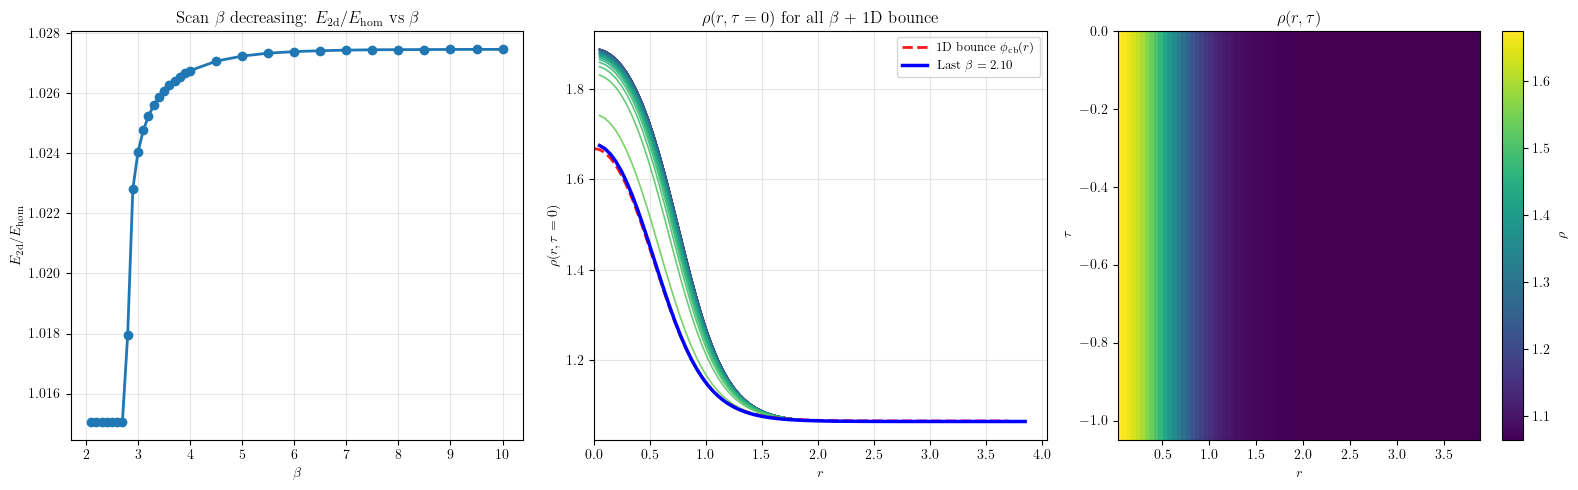

In [ ]:
# ============================================================================
# Beta scan DECRESCENTE: start at β=10, decrease until β=2 (min_beta_down=2)
# Seed: gated solution sol_2d_g. At end: same plots as bubble_2D (E_2d/E_hom vs β, ρ(r,0), ρ(r,τ))
# ============================================================================
from scipy.optimize import brentq
from Q_ball_finder.notebook_utils import resample_complex_field
from Bubble_finder.observables_2d import compute_targets_tau0_ghost
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, NewtonConvergenceError

def compute_ntau_for_beta(beta_i, beta_ref, ntau_ref):
    """Ntau to keep dtau ~ constant."""
    dtau_target = beta_ref / (2.0 * ntau_ref)
    return int(round(0.5 * beta_i / dtau_target))

def solve_at_eta(solver, eta, x0, verbose=False):
    solver.settings.eta0 = float(eta)
    solver.eta0 = float(eta)
    sol = solver.solve(x0, verbose=verbose, verbose_success_block=False)
    return float(sol.Q_tau0.real), sol

def _density_summary(r, q_r, e_r):
    """Return q_max, r_at_q_max, e_max, r_at_e_max from density profiles."""
    if q_r is None or q_r.size == 0:
        return 0.0, 0.0, 0.0, 0.0
    q_max = float(np.max(np.abs(q_r)))
    e_max = float(np.max(np.abs(e_r))) if e_r is not None and e_r.size else 0.0
    r_at_q_max = float(r[int(np.argmax(np.abs(q_r)))])
    r_at_e_max = float(r[int(np.argmax(np.abs(e_r)))]) if e_r is not None and e_r.size else 0.0
    return q_max, r_at_q_max, e_max, r_at_e_max

def eta_scan_at_beta(solver, eta_start, x_seed, Q_target, d_eta=0.02, max_steps=80, tol_Q=1e-6, verbose=True):
    """Eta scan to match Q = Q_target. Returns (eta_star, sol, x_seed, dens_info)."""
    tol_Q = tol_Q * max(1.0, abs(Q_target))
    eta_cache = {}
    eta_cache_precision = 1e-12
    E_Q_ref = solver.omega * Q_target if Q_target else 1.0
    eta_curr = eta_start
    Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
    x_seed = sol_curr.x.copy()
    E_curr = float(sol_curr.E_tau0)
    ratioQ = Q_curr / Q_target if Q_target else 0.0
    ratioE = E_curr / E_Q_ref if E_Q_ref else 0.0
    eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
    if abs(Q_curr - Q_target) < tol_Q:
        Q_g, q_r = solver.compute_charge_tau0_ghost(sol_curr.y, sol_curr.ybar, subtract_background=False, return_profile=True)
        E_g, e_r = solver.compute_energy_tau0_ghost(sol_curr.y, sol_curr.ybar, return_profile=True)
        r = np.asarray(solver.grid.r, float)
        q_max, r_q, e_max, r_e = _density_summary(r, q_r, e_r)
        dens_info = dict(Q=Q_curr, E=E_curr, q_r=q_r, e_r=e_r, r=r, q_max=q_max, e_max=e_max, r_at_q_max=r_q, r_at_e_max=r_e)
        if verbose:
            print(f"[eta-scan] eta* = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
        return eta_curr, sol_curr, x_seed, dens_info
    if verbose:
        print(f"[eta-scan] eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, target = {Q_target:.6e}, ratioQ = {ratioQ:.6f}")
    eta_prev, Q_prev = eta_curr, Q_curr
    for _ in range(max_steps):
        if Q_curr < Q_target:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr += d_eta
        else:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr -= d_eta
        Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
        x_seed = sol_curr.x.copy()
        E_curr = float(sol_curr.E_tau0)
        ratioQ = Q_curr / Q_target if Q_target else 0.0
        ratioE = E_curr / E_Q_ref if E_Q_ref else 0.0
        eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
        if verbose:
            print(f"[eta-scan] try eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, ratioQ = {ratioQ:.6f}")
        if (Q_prev - Q_target) * (Q_curr - Q_target) <= 0:
            break
    else:
        raise RuntimeError("eta scan did not cross Q_target")
    eta_lo, eta_hi = (eta_prev, eta_curr) if Q_prev < Q_target else (eta_curr, eta_prev)
    state = {"x_seed": x_seed}
    def f_eta(eta):
        eta_f = float(eta)
        key = round(eta_f / eta_cache_precision) * eta_cache_precision
        if key in eta_cache:
            q, e, rq, re = eta_cache[key]
            return q - Q_target
        q, s = solve_at_eta(solver, eta_f, state["x_seed"], verbose=False)
        state["x_seed"] = s.x.copy()
        eta_cache[key] = (q, float(s.E_tau0), q / Q_target if Q_target else 0.0, float(s.E_tau0) / E_Q_ref if E_Q_ref else 0.0)
        return q - Q_target
    eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
    _, sol_final = solve_at_eta(solver, eta_star, state["x_seed"], verbose=False)
    x_seed = sol_final.x.copy()
    Q_final = float(sol_final.Q_tau0.real)
    E_final = float(sol_final.E_tau0)
    Q_g, q_r = solver.compute_charge_tau0_ghost(sol_final.y, sol_final.ybar, subtract_background=False, return_profile=True)
    E_g, e_r = solver.compute_energy_tau0_ghost(sol_final.y, sol_final.ybar, return_profile=True)
    r = np.asarray(solver.grid.r, float)
    q_max, r_q, e_max, r_e = _density_summary(r, q_r, e_r)
    dens_info = dict(Q=Q_final, E=E_final, q_r=q_r, e_r=e_r, r=r, q_max=q_max, e_max=e_max, r_at_q_max=r_q, r_at_e_max=r_e)
    if verbose:
        print(f"[eta-scan] eta* = {eta_star:.6f}, charge = {Q_final:.6e}, energy = {E_final:.6e}")
    return eta_star, sol_final, x_seed, dens_info

# Parameters: decrease β from 10 to min_beta_down = 2
beta_start_down = 10.0
beta_step_down = -0.5
min_beta_down = 2.0   # stop when β ≤ 2 (do not go below)
d_eta_down = 0.02

sol_seed = sol_2d_g
eta_seed = 0.0
nr_ref_down = int(sol_seed.grid.Nr)
lr_ref_down = float(Lr_2d_g)
ntau_10 = compute_ntau_for_beta(beta_start_down, float(beta_2d_g), int(sol_seed.grid.Ntau))
ntau_ref_down = ntau_10

settings_10 = Bubble2DSettings(
    Nr=nr_ref_down, Ntau=ntau_10, Lr=lr_ref_down, beta=beta_start_down,
    eta0=eta_seed, omega_ref=omega_2d_g, rho0=rho0_2d_g, rho0_bracket=(V1 * 0.8, V2 + 0.2),
    newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
)
solver_10 = Bubble2DSolver(settings_10, U, dU, d2U)
r_old, tau_old = sol_seed.grid.r, sol_seed.grid.tau
r_new, tau_new = solver_10.grid.r, solver_10.grid.tau
y_new = resample_complex_field(sol_seed.y, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
ybar_new = resample_complex_field(sol_seed.ybar, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
x0_10 = solver_10.pack(y_new, ybar_new)

try:
    sol_newton_10 = solver_10.solve(x0_10, verbose=True, verbose_success_block=False)
    tgt_10 = compute_targets_tau0_ghost(solver_10, subtract_background_charge=False)
    eta_beta_down, sol_beta_down, _, dens_info_10 = eta_scan_at_beta(
        solver_10, eta_seed, sol_newton_10.x.copy(), float(tgt_10["Q"]), d_eta=d_eta_down, verbose=True
    )
except (NewtonConvergenceError, RuntimeError) as e:
    print(f"Failed already at β={beta_start_down}: {e}")
    results_beta_down = []
else:
    _x0 = solver_10._zero_vec()
    _yh, _ybh = solver_10.unpack(_x0)
    E_2d_0 = float(solver_10.compute_energy_tau0_ghost(sol_beta_down.y, sol_beta_down.ybar))
    E_hom_0 = float(solver_10.compute_energy_tau0_ghost(_yh, _ybh))
    results_beta_down = [
        {"beta": beta_start_down, "eta": eta_beta_down, "Q": float(sol_beta_down.Q_tau0.real),
         "E": float(sol_beta_down.E_tau0), "sol": sol_beta_down, "E_2d": E_2d_0, "E_hom": E_hom_0,
         "q_r": dens_info_10.get("q_r"), "e_r": dens_info_10.get("e_r"), "r": dens_info_10.get("r")}
    ]
    print(f"Initial point β={beta_start_down}: η*={eta_beta_down:.6f}, E_2d/E_hom={E_2d_0/E_hom_0:.6f}")

    k = 0
    beta_curr = float(beta_start_down)
    while True:
        step_here = -0.5 if beta_curr > 4.0 else -0.1
        beta_new = beta_curr + step_here
        if beta_new <= 0:
            print("Reached β ≤ 0, stop.")
            break
        if beta_new <= min_beta_down:
            print(f"Reached β_min = {min_beta_down}, stop.")
            break
        ntau_new = compute_ntau_for_beta(beta_new, beta_start_down, ntau_ref_down)
        print("")
        print("=" * 60)
        print(f"Step {k+1}: β = {beta_new:.4f}  (Δβ={step_here:.1f})")
        print("=" * 60)
        try:
            settings_new = Bubble2DSettings(
                Nr=nr_ref_down, Ntau=ntau_new, Lr=lr_ref_down, beta=float(beta_new),
                eta0=eta_beta_down, omega_ref=omega_2d_g, rho0=rho0_2d_g, rho0_bracket=(V1 * 0.8, V2 + 0.2),
                newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
            )
            solver_b = Bubble2DSolver(settings_new, U, dU, d2U)
            r_old, tau_old = sol_beta_down.grid.r, sol_beta_down.grid.tau
            r_new, tau_new = solver_b.grid.r, solver_b.grid.tau
            y_new = resample_complex_field(sol_beta_down.y, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
            ybar_new = resample_complex_field(sol_beta_down.ybar, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
            x0 = solver_b.pack(y_new, ybar_new)
            sol_newton = solver_b.solve(x0, verbose=True, verbose_success_block=False)
            tgt_b = compute_targets_tau0_ghost(solver_b, subtract_background_charge=False)
            Q_target_this = float(tgt_b["Q"])
            eta_beta_down, sol_beta_down, _, dens_info = eta_scan_at_beta(
                solver_b, eta_beta_down, sol_newton.x.copy(), Q_target_this, d_eta=d_eta_down, verbose=True
            )
        except (NewtonConvergenceError, RuntimeError) as e:
            print(f"Stop: failed at β = {beta_new:.4f} — {e}")
            break
        Q_f = dens_info["Q"]
        E_ghost = dens_info["E"]
        E_2d = float(solver_b.compute_energy_tau0_ghost(sol_beta_down.y, sol_beta_down.ybar))
        x_bg_b = solver_b._zero_vec()
        y_hb, yb_hb = solver_b.unpack(x_bg_b)
        E_hom = float(solver_b.compute_energy_tau0_ghost(y_hb, yb_hb))
        results_beta_down.append({
            "beta": float(beta_new), "eta": eta_beta_down, "Q": Q_f, "E": E_ghost,
            "E_2d": E_2d, "E_hom": E_hom, "sol": sol_beta_down,
            "q_r": dens_info.get("q_r"), "e_r": dens_info.get("e_r"), "r": dens_info.get("r"),
        })
        print(f"  η* = {eta_beta_down:.6f}, Q = {Q_f:.6f}, E_2d/E_hom = {E_2d/E_hom:.6f}")
        beta_curr = float(beta_new)
        k += 1

    print("")
    print(f"Decreasing β scan done: {len(results_beta_down)} points (last β = {results_beta_down[-1]['beta']:.2f}).")

# Plots: E_2d/E_hom vs β, ρ(r,τ=0) for all β + 1D bounce, ρ(r,τ) for last
if "results_beta_down" in dir() and len(results_beta_down) > 0:
    betas_down = [r["beta"] for r in results_beta_down]
    E_2d_down = [r["E_2d"] for r in results_beta_down]
    E_hom_down = [r["E_hom"] for r in results_beta_down]
    ratio_down = np.array(E_2d_down) / np.array(E_hom_down)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].plot(betas_down, ratio_down, "o-", lw=2, markersize=6, color="C0")
    axes[0].set_xlabel(r"$\beta$")
    axes[0].set_ylabel(r"$E_{2\mathrm{d}} / E_{\mathrm{hom}}$")
    axes[0].set_title(r"Scan $\beta$ decreasing: $E_{2\mathrm{d}}/E_{\mathrm{hom}}$ vs $\beta$")
    axes[0].grid(True, alpha=0.3)
    cmap_rho = plt.cm.viridis
    n_down = len(results_beta_down)
    for idx, rec in enumerate(results_beta_down):
        sol_i = rec["sol"]
        r_i = np.asarray(sol_i.grid.r, float)
        set_i = Bubble2DSettings(
            Nr=sol_i.grid.Nr, Ntau=sol_i.grid.Ntau,
            Lr=float(sol_i.grid.dr * sol_i.grid.Nr), beta=sol_i.settings.beta,
            eta0=rec["eta"], omega_ref=omega_2d_g, rho0=rho0_2d_g, rho0_bracket=(V1 * 0.8, V2 + 0.2), tau_bc="twisted",
        )
        solver_i = Bubble2DSolver(set_i, U, dU, d2U)
        rho_i = solver_i.rho_map(sol_i.y, sol_i.ybar)[:, 0]
        color = cmap_rho(idx / max(n_down - 1, 1))
        axes[1].plot(r_i, rho_i, "-", lw=1.2, color=color, alpha=0.9)
    axes[1].plot(r_1d_g, phi_1d_g, "r--", lw=2, alpha=0.9, label=r"1D bounce $\phi_{\mathrm{cb}}(r)$")
    last_down = results_beta_down[-1]
    sol_last = last_down["sol"]
    r_last = np.asarray(sol_last.grid.r, float)
    tau_last = np.asarray(sol_last.grid.tau, float)
    settings_last = Bubble2DSettings(
        Nr=sol_last.grid.Nr, Ntau=sol_last.grid.Ntau,
        Lr=float(sol_last.grid.dr * sol_last.grid.Nr), beta=sol_last.settings.beta,
        eta0=last_down["eta"], omega_ref=omega_2d_g, rho0=rho0_2d_g, rho0_bracket=(V1 * 0.8, V2 + 0.2), tau_bc="twisted",
    )
    solver_last = Bubble2DSolver(settings_last, U, dU, d2U)
    rho_2d = solver_last.rho_map(sol_last.y, sol_last.ybar)
    axes[1].plot(r_last, rho_2d[:, 0], "b-", lw=2.5, label=rf"Last $\beta={last_down['beta']:.2f}$")
    axes[1].set_xlabel(r"$r$")
    axes[1].set_ylabel(r"$\rho(r,\tau=0)$")
    axes[1].set_title(r"$\rho(r,\tau=0)$ for all $\beta$ + 1D bounce")
    axes[1].legend(loc="best", fontsize=9)
    axes[1].set_xlim(0, None)
    axes[1].grid(True, alpha=0.3)
    im = axes[2].pcolormesh(r_last, tau_last, rho_2d.T, shading="auto", cmap="viridis")
    axes[2].set_xlabel(r"$r$")
    axes[2].set_ylabel(r"$\tau$")
    axes[2].set_title(r"$\rho(r,\tau)$")
    plt.colorbar(im, ax=axes[2], label=r"$\rho$")
    fig.tight_layout()
    plt.show()
else:
    print("Run the decreasing β scan above first (results_beta_down).")

In [25]:
# ============================================================================
# Beta scan INCREASING: from last β of decreasing scan, step +0.1 until β=4, then step +0.5 until β=10
# Ansatz for each step = previous step solution. Then same plots (E_2d/E_hom, ρ(r,0), ρ(r,τ))
# ============================================================================
beta_target_phase1 = 4.0
beta_step_phase1 = 0.1
beta_target_phase2 = 50.0
beta_step_phase2 = 0.5
d_eta_up = 0.02

if "results_beta_down" not in dir() or len(results_beta_down) == 0:
    print("Run the decreasing β scan cell first (results_beta_down).")
else:
    beta_start_up = float(results_beta_down[-1]["beta"])
    sol_beta_up = results_beta_down[-1]["sol"]
    eta_beta_up = float(results_beta_down[-1]["eta"])
    nr_ref_up = int(sol_beta_up.grid.Nr)
    lr_ref_up = float(sol_beta_up.grid.dr * sol_beta_up.grid.Nr)
    ntau_ref_up = int(sol_beta_up.grid.Ntau)
    beta_ref_up = beta_start_up

    results_beta_to4 = [results_beta_down[-1]]  # include the starting point
    if beta_start_up >= beta_target_phase2:
        print(f"Already at β = {beta_start_up:.2f} >= {beta_target_phase2}, no upward scan.")
    else:
        # Phase 1: step 0.1 from current up to β=4
        if beta_start_up < beta_target_phase1:
            beta_vals_1 = np.arange(beta_start_up + beta_step_phase1, beta_target_phase1 + 0.5 * beta_step_phase1, beta_step_phase1)
            for k, beta_new in enumerate(beta_vals_1):
                ntau_new = compute_ntau_for_beta(beta_new, beta_ref_up, ntau_ref_up)
                print("")
                print("=" * 60)
                print(f"Phase 1 Step {k+1}: β = {beta_new:.4f}  (→ β=4)")
                print("=" * 60)
                try:
                    settings_new = Bubble2DSettings(
                        Nr=nr_ref_up, Ntau=ntau_new, Lr=lr_ref_up, beta=float(beta_new),
                        eta0=eta_beta_up, omega_ref=omega_2d_g, rho0=rho0_2d_g, rho0_bracket=(V1 * 0.8, V2 + 0.2),
                        newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
                    )
                    solver_b = Bubble2DSolver(settings_new, U, dU, d2U)
                    r_old, tau_old = sol_beta_up.grid.r, sol_beta_up.grid.tau
                    r_new, tau_new = solver_b.grid.r, solver_b.grid.tau
                    y_new = resample_complex_field(sol_beta_up.y, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
                    ybar_new = resample_complex_field(sol_beta_up.ybar, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
                    x0 = solver_b.pack(y_new, ybar_new)
                    sol_newton = solver_b.solve(x0, verbose=True, verbose_success_block=False)
                    tgt_b = compute_targets_tau0_ghost(solver_b, subtract_background_charge=False)
                    Q_target_this = float(tgt_b["Q"])
                    eta_beta_up, sol_beta_up, _, dens_info = eta_scan_at_beta(
                        solver_b, eta_beta_up, sol_newton.x.copy(), Q_target_this, d_eta=d_eta_up, verbose=True
                    )
                except (NewtonConvergenceError, RuntimeError) as e:
                    print(f"Stop: failed at β = {beta_new:.4f} — {e}")
                    break
                E_2d = float(solver_b.compute_energy_tau0_ghost(sol_beta_up.y, sol_beta_up.ybar))
                x_bg_b = solver_b._zero_vec()
                y_hb, yb_hb = solver_b.unpack(x_bg_b)
                E_hom = float(solver_b.compute_energy_tau0_ghost(y_hb, yb_hb))
                results_beta_to4.append({
                    "beta": float(beta_new), "eta": eta_beta_up, "Q": dens_info["Q"], "E": dens_info["E"],
                    "E_2d": E_2d, "E_hom": E_hom, "sol": sol_beta_up,
                    "q_r": dens_info.get("q_r"), "e_r": dens_info.get("e_r"), "r": dens_info.get("r"),
                })
                print(f"  η* = {eta_beta_up:.6f}, E_2d/E_hom = {E_2d/E_hom:.6f}")
            print("")
            print(f"Phase 1 done: β up to 4, {len(results_beta_to4)} points so far.")
        # Phase 2: step 0.5 from 4 to 10
        beta_curr_2 = float(results_beta_to4[-1]["beta"])
        if beta_curr_2 < beta_target_phase2:
            beta_ref_phase2 = beta_curr_2
            ntau_ref_phase2 = int(sol_beta_up.grid.Ntau)
            beta_vals_2 = np.arange(beta_curr_2 + beta_step_phase2, beta_target_phase2 + 0.5 * beta_step_phase2, beta_step_phase2)
            for k, beta_new in enumerate(beta_vals_2):
                ntau_new = compute_ntau_for_beta(beta_new, beta_ref_phase2, ntau_ref_phase2)
                print("")
                print("=" * 60)
                print(f"Phase 2 Step {k+1}: β = {beta_new:.4f}  (→ β=10)")
                print("=" * 60)
                try:
                    settings_new = Bubble2DSettings(
                        Nr=nr_ref_up, Ntau=ntau_new, Lr=lr_ref_up, beta=float(beta_new),
                        eta0=eta_beta_up, omega_ref=omega_2d_g, rho0=rho0_2d_g, rho0_bracket=(V1 * 0.8, V2 + 0.2),
                        newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
                    )
                    solver_b = Bubble2DSolver(settings_new, U, dU, d2U)
                    r_old, tau_old = sol_beta_up.grid.r, sol_beta_up.grid.tau
                    r_new, tau_new = solver_b.grid.r, solver_b.grid.tau
                    y_new = resample_complex_field(sol_beta_up.y, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
                    ybar_new = resample_complex_field(sol_beta_up.ybar, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
                    x0 = solver_b.pack(y_new, ybar_new)
                    sol_newton = solver_b.solve(x0, verbose=True, verbose_success_block=False)
                    tgt_b = compute_targets_tau0_ghost(solver_b, subtract_background_charge=False)
                    Q_target_this = float(tgt_b["Q"])
                    eta_beta_up, sol_beta_up, _, dens_info = eta_scan_at_beta(
                        solver_b, eta_beta_up, sol_newton.x.copy(), Q_target_this, d_eta=d_eta_up, verbose=True
                    )
                except (NewtonConvergenceError, RuntimeError) as e:
                    print(f"Stop: failed at β = {beta_new:.4f} — {e}")
                    break
                E_2d = float(solver_b.compute_energy_tau0_ghost(sol_beta_up.y, sol_beta_up.ybar))
                x_bg_b = solver_b._zero_vec()
                y_hb, yb_hb = solver_b.unpack(x_bg_b)
                E_hom = float(solver_b.compute_energy_tau0_ghost(y_hb, yb_hb))
                results_beta_to4.append({
                    "beta": float(beta_new), "eta": eta_beta_up, "Q": dens_info["Q"], "E": dens_info["E"],
                    "E_2d": E_2d, "E_hom": E_hom, "sol": sol_beta_up,
                    "q_r": dens_info.get("q_r"), "e_r": dens_info.get("e_r"), "r": dens_info.get("r"),
                })
                print(f"  η* = {eta_beta_up:.6f}, E_2d/E_hom = {E_2d/E_hom:.6f}")
            print("")
        print(f"Upward β scan to 10 done: {len(results_beta_to4)} points.")

    # Same three plots for results_beta_to4
    if "results_beta_to4" in dir() and len(results_beta_to4) > 0:
        betas_up = [r["beta"] for r in results_beta_to4]
        E_2d_up = [r["E_2d"] for r in results_beta_to4]
        E_hom_up = [r["E_hom"] for r in results_beta_to4]
        ratio_up = np.array(E_2d_up) / np.array(E_hom_up)
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        axes[0].plot(betas_up, ratio_up, "o-", lw=2, markersize=6, color="C0")
        axes[0].set_xlabel(r"$\beta$")
        axes[0].set_ylabel(r"$E_{2\mathrm{d}} / E_{\mathrm{hom}}$")
        axes[0].set_title(r"Scan $\beta$ to 4: $E_{2\mathrm{d}}/E_{\mathrm{hom}}$ vs $\beta$")
        axes[0].grid(True, alpha=0.3)
        cmap_rho = plt.cm.viridis
        n_up = len(results_beta_to4)
        for idx, rec in enumerate(results_beta_to4):
            sol_i = rec["sol"]
            r_i = np.asarray(sol_i.grid.r, float)
            set_i = Bubble2DSettings(
                Nr=sol_i.grid.Nr, Ntau=sol_i.grid.Ntau,
                Lr=float(sol_i.grid.dr * sol_i.grid.Nr), beta=sol_i.settings.beta,
                eta0=rec["eta"], omega_ref=omega_2d_g, rho0=rho0_2d_g, rho0_bracket=(V1 * 0.8, V2 + 0.2), tau_bc="twisted",
            )
            solver_i = Bubble2DSolver(set_i, U, dU, d2U)
            rho_i = solver_i.rho_map(sol_i.y, sol_i.ybar)[:, 0]
            color = cmap_rho(idx / max(n_up - 1, 1))
            axes[1].plot(r_i, rho_i, "-", lw=1.2, color=color, alpha=0.9)
        axes[1].plot(r_1d_g, phi_1d_g, "r--", lw=2, alpha=0.9, label=r"1D bounce $\phi_{\mathrm{cb}}(r)$")
        last_up = results_beta_to4[-1]
        sol_last = last_up["sol"]
        r_last = np.asarray(sol_last.grid.r, float)
        tau_last = np.asarray(sol_last.grid.tau, float)
        settings_last = Bubble2DSettings(
            Nr=sol_last.grid.Nr, Ntau=sol_last.grid.Ntau,
            Lr=float(sol_last.grid.dr * sol_last.grid.Nr), beta=sol_last.settings.beta,
            eta0=last_up["eta"], omega_ref=omega_2d_g, rho0=rho0_2d_g, rho0_bracket=(V1 * 0.8, V2 + 0.2), tau_bc="twisted",
        )
        solver_last = Bubble2DSolver(settings_last, U, dU, d2U)
        rho_2d = solver_last.rho_map(sol_last.y, sol_last.ybar)
        axes[1].plot(r_last, rho_2d[:, 0], "b-", lw=2.5, label=rf"Last $\beta={last_up['beta']:.2f}$")
        axes[1].set_xlabel(r"$r$")
        axes[1].set_ylabel(r"$\rho(r,\tau=0)$")
        axes[1].set_title(r"$\rho(r,\tau=0)$ for all $\beta$ (to 10) + 1D bounce")
        axes[1].legend(loc="best", fontsize=9)
        axes[1].set_xlim(0, None)
        axes[1].grid(True, alpha=0.3)
        im = axes[2].pcolormesh(r_last, tau_last, rho_2d.T, shading="auto", cmap="viridis")
        axes[2].set_xlabel(r"$r$")
        axes[2].set_ylabel(r"$\tau$")
        axes[2].set_title(r"$\rho(r,\tau)$")
        plt.colorbar(im, ax=axes[2], label=r"$\rho$")
        fig.tight_layout()
        plt.show()


Phase 1 Step 1: β = 2.2000  (→ β=4)
[Newton-explicit] iter=01, ||F||=1.284e+00, rhoQ=9.641596e-01, rhoE=-3.838884e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0151
[Newton-explicit] iter=02, ||F||=5.656e-05, rhoQ=9.646600e-01, rhoE=-3.847258e-01, rho_Q/rho_Q_ref=1.0005, rho_E/rho_E_ref=1.0173
[Newton-explicit] iter=03, ||F||=2.268e-11, rhoQ=9.646600e-01, rhoE=-3.847259e-01, rho_Q/rho_Q_ref=1.0005, rho_E/rho_E_ref=1.0173
[eta-scan] eta = -0.016758, charge = 2.311688e+02, target = 2.310489e+02, ratioQ = 1.000519
[eta-scan] try eta = -0.036758, charge = 2.281787e+02, ratioQ = 0.987577
[eta-scan] eta* = -0.017556, charge = 2.310489e+02, energy = -9.199408e+01
  η* = -0.017556, E_2d/E_hom = 1.015074

Phase 1 Step 2: β = 2.3000  (→ β=4)
[Newton-explicit] iter=01, ||F||=1.758e+00, rhoQ=9.636828e-01, rhoE=-3.830857e-01, rho_Q/rho_Q_ref=0.9995, rho_E/rho_E_ref=1.0130
[Newton-explicit] iter=02, ||F||=5.795e-05, rhoQ=9.646382e-01, rhoE=-3.846893e-01, rho_Q/rho_Q_ref=1.0005, rho_E/rho_E_ref=1.0

KeyboardInterrupt: 

**Resample → β=50, Lr=50 (finer grid) → Newton → η₀ scan (match Q) → plot.**

This cell uses as ansatz for resampling the **converged Newton solution with the bubble** from the previous cell (gated bubble → Newton → `sol_2d_g`). That solution is resampled onto a new grid with **β=50**, **Lr=50** and a finer discretization (larger Nr, Nτ); then one Newton solve, an **η₀ scan** (bisection) to match the charge to the homogeneous reference, and the three panels (solution ρ(r,τ), ρ(r_max,τ), ρ(r,0)) without iteration history.

[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
[Newton-explicit] iter=01, ||F||=3.093e+02, rhoQ=9.375806e-01, rhoE=-3.511098e-01, rho_Q/rho_Q_ref=0.9724, rho_E/rho_E_ref=0.9284
[Newton-explicit] iter=02, ||F||=8.062e-02, rhoQ=9.713018e-01, rhoE=-4.003234e-01, rho_Q/rho_Q_ref=1.0074, rho_E/rho_E_ref=1.0585
[Newton-explicit] iter=03, ||F||=8.061e-05, rhoQ=9.713082e-01, rhoE=-4.003314e-01, rho_Q/rho_Q_ref=1.0074, rho_E/rho_E_ref=1.0586
[Newton-explicit] iter=04, ||F||=1.406e-10, rhoQ=9.713082e-01, rhoE=-4.003314e-01, rho_Q/rho_Q_ref=1.0074, rho_E/rho_E_ref=1.0586
[eta-scan] target:  Q_target = 231.0493502615648 ,

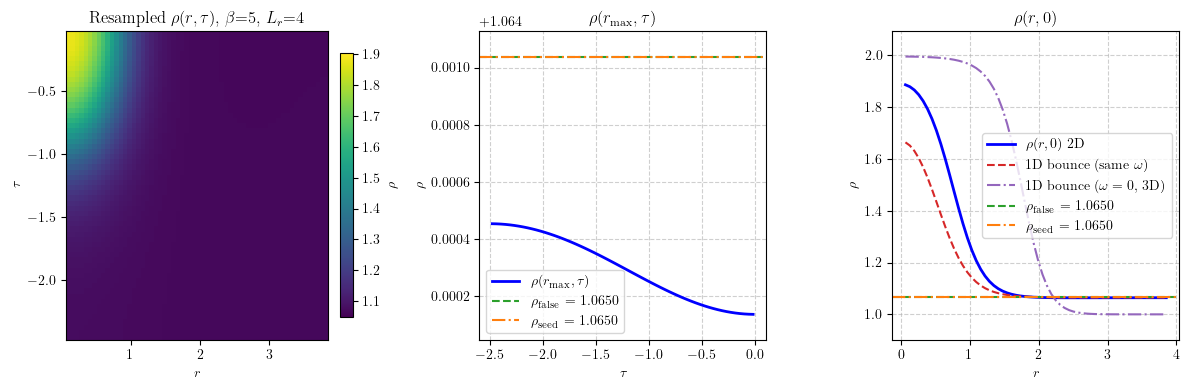

--- Resampled + η scan: full diagnostics ---
  Homogeneous reference: ω = OMEGA = 0.850000
  Grid: β = 5, Lr = 3.8532050930721704, Nr = 60, Nτ = 60
  Volume V = (4/3)π Lr³ = 239.637614
  η₀* = -0.025810

  Solution (2D after resample + Newton + η scan):
    Q(τ=0) = 231.049350,   E(τ=0) = -93.095257
    ρ_Q = Q/V = 0.964161,   ρ_E = E/V = -0.388483

  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):
    Q_hom = 231.049350,   E_hom = -90.628116
    ρ_Q,hom = Q_hom/V = 0.964161,   ρ_E,hom = E_hom/V = -0.378188

  Ratios (solution / homogeneous):  Q/Q_hom = 1.000000,  E/E_hom = 1.027223
  Density ratios:  ρ_Q/ρ_Q,hom = 1.000000,  ρ_E/ρ_E,hom = 1.027223
  Difference (densities):  ρ_Q - ρ_Q,hom = -0.000000,  ρ_E - ρ_E,hom = -0.010295
  Difference:  E - E_hom (H_E) = -2.467141
  Difference:  E_M - E_M_hom(OMEGA) = 2.467141
  F_ω (solution) = -103.296690,  F_ω,hom(OMEGA) = -105.763831
  Difference:  F_ω - F_ω,hom = 2.467141


In [ ]:
# Resample gated solution to beta=50, Lr=50, finer grid → Newton → eta0 scan → plot
from Q_ball_finder.notebook_utils import resample_complex_field
from scipy.optimize import brentq
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver
from Bubble_finder.observables_1d import Q_homogeneous_ball
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d

# New grid: beta=50, Lr=50, finer (more points)
beta_res = 5
Lr_res = r_bounce[-1]
Nr_res = 60
Ntau_res = 60
# Omega per il Newton solver (scegli tu). La configurazione omogenea di riferimento resta sempre a OMEGA.
omega_newton =  0.85 # omega usato nel solver 2D; cambia qui per fare override
rho_false_solver, _ = vacua_of_Omega(PHI0, V1, V2, omega_newton)
omega_res = float(omega_newton)
rho0_res = float(rho_false_solver)
rho_false_res = float(rho_false_solver)
# Riferimento omogeneo: sempre OMEGA (per Q_target, E_hom, diagnostica)
rho_false_ref_res, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)

# Ansatz for resampling: converged Newton solution with the bubble (gated → Newton → sol_2d_g)
r_old = np.asarray(solver_2d_g.grid.r).flatten()
tau_old = np.asarray(solver_2d_g.grid.tau).flatten()
y_old = sol_2d_g.y
ybar_old = sol_2d_g.ybar

# New solver (builds new grid)
settings_res = Bubble2DSettings(
    Nr=Nr_res, Ntau=Ntau_res, Lr=Lr_res, beta=beta_res,
    omega_ref=omega_res, rho0=rho0_res, rho0_bracket=(V1 * 0.8, V2 + 0.2),
    newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
)
solver_res = Bubble2DSolver(settings_res, U, dU, d2U)
r_new = np.asarray(solver_res.grid.r).flatten()
tau_new = np.asarray(solver_res.grid.tau).flatten()

# Resample y, ybar onto new grid
y_res = resample_complex_field(y_old, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
ybar_res = resample_complex_field(ybar_old, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
x0_res = solver_res.pack(y_res, ybar_res)

# One Newton solve (no iteration history)
sol_res = solver_res.solve(x0_res, verbose=True, verbose_success_block=False, store_iteration_history=False)

# eta0 scan: target Q = homogeneous at OMEGA (same grid volume)
V_res = (4.0 / 3.0) * np.pi * Lr_res**3
Q_target_res = float(Q_homogeneous_ball(OMEGA, rho_false_ref_res, Lr_res))
Q_hom_res = float(Q_homogeneous_ball(OMEGA, rho_false_ref_res, Lr_res))
E_hom_res = float(homogeneous_energy_2d(OMEGA, rho_false_ref_res, Lr_res, U))
verbose_eta_scan = True  # set False to silence [eta-scan] lines

def solve_at_eta(solver, eta, x0, verbose=False):
    solver.settings.eta0 = float(eta)
    solver.eta0 = float(eta)
    sol = solver.solve(x0, verbose=verbose, verbose_success_block=False)
    return float(sol.Q_tau0.real), sol

def eta_scan_at_beta(solver, eta_start, x_seed, Q_target, V_ref, Q_hom_ref, E_hom_ref, d_eta=0.05, max_steps=80, tol_Q=1e-6, verbose=True):
    """Bracket eta con Q che attraversa Q_target, poi brentq. Q diminuisce con eta (dQ/dη < 0). Output come bubble_2D."""
    tol_Q = tol_Q * max(1.0, abs(Q_target))
    eta_cache = {}
    eta_cache_precision = 1e-12
    E_Q_ref = E_hom_ref if (E_hom_ref and abs(E_hom_ref) > 1e-30) else 1.0
    eta_curr = eta_start
    Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
    x_seed = sol_curr.x.copy()
    E_curr = float(sol_curr.E_tau0)
    ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
    ratioE = (E_curr / E_Q_ref) if E_Q_ref else 0.0
    eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
    if abs(Q_curr - Q_target) < tol_Q:
        if verbose:
            print(f"[eta-scan] eta* = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
        return eta_curr, sol_curr, x_seed, dict(Q=Q_curr, E=E_curr)
    if verbose:
        print(f"[eta-scan] eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, target = {Q_target:.6e}, ratioQ = {ratioQ:.6f}")
    eta_prev, Q_prev = eta_curr, Q_curr
    for _ in range(max_steps):
        if Q_curr < Q_target:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr += d_eta
        else:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr -= d_eta
        Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
        x_seed = sol_curr.x.copy()
        E_curr = float(sol_curr.E_tau0)
        ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
        ratioE = (E_curr / E_Q_ref) if E_Q_ref else 0.0
        eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
        if verbose:
            print(f"[eta-scan] try eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
        if (Q_prev - Q_target) * (Q_curr - Q_target) <= 0:
            break
    else:
        raise RuntimeError("eta scan did not cross Q_target within max_steps")
    eta_lo, eta_hi = (eta_curr, eta_prev) if Q_prev < Q_target else (eta_prev, eta_curr)
    state = {"x_seed": x_seed}

    def f_eta(eta):
        eta_f = float(eta)
        key = round(eta_f / eta_cache_precision) * eta_cache_precision
        if key in eta_cache:
            q, e, rq, re = eta_cache[key]
            if verbose:
                print(f"[eta-root] eta = {eta_f:.6f} (cached), charge = {q:.6e}, energy = {e:.6e}, ratioQ = {rq:.6f}, ratioE = {re:.6f}")
            return q - Q_target
        q, s = solve_at_eta(solver, eta_f, state["x_seed"], verbose=False)
        state["x_seed"] = s.x.copy()
        e = float(s.E_tau0)
        rq = (q / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
        re = (e / E_Q_ref) if E_Q_ref else 0.0
        eta_cache[key] = (q, e, rq, re)
        if verbose:
            print(f"[eta-root] eta = {eta_f:.6f}, charge = {q:.6e}, energy = {e:.6e}, ratioQ = {rq:.6f}, ratioE = {re:.6f}")
        return q - Q_target

    eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
    _, sol_final = solve_at_eta(solver, eta_star, state["x_seed"], verbose=False)
    x_seed = sol_final.x.copy()
    Q_final = float(sol_final.Q_tau0.real)
    E_final = float(sol_final.E_tau0)
    ratioQ_f = (Q_final / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
    ratioE_f = (E_final / E_Q_ref) if E_Q_ref else 0.0
    if verbose:
        print(f"[eta-scan] eta* = {eta_star:.6f}, charge = {Q_final:.6e}, energy = {E_final:.6e}, ratioQ = {ratioQ_f:.6f}, ratioE = {ratioE_f:.6f}")
    return eta_star, sol_final, x_seed, dict(Q=Q_final, E=E_final)

# Diagnostica target prima dello scan su eta
print("[eta-scan] target:  Q_target =", Q_target_res, ",  E_hom_ref =", E_hom_res, ",  V =", V_res)
print("[eta-scan]         ρ_Q,hom = Q_target/V =", Q_target_res / V_res, ",  ρ_E,hom =", E_hom_res / V_res)

eta_star_res, sol_eta_res, _, dens_res = eta_scan_at_beta(
    solver_res, 0.0, sol_res.x.copy(), Q_target_res, V_res, Q_hom_res, E_hom_res,
    d_eta=0.05, tol_Q=1e-12, verbose=verbose_eta_scan
)
print(f"η₀* = {eta_star_res:.6f},  Q = {dens_res['Q']:.6f},  E = {dens_res['E']:.6f}")

# Solution to plot (after eta scan)
rho_sol_res = solver_res.rho_map(sol_eta_res.y, sol_eta_res.ybar)
tau_res = np.asarray(solver_res.grid.tau).flatten()
r_res = np.asarray(solver_res.grid.r).flatten()
V_res = (4.0 / 3.0) * np.pi * Lr_res**3
vmin_res = float(np.min(rho_sol_res))
vmax_res = float(np.max(rho_sol_res))
delta_res = max(vmax_res - vmin_res, 1e-10)
vmin_res -= 0.02 * delta_res
vmax_res += 0.02 * delta_res

# Three panels (no iterations)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
tau_min_res = float(np.min(tau_res))
tau_max_res = float(np.max(tau_res))
extent_res = (float(r_res[0]), float(r_res[-1]), tau_min_res, tau_max_res)
rho_ordered_res = rho_sol_res.T[np.argsort(tau_res)]
im1 = ax1.imshow(rho_ordered_res, origin="lower", aspect="auto", extent=extent_res, vmin=vmin_res, vmax=vmax_res)
plt.colorbar(im1, ax=ax1, label=r"$\rho$", fraction=0.046, pad=0.04)
ax1.set_xlabel(r"$r$")
ax1.set_ylabel(r"$\tau$")
ax1.set_title(r"Resampled $\rho(r,\tau)$, $\beta$=" + f"{beta_res:.0f}, $L_r$=" + f"{Lr_res:.0f}")

rho_at_rmax_res = rho_sol_res[-1, :]
ax2.plot(tau_res, rho_at_rmax_res, "b-", lw=2, label=r"$\rho(r_{\max},\tau)$")
ax2.axhline(rho_false_res, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_res:.4f}")
ax2.axhline(rho0_res, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho0_res:.4f}")
ymin_2 = min(rho_at_rmax_res.min(), rho_false_res, rho0_res)
ymax_2 = max(rho_at_rmax_res.max(), rho_false_res, rho0_res)
margin_2 = max((ymax_2 - ymin_2) * 0.1, 1e-6)
ax2.set_ylim(ymin_2 - margin_2, ymax_2 + margin_2)
ax2.set_xlabel(r"$\tau$")
ax2.set_ylabel(r"$\rho$")
ax2.set_title(r"$\rho(r_{\max},\tau)$")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.6)

# Slice at τ=0 (index where tau is max)
idx_tau0_res = np.argmax(tau_res)
rho_at_tau0_res = rho_sol_res[:, idx_tau0_res]
# 1D bounces for comparison: same ω and ω=0 (3D)
from Bubble_finder.bounce_1d import solve_bounce
r_1d_same, phi_1d_same, _, _, _ = solve_bounce(
    PHI0, V1, V2, omega_res, d=3, r0=1e-6, rmax=Lr_res, max_iter=150, verbose=False
)
r_1d_w0, phi_1d_w0, _, _, _ = solve_bounce(
    PHI0, V1, V2, 0.0, d=3, r0=1e-6, rmax=Lr_res, max_iter=150, verbose=False
)
ax3.plot(r_res, rho_at_tau0_res, "b-", lw=2, label=r"$\rho(r,0)$ 2D")
phi_1d_same_on_r = np.interp(r_res, r_1d_same, phi_1d_same)
ax3.plot(r_res, phi_1d_same_on_r, "C3--", lw=1.5, label=r"1D bounce (same $\omega$)")
phi_1d_w0_on_r = np.interp(r_res, r_1d_w0, phi_1d_w0)
ax3.plot(r_res, phi_1d_w0_on_r, "C4-.", lw=1.5, label=r"1D bounce ($\omega=0$, 3D)")
ax3.axhline(rho_false_res, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_res:.4f}")
ax3.axhline(rho0_res, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho0_res:.4f}")
ymin_3 = min(rho_at_tau0_res.min(), phi_1d_same_on_r.min(), phi_1d_w0_on_r.min(), rho_false_res, rho0_res)
ymax_3 = max(rho_at_tau0_res.max(), phi_1d_same_on_r.max(), phi_1d_w0_on_r.max(), rho_false_res, rho0_res)
margin_3 = max((ymax_3 - ymin_3) * 0.1, 1e-6)
ax3.set_ylim(ymin_3 - margin_3, ymax_3 + margin_3)
ax3.set_xlabel(r"$r$")
ax3.set_ylabel(r"$\rho$")
ax3.set_title(r"$\rho(r,0)$")
ax3.legend()
ax3.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "resampled_2d_bubble.png", dpi=150, bbox_inches="tight")
plt.show()

# Full diagnostics: 2D solution vs reference homogeneous at OMEGA (V_res, Q_hom_res, E_hom_res already computed above)
rho_Q_hom_res = Q_hom_res / V_res
rho_E_hom_res = E_hom_res / V_res
rho_Q_res = dens_res["Q"] / V_res
rho_E_res = dens_res["E"] / V_res
print("--- Resampled + η scan: full diagnostics ---")
print(f"  Homogeneous reference: ω = OMEGA = {OMEGA:.6f}")
print(f"  Grid: β = {beta_res}, Lr = {Lr_res}, Nr = {Nr_res}, Nτ = {Ntau_res}")
print(f"  Volume V = (4/3)π Lr³ = {V_res:.6f}")
print(f"  η₀* = {eta_star_res:.6f}")
print("")
print("  Solution (2D after resample + Newton + η scan):")
print(f"    Q(τ=0) = {dens_res['Q']:.6f},   E(τ=0) = {dens_res['E']:.6f}")
print(f"    ρ_Q = Q/V = {rho_Q_res:.6f},   ρ_E = E/V = {rho_E_res:.6f}")
print("")
print("  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):")
print(f"    Q_hom = {Q_hom_res:.6f},   E_hom = {E_hom_res:.6f}")
print(f"    ρ_Q,hom = Q_hom/V = {rho_Q_hom_res:.6f},   ρ_E,hom = E_hom/V = {rho_E_hom_res:.6f}")
print("")
print(f"  Ratios (solution / homogeneous):  Q/Q_hom = {dens_res['Q']/Q_hom_res:.6f},  E/E_hom = {dens_res['E']/E_hom_res:.6f}")
print(f"  Density ratios:  ρ_Q/ρ_Q,hom = {rho_Q_res/rho_Q_hom_res:.6f},  ρ_E/ρ_E,hom = {rho_E_res/rho_E_hom_res:.6f}")
print(f"  Difference (densities):  ρ_Q - ρ_Q,hom = {rho_Q_res - rho_Q_hom_res:.6f},  ρ_E - ρ_E,hom = {rho_E_res - rho_E_hom_res:.6f}")
print(f"  Difference:  E - E_hom (H_E) = {dens_res['E'] - E_hom_res:.6f}")
obs_res = getattr(sol_eta_res, "observables_ghost", None) or {}
E_M_hom_res = float(homogeneous_E_M_2d(OMEGA, rho_false_ref_res, Lr_res, U))
if "E_M" in obs_res:
    print(f"  Difference:  E_M - E_M_hom(OMEGA) = {obs_res['E_M'] - E_M_hom_res:.6f}")
if "F_omega" in obs_res:
    F_res = obs_res["F_omega"]
    F_hom_res = E_M_hom_res - OMEGA * Q_hom_res
    print(f"  F_ω (solution) = {F_res:.6f},  F_ω,hom(OMEGA) = {F_hom_res:.6f}")
    print(f"  Difference:  F_ω - F_ω,hom = {F_res - F_hom_res:.6f}")

In [ ]:
# Decay rate exponent (same formula as omega-scan): F^{bounce}_{Q,β} = S_E[φ_b] − S_E[φ_hom] + η₀ Q
from Bubble_finder.rate_exponent import (
    compute_euclidean_action_full,
    compute_homogeneous_action,
    compute_suppression_exponent_bubble,
    make_V_of_s_from_U,
)

V_of_s_res = make_V_of_s_from_U(U)
S_E_2D_res = float(compute_euclidean_action_full(
    sol_eta_res.y, sol_eta_res.ybar, solver_res.grid,
    omega_res, eta_star_res, float(rho0_res), V_of_s_res,
))
S_E_hom_res = float(compute_homogeneous_action(beta_res, V_res, omega_res, float(rho0_res), V_of_s_res))
Q_res_charge = float(sol_eta_res.Q_tau0.real)
F_bounce_res = compute_suppression_exponent_bubble(S_E_2D_res, S_E_hom_res, eta_star_res, Q_res_charge)

print("=== Decay rate exponent (resample solution, same formula as omega-scan) ===")
print("  Formula:  F^{bounce}_{Q,β} = S_E[φ_b] − S_E[φ_hom] + η₀ Q  (rate_exponent.compute_suppression_exponent_bubble)")
print(f"  Grid: β = {beta_res}, Lr = {Lr_res}, V = {V_res:.6f}, ω = {omega_res:.6f}, ρ₀ = {rho0_res:.6f}")
print("  Pieces:")
print(f"    (1) S_E (bounce) = {S_E_2D_res:.8e}")
print(f"    (2) −S_E_hom     = {-S_E_hom_res:.8e}")
print(f"    (3) η₀ Q         = {eta_star_res:.8e} × {Q_res_charge:.6e} = {eta_star_res * Q_res_charge:.8e}")
print(f"  F^{{bounce}}_{{Q,β}} = {F_bounce_res:.8e}")
print("  (Omega-scan at same ω with same β, Lr gives the same formula; compare omega_scan_results for that ω.)")

=== Decay rate exponent (resample solution, same formula as omega-scan) ===
  Formula:  F^{bounce}_{Q,β} = S_E[φ_b] − S_E[φ_hom] + η₀ Q  (rate_exponent.compute_suppression_exponent_bubble)
  Grid: β = 15, Lr = 15, V = 14137.166941, ω = 0.850000, ρ₀ = 1.065039
  Pieces:
    (1) S_E (bounce) = -2.67363262e+05
    (2) −S_E_hom     = 2.67380397e+05
    (3) η₀ Q         = -4.35962110e-04 × 1.363051e+04 = -5.94238653e+00
  F^{bounce}_{Q,β} = 1.11927445e+01
  (Omega-scan at same ω with same β, Lr gives the same formula; compare omega_scan_results for that ω.)


=== η scan: match energia omogenea (E = E_hom) ===
  E_target = E_hom_res = -9.06281163e+01
  Seed: sol_res (Newton pre η)

[eta-scan E] eta = 0.000000, E = -9.386832e+01, target E = -9.062812e+01
[eta-scan E] eta = -0.050000, E = -9.248859e+01
[eta-scan E] eta = -0.100000, E = -9.111711e+01
[eta-scan E] eta = -0.150000, E = -8.975378e+01
[eta-scan E] eta* = -0.117900, E = -9.062812e+01, Q = 2.295404e+02

--- Risultato: η₀* (match E = E_hom) ---
  η₀* = -0.11789958
  Q (soluzione) = 2.29540378e+02   (omogeneo Q_hom = 2.31049350e+02)
  E (soluzione) = -9.06281163e+01   (target E_hom = -9.06281163e+01)
  E - E_hom = 7.105427e-14
  Q/Q_hom = 0.993469
  Confronto con scan a Q: η₀* (match Q) = -0.027262,  η₀* (match E) = -0.117900


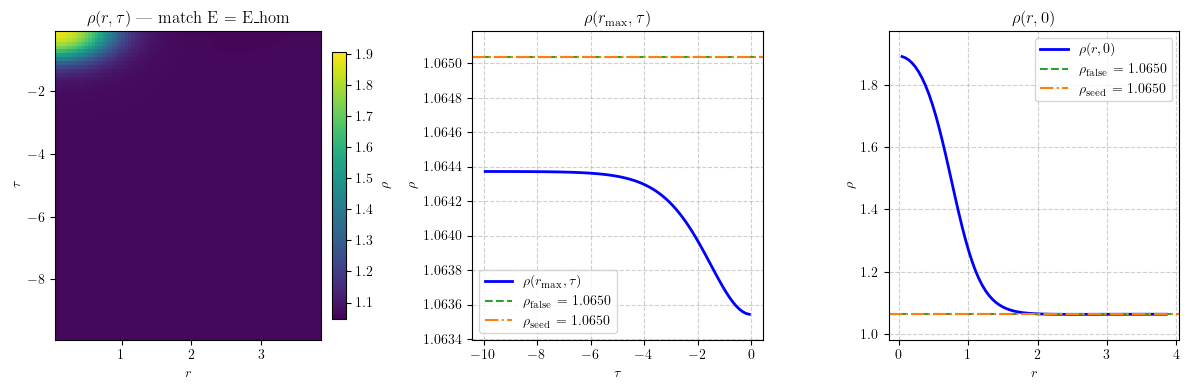

In [ ]:
# ============================================================================
# Scan su η₀ matching l'energia della configurazione omogenea (E = E_hom), non la carica
# Usa stesso solver_res e seed da sol_res (Newton pre η); target E_target = E_hom_res
# ============================================================================
from scipy.optimize import brentq

def solve_at_eta(solver, eta, x0, verbose=False):
    solver.settings.eta0 = float(eta)
    solver.eta0 = float(eta)
    sol = solver.solve(x0, verbose=verbose, verbose_success_block=False)
    return float(sol.E_tau0), sol

def eta_scan_match_E(solver, eta_start, x_seed, E_target, d_eta=0.05, max_steps=80, tol_E=1e-8, verbose=True):
    """Bracket eta con E che attraversa E_target, poi brentq. Output: eta_star, sol, dens_info."""
    tol_E = tol_E * max(1.0, abs(E_target))
    eta_curr = eta_start
    E_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
    x_seed = sol_curr.x.copy()
    if abs(E_curr - E_target) < tol_E:
        if verbose:
            print(f"[eta-scan E] eta* = {eta_curr:.6f}, E = {E_curr:.6e}, Q = {sol_curr.Q_tau0.real:.6e}")
        return eta_curr, sol_curr, dict(Q=float(sol_curr.Q_tau0.real), E=E_curr)
    if verbose:
        print(f"[eta-scan E] eta = {eta_curr:.6f}, E = {E_curr:.6e}, target E = {E_target:.6e}")
    eta_prev, E_prev = eta_curr, E_curr
    for _ in range(max_steps):
        if E_curr < E_target:
            eta_prev, E_prev = eta_curr, E_curr
            eta_curr -= d_eta
        else:
            eta_prev, E_prev = eta_curr, E_curr
            eta_curr += d_eta
        E_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
        x_seed = sol_curr.x.copy()
        if verbose:
            print(f"[eta-scan E] eta = {eta_curr:.6f}, E = {E_curr:.6e}")
        if (E_prev - E_target) * (E_curr - E_target) <= 0:
            break
    else:
        raise RuntimeError("eta scan did not cross E_target within max_steps")
    eta_lo, eta_hi = (eta_prev, eta_curr) if eta_prev < eta_curr else (eta_curr, eta_prev)
    state = {"x_seed": x_seed}

    def f_eta(eta):
        e, s = solve_at_eta(solver, float(eta), state["x_seed"], verbose=False)
        state["x_seed"] = s.x.copy()
        return e - E_target

    eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
    _, sol_final = solve_at_eta(solver, eta_star, state["x_seed"], verbose=False)
    Q_final = float(sol_final.Q_tau0.real)
    E_final = float(sol_final.E_tau0)
    if verbose:
        print(f"[eta-scan E] eta* = {eta_star:.6f}, E = {E_final:.6e}, Q = {Q_final:.6e}")
    return eta_star, sol_final, dict(Q=Q_final, E=E_final)

# Target = energia omogenea (stesso volume della griglia resample)
E_target_E_scan = E_hom_res
print("=== η scan: match energia omogenea (E = E_hom) ===")
print(f"  E_target = E_hom_res = {E_target_E_scan:.8e}")
print(f"  Seed: sol_res (Newton pre η)\n")

eta_star_E_res, sol_eta_E_res, dens_E_res = eta_scan_match_E(
    solver_res, 0.0, sol_res.x.copy(), E_target_E_scan,
    d_eta=0.05, max_steps=80, tol_E=1e-10, verbose=True
)

print("\n--- Risultato: η₀* (match E = E_hom) ---")
print(f"  η₀* = {eta_star_E_res:.8f}")
print(f"  Q (soluzione) = {dens_E_res['Q']:.8e}   (omogeneo Q_hom = {Q_hom_res:.8e})")
print(f"  E (soluzione) = {dens_E_res['E']:.8e}   (target E_hom = {E_hom_res:.8e})")
print(f"  E - E_hom = {dens_E_res['E'] - E_hom_res:.6e}")
print(f"  Q/Q_hom = {dens_E_res['Q']/Q_hom_res:.6f}")
print(f"  Confronto con scan a Q: η₀* (match Q) = {eta_star_res:.6f},  η₀* (match E) = {eta_star_E_res:.6f}")

# Tre plot: ρ(r,τ), ρ(r_max, τ), ρ(r, 0) — soluzione finale (match E)
rho_sol_E = solver_res.rho_map(sol_eta_E_res.y, sol_eta_E_res.ybar)
tau_E = np.asarray(solver_res.grid.tau).flatten()
r_E = np.asarray(solver_res.grid.r).flatten()
vmin_E = float(np.min(rho_sol_E))
vmax_E = float(np.max(rho_sol_E))
delta_E = max(vmax_E - vmin_E, 1e-10)
vmin_E -= 0.02 * delta_E
vmax_E += 0.02 * delta_E

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
extent_E = (float(r_E[0]), float(r_E[-1]), float(tau_E.min()), float(tau_E.max()))
rho_ordered_E = rho_sol_E.T[np.argsort(tau_E)]
im1 = ax1.imshow(rho_ordered_E, origin="lower", aspect="auto", extent=extent_E, vmin=vmin_E, vmax=vmax_E)
plt.colorbar(im1, ax=ax1, label=r"$\rho$", fraction=0.046, pad=0.04)
ax1.set_xlabel(r"$r$")
ax1.set_ylabel(r"$\tau$")
ax1.set_title(r"$\rho(r,\tau)$ — match E = E_hom")

rho_rmax_E = rho_sol_E[-1, :]
ax2.plot(tau_E, rho_rmax_E, "b-", lw=2, label=r"$\rho(r_{\max},\tau)$")
ax2.axhline(rho_false_res, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_res:.4f}")
ax2.axhline(rho0_res, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho0_res:.4f}")
ymin_2 = min(rho_rmax_E.min(), rho_false_res, rho0_res)
ymax_2 = max(rho_rmax_E.max(), rho_false_res, rho0_res)
margin_2 = max((ymax_2 - ymin_2) * 0.1, 1e-6)
ax2.set_ylim(ymin_2 - margin_2, ymax_2 + margin_2)
ax2.set_xlabel(r"$\tau$")
ax2.set_ylabel(r"$\rho$")
ax2.set_title(r"$\rho(r_{\max},\tau)$")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.6)

idx_tau0_E = np.argmax(tau_E)
rho_tau0_E = rho_sol_E[:, idx_tau0_E]
ax3.plot(r_E, rho_tau0_E, "b-", lw=2, label=r"$\rho(r,0)$")
ax3.axhline(rho_false_res, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_res:.4f}")
ax3.axhline(rho0_res, color="C1", ls="-.", lw=1.5, label=rf"$\rho_{{\mathrm{{seed}}}}$ = {rho0_res:.4f}")
ymin_3 = min(rho_tau0_E.min(), rho_false_res, rho0_res)
ymax_3 = max(rho_tau0_E.max(), rho_false_res, rho0_res)
margin_3 = max((ymax_3 - ymin_3) * 0.1, 1e-6)
ax3.set_ylim(ymin_3 - margin_3, ymax_3 + margin_3)
ax3.set_xlabel(r"$r$")
ax3.set_ylabel(r"$\rho$")
ax3.set_title(r"$\rho(r,0)$")
ax3.legend()
ax3.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
try:
    fig.savefig(FIGURES_DIR / "resampled_2d_bubble_match_E.png", dpi=150, bbox_inches="tight")
except NameError:
    pass
plt.show()

## Branch selection: forcing τ-dependence (A-scan)

This section implements a **continuation in amplitude A** to steer Newton away from the static (sphaleron) branch and toward the **bounce** branch. A τ-localized modulation template \(g(\tau)\) and a radial profile \(\delta\rho(r)\) are combined into a family of initial guesses \(\rho_\mathrm{guess}(\tau,r) = \rho_\mathrm{hom} + A\,\delta\rho(r)\,g(\tau)\). For each \(A\), Newton is run; we record Q, E_M at τ=0 (ghost), a τ-dependence measure, and slicewise \(E_\mathrm{static}(\tau)\). The bounce branch typically shows stronger τ-dependence and a different \(E_\mathrm{static}(\tau)\) shape than the sphaleron (\(A=0\)).

In [20]:
# ============================================================================
# Branch fishing: multi-start τ-Fourier seeds (periodic), solve, deflate-by-filter
# Goal: find ANY τ-dependent converged solution (bounce-like candidate) instead
#       of always falling back to τ-independent trivial branch.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt

from Bubble_finder.observables_2d import (
    compute_charge_tau0_ghost_2d,
    compute_energy_minkowski_tau0_ghost_2d,
)
from dataclasses import replace
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, NewtonConvergenceError

# ---------------------------
# Reuse existing solver/solution
# ---------------------------
try:
    solver = solver_res
    sol_ref = sol_eta_res
except NameError:
    try:
        solver = solver_2d_g
        sol_ref = sol_2d_g
    except NameError:
        raise NameError("Need solver_res/sol_eta_res or solver_2d_g/sol_2d_g in scope.")

# Use 70 Newton iterations only in this cell
solver = Bubble2DSolver(replace(solver.settings, newton_max_iter=70), solver.U, solver.dU, solver.d2U)

tau = np.asarray(solver.grid.tau).flatten()
r   = np.asarray(solver.grid.r).flatten()
Nr, Nt = len(r), len(tau)

rho0  = float(solver.rho0)
omega = float(solver.omega)

# Sanity for gradients (r must be increasing; tau: build sorted view if not monotonic)
if not np.all(np.diff(r) > 0):
    raise ValueError("r grid must be strictly increasing.")

if np.all(np.diff(tau) > 0):
    tau_sorted = tau
    sort_idx_tau = np.arange(Nt)
else:
    sort_idx_tau = np.argsort(tau)
    tau_sorted = np.asarray(tau)[sort_idx_tau]

beta = float(tau.max() - tau.min())

# Choose turning slice convention (adjust if your turning slice is at beta/2)
tau_turn = 0.5 * (tau.min() + tau.max())
it_turn = int(np.argmin(np.abs(tau - tau_turn)))
it_turn_sorted = int(np.argmin(np.abs(tau_sorted - tau_turn)))

# ---------------------------
# Reference "banal" solution x_banal for distance-based filtering.
# We'll take the A=0 solution from a quick solve starting at homogeneous.
# If you already have it stored, replace this block.
# ---------------------------
# Homogeneous guess: rho=rho0 -> y=0
y_hom = np.zeros((Nr, Nt), dtype=complex)
ybar_hom = np.zeros_like(y_hom)
x_hom = solver.pack(y_hom, ybar_hom)

try:
    sol_banal = solver.solve(x_hom, verbose=False, verbose_success_block=False)
except Exception:
    sol_banal = None

if sol_banal is None:
    raise RuntimeError("Could not obtain banal reference solution from homogeneous guess.")

x_banal = solver.pack(sol_banal.y, sol_banal.ybar)

def xdist(xa, xb):
    # simple euclidean distance in packed space
    d = xa - xb
    return float(np.sqrt(np.vdot(d, d).real))

# ---------------------------
# Radial deformation δρ(r)
# Prefer 1D bounce if available; else use turning slice of sol_ref; else use banal slice.
# ---------------------------
if "r_1d_g" in dir() and "phi_1d_g" in dir():
    rho_1d_on_r = np.interp(r, r_1d_g, phi_1d_g, left=phi_1d_g[0], right=phi_1d_g[-1])
    rho_hom = float(rho0)
    delta_rho = rho_1d_on_r - rho_hom
else:
    phi_ref, phibar_ref = solver.phi(sol_ref.y, sol_ref.ybar)  # (Nr, Nt)
    u_turn = (phi_ref[:, it_turn] * phibar_ref[:, it_turn]).real
    rho_ref_r = np.sqrt(np.maximum(u_turn, 0.0))
    rho_hom = float(rho_ref_r[-1])
    delta_rho = rho_ref_r - rho_hom

delta_rho = np.asarray(delta_rho, dtype=float).flatten()
assert delta_rho.shape == (Nr,)

# ---------------------------
# Periodic localized envelope in τ (optional but helps "bounce-like" localization)
# ---------------------------
Delta = 0.15 * beta

def wrap_periodic(dt, beta):
    # porta dt in [-beta/2, +beta/2]
    return (dt + 0.5*beta) % beta - 0.5*beta

def periodic_gauss_min_dist(t, t0, Delta, beta):
    dt = wrap_periodic(t - t0, beta)
    g = np.exp(-(dt/Delta)**2)
    return g / g.max()

g_tau = periodic_gauss_min_dist(tau, tau_turn, Delta, beta)
g_tau = g_tau - g_tau.mean()   # opzionale: togli DC


# ---------------------------
# Fourier basis (periodic, zero mean automatically for sin/cos with n>=1)
# We'll combine few low modes randomly.
# ---------------------------
def fourier_mix(tau, beta, nmodes=3, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    g = np.zeros_like(tau, dtype=float)
    # random coefficients for cos/sin modes
    for n in range(1, nmodes + 1):
        a = rng.normal()
        b = rng.normal()
        g += a * np.cos(2*np.pi*n*(tau - tau_turn)/beta) + b * np.sin(2*np.pi*n*(tau - tau_turn)/beta)
    # normalize amplitude
    g -= g.mean()
    m = np.max(np.abs(g))
    if m > 0:
        g /= m
    return g

# ---------------------------
# Diagnostics potential term (as in your previous cell)
# ---------------------------
def _V_of_s(s):
    return solver.U(np.sqrt(np.maximum(np.asarray(s), 0.0)))

def slicewise_energies(sol):
    phi_nt, phibar_nt = solver.phi(sol.y, sol.ybar)  # (Nr,Nt)
    phi_nt_ord   = phi_nt[:, sort_idx_tau]
    phibar_nt_ord = phibar_nt[:, sort_idx_tau]
    phi_t   = np.asarray(phi_nt_ord.T)    # (Nt,Nr) ordered by tau_sorted
    phibar_t = np.asarray(phibar_nt_ord.T)

    dphi_dtau    = np.gradient(phi_t,    tau_sorted, axis=0, edge_order=2)
    dphibar_dtau = np.gradient(phibar_t, tau_sorted, axis=0, edge_order=2)
    dphi_dr      = np.gradient(phi_t,    r,   axis=1, edge_order=2)
    dphibar_dr   = np.gradient(phibar_t, r,   axis=1, edge_order=2)

    tau_kin = (dphi_dtau * dphibar_dtau).real
    spatial = (dphi_dr   * dphibar_dr).real
    s = (phi_t * phibar_t).real
    V_term = _V_of_s(np.maximum(s, 0.0))

    pref = 4.0*np.pi
    E_static = pref * np.trapz((spatial + V_term) * r**2, r, axis=1)
    E_full   = pref * np.trapz((tau_kin + spatial + V_term) * r**2, r, axis=1)
    return E_static, E_full

# ---------------------------
# Multi-start scan parameters
# ---------------------------
N_trials = 20          # increase to 50 if needed
A0       = 0.8         # base amplitude (tune)
nmodes   = 3           # 2-4 usually enough
amp_tol  = 1e-3        # τ-dependence threshold
dist_tol = 1e-6        # "too close to banal" threshold (tune if needed)

# envelope in τ: usare sempre g_tau della griglia corrente (stessa lunghezza di tau)
# così si evita ValueError se env viene da un'altra cella con griglia diversa
env = g_tau

rng = np.random.default_rng(1234)

candidates = []
all_runs = []

# --- Parametri globali usati in tutti i trial (stampa una volta) ---
print("=== Parametri globali ===")
print(f"  Grid: Nr={Nr}, Nt={Nt}, beta={beta:.4f}, tau in [{tau.min():.4f}, {tau.max():.4f}]")
print(f"  Solver: rho0={rho0}, omega={omega}, newton_max_iter={solver.settings.newton_max_iter}")
print(f"  Seed: rho_hom={rho_hom:.6f}, delta_rho: min={delta_rho.min():.4e}, max={delta_rho.max():.4e}")
print(f"  Scan: N_trials={N_trials}, A0={A0}, nmodes={nmodes}, amp_tol={amp_tol}, dist_tol={dist_tol}")
print(f"  Envelope: Delta={Delta}, tau_turn={tau_turn:.4f}")
print()

for k in range(N_trials):
    print(f"-------- Trial {k+1}/{N_trials} --------")

    # Step 1: Random τ-shape (Fourier mix)
    # Uso: fourier_mix(tau, beta, nmodes, rng) → g normalizzato zero-mean
    g = fourier_mix(tau, beta, nmodes=nmodes, rng=rng)
    print(f"  [1] Fourier seed: nmodes={nmodes}, g: min={g.min():.4e}, max={g.max():.4e}, mean≈{g.mean():.4e}")

    # Step 2: Moltiplico per envelope localizzato in τ
    # Uso: env (g_tau o variabile env già definita)
    g = g * env
    print(f"  [2] Dopo envelope: g*env: min={g.min():.4e}, max={g.max():.4e}")

    # Step 3: Costruisco rho_guess(τ,r) = rho_hom + A0 * delta_rho(r) * g(τ)
    # Parametri: A0, delta_rho (1D su r), g (1D su τ)
    rho_guess = rho_hom + A0 * delta_rho[None, :] * g[:, None]   # (Nt,Nr)
    print(f"  [3] rho_guess: shape={rho_guess.shape}, min={rho_guess.min():.4e}, max={rho_guess.max():.4e} (A0={A0})")

    # Step 4: Pack in variabili solver (campo reale: y = r*(rho - rho0), ybar = y)
    # Uso: solver.pack(y_guess, ybar_guess), con y_guess (Nr,Nt)
    y_guess = (r[:, None] * (rho_guess.T - rho0)).astype(complex)  # (Nr,Nt)
    ybar_guess = y_guess.copy()
    x0 = solver.pack(y_guess, ybar_guess)
    print(f"  [4] x0 packed: len(x0)={len(x0)}")

    # Step 5: Newton solve
    # Uso: solver.solve(x0), verbose=True
    converged = False
    sol = None
    try:
        sol = solver.solve(x0, verbose=True, verbose_success_block=False)
        converged = getattr(sol, "success", True)
        print(f"  [5] Solve: converged={converged}")
    except (NewtonConvergenceError, RuntimeError, Exception) as e:
        converged = False
        sol = None
        print(f"  [5] Solve: FAILED ({type(e).__name__})")

    rec = {"trial": k, "converged": converged, "sol": sol}

    if converged and sol is not None:
        # [6] Distanza da soluzione banale (x_banal da homogeneous solve)
        x_sol = solver.pack(sol.y, sol.ybar)
        rec["dist_banal"] = xdist(x_sol, x_banal)
        print(f"  [6] dist_banal={rec['dist_banal']:.4e} (soglia dist_tol={dist_tol})")

        # [7] Ampiezza dipendenza da τ (rho a r0_idx, confronto con slice it_turn)
        rho_map = solver.rho_map(sol.y, sol.ybar)  # (Nr,Nt)
        r0_idx = min(1, Nr-1)
        rec["amp_tau"] = float(np.max(np.abs(rho_map[r0_idx, :] - rho_map[r0_idx, it_turn])))
        print(f"  [7] amp_tau={rec['amp_tau']:.4e} (r0_idx={r0_idx}, it_turn={it_turn}, soglia amp_tol={amp_tol})")

        # [8] Osservabili ghost a τ=0
        rec["Q_ghost"] = float(compute_charge_tau0_ghost_2d(solver, sol.y, sol.ybar, subtract_background=False))
        rec["E_M_ghost"] = float(compute_energy_minkowski_tau0_ghost_2d(solver, sol.y, sol.ybar))
        print(f"  [8] Q_ghost={rec['Q_ghost']:.4f}, E_M_ghost={rec['E_M_ghost']:.4f}")

        # [9] Energie per slice (slicewise_energies: E_static, E_full su tau_sorted)
        E_static, E_full = slicewise_energies(sol)
        rec["E_static_tau"] = E_static
        rec["E_full_tau"] = E_full
        rec["delta_E_static"] = float(np.max(E_static) - np.min(E_static))
        rec["Estatic_at_turn"] = float(E_static[it_turn_sorted])
        rec["Estatic_min"] = float(np.min(E_static))
        rec["Estatic_max"] = float(np.max(E_static))
        print(f"  [9] E_static: min={rec['Estatic_min']:.4f}, max={rec['Estatic_max']:.4f}, delta_E_static={rec['delta_E_static']:.4e}")

        # [10] Filtro candidato: dist_banal > dist_tol AND amp_tau > amp_tol AND delta_E_static > 0
        is_candidate = (rec["dist_banal"] > dist_tol) and (rec["amp_tau"] > amp_tol) and (rec["delta_E_static"] > 0.0)
        if is_candidate:
            candidates.append(rec)
            print(f"  [10] CANDIDATE (passa filtro)")
        else:
            print(f"  [10] scartato (dist_tol/amp_tol/delta_E_static)")

    all_runs.append(rec)

# ---------------------------
# Print summary
# ---------------------------
print("Multi-start τ-Fourier scan:")
print(f"  trials: {N_trials}")
print(f"  converged: {sum(1 for rr in all_runs if rr['converged'])}")
print(f"  candidates (τ-dependent & far from banal): {len(candidates)}\n")

print(f"{'trial':>5} {'dist':>12} {'amp_tau':>10} {'dE_static':>12} {'Q_ghost':>10} {'E_M_ghost':>10}")
print("-"*70)
for rr in candidates[:10]:
    print(f"{rr['trial']:>5d} {rr['dist_banal']:>12.4e} {rr['amp_tau']:>10.4e} {rr['delta_E_static']:>12.4e} "
          f"{rr['Q_ghost']:>10.4f} {rr['E_M_ghost']:>10.4f}")

# ---------------------------
# Plot best 3 candidates by amp_tau
# ---------------------------
if len(candidates) == 0:
    print("\nNo non-banal τ-dependent candidates found. Try increasing N_trials, A0, nmodes, or tightening/loosening tolerances.")
else:
    candidates.sort(key=lambda x: -(x["amp_tau"] if np.isfinite(x["amp_tau"]) else -np.inf))
    best = candidates[:3]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
    for rr in best:
        ax1.plot(tau_sorted, rr["E_static_tau"], label=f"trial={rr['trial']} amp={rr['amp_tau']:.2e}")
        if rr.get("E_full_tau") is not None:
            ax2.plot(tau_sorted, rr["E_full_tau"], label=f"trial={rr['trial']}")
    ax1.axvline(tau_sorted[it_turn_sorted], linestyle="--", linewidth=1.0)
    ax2.axvline(tau_sorted[it_turn_sorted], linestyle="--", linewidth=1.0)
    ax1.set_xlabel(r"$\tau$")
    ax1.set_ylabel(r"$E_{\mathrm{static}}(\tau)$")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.set_xlabel(r"$\tau$")
    ax2.set_ylabel(r"$E_{\mathrm{full,Euclid}}(\tau)$")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

=== Parametri globali ===
  Grid: Nr=60, Nt=60, beta=2.4583, tau in [-2.4792, -0.0208]
  Solver: rho0=1.0650387757802888, omega=0.85, newton_max_iter=70
  Seed: rho_hom=1.065039, delta_rho: min=4.3728e-06, max=5.9882e-01
  Scan: N_trials=20, A0=0.8, nmodes=3, amp_tol=0.001, dist_tol=1e-06
  Envelope: Delta=0.36874999999999997, tau_turn=-1.2500

-------- Trial 1/20 --------
  [1] Fourier seed: nmodes=3, g: min=-9.4057e-01, max=1.0000e+00, mean≈2.0354e-17
  [2] Dopo envelope: g*env: min=-4.4469e-01, max=2.8151e-01
  [3] rho_guess: shape=(60, 60), min=8.5201e-01, max=1.1999e+00 (A0=0.8)
  [4] x0 packed: len(x0)=14400
  [5] Solve: FAILED (NewtonConvergenceError)
-------- Trial 2/20 --------
  [1] Fourier seed: nmodes=3, g: min=-1.0000e+00, max=4.4228e-01, mean≈1.8504e-18
  [2] Dopo envelope: g*env: min=-6.7715e-01, max=6.4279e-02
  [3] rho_guess: shape=(60, 60), min=7.4065e-01, max=1.0958e+00 (A0=0.8)
  [4] x0 packed: len(x0)=14400
  [5] Solve: FAILED (NewtonConvergenceError)
-------- Tria

/tmp/ipykernel_38577/1289694215.py:162: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_static = pref * np.trapz((spatial + V_term) * r**2, r, axis=1)
/tmp/ipykernel_38577/1289694215.py:163: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_full   = pref * np.trapz((tau_kin + spatial + V_term) * r**2, r, axis=1)


[Newton-explicit] iter=02, ||F||=5.698e+08, rhoQ=9.567692e-01, rhoE=-3.656644e-01, rho_Q/rho_Q_ref=0.9923, rho_E/rho_E_ref=0.9669
[Newton-explicit] iter=03, ||F||=1.446e+08, rhoQ=9.568622e-01, rhoE=-3.658202e-01, rho_Q/rho_Q_ref=0.9924, rho_E/rho_E_ref=0.9673
[Newton-explicit] iter=04, ||F||=3.643e+07, rhoQ=9.568654e-01, rhoE=-3.658256e-01, rho_Q/rho_Q_ref=0.9924, rho_E/rho_E_ref=0.9673
[Newton-explicit] iter=05, ||F||=9.145e+06, rhoQ=9.568666e-01, rhoE=-3.658275e-01, rho_Q/rho_Q_ref=0.9924, rho_E/rho_E_ref=0.9673
[Newton-explicit] iter=06, ||F||=2.291e+06, rhoQ=9.568681e-01, rhoE=-3.658301e-01, rho_Q/rho_Q_ref=0.9924, rho_E/rho_E_ref=0.9673
[Newton-explicit] iter=07, ||F||=5.733e+05, rhoQ=9.568749e-01, rhoE=-3.658415e-01, rho_Q/rho_Q_ref=0.9924, rho_E/rho_E_ref=0.9674
[Newton-explicit] iter=08, ||F||=1.437e+05, rhoQ=9.569352e-01, rhoE=-3.659434e-01, rho_Q/rho_Q_ref=0.9925, rho_E/rho_E_ref=0.9676
[Newton-explicit] iter=09, ||F||=1.144e+05, rhoQ=9.569220e-01, rhoE=-3.659212e-01, rho_Q/r

KeyboardInterrupt: 

### Bounce from sphaleron (negative-mode descent)

Use **find_bounce_from_sphaleron** to get a bounce by perturbing the sphaleron along the unstable direction of the Jacobian and running Newton. Requires `solver_res` and `sol_eta_res` (or `solver_2d_g` / `sol_2d_g`) from the resample / gated section above.

In [12]:
# Bubble_finder.branching: use the module from disk (relative imports fail when code is pasted in a notebook).
# Public API: slicewise_energies, recenter_solution_in_tau, find_bounce_from_sphaleron
from Bubble_finder.branching import find_bounce_from_sphaleron, slicewise_energies, recenter_solution_in_tau


In [10]:
# Bounce from sphaleron: negative-mode seeds → Newton
from Bubble_finder.branching import find_bounce_from_sphaleron, slicewise_energies, recenter_solution_in_tau
import matplotlib.pyplot as plt
import numpy as np

# Use same solver/solution as in Branch fishing (solver_res + sol_eta_res, or solver_2d_g + sol_2d_g)
try:
    _solver_branch = solver_res
    _sol_sph = sol_eta_res
except NameError:
    try:
        _solver_branch = solver_2d_g
        _sol_sph = sol_2d_g
    except NameError:
        raise NameError("Run the resample cell (solver_res, sol_eta_res) or gated cell (solver_2d_g, sol_2d_g) first.")

best_bounce, diag = find_bounce_from_sphaleron(
    _solver_branch,
    _sol_sph,
    eps_list=np.logspace(-6, -1, 3),
    max_tries=30,
    tau_turn=None,
    verbose=True,
    solve_verbose=False,
)

  [branching] negative mode (sym): lambda_min = -1.556988e+03, asym_ratio=3.324e-02

--- find_bounce_from_sphaleron: pinned negative-mode scan ---
  tau_turn = 0.0000
  dist(x_sph, x_banal) = 4.537513e+00
  eps_list: [1e-06, 0.00031622776601683794, 0.1]
  amp_tol=0.001 dist_tol_sph=1e-06 dist_tol_banal=1e-06
       eps sgn  pin  rel    amp_tau   dist_sph dist_banal  dE_static     curv@0 bounce
-----------------------------------------------------------------------------------------------
  1.00e-06   +   ok   ok 8.1211e-01 6.1774e+00 4.5375e+00 6.4984e+00 6.4984e+00   True
  3.16e-04   +   ok   ok 8.1211e-01 6.1774e+00 4.5375e+00 6.4984e+00 6.4984e+00   True
  1.00e-01   + fail   --        nan        nan        nan        nan        nan  False
  1.00e-06   -   ok   ok 8.1211e-01 6.1774e+00 4.5375e+00 6.4984e+00 6.4984e+00   True
  3.16e-04   -   ok   ok 8.1211e-01 6.1774e+00 4.5375e+00 6.4984e+00 6.4984e+00   True
  1.00e-01   - fail   --        nan        nan        nan        nan    

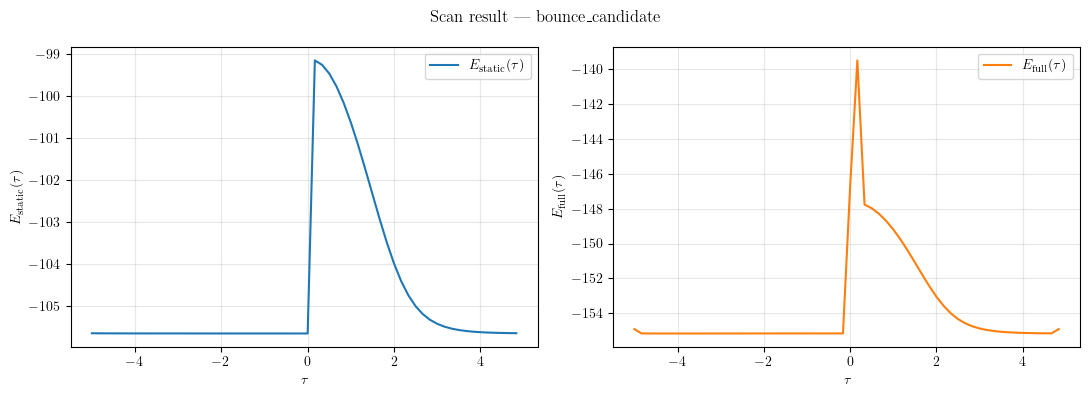

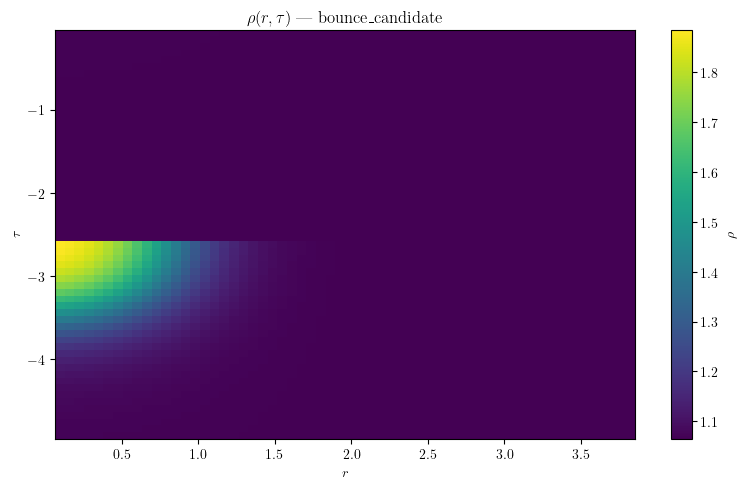

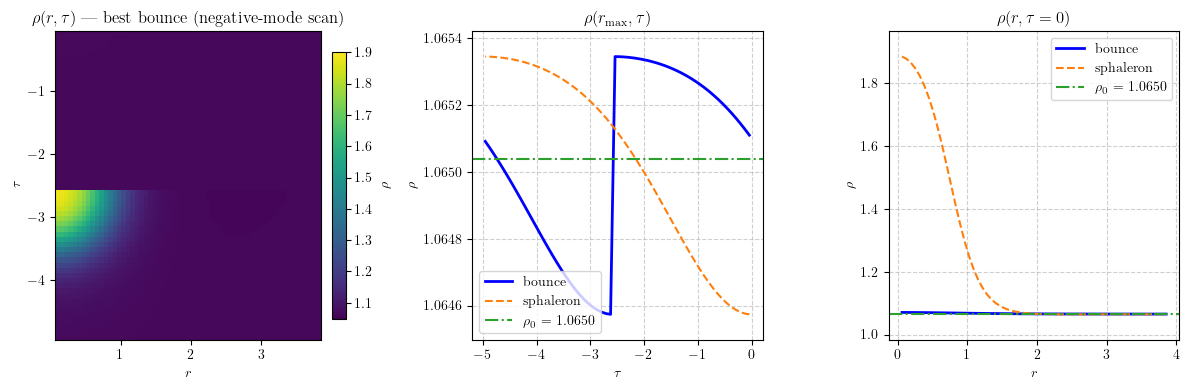

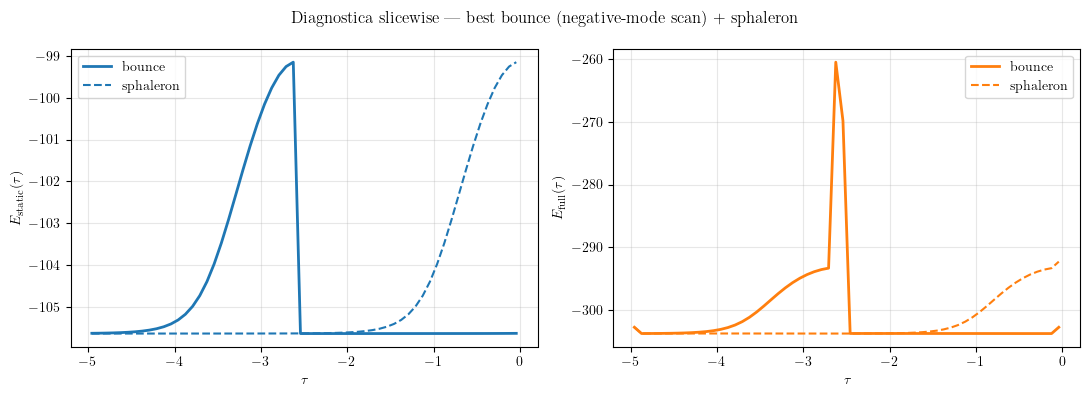

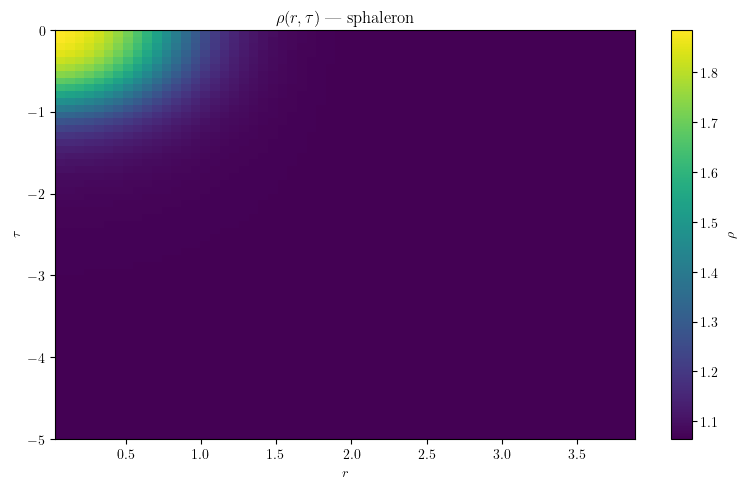

[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
--- Best bounce: full diagnostics ---
  Homogeneous reference: ω = OMEGA = 0.850000
  Grid: β = 5.0, Lr = 3.8532050930721704, Nr = 60, Nτ = 60
  Volume V = (4/3)π Lr³ = 239.637614
  η₀* = 0.000000

  Solution (best bounce from negative-mode scan):
    Q(τ=0) = 231.930932,   E(τ=0) = -94.572667
    ρ_Q = Q/V = 0.967840,   ρ_E = E/V = -0.394649

  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):
    Q_hom = 231.049350,   E_hom = -90.628116
    ρ_Q,hom = Q_hom/V = 0.964161,   ρ_E,hom = E_hom/V = -0.378188

  Ratios (solution / homogeneous):  Q/Q_hom = 1.003816,  E/E_hom = 1.043525
  Density ratios:  ρ_Q/ρ_Q,hom = 1.003816,  ρ_E/ρ_E,hom = 1.043525
  Difference (densities):  ρ_Q - ρ_Q,hom = 0.003679,  ρ_E - ρ_E,hom = -0.016460
  Difference:  E - E_hom (H_E) = -3.9

In [ ]:
# Diagnostica come nella cella Resample: 3 pannelli (ρ(r,τ), ρ(r_max,τ), ρ(r,0)) + E_static/E_full
# Best bounce (da find_bounce_from_sphaleron o best[0]) e soluzione sphaleron quando disponibile.
import numpy as np
import matplotlib.pyplot as plt
from Bubble_finder.branching import slicewise_energies

# Plot da diag['plot'] (best candidate o fallback quando best_bounce è None)
try:
    plot = diag.get("plot", {})
except NameError:
    plot = {}
try:
    has_bounce = best_bounce is not None
except NameError:
    has_bounce = False
if has_bounce or plot:
    tau_plot = plot.get("tau_sorted")
    E_static_plot = plot.get("E_static")
    E_full_plot = plot.get("E_full")
    rho_2d_plot = plot.get("rho")
    r_plot = plot.get("r")
    tau_grid_plot = plot.get("tau")
    if tau_plot is not None and E_static_plot is not None:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(tau_plot, E_static_plot, "C0-", label=r"$E_{\mathrm{static}}(\tau)$")
        axes[0].set_xlabel(r"$\tau$")
        axes[0].set_ylabel(r"$E_{\mathrm{static}}(\tau)$")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[1].plot(tau_plot, E_full_plot, "C1-", label=r"$E_{\mathrm{full}}(\tau)$")
        axes[1].set_xlabel(r"$\tau$")
        axes[1].set_ylabel(r"$E_{\mathrm{full}}(\tau)$")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.suptitle("Scan result — " + str(plot.get("best_type", "?")))
        plt.tight_layout()
        plt.show()
    if rho_2d_plot is not None and r_plot is not None and tau_grid_plot is not None:
        sort_idx_t = np.argsort(tau_grid_plot) if not np.all(np.diff(np.asarray(tau_grid_plot).flatten()) > 0) else np.arange(len(tau_grid_plot))
        tau_s_plot = np.asarray(tau_grid_plot).flatten()[sort_idx_t]
        rho_ord = np.asarray(rho_2d_plot)[:, sort_idx_t].T
        extent = (float(r_plot[0]), float(r_plot[-1]), float(tau_s_plot[0]), float(tau_s_plot[-1]))
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))
        im = ax.imshow(rho_ord, origin="lower", aspect="auto", extent=extent, cmap="viridis")
        ax.set_xlabel(r"$r$")
        ax.set_ylabel(r"$\tau$")
        ax.set_title(r"$\rho(r,\tau)$ — " + str(plot.get("best_type", "?")))
        plt.colorbar(im, ax=ax, label=r"$\rho$")
        plt.tight_layout()
        plt.show()

def _grid_and_sort(solver):
    r = np.asarray(solver.grid.r).flatten()
    tau = np.asarray(solver.grid.tau).flatten()
    Nt = len(tau)
    sort_idx_tau = np.argsort(tau) if not np.all(np.diff(tau) > 0) else np.arange(Nt)
    tau_sorted = np.asarray(tau)[sort_idx_tau]
    return r, tau, tau_sorted, sort_idx_tau

if has_bounce:
    try:
        sol_plot = best_bounce
        solver_plot = _solver_branch
        source_label = "best bounce (negative-mode scan)"
        has_sph = True
        try:
            sol_sph = _sol_sph
        except NameError:
            has_sph = False
            sol_sph = None
    except NameError:
        sol_plot = best[0]["sol"]
        solver_plot = solver
        source_label = "best candidate (trial={})".format(best[0]["trial"])
        has_sph = False
        sol_sph = None

    r, tau, tau_sorted, sort_idx_tau = _grid_and_sort(solver_plot)
    rho_2d = solver_plot.rho_map(sol_plot.y, sol_plot.ybar)  # (Nr, Nt)
    rho_ordered = rho_2d[:, sort_idx_tau].T  # (Nt, Nr)
    rho0_plot = float(solver_plot.rho0)

    # Sphaleron (stesso solver)
    if has_sph and sol_sph is not None:
        rho_2d_sph = solver_plot.rho_map(sol_sph.y, sol_sph.ybar)
        rho_ordered_sph = rho_2d_sph[:, sort_idx_tau].T
        rho_at_rmax_sph = rho_2d_sph[-1, :]
        idx_tau0 = np.argmax(tau)
        rho_at_tau0_sph = rho_2d_sph[:, idx_tau0]
    else:
        rho_2d_sph = rho_ordered_sph = rho_at_rmax_sph = rho_at_tau0_sph = None

    # Limiti colore comuni
    vmin = float(np.min(rho_2d))
    vmax = float(np.max(rho_2d))
    if has_sph and rho_2d_sph is not None:
        vmin = min(vmin, float(np.min(rho_2d_sph)))
        vmax = max(vmax, float(np.max(rho_2d_sph)))
    delta = max(vmax - vmin, 1e-10)
    vmin -= 0.02 * delta
    vmax += 0.02 * delta

    # Tre pannelli come Resample
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
    extent = (float(r[0]), float(r[-1]), float(tau_sorted[0]), float(tau_sorted[-1]))

    # Pannello 1: ρ(r,τ) — bounce (e opzionale sphaleron in secondo subplot o stessa scala)
    im1 = ax1.imshow(rho_ordered, origin="lower", aspect="auto", extent=extent, vmin=vmin, vmax=vmax, cmap="viridis")
    ax1.set_xlabel(r"$r$")
    ax1.set_ylabel(r"$\tau$")
    ax1.set_title(r"$\rho(r,\tau)$ — " + source_label)
    plt.colorbar(im1, ax=ax1, label=r"$\rho$", fraction=0.046, pad=0.04)

    # Pannello 2: ρ(r_max, τ)
    rho_at_rmax = rho_2d[-1, :]
    ax2.plot(tau, rho_at_rmax, "b-", lw=2, label="bounce")
    if rho_at_rmax_sph is not None:
        ax2.plot(tau, rho_at_rmax_sph, "C1--", lw=1.5, label="sphaleron")
    ax2.axhline(rho0_plot, color="C2", ls="-.", lw=1.5, label=rf"$\rho_0$ = {rho0_plot:.4f}")
    ymin = min(rho_at_rmax.min(), rho0_plot)
    ymax = max(rho_at_rmax.max(), rho0_plot)
    if rho_at_rmax_sph is not None:
        ymin, ymax = min(ymin, rho_at_rmax_sph.min()), max(ymax, rho_at_rmax_sph.max())
    margin = max((ymax - ymin) * 0.1, 1e-6)
    ax2.set_ylim(ymin - margin, ymax + margin)
    ax2.set_xlabel(r"$\tau$")
    ax2.set_ylabel(r"$\rho$")
    ax2.set_title(r"$\rho(r_{\max},\tau)$")
    ax2.legend()
    ax2.grid(True, ls="--", alpha=0.6)

    # Pannello 3: ρ(r, 0) — slice a τ=0
    idx_tau0 = np.argmax(tau)
    rho_at_tau0 = rho_2d[:, idx_tau0]
    ax3.plot(r, rho_at_tau0, "b-", lw=2, label="bounce")
    if rho_at_tau0_sph is not None:
        ax3.plot(r, rho_at_tau0_sph, "C1--", lw=1.5, label="sphaleron")
    ax3.axhline(rho0_plot, color="C2", ls="-.", lw=1.5, label=rf"$\rho_0$ = {rho0_plot:.4f}")
    ymin3 = min(rho_at_tau0.min(), rho0_plot)
    ymax3 = max(rho_at_tau0.max(), rho0_plot)
    if rho_at_tau0_sph is not None:
        ymin3 = min(ymin3, rho_at_tau0_sph.min())
        ymax3 = max(ymax3, rho_at_tau0_sph.max())
    margin3 = max((ymax3 - ymin3) * 0.1, 1e-6)
    ax3.set_ylim(ymin3 - margin3, ymax3 + margin3)
    ax3.set_xlabel(r"$r$")
    ax3.set_ylabel(r"$\rho$")
    ax3.set_title(r"$\rho(r,\tau=0)$")
    ax3.legend()
    ax3.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Diagnostica E_static(τ) e E_full(τ) — bounce e sphaleron
    _, E_static_tau, E_full_tau = slicewise_energies(solver_plot, sol_plot)
    fig2, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(tau_sorted, E_static_tau, "C0-", lw=2, label="bounce")
    axes[1].plot(tau_sorted, E_full_tau, "C1-", lw=2, label="bounce")
    if has_sph and sol_sph is not None:
        _, E_s_sph, E_f_sph = slicewise_energies(solver_plot, sol_sph)
        axes[0].plot(tau_sorted, E_s_sph, "C0--", lw=1.5, label="sphaleron")
        axes[1].plot(tau_sorted, E_f_sph, "C1--", lw=1.5, label="sphaleron")
    axes[0].set_xlabel(r"$\tau$")
    axes[0].set_ylabel(r"$E_{\mathrm{static}}(\tau)$")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[1].set_xlabel(r"$\tau$")
    axes[1].set_ylabel(r"$E_{\mathrm{full}}(\tau)$")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.suptitle("Diagnostica slicewise — " + source_label + (" + sphaleron" if has_sph else ""))
    plt.tight_layout()
    plt.show()

    # Opzionale: heatmap sphaleron (stesso stile pcolormesh)
    if has_sph and rho_ordered_sph is not None:
        fig3, ax_sph = plt.subplots(1, 1, figsize=(8, 5))
        im_sph = ax_sph.pcolormesh(r, tau_sorted, rho_ordered_sph, shading="auto", cmap="viridis")
        ax_sph.set_xlabel(r"$r$")
        ax_sph.set_ylabel(r"$\tau$")
        ax_sph.set_title(r"$\rho(r,\tau)$ — sphaleron")
        plt.colorbar(im_sph, ax=ax_sph, label=r"$\rho$")
        plt.tight_layout()
        plt.show()

# Full diagnostics (same format as Resampled + η scan)
    from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d
    from Bubble_finder.observables_1d import Q_homogeneous_ball
    try:
        from Bubble_finder.potential_bubble import vacua_of_Omega
    except ImportError:
        vacua_of_Omega = globals().get('vacua_of_Omega', None)
    OMEGA_bb = float(OMEGA) if 'OMEGA' in dir() and OMEGA is not None else float(_solver_branch.omega)
    U_bb = U if 'U' in dir() else getattr(_solver_branch, 'U', None)
    PHI0_bb = PHI0 if 'PHI0' in dir() else getattr(_solver_branch, 'phi0', getattr(_solver_branch, 'rho0', 1.0))
    V1_bb = V1 if 'V1' in dir() else getattr(_solver_branch, 'v1', 0.5)
    V2_bb = V2 if 'V2' in dir() else getattr(_solver_branch, 'v2', 0.5)
    r_bb = np.asarray(_solver_branch.grid.r).flatten()
    Lr_bb = float(r_bb[-1])
    V_bb = (4.0 / 3.0) * np.pi * Lr_bb**3
    beta_bb = float(getattr(_solver_branch.grid, 'beta', getattr(_solver_branch, 'beta', 5.0)))
    Nr_bb = len(r_bb)
    Ntau_bb = len(np.asarray(_solver_branch.grid.tau).flatten())
    if vacua_of_Omega is not None and U_bb is not None:
        rho_false_bb, _ = vacua_of_Omega(PHI0_bb, V1_bb, V2_bb, OMEGA_bb)
        Q_hom_bb = float(Q_homogeneous_ball(OMEGA_bb, rho_false_bb, Lr_bb))
        E_hom_bb = float(homogeneous_energy_2d(OMEGA_bb, rho_false_bb, Lr_bb, U_bb))
        Q_sol = float(best_bounce.Q_tau0.real)
        E_sol = float(best_bounce.E_tau0)
        rho_Q_hom_bb = Q_hom_bb / V_bb
        rho_E_hom_bb = E_hom_bb / V_bb
        rho_Q_bb = Q_sol / V_bb
        rho_E_bb = E_sol / V_bb
        eta_bb = getattr(_solver_branch, 'eta0', None)
        eta_str = f"{eta_bb:.6f}" if eta_bb is not None else "N/A"
        print("--- Best bounce: full diagnostics ---")
        print(f"  Homogeneous reference: ω = OMEGA = {OMEGA_bb:.6f}")
        print(f"  Grid: β = {beta_bb}, Lr = {Lr_bb}, Nr = {Nr_bb}, Nτ = {Ntau_bb}")
        print(f"  Volume V = (4/3)π Lr³ = {V_bb:.6f}")
        print(f"  η₀* = {eta_str}")
        print("")
        print("  Solution (best bounce from negative-mode scan):")
        print(f"    Q(τ=0) = {Q_sol:.6f},   E(τ=0) = {E_sol:.6f}")
        print(f"    ρ_Q = Q/V = {rho_Q_bb:.6f},   ρ_E = E/V = {rho_E_bb:.6f}")
        print("")
        print("  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):")
        print(f"    Q_hom = {Q_hom_bb:.6f},   E_hom = {E_hom_bb:.6f}")
        print(f"    ρ_Q,hom = Q_hom/V = {rho_Q_hom_bb:.6f},   ρ_E,hom = E_hom/V = {rho_E_hom_bb:.6f}")
        print("")
        print(f"  Ratios (solution / homogeneous):  Q/Q_hom = {Q_sol/Q_hom_bb:.6f},  E/E_hom = {E_sol/E_hom_bb:.6f}")
        print(f"  Density ratios:  ρ_Q/ρ_Q,hom = {rho_Q_bb/rho_Q_hom_bb:.6f},  ρ_E/ρ_E,hom = {rho_E_bb/rho_E_hom_bb:.6f}")
        print(f"  Difference (densities):  ρ_Q - ρ_Q,hom = {rho_Q_bb - rho_Q_hom_bb:.6f},  ρ_E - ρ_E,hom = {rho_E_bb - rho_E_hom_bb:.6f}")
        print(f"  Difference:  E - E_hom (H_E) = {E_sol - E_hom_bb:.6f}")
        obs_bb = getattr(best_bounce, "observables_ghost", None) or {}
        E_M_hom_bb = float(homogeneous_E_M_2d(OMEGA_bb, rho_false_bb, Lr_bb, U_bb))
        if "E_M" in obs_bb:
            print(f"  Difference:  E_M - E_M_hom(OMEGA) = {obs_bb['E_M'] - E_M_hom_bb:.6f}")
        if "F_omega" in obs_bb:
            F_bb = obs_bb["F_omega"]
            F_hom_bb = E_M_hom_bb - OMEGA_bb * Q_hom_bb
            print(f"  F_ω (solution) = {F_bb:.6f},  F_ω,hom(OMEGA) = {F_hom_bb:.6f}")
            print(f"  Difference:  F_ω - F_ω,hom = {F_bb - F_hom_bb:.6f}")
    print("  Best bounce solution stored in best_bounce; diagnostics in diag.")
else:
    print("  No bounce candidate found; try different eps_list or looser tolerances.")

# Diagnostics

In [ ]:
# ============================================================================
# Check: dalla soluzione match-Q → ρ∞ = √(φφ̄) a r=r_max, τ=τ_min → ω_eff → Q_hom(ω_eff), E_hom(ω_eff)
# Condizione omogenea: ω² = dV/ds|_{s=ρ∞²}  (stessa usata nel codice per i vacua)
# ============================================================================
from scipy.optimize import brentq
from Bubble_finder.potential_bubble import vacua_of_Omega
from Bubble_finder.observables_1d import Q_homogeneous_ball
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d

# Soluzione match-Q: sol_eta_res su solver_res
phi_res, phibar_res = solver_res.phi(sol_eta_res.y, sol_eta_res.ybar)
r_res = np.asarray(solver_res.grid.r).flatten()
tau_res = np.asarray(solver_res.grid.tau).flatten()
Nr, Nt = phi_res.shape
i_rmax = Nr - 1
i_taumin = int(np.argmin(tau_res))
# ρ∞² = (φφ̄)_real a (r_max, τ_min)
s_inf = (phi_res[i_rmax, i_taumin] * phibar_res[i_rmax, i_taumin]).real
rho_inf = np.sqrt(max(s_inf, 0.0))
tau_min_val = tau_res[i_taumin]
r_max_val = r_res[i_rmax]

print("=== Check: ρ∞ dalla soluzione match-Q → ω_eff → Q_hom, E_hom ===")
print(f"  Punto: r = r_max = {r_max_val:.6f},  τ = τ_min = {tau_min_val:.6f}")
print(f"  (φφ̄)_real = {s_inf:.10e}  →  ρ∞ = √(φφ̄) = {rho_inf:.10e}")

# ω_eff dalla condizione omogenea: ρ_false(ω_eff) = ρ∞ (stesso criterio del codice)
def rho_false_from_omega(omega_val):
    rf, _ = vacua_of_Omega(PHI0, V1, V2, float(omega_val), verbose=False)
    return float(rf)

try:
    omega_lo = float(omega_valid.min())
    omega_hi = float(omega_max_val)
except NameError:
    omega_lo = 0.1
    omega_hi = 1.0
try:
    omega_eff_check = brentq(lambda w: rho_false_from_omega(w) - rho_inf, omega_lo, omega_hi, xtol=1e-10)
except (ValueError, RuntimeError) as e:
    print(f"  WARNING: brentq per ω_eff fallito: {e}. Uso OMEGA come fallback.")
    omega_eff_check = float(OMEGA)

print(f"  ω_eff (da ρ∞, cond. omogenea) = {omega_eff_check:.10e}")

# Q_hom(ω_eff) e E_hom(ω_eff) con ρ_false = ρ∞
Q_hom_eff_check = float(Q_homogeneous_ball(omega_eff_check, rho_inf, Lr_res))
E_hom_eff_check = float(homogeneous_energy_2d(omega_eff_check, rho_inf, Lr_res, U))
E_M_hom_eff_check = float(homogeneous_E_M_2d(omega_eff_check, rho_inf, Lr_res, U))

print("")
print("  Omogeneo a (ω_eff, ρ∞):")
print(f"    Q_hom(ω_eff) = {Q_hom_eff_check:.8e}")
print(f"    E_hom(ω_eff) = H_E,hom = {E_hom_eff_check:.8e}")
print(f"    E_M,hom(ω_eff) = {E_M_hom_eff_check:.8e}")
print("")
print("  Confronto con la soluzione match-Q:")
print(f"    Q (sol match-Q) = {dens_res['Q']:.8e}   →  Q / Q_hom(ω_eff) = {dens_res['Q'] / Q_hom_eff_check:.6f}")
print(f"    E (sol match-Q) = {dens_res['E']:.8e}   →  E / E_hom(ω_eff) = {dens_res['E'] / E_hom_eff_check:.6f}")

=== Check: ρ∞ dalla soluzione match-Q → ω_eff → Q_hom, E_hom ===
  Punto: r = r_max = 3.853205,  τ = τ_min = -9.937500
  (φφ̄)_real = 1.1342754952e+00  →  ρ∞ = √(φφ̄) = 1.0650237064e+00
  ω_eff (da ρ∞, cond. omogenea) = 8.4994824191e-01

  Omogeneo a (ω_eff, ρ∞):
    Q_hom(ω_eff) = 2.31028743e+02
    E_hom(ω_eff) = H_E,hom = -9.05930857e+01
    E_M,hom(ω_eff) = 9.05930857e+01

  Confronto con la soluzione match-Q:
    Q (sol match-Q) = 2.31049350e+02   →  Q / Q_hom(ω_eff) = 1.000089
    E (sol match-Q) = -9.31150162e+01   →  E / E_hom(ω_eff) = 1.027838


=== Microcanonical 3D functional check (fixed-Q): E_Q vs homogeneous ===

  --- τ=0 convention (same as sol.observables_ghost) ---
  τ grid: τ[0] = -0.008333, τ[-1] = -4.991667, dτ = 1.666667e-02; τ=0 is ghost midpoint.
  --- Charge: Q_ref, Q_from_profile, sign/scale ---
  Q_ref (observables_ghost / Q_tau0) = 504.833757
  Q_from_profile (4π ∫ r² n_Q)      = 504.833757
  Relative difference = 0.000e+00  (tol_Q ~ 5e-04)
  Applied: n_Q = 0.5 × n_Q_raw (n_Q_raw integral = 1009.667514).
  --- ω, ρ_hom, ρ(r_max) ---
  ω used = 0.850000,  ρ_hom = 1.065039,  ρ0(r_max, τ=0) = 1.064734,  |ρ0(r_max)−ρ_hom| = 3.047e-04
  Q_target = 504.833757,  V3 = 523.598776,  n_Q_hom = 9.641615e-01

  --- Extra-term prefactor C ---
  C = n_Q_hom²/(ω² ρ_hom⁴) = 1.000000  (e_extra = n_Q²/(C ρ²); homogeneous kinetic = ω² ρ²).

  --- Bubble: E_Q components ---
  E_grad = 4π ∫ r² (∂r φ0)(∂r φ̄0) = 4.545338
  E_extra = 4π ∫ r² [ n_Q²/(C ρ²) ] = 425.033997  [integrated extra term]
  E_pot  = 4π ∫ r² U(ρ0) = -229.09258

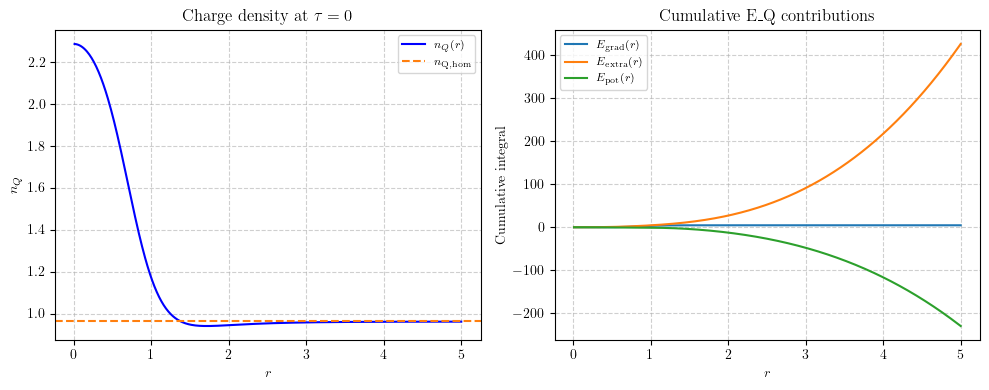

In [ ]:
# =============================================================================
# Microcanonical 3D functional check (fixed-Q): E_Q vs homogeneous
# E_Q = 4π ∫ dr r² [ (∂rφ0)(∂rφ̄0) + n_Q²/(C ρ²) + U(ρ0) ]. C inferred from homogeneous.
# Uses solver_res, sol_eta_res (after η scan). Same ghost as observables_ghost.
# =============================================================================
from scipy.integrate import simpson, cumulative_trapezoid

def _dr1_radial(r, f):
    """First radial derivative (centered interior, one-sided at boundaries)."""
    r, f = np.asarray(r, dtype=float), np.asarray(f)
    df = np.empty_like(f, dtype=np.result_type(f, np.complex128))
    n = len(r)
    if n >= 3:
        df[1:-1] = (f[2:] - f[:-2]) / (r[2:] - r[:-2])
        df[0] = (f[1] - f[0]) / (r[1] - r[0])
        df[-1] = (f[-1] - f[-2]) / (r[-1] - r[-2])
    elif n == 2:
        df[:] = (f[1] - f[0]) / (r[1] - r[0])
    else:
        df[:] = 0.0
    return df

# --- (A) τ=0 fields: same ghost as observables_2d (y_plus=ybar[:,0], y_minus=y[:,0]) ---
solver = solver_res
sol = sol_eta_res
y = np.asarray(sol.y)
ybar = np.asarray(sol.ybar)
r = np.asarray(solver.grid.r, dtype=float).flatten()
tau_grid = np.asarray(solver.grid.tau, dtype=float).flatten()
dt = float(solver.dt)
omega = float(solver.omega)
rho0_bg = float(solver.rho0)
rho_eps = 1e-14

# Ghost at τ=0 (twisted BC: y_plus=ybar[:,0], y_minus=y[:,0]; midpoint = τ=0)
y_minus, ybar_minus = y[:, 0], ybar[:, 0]
y_plus, ybar_plus = ybar[:, 0], y[:, 0]
y0 = 0.5 * (y_plus + y_minus)
ybar0 = 0.5 * (ybar_plus + ybar_minus)
inv_r = np.zeros_like(r, dtype=float)
inv_r[r != 0.0] = 1.0 / r[r != 0.0]
# φ0, φ̄0 at τ=0 (same as phi_rot at ghost midpoint; solver.phi_rot is rho0+y/r)
phi0 = rho0_bg + inv_r * y0
phibar0 = rho0_bg + inv_r * ybar0
rho0_sq = np.maximum((phi0 * phibar0).real, 0.0)
rho0_arr = np.sqrt(rho0_sq + rho_eps)

# --- (B) n_Q(r): raw = φ̄0 ∂τφ0 − φ0 ∂τφ̄0; notebook Q uses q = 0.5*Re(raw) ---
y_t0 = (y_plus - y_minus) / dt
ybar_t0 = (ybar_plus - ybar_minus) / dt
phi_tau0 = inv_r * (y_t0 + omega * (y0 + r * rho0_bg))
phibar_tau0 = inv_r * (ybar_t0 - omega * (ybar0 + r * rho0_bg))
n_Q_raw = np.asarray((phibar0 * phi_tau0 - phi0 * phibar_tau0).real, dtype=float)
Q_raw = float(4.0 * np.pi * simpson(r**2 * n_Q_raw, x=r))
obs = getattr(sol, "observables_ghost", None) or {}
Q_ref = float(obs.get("Q", sol.Q_tau0.real))
tol_Q = 1e-6 * max(1.0, abs(Q_ref))
# Match Q_ref: notebook uses q = 0.5 * n_Q_raw => Q_ref = 0.5*Q_raw => n_Q = 0.5*n_Q_raw
scale_nQ = 1.0
if abs(Q_raw) > 1e-30:
    ratio_raw = Q_ref / Q_raw
    if abs(ratio_raw + 1.0) < 0.1:
        n_Q = -n_Q_raw.copy(); scale_nQ = -1.0
    elif abs(ratio_raw - 0.5) < 0.1:
        n_Q = 0.5 * n_Q_raw; scale_nQ = 0.5
    elif abs(ratio_raw - 2.0) < 0.1:
        n_Q = 2.0 * n_Q_raw; scale_nQ = 2.0
    else:
        n_Q = n_Q_raw * (Q_ref / Q_raw); scale_nQ = Q_ref / Q_raw
else:
    n_Q = n_Q_raw.copy()
Q_from_profile = float(4.0 * np.pi * simpson(r**2 * n_Q, x=r))
rel_diff_Q = abs(Q_from_profile - Q_ref) / max(abs(Q_ref), 1e-30)

# --- (C) Radial derivative and gradient term ---
phi0_r = _dr1_radial(r, phi0)
phibar0_r = _dr1_radial(r, phibar0)
e_grad_dens = (phi0_r * phibar0_r).real

# --- (D) Extra-term prefactor C: from homogeneous E_M kinetic = ω² ρ² => n_Q²/(C ρ²)=ω² ρ² => C = n_Q_hom²/(ω² ρ_hom⁴) ---
Q_target = float(Q_target_res)
V3 = float(V_res)
rho_hom = float(rho_false_ref_res)
n_Q_hom = Q_target / V3
# ω for homogeneous reference (same as notebook: reference at OMEGA)
omega_used = float(OMEGA)
if omega_used**2 * rho_hom**4 > 1e-30:
    C_extra = (n_Q_hom**2) / (omega_used**2 * rho_hom**4)
else:
    C_extra = 1.0
phi0_phibar0 = np.maximum(rho0_arr**2, rho_eps)
e_extra_dens = np.where(phi0_phibar0 > rho_eps, (n_Q**2) / (C_extra * phi0_phibar0), 0.0)
e_pot_dens = np.asarray(U(rho0_arr)).flatten()

# --- (E) Integrals: E_grad, E_extra, E_pot, E_Q_bub ---
E_grad = float(4.0 * np.pi * simpson(r**2 * e_grad_dens, x=r))
E_extra = float(4.0 * np.pi * simpson(r**2 * e_extra_dens, x=r))
E_pot = float(4.0 * np.pi * simpson(r**2 * e_pot_dens, x=r))
E_Q_bub = E_grad + E_extra + E_pot

# Homogeneous reference (same Q, same V): E_extra_hom = V3 * n_Q_hom²/(C ρ_hom²)
E_grad_hom = 0.0
E_extra_hom = V3 * (n_Q_hom**2) / (C_extra * rho_hom**2)
E_pot_hom = V3 * float(np.asarray(U(np.array([rho_hom]))).flat[0])
E_Q_hom = E_extra_hom + E_pot_hom

# Far-field check
rho0_rmax = float(rho0_arr[-1])
diff_rho_rmax = abs(rho0_rmax - rho_hom)

# --- (F) Report ---
print("=== Microcanonical 3D functional check (fixed-Q): E_Q vs homogeneous ===\n")
print("  --- τ=0 convention (same as sol.observables_ghost) ---")
print(f"  τ grid: τ[0] = {float(tau_grid[0]):.6f}, τ[-1] = {float(tau_grid[-1]):.6f}, dτ = {dt:.6e}; τ=0 is ghost midpoint.")
print("  --- Charge: Q_ref, Q_from_profile, sign/scale ---")
print(f"  Q_ref (observables_ghost / Q_tau0) = {Q_ref:.6f}")
print(f"  Q_from_profile (4π ∫ r² n_Q)      = {Q_from_profile:.6f}")
print(f"  Relative difference = {rel_diff_Q:.3e}  (tol_Q ~ {tol_Q:.0e})")
if abs(scale_nQ - 1.0) > 0.01 or scale_nQ < 0:
    print(f"  Applied: n_Q = {scale_nQ} × n_Q_raw (n_Q_raw integral = {Q_raw:.6f}).")
if rel_diff_Q > 0.01:
    print("  WARNING: Q_from_profile does not match Q_ref; check n_Q convention.")
print("  --- ω, ρ_hom, ρ(r_max) ---")
print(f"  ω used = {omega_used:.6f},  ρ_hom = {rho_hom:.6f},  ρ0(r_max, τ=0) = {rho0_rmax:.6f},  |ρ0(r_max)−ρ_hom| = {diff_rho_rmax:.3e}")
print(f"  Q_target = {Q_target:.6f},  V3 = {V3:.6f},  n_Q_hom = {n_Q_hom:.6e}\n")
print("  --- Extra-term prefactor C ---")
print(f"  C = n_Q_hom²/(ω² ρ_hom⁴) = {C_extra:.6f}  (e_extra = n_Q²/(C ρ²); homogeneous kinetic = ω² ρ²).\n")
print("  --- Bubble: E_Q components ---")
print(f"  E_grad = 4π ∫ r² (∂r φ0)(∂r φ̄0) = {E_grad:.6f}")
print(f"  E_extra = 4π ∫ r² [ n_Q²/(C ρ²) ] = {E_extra:.6f}  [integrated extra term]")
print(f"  E_pot  = 4π ∫ r² U(ρ0) = {E_pot:.6f}")
print(f"  E_Q_bub = E_grad + E_extra + E_pot = {E_Q_bub:.6f}\n")
print("  --- Homogeneous (same Q, same V) ---")
print(f"  E_extra_hom = V3 × n_Q_hom²/(C ρ_hom²) = {E_extra_hom:.6f}  [integrated extra term]")
print(f"  E_pot_hom   = V3 × U(ρ_hom) = {E_pot_hom:.6f}")
print(f"  E_Q_hom = E_extra_hom + E_pot_hom = {E_Q_hom:.6f}\n")
Delta_E_Q = E_Q_bub - E_Q_hom
rel_Delta = Delta_E_Q / max(abs(E_Q_hom), 1e-30)
print("  --- ΔE_Q = E_Q(bubble) − E_Q(hom) ---")
print(f"  ΔE_Q (absolute) = {Delta_E_Q:.6e}")
print(f"  ΔE_Q (relative to E_Q_hom) = {rel_Delta:.3e}")
if abs(Delta_E_Q) < max(1e-4 * abs(E_Q_hom), 1e-8):
    print("  → ΔE_Q ≈ 0 within numerical tolerance (microcanonical check passed).")
else:
    d_extra = E_extra - E_extra_hom
    d_pot = E_pot - E_pot_hom
    print("  → ΔE_Q does NOT vanish. Dominant contributions:")
    print(f"     (E_grad) = {E_grad:.6f}")
    print(f"     (E_extra − E_extra_hom) = {d_extra:.6f}")
    print(f"     (E_pot − E_pot_hom) = {d_pot:.6f}")
print(f"\n  Ratios:  E_extra/E_Q_bub = {E_extra / max(abs(E_Q_bub), 1e-30):.6f},  E_extra_hom/E_Q_hom = {E_extra_hom / max(abs(E_Q_hom), 1e-30):.6f}")
E_M_0 = obs.get("E_M", np.nan)
if not np.isnan(E_M_0):
    print(f"\n  E_M(τ=0) from observables_ghost = {float(E_M_0):.6f}. (Different functional: E_M is Minkowski energy; E_Q is microcanonical at fixed n_Q(r).)")

# --- Optional plots: n_Q(r) vs n_Q_hom; cumulative integrals ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(r, n_Q, "b-", lw=1.5, label=r"$n_Q(r)$")
ax1.axhline(n_Q_hom, color="C1", ls="--", lw=1.5, label=r"$n_{\mathrm{Q,hom}}$")
ax1.set_xlabel(r"$r$")
ax1.set_ylabel(r"$n_Q$")
ax1.set_title(r"Charge density at $\tau=0$")
ax1.legend(loc="best", fontsize=8)
ax1.grid(True, ls="--", alpha=0.6)

# Cumulative integrals (vs r): 4π ∫_0^r ds s² e(s)
integrand_grad = 4.0 * np.pi * r**2 * e_grad_dens
integrand_extra = 4.0 * np.pi * r**2 * e_extra_dens
integrand_pot = 4.0 * np.pi * r**2 * e_pot_dens
cum_grad = np.concatenate([[0.0], cumulative_trapezoid(integrand_grad, r)])
cum_extra = np.concatenate([[0.0], cumulative_trapezoid(integrand_extra, r)])
cum_pot = np.concatenate([[0.0], cumulative_trapezoid(integrand_pot, r)])
ax2.plot(r, cum_grad, label=r"$E_{\mathrm{grad}}(r)$")
ax2.plot(r, cum_extra, label=r"$E_{\mathrm{extra}}(r)$")
ax2.plot(r, cum_pot, label=r"$E_{\mathrm{pot}}(r)$")
ax2.set_xlabel(r"$r$")
ax2.set_ylabel("Cumulative integral")
ax2.set_title("Cumulative E_Q contributions")
ax2.legend(loc="best", fontsize=8)
ax2.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

=== Euclidean Hamiltonian check: H_E(τ) conservation and ΔH_E = 0 ===

  Field reconstruction: solver.phi(y, ybar)  [phi_rot = rho0 + y/r, phi = exp(+ωτ)*phi_rot, φ̄ = exp(−ωτ)*phibar_rot]

  --- τ grid and τ=0 convention ---
  τ[0] = -0.008333, τ[-1] = -4.991667, dτ = 1.666667e-02, Nτ = 300
  τ=0 is ghost midpoint (between τ[0] and reflected point); H_E at τ=0 from compute_HE_euclidean_tau0_ghost_2d.

  --- Homogeneous reference ---
  ω = 0.850000, ρ_hom = 1.065039, Lr = 5.000000, V3 = 523.598776, U(ρ_hom) = -0.441349
  H_E,hom = V3 × (−ω² ρ_hom² − U(ρ_hom)) = -198.018875

  --- H_E(τ) on grid ---
  H_E(τ): min = -200.487825, max = -197.874944, mean = -198.224187, std = 6.116286e-01
  Relative std = 3.086e-03  (tol 1e-03)
  → H_E(τ) is NOT flat; see A(τ), B(τ), C(τ) below.

  |H_E(τ) − H_E,hom|: max = 2.468950e+00, rms = 6.451685e-01
  H_E at τ=0 (ghost midpoint) = -200.486751,  Δ = H_E_tau0_mid − H_E,hom = -2.467876e+00

  sol.observables_ghost['E'] (H_E at τ=0) = -200.486751,  diffe

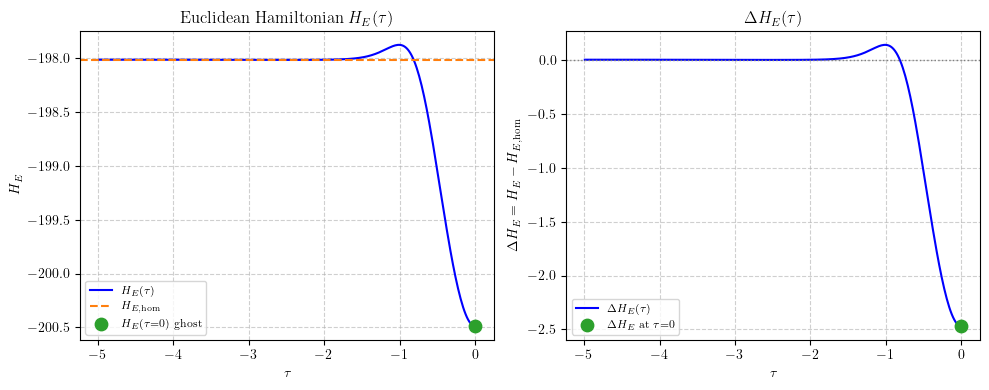

In [ ]:
# =============================================================================
# Euclidean Hamiltonian check: H_E(τ) conservation and ΔH_E = 0
# H_E(τ) = 4π ∫ dr r² [ (∂τφ)(∂τφ̄) − (∂rφ)(∂rφ̄) − U(ρ) ]. Check constancy and ΔH_E ≈ 0.
# =============================================================================
from scipy.integrate import simpson
from Bubble_finder.observables_2d import (
    compute_energy_2d,
    compute_HE_euclidean_tau0_ghost_2d,
)

def _dr1_radial(r, f):
    """Radial derivative: centered interior, one-sided at boundaries."""
    r, f = np.asarray(r, dtype=float), np.asarray(f)
    df = np.empty_like(f, dtype=np.result_type(f, np.complex128))
    n = len(r)
    if n >= 3:
        df[1:-1] = (f[2:] - f[:-2]) / (r[2:] - r[:-2])
        df[0] = (f[1] - f[0]) / (r[1] - r[0])
        df[-1] = (f[-1] - f[-2]) / (r[-1] - r[-2])
    elif n == 2:
        df[:] = (f[1] - f[0]) / (r[1] - r[0])
    else:
        df[:] = 0.0
    return df

solver = solver_res
sol = sol_eta_res
y = np.asarray(sol.y)
ybar = np.asarray(sol.ybar)
r = np.asarray(solver.grid.r, dtype=float).flatten()
tau_grid = np.asarray(solver.grid.tau, dtype=float).flatten()
dt = float(solver.dt)
omega = float(solver.omega)
rho0_bg = float(solver.rho0)
rho_eps = getattr(getattr(solver, "settings", object()), "rho_eps", 0.0)
Nr, Nt = y.shape[0], y.shape[1]

# (A) Authoritative φ, φ̄: use solver.phi (phi_rot + exp(±ωτ))
phi, phibar = solver.phi(y, ybar)
print("=== Euclidean Hamiltonian check: H_E(τ) conservation and ΔH_E = 0 ===\n")
print("  Field reconstruction: solver.phi(y, ybar)  [phi_rot = rho0 + y/r, phi = exp(+ωτ)*phi_rot, φ̄ = exp(−ωτ)*phibar_rot]")

# (B)–(D) H_E(τ) on grid via same logic as observables_2d (compute_energy_2d)
_, H_E_tau_grid = compute_energy_2d(solver, y, ybar, index_tau=0, return_profile=True)
H_E_tau0_mid = float(compute_HE_euclidean_tau0_ghost_2d(solver, y, ybar))

# Decompose into A(τ), B(τ), C(τ) for diagnostics
A_tau = np.zeros(Nt)
B_tau = np.zeros(Nt)
C_tau = np.zeros(Nt)
inv_r = np.zeros_like(r, dtype=float)
inv_r[r != 0.0] = 1.0 / r[r != 0.0]
tau_increases = (tau_grid[1] > tau_grid[0]) if Nt >= 2 else False

for i in range(Nt):
    y_im1, y_ip1, yb_im1, yb_ip1 = solver._tau_neighbors(y, ybar, i)
    if tau_increases:
        y_t = (y_ip1 - y_im1) / (2.0 * dt)
        yb_t = (yb_ip1 - yb_im1) / (2.0 * dt)
    else:
        y_t = (y_im1 - y_ip1) / (2.0 * dt)
        yb_t = (yb_im1 - yb_ip1) / (2.0 * dt)
    y_tot = y[:, i] + r * rho0_bg
    yb_tot = ybar[:, i] + r * rho0_bg
    exp_p = np.exp(+omega * tau_grid[i]) * inv_r
    exp_m = np.exp(-omega * tau_grid[i]) * inv_r
    phi_tau = exp_p * (y_t + omega * y_tot)
    phibar_tau = exp_m * (yb_t - omega * yb_tot)
    phi_r = _dr1_radial(r, phi[:, i])
    phibar_r = _dr1_radial(r, phibar[:, i])
    u = (phi[:, i] * phibar[:, i]).real
    u_pos = np.maximum(u, 0.0)
    rho_slice = np.sqrt(u_pos + rho_eps)
    V_slice = np.asarray(solver.U(rho_slice)).flatten()
    A_tau[i] = float(4.0 * np.pi * simpson(r**2 * (phi_tau * phibar_tau).real, x=r))
    B_tau[i] = float(4.0 * np.pi * simpson(r**2 * (phi_r * phibar_r).real, x=r))
    C_tau[i] = float(4.0 * np.pi * simpson(r**2 * V_slice, x=r))

# (E) Homogeneous reference: H_E,hom = V3 * (−ω² ρ_hom² − U(ρ_hom))
Lr = float(getattr(solver.grid, "Lr", r[-1]))
V3 = (4.0 / 3.0) * np.pi * (Lr**3)
rho_hom = float(rho_false_ref_res)
omega_hom = float(OMEGA)
U_rho_hom = float(np.asarray(U(np.array([rho_hom]))).flat[0])
H_E_hom = V3 * (-(omega_hom**2) * (rho_hom**2) - U_rho_hom)

print("\n  --- τ grid and τ=0 convention ---")
print(f"  τ[0] = {tau_grid[0]:.6f}, τ[-1] = {tau_grid[-1]:.6f}, dτ = {dt:.6e}, Nτ = {Nt}")
print("  τ=0 is ghost midpoint (between τ[0] and reflected point); H_E at τ=0 from compute_HE_euclidean_tau0_ghost_2d.")

print("\n  --- Homogeneous reference ---")
print(f"  ω = {omega_hom:.6f}, ρ_hom = {rho_hom:.6f}, Lr = {Lr:.6f}, V3 = {V3:.6f}, U(ρ_hom) = {U_rho_hom:.6f}")
print(f"  H_E,hom = V3 × (−ω² ρ_hom² − U(ρ_hom)) = {H_E_hom:.6f}")

Delta_H_E = H_E_tau_grid - H_E_hom
rel_std_HE = np.std(H_E_tau_grid) / max(np.abs(np.mean(H_E_tau_grid)), 1e-30)
tol_rel = 1e-3

print("\n  --- H_E(τ) on grid ---")
print(f"  H_E(τ): min = {np.min(H_E_tau_grid):.6f}, max = {np.max(H_E_tau_grid):.6f}, mean = {np.mean(H_E_tau_grid):.6f}, std = {np.std(H_E_tau_grid):.6e}")
print(f"  Relative std = {rel_std_HE:.3e}  (tol {tol_rel:.0e})")
if rel_std_HE < tol_rel:
    print("  → H_E(τ) is flat within tolerance.")
else:
    print("  → H_E(τ) is NOT flat; see A(τ), B(τ), C(τ) below.")

print(f"\n  |H_E(τ) − H_E,hom|: max = {np.max(np.abs(Delta_H_E)):.6e}, rms = {np.sqrt(np.mean(Delta_H_E**2)):.6e}")
print(f"  H_E at τ=0 (ghost midpoint) = {H_E_tau0_mid:.6f},  Δ = H_E_tau0_mid − H_E,hom = {H_E_tau0_mid - H_E_hom:.6e}")

obs = getattr(sol, "observables_ghost", None) or {}
if "E" in obs:
    print(f"\n  sol.observables_ghost['E'] (H_E at τ=0) = {obs['E']:.6f},  difference from H_E_tau0_mid = {abs(obs['E'] - H_E_tau0_mid):.3e}")

if rel_std_HE >= tol_rel or np.max(np.abs(Delta_H_E)) > max(1e-4 * abs(H_E_hom), 1e-8):
    print("\n  --- Term decomposition (A=∫(∂τφ)(∂τφ̄), B=∫(∂rφ)(∂rφ̄), C=∫U) ---")
    print(f"  A(τ): min = {np.min(A_tau):.6f}, max = {np.max(A_tau):.6f}, std = {np.std(A_tau):.6e}")
    print(f"  B(τ): min = {np.min(B_tau):.6f}, max = {np.max(B_tau):.6f}, std = {np.std(B_tau):.6e}")
    print(f"  C(τ): min = {np.min(C_tau):.6f}, max = {np.max(C_tau):.6f}, std = {np.std(C_tau):.6e}")

# (G) Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(tau_grid, H_E_tau_grid, "b-", lw=1.5, label=r"$H_E(\tau)$")
ax1.axhline(H_E_hom, color="C1", ls="--", lw=1.5, label=r"$H_{E,\mathrm{hom}}$")
ax1.scatter([0.0], [H_E_tau0_mid], color="C2", s=80, zorder=5, label=r"$H_E(\tau{=}0)$ ghost")
ax1.set_xlabel(r"$\tau$")
ax1.set_ylabel(r"$H_E$")
ax1.set_title(r"Euclidean Hamiltonian $H_E(\tau)$")
ax1.legend(loc="best", fontsize=8)
ax1.grid(True, ls="--", alpha=0.6)

ax2.plot(tau_grid, Delta_H_E, "b-", lw=1.5, label=r"$\Delta H_E(\tau)$")
ax2.scatter([0.0], [H_E_tau0_mid - H_E_hom], color="C2", s=80, zorder=5, label=r"$\Delta H_E$ at $\tau{=}0$")
ax2.axhline(0.0, color="gray", ls=":", lw=1)
ax2.set_xlabel(r"$\tau$")
ax2.set_ylabel(r"$\Delta H_E = H_E - H_{E,\mathrm{hom}}$")
ax2.set_title(r"$\Delta H_E(\tau)$")
ax2.legend(loc="best", fontsize=8)
ax2.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

<>:146: SyntaxWarning: invalid escape sequence '\m'
<>:146: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_139014/1856644919.py:146: SyntaxWarning: invalid escape sequence '\m'
  ax1.annotate(f"$R_{{\mathrm{{exit}}}}$={R_exit:.3f}", xy=(R_exit, 0), xytext=(R_exit, ax1.get_ylim()[1]*0.5), fontsize=8, ha="center")
/tmp/ipykernel_139014/1856644919.py:105: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  sigma_eff = float(np.trapz(s_wall * wall_mask.astype(float), r))


=== Thin-wall-inspired effective energy: ΔE_eff(R) using W(ρ;ω)=U(ρ)−ω²ρ² ===

  --- Parameters ---
  ω = 0.850000,  ρ_hom = 1.065039,  ρ(r_max) = 1.064734,  |ρ(r_max)−ρ_hom| = 3.047e-04

  W_hom = U(ρ_hom) − ω² ρ_hom² = -1.260886
  ΔW(r): min = -2.688926, max = 0.042897

  --- Final values at R = r_max = 5.000000 ---
  S_tot (wall/gradient) = 4.545338
  B_tot (bulk driving)  = -2.467596
  ΔE_eff_tot = S_tot + B_tot = 2.077742

  --- Zero crossing of ΔE_eff(R) ---
  ΔE_eff(R) crosses zero at R_exit ≈ 0.020000

  --- Heuristic thin-wall estimates ---
  σ_eff (wall region |∂rρ| ≥ 0.1×max) ≈ 4.509133
  ε_eff = W_hom − W_inside (inner r < r_max/3) ≈ 0.890899

  --- Comparison: ΔE_M(R) vs ΔE_eff(R) ---
  ΔE_M uses bulk density U+ω²ρ² (Minkowski); ΔE_eff uses W = U−ω²ρ² in bulk term.


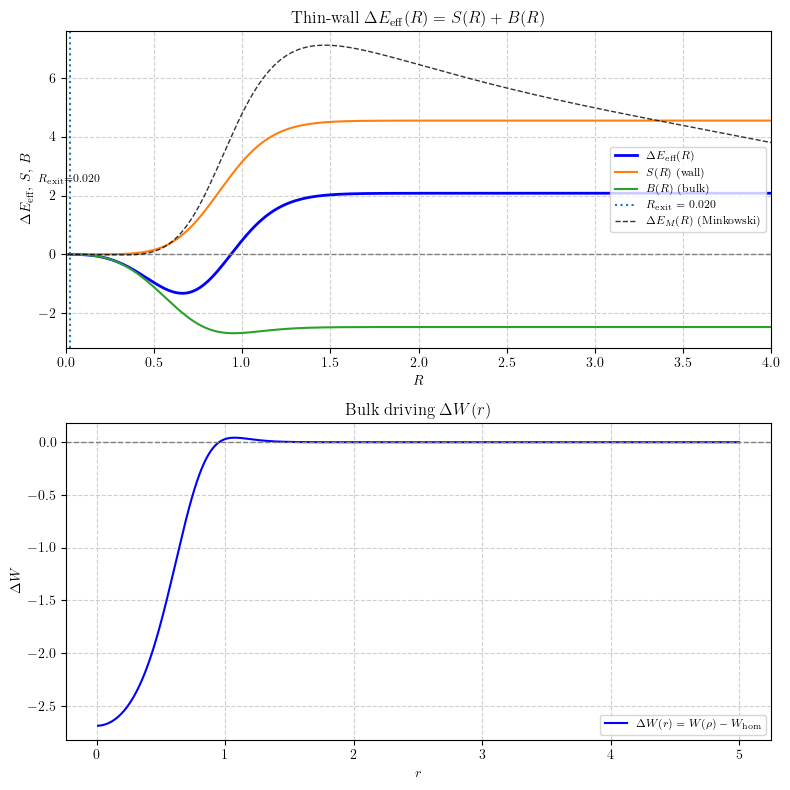

In [ ]:
# =============================================================================
# Thin-wall-inspired effective energy functional: ΔE_eff(R) using W(ρ;ω)=U(ρ)−ω²ρ²
# ΔE_eff(R) = S(R) + B(R) with S = ∫ 4π r²[(∂rρ)² + ρ²(∂rβ̃)²], B = ∫ 4π r² ΔW.
# =============================================================================
from scipy.integrate import cumulative_trapezoid

def _dr1_radial(r, f):
    r, f = np.asarray(r, dtype=float), np.asarray(f)
    df = np.empty_like(f, dtype=np.result_type(f, np.float64))
    n = len(r)
    if n >= 3:
        df[1:-1] = (f[2:] - f[:-2]) / (r[2:] - r[:-2])
        df[0] = (f[1] - f[0]) / (r[1] - r[0])
        df[-1] = (f[-1] - f[-2]) / (r[-1] - r[-2])
    elif n == 2:
        df[:] = (f[1] - f[0]) / (r[1] - r[0])
    else:
        df[:] = 0.0
    return df

solver = solver_res
sol = sol_eta_res
y = np.asarray(sol.y)
ybar = np.asarray(sol.ybar)
r = np.asarray(solver.grid.r, dtype=float).flatten()
rho_eps = 1e-14
rho0_bg = float(solver.rho0)

# (A) τ=0 ghost: same as sol.observables_ghost (y_plus=ybar[:,0], y_minus=y[:,0])
y_minus, ybar_minus = y[:, 0], ybar[:, 0]
y_plus, ybar_plus = ybar[:, 0], y[:, 0]
y0 = 0.5 * (y_plus + y_minus)
ybar0 = 0.5 * (ybar_plus + ybar_minus)
inv_r = np.zeros_like(r, dtype=float)
inv_r[r != 0.0] = 1.0 / r[r != 0.0]
phi0 = rho0_bg + inv_r * y0
phibar0 = rho0_bg + inv_r * ybar0

u = np.maximum((phi0 * phibar0).real, 0.0)
rho = np.sqrt(u + rho_eps)
# β = (1/2)*phase(φ0/φ̄0) = (1/2)*angle(φ0) − (1/2)*angle(φ̄0)
ratio = np.where(np.abs(phibar0) > 1e-30, phi0 / phibar0, 1.0)
beta = 0.5 * np.angle(ratio).real
beta_tilde = beta - beta[-1]

# (B) Radial derivatives
drho_dr = _dr1_radial(r, rho)
dbeta_dr = _dr1_radial(r, beta_tilde)

# (C) W(ρ;ω) = U(ρ) − ω² ρ²; ω = OMEGA, ρ_hom = rho_false_ref_res
omega = float(OMEGA)
rho_hom = float(rho_false_ref_res)
W_r = np.asarray(U(rho)).flatten() - (omega**2) * (rho**2)
W_hom = float(np.asarray(U(np.array([rho_hom]))).flat[0]) - (omega**2) * (rho_hom**2)
Delta_W = W_r - W_hom

# (D) Integrands and cumulative integrals
s_integrand = 4.0 * np.pi * (r**2) * (drho_dr**2 + (rho**2) * (dbeta_dr**2))
b_integrand = 4.0 * np.pi * (r**2) * Delta_W
S_R = np.concatenate([[0.0], cumulative_trapezoid(s_integrand, r)])
B_R = np.concatenate([[0.0], cumulative_trapezoid(b_integrand, r)])
Delta_E_eff_R = S_R + B_R

S_tot = float(S_R[-1])
B_tot = float(B_R[-1])
Delta_E_eff_tot = float(Delta_E_eff_R[-1])
r_max = float(r[-1])

# Zero crossing of ΔE_eff(R)
signs = np.sign(Delta_E_eff_R)
cross = np.where(np.diff(signs) != 0)[0]
if len(cross) > 0:
    i0 = int(cross[0])
    # Linear interpolation: ΔE_eff(R_exit)=0
    R_exit = float(np.interp(0.0, [Delta_E_eff_R[i0], Delta_E_eff_R[i0+1]], [r[i0], r[i0+1]]))
    has_crossing = True
else:
    R_exit = np.nan
    has_crossing = False

# (E) Diagnostics
print("=== Thin-wall-inspired effective energy: ΔE_eff(R) using W(ρ;ω)=U(ρ)−ω²ρ² ===\n")
print("  --- Parameters ---")
print(f"  ω = {omega:.6f},  ρ_hom = {rho_hom:.6f},  ρ(r_max) = {float(rho[-1]):.6f},  |ρ(r_max)−ρ_hom| = {abs(float(rho[-1]) - rho_hom):.3e}")
print(f"\n  W_hom = U(ρ_hom) − ω² ρ_hom² = {W_hom:.6f}")
print(f"  ΔW(r): min = {np.min(Delta_W):.6f}, max = {np.max(Delta_W):.6f}")

print(f"\n  --- Final values at R = r_max = {r_max:.6f} ---")
print(f"  S_tot (wall/gradient) = {S_tot:.6f}")
print(f"  B_tot (bulk driving)  = {B_tot:.6f}")
print(f"  ΔE_eff_tot = S_tot + B_tot = {Delta_E_eff_tot:.6f}")

print("\n  --- Zero crossing of ΔE_eff(R) ---")
if has_crossing:
    print(f"  ΔE_eff(R) crosses zero at R_exit ≈ {R_exit:.6f}")
else:
    print("  No zero crossing of ΔE_eff(R) in [0, r_max].")

# Thin-wall heuristics: σ_eff, ε_eff
drho_max = np.max(np.abs(drho_dr))
thresh = 0.1 * drho_max if drho_max > 1e-30 else 0.0
wall_mask = np.abs(drho_dr) >= thresh
if np.any(wall_mask):
    s_wall = 4.0 * np.pi * (r**2) * (drho_dr**2 + (rho**2) * (dbeta_dr**2))
    sigma_eff = float(np.trapz(s_wall * wall_mask.astype(float), r))
else:
    sigma_eff = np.nan
inner = r < (r_max / 3.0)
W_inside = float(np.mean(W_r[inner])) if np.any(inner) else W_r[0]
epsilon_eff = W_hom - W_inside
print("\n  --- Heuristic thin-wall estimates ---")
print(f"  σ_eff (wall region |∂rρ| ≥ 0.1×max) ≈ {sigma_eff:.6f}" if not np.isnan(sigma_eff) else "  σ_eff: wall region too small.")
print(f"  ε_eff = W_hom − W_inside (inner r < r_max/3) ≈ {epsilon_eff:.6f}")

# (G) Optional: cumulative ΔE_M(R) from observables_ghost e_M_r
obs = getattr(sol, "observables_ghost", None) or {}
from Bubble_finder.observables_2d import homogeneous_E_M_2d
Lr = float(getattr(solver.grid, "Lr", r_max))
V3 = (4.0 / 3.0) * np.pi * (Lr**3)
E_M_hom = float(homogeneous_E_M_2d(omega, rho_hom, Lr, U))
e_M_hom = E_M_hom / V3
if "e_M_r" in obs:
    e_M_r = np.asarray(obs["e_M_r"]).flatten()
    e_M_integrand = 4.0 * np.pi * (r**2) * e_M_r
    E_M_cum = np.concatenate([[0.0], cumulative_trapezoid(e_M_integrand, r)])
    E_M_hom_cum = (4.0 * np.pi / 3.0) * (r**3) * e_M_hom
    Delta_E_M_R = E_M_cum - E_M_hom_cum
    has_EM = True
else:
    Delta_E_M_R = None
    has_EM = False

if has_EM:
    print("\n  --- Comparison: ΔE_M(R) vs ΔE_eff(R) ---")
    print("  ΔE_M uses bulk density U+ω²ρ² (Minkowski); ΔE_eff uses W = U−ω²ρ² in bulk term.")

# Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.plot(r, Delta_E_eff_R, "b-", lw=2, label=r"$\Delta E_{\mathrm{eff}}(R)$")
ax1.plot(r, S_R, "C1-", lw=1.5, label=r"$S(R)$ (wall)")
ax1.plot(r, B_R, "C2-", lw=1.5, label=r"$B(R)$ (bulk)")
ax1.axhline(0.0, color="gray", ls="--", lw=1)
if has_crossing:
    ax1.axvline(R_exit, color="C0", ls=":", lw=1.5, label=rf"$R_{{\mathrm{{exit}}}}$ = {R_exit:.3f}")
    ax1.annotate(f"$R_{{\mathrm{{exit}}}}$={R_exit:.3f}", xy=(R_exit, 0), xytext=(R_exit, ax1.get_ylim()[1]*0.5), fontsize=8, ha="center")
if has_EM:
    ax1.plot(r, Delta_E_M_R, "k--", lw=1, alpha=0.8, label=r"$\Delta E_M(R)$ (Minkowski)")
ax1.set_xlabel(r"$R$")
ax1.set_ylabel(r"$\Delta E_{\mathrm{eff}}$, $S$, $B$")
ax1.set_xlim(0, 4)
ax1.set_title(r"Thin-wall $\Delta E_{\mathrm{eff}}(R) = S(R) + B(R)$")
ax1.legend(loc="right", fontsize=8)
ax1.grid(True, ls="--", alpha=0.6)

ax2.plot(r, Delta_W, "b-", lw=1.5, label=r"$\Delta W(r) = W(\rho) - W_{\mathrm{hom}}$")
ax2.axhline(0.0, color="gray", ls="--", lw=1)
ax2.set_xlabel(r"$r$")
ax2.set_ylabel(r"$\Delta W$")
ax2.set_title(r"Bulk driving $\Delta W(r)$")
ax2.legend(loc="best", fontsize=8)
ax2.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

=== Virial/Derrick check for F_ω on the turning slice (τ=0) ===

  Field reconstruction: same ghost as observables_ghost (y_plus=ybar[:,0], y_minus=y[:,0], midpoint φ0=ρ0+y0/r).

  --- Parameters ---
  ω = 0.850000,  ρ_hom = 1.065039,  ρ(r_max) = 1.064734,  |ρ(r_max)−ρ_hom| = 3.047e-04

  --- Functional and volume virial ---
  F       = 4π ∫ r² [ (∂rρ)² + ρ²(∂rβ̃)² + ΔW ] = 2.077736
  T       = 4π ∫ r² [ (∂rρ)² + ρ²(∂rβ̃)² ]     = 4.545338
  V_eff   = 4π ∫ r² [ W(ρ)−W_hom ]             = -2.467602
  2T      = 9.090676
  3V_eff  = -7.402806
  Vcomb   = 2T + 3V_eff = 1.687870e+00
  Vratio  = Vcomb / (|2T|+|3V_eff|) = 1.023e-01

  --- Numerical scaling derivative F'(1) ---
  F'(1) (ελ = 0.001) = 3.828872e+00
  F'(1) (ελ = 0.0005) = 4.799756e+00 (stability check)

  --- Boundary / residual ---
  B_eff   = F'(1) − (2T+3V_eff) = 2.141002e+00
  B_eff / (|2T|+|3V_eff|)       = 1.298e-01

  --- Boundary-stress proxy at r = Lr ---
  S_bdy   = 4π Lr³ [ ρ_r² + ρ²β_r² − ΔW ]|_Lr = -9.086759e-04
  |

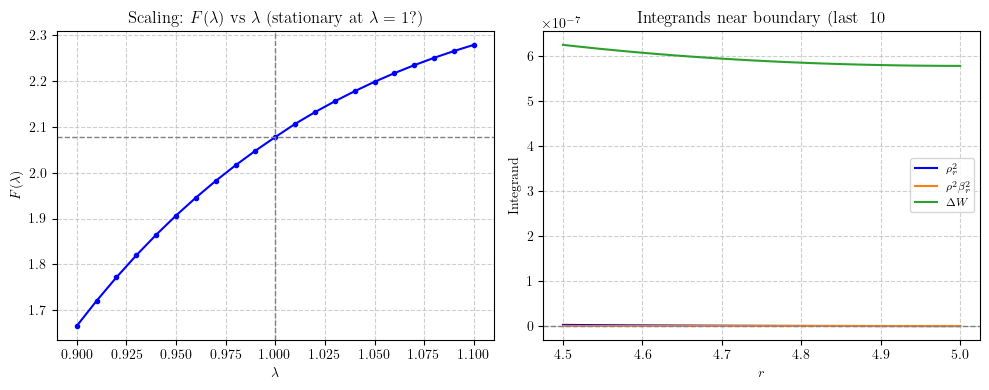

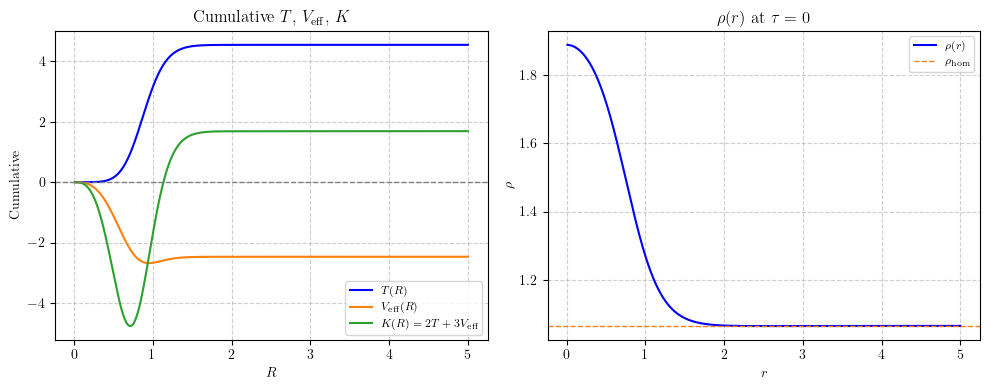

In [18]:
# =============================================================================
# Virial/Derrick check for the constrained 3D functional F_ω on the turning slice
# F_ω = ∫ d³x [ (∇ρ)² + ρ²(∇β)² + (W(ρ;ω)−W_hom) ]. Derrick: 2T + 3V_eff = 0 at stationarity.
# =============================================================================
from scipy.integrate import simpson, cumulative_trapezoid

def _dr1_radial(r, f):
    r, f = np.asarray(r, dtype=float), np.asarray(f)
    df = np.empty_like(f, dtype=np.result_type(f, np.float64))
    n = len(r)
    if n >= 3:
        df[1:-1] = (f[2:] - f[:-2]) / (r[2:] - r[:-2])
        df[0] = (f[1] - f[0]) / (r[1] - r[0])
        df[-1] = (f[-1] - f[-2]) / (r[-1] - r[-2])
    elif n == 2:
        df[:] = (f[1] - f[0]) / (r[1] - r[0])
    else:
        df[:] = 0.0
    return df

solver = solver_res
sol = sol_eta_res
y = np.asarray(sol.y)
ybar = np.asarray(sol.ybar)
r = np.asarray(solver.grid.r, dtype=float).flatten()
rho_eps = 1e-14
rho0_bg = float(solver.rho0)

# (A) τ=0 ghost: same as sol.observables_ghost (y_plus=ybar[:,0], y_minus=y[:,0])
y_minus, ybar_minus = y[:, 0], ybar[:, 0]
y_plus, ybar_plus = ybar[:, 0], y[:, 0]
y0 = 0.5 * (y_plus + y_minus)
ybar0 = 0.5 * (ybar_plus + ybar_minus)
inv_r = np.zeros_like(r, dtype=float)
inv_r[r != 0.0] = 1.0 / r[r != 0.0]
phi0 = rho0_bg + inv_r * y0
phibar0 = rho0_bg + inv_r * ybar0

print("=== Virial/Derrick check for F_ω on the turning slice (τ=0) ===\n")
print("  Field reconstruction: same ghost as observables_ghost (y_plus=ybar[:,0], y_minus=y[:,0], midpoint φ0=ρ0+y0/r).")

# (B) ρ(r), β(r), β̃(r)
u = np.maximum((phi0 * phibar0).real, 0.0)
rho = np.sqrt(u + rho_eps)
ratio = np.where(np.abs(phibar0) > 1e-30, phi0 / phibar0, 1.0)
beta = 0.5 * np.angle(ratio).real
beta_tilde = beta - beta[-1]

# (C) Radial derivatives
rho_r = _dr1_radial(r, rho)
beta_r = _dr1_radial(r, beta_tilde)

# (D) W(ρ;ω) = U(ρ) − ω²ρ², W_hom, ΔW
omega = float(OMEGA)
rho_hom = float(rho_false_ref_res)
W_r = np.asarray(U(rho)).flatten() - (omega**2) * (rho**2)
W_hom = float(np.asarray(U(np.array([rho_hom]))).flat[0]) - (omega**2) * (rho_hom**2)
Delta_W = W_r - W_hom

# Integrands: T density = ρ_r² + ρ² β_r², V_eff density = ΔW
t_integrand = (rho_r**2) + (rho**2) * (beta_r**2)
v_integrand = Delta_W

# T = 4π ∫ r² [ ρ_r² + ρ² β_r² ],  V_eff = 4π ∫ r² ΔW
T = float(4.0 * np.pi * simpson(r**2 * t_integrand, x=r))
V_eff = float(4.0 * np.pi * simpson(r**2 * v_integrand, x=r))

# (E) Virial: 2T + 3V_eff = 0 at stationarity (volume term only)
two_T = 2.0 * T
three_V = 3.0 * V_eff
Vcomb = two_T + three_V
denom = max(abs(two_T) + abs(three_V), 1e-30)
Vratio = Vcomb / denom

# 1) Full constrained functional F = 4π ∫_0^{Lr} dr r² [ ρ_r² + ρ² β_r² + ΔW ]
F = float(4.0 * np.pi * simpson(r**2 * (t_integrand + v_integrand), x=r))

print("\n  --- Parameters ---")
print(f"  ω = {omega:.6f},  ρ_hom = {rho_hom:.6f},  ρ(r_max) = {float(rho[-1]):.6f},  |ρ(r_max)−ρ_hom| = {abs(float(rho[-1]) - rho_hom):.3e}")

print("\n  --- Functional and volume virial ---")
print(f"  F       = 4π ∫ r² [ (∂rρ)² + ρ²(∂rβ̃)² + ΔW ] = {F:.6f}")
print(f"  T       = 4π ∫ r² [ (∂rρ)² + ρ²(∂rβ̃)² ]     = {T:.6f}")
print(f"  V_eff   = 4π ∫ r² [ W(ρ)−W_hom ]             = {V_eff:.6f}")
print(f"  2T      = {two_T:.6f}")
print(f"  3V_eff  = {three_V:.6f}")
print(f"  Vcomb   = 2T + 3V_eff = {Vcomb:.6e}")
print(f"  Vratio  = Vcomb / (|2T|+|3V_eff|) = {Vratio:.3e}")

# 2) Numerical scaling derivative F'(1): scaled profiles ρ_λ(r)=ρ(λr), β_λ(r)=β̃(λr)
r_max = float(r[-1])
Lr = r_max

def F_at_lam(lam):
    r_eval = lam * r
    rho_lam = np.where(r_eval <= r_max, np.interp(r_eval, r, rho), rho_hom)
    beta_lam = np.where(r_eval <= r_max, np.interp(r_eval, r, beta_tilde), 0.0)
    rho_lam_r = _dr1_radial(r, rho_lam)
    beta_lam_r = _dr1_radial(r, beta_lam)
    W_lam = np.asarray(U(rho_lam)).flatten() - (omega**2) * (rho_lam**2) - W_hom
    integrand = (rho_lam_r**2) + (rho_lam**2) * (beta_lam_r**2) + W_lam
    return float(4.0 * np.pi * simpson(r**2 * integrand, x=r))

eps_lam_1 = 1e-3
eps_lam_2 = 5e-4
F_prime_1 = (F_at_lam(1.0 + eps_lam_1) - F_at_lam(1.0 - eps_lam_1)) / (2.0 * eps_lam_1)
F_prime_2 = (F_at_lam(1.0 + eps_lam_2) - F_at_lam(1.0 - eps_lam_2)) / (2.0 * eps_lam_2)

print("\n  --- Numerical scaling derivative F'(1) ---")
print(f"  F'(1) (ελ = {eps_lam_1}) = {F_prime_1:.6e}")
print(f"  F'(1) (ελ = {eps_lam_2}) = {F_prime_2:.6e} (stability check)")

# 3) Missing boundary term B_eff = F'(1) − Vcomb
F_prime_use = F_prime_1
B_eff = F_prime_use - Vcomb
B_ratio = B_eff / denom if denom > 0 else 0.0
print("\n  --- Boundary / residual ---")
print(f"  B_eff   = F'(1) − (2T+3V_eff) = {B_eff:.6e}")
print(f"  B_eff / (|2T|+|3V_eff|)       = {B_ratio:.3e}")

# 4) Boundary-stress estimate at r = Lr
rho_r_Lr = float(rho_r[-1])
rho_Lr = float(rho[-1])
beta_r_Lr = float(beta_r[-1])
Delta_W_Lr = float(Delta_W[-1])
S_bdy = 4.0 * np.pi * (Lr**3) * (rho_r_Lr**2 + (rho_Lr**2) * (beta_r_Lr**2) - Delta_W_Lr)
print("\n  --- Boundary-stress proxy at r = Lr ---")
print(f"  S_bdy   = 4π Lr³ [ ρ_r² + ρ²β_r² − ΔW ]|_Lr = {S_bdy:.6e}")
print(f"  |S_bdy| vs |B_eff|: S_bdy/B_eff = {S_bdy/B_eff:.3e}" if abs(B_eff) > 1e-30 else "  (B_eff ≈ 0)")

# Interpretation
tol_virial = 3e-3
print("\n  --- Interpretation ---")
if abs(F_prime_use) <= tol_virial * max(abs(two_T) + abs(three_V), 1e-30):
    print("  → F'(1) ≈ 0: τ=0 slice is approximately stationary for F_ω (including boundary).")
elif abs(B_eff) >= 0.5 * abs(Vcomb) and np.sign(B_eff) != np.sign(Vcomb):
    print("  → Nonzero virial residual 2T+3V_eff is partly explained by boundary terms (B_eff = F'(1)−Vcomb); check S_bdy order of magnitude.")
else:
    print("  → F'(1) far from 0 and/or B_eff does not account for Vcomb: τ=0 slice is not a stationary point of F_ω even with boundary completion (thick-wall or not an exit configuration).")

# (F) Cumulative and diagnostics plots
t_cum_integrand = 4.0 * np.pi * (r**2) * t_integrand
v_cum_integrand = 4.0 * np.pi * (r**2) * v_integrand
T_R = np.concatenate([[0.0], cumulative_trapezoid(t_cum_integrand, r)])
V_eff_R = np.concatenate([[0.0], cumulative_trapezoid(v_cum_integrand, r)])
K_R = 2.0 * T_R + 3.0 * V_eff_R

# 5) Plots: F(λ) vs λ; integrands near boundary
lam_grid = np.linspace(0.9, 1.1, 21)
F_lam = np.array([F_at_lam(lam) for lam in lam_grid])

mask_bdy = r >= (0.9 * r_max)
r_bdy = r[mask_bdy]
rho_r2_bdy = (rho_r**2)[mask_bdy]
rho2_beta_r2_bdy = ((rho**2) * (beta_r**2))[mask_bdy]
Delta_W_bdy = Delta_W[mask_bdy]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.plot(lam_grid, F_lam, "b.-", lw=1.5, ms=6)
ax.axvline(1.0, color="gray", ls="--", lw=1)
ax.axhline(F, color="gray", ls="--", lw=1)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$F(\lambda)$")
ax.set_title(r"Scaling: $F(\lambda)$ vs $\lambda$ (stationary at $\lambda=1$?)")
ax.grid(True, ls="--", alpha=0.6)

ax = axes[1]
ax.plot(r_bdy, rho_r2_bdy, "b-", lw=1.5, label=r"$\rho_r^2$")
ax.plot(r_bdy, rho2_beta_r2_bdy, "C1-", lw=1.5, label=r"$\rho^2 \beta_r^2$")
ax.plot(r_bdy, Delta_W_bdy, "C2-", lw=1.5, label=r"$\Delta W$")
ax.axhline(0.0, color="gray", ls="--", lw=1)
ax.set_xlabel(r"$r$")
ax.set_ylabel("Integrand")
ax.set_title(r"Integrands near boundary (last ~10% of $r$)")
ax.legend(loc="best", fontsize=8)
ax.grid(True, ls="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Optional: cumulative and ρ(r) in a second figure
fig2, ax2 = plt.subplots(1, 2, figsize=(10, 4))
ax2[0].plot(r, T_R, "b-", lw=1.5, label=r"$T(R)$")
ax2[0].plot(r, V_eff_R, "C1-", lw=1.5, label=r"$V_{\mathrm{eff}}(R)$")
ax2[0].plot(r, K_R, "C2-", lw=1.5, label=r"$K(R)=2T+3V_{\mathrm{eff}}$")
ax2[0].axhline(0.0, color="gray", ls="--", lw=1)
ax2[0].set_xlabel(r"$R$")
ax2[0].set_ylabel("Cumulative")
ax2[0].set_title(r"Cumulative $T$, $V_{\mathrm{eff}}$, $K$")
ax2[0].legend(loc="best", fontsize=8)
ax2[0].grid(True, ls="--", alpha=0.6)
ax2[1].plot(r, rho, "b-", lw=1.5, label=r"$\rho(r)$")
ax2[1].axhline(rho_hom, color="C1", ls="--", lw=1, label=rf"$\rho_{{\mathrm{{hom}}}}$")
ax2[1].set_xlabel(r"$r$")
ax2[1].set_ylabel(r"$\rho$")
ax2[1].set_title(r"$\rho(r)$ at $\tau=0$")
ax2[1].legend(loc="best", fontsize=8)
ax2[1].grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

=== (3) 2D scaling test (project-consistent): ΔS_full(λ) = S_full[bounce_λ] - S_full[hom] ===

  Action computed with rate_exponent.compute_euclidean_action_full and compute_homogeneous_action.
  Scaling via pullback of complex (phi, phibar) and reconstruction of (y,ybar) using solver definitions.
  Out-of-domain filled with homogeneous phi_hom(τ), phibar_hom(τ) (no masking).

  λ=0.98: oob fraction ≈ 0.0053
  λ=0.99: oob fraction ≈ 0.0053
  λ=1.00: oob fraction ≈ 0.0000
  λ=1.01: oob fraction ≈ 0.0126
  λ=1.02: oob fraction ≈ 0.0126

  ΔS(1)              = 1.742580902e+01
  ΔS'(1) (ε=1e-3)     = -2.928002463e+04
  ΔS'(1) (ε=5e-4)     = -6.042722494e+04   (stability)
  |ΔS'(1)|/max(1,|ΔS(1)|) = 1.680e+03

  Note: This is a *numerical diagnostic*. If it still blows up, the next suspect is
        the constrained nature of allowed variations (twist/ghost) or lack of convergence.



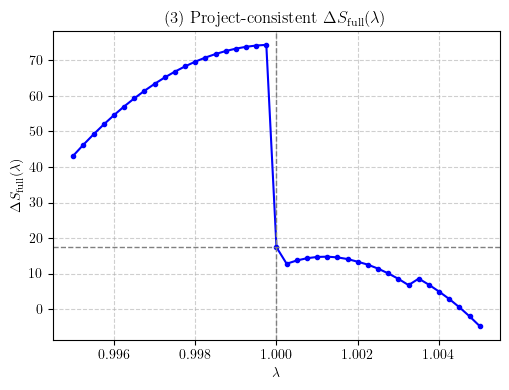

/tmp/ipykernel_139014/2511000898.py:318: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_tau = 4.0 * np.pi * np.trapz(r2 * Delta_T_tt, r, axis=0)


=== (4) Stress-energy / flux identity (phi,phibar; ghost-aware tau derivatives) ===

  L = Re(phi_tau phibar_tau + phi_r phibar_r) + V(s),  T_{μν} = Re(∂μφ ∂νφ̄ + ∂νφ ∂μφ̄) - δ_{μν} L
  Residual: R = ∂τ(r^2 ΔT_tt) + ∂r(r^2 ΔT_rt).  Integrated: dE/dτ ≈ -F_bdy.

  max|R| = 7.906853e-01,  RMS(R) = 6.394558e-02
  max|dE/dτ + F_bdy| = 4.415517e+00,  RMS = 1.333261e+00
  |F_bdy(τ)| range: [1.296e-05, 4.081e-03]


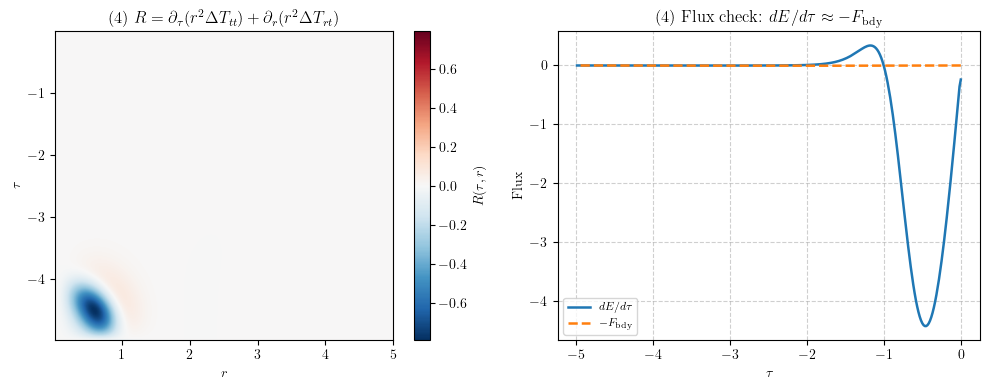

/tmp/ipykernel_139014/2511000898.py:357: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  R_tau_profile = 4.0 * np.pi * np.trapz(r2 * np.abs(R_res), r, axis=0)


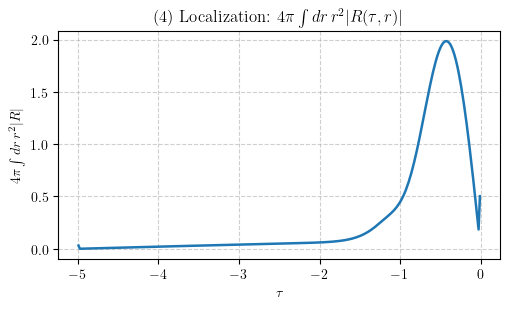

In [ ]:
# =============================================================================
# Correct 2D diagnostics (CONSISTENT with solver conventions)
#
# (3) 2D scaling / virial-like test using the SAME Euclidean action as rate_exponent.py
# (4) Stress-energy / flux identity using phi, phibar and the SAME ghost-aware tau derivatives
#
# Key fixes vs previous attempts:
#   - No (rho, beta) decomposition (avoids phase branch cut + wrong theory for complex saddle).
#   - No sorting/reindexing of tau (keeps solver ghost/twist conventions intact).
#   - Action computed with rate_exponent.compute_euclidean_action_half/full and homogeneous_action.
#   - Scaling family built by pulling back phi, phibar (complex) and reconstructing y,ybar via solver definition.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# --- 0) Resolve solver + solution from notebook (no .py changes) ---
try:
    solver = solver_res
    sol = sol_eta_res
except NameError:
    try:
        solver = solver_2d_g
        sol = sol_2d_g
    except NameError:
        raise NameError("Need (solver_res, sol_eta_res) or (solver_2d_g, sol_2d_g) available first.")

# --- 1) Import project-consistent action helpers (Bubble_finder.rate_exponent) ---
try:
    from Bubble_finder import rate_exponent as rex
except ImportError as e1:
    import sys
    from pathlib import Path
    _cwd = Path.cwd().resolve()
    _root = None
    for _p in [_cwd, _cwd.parent, _cwd.parent.parent]:
        if (_p / "Bubble_finder" / "rate_exponent.py").exists():
            _root = _p
            break
    if _root is not None and str(_root) not in sys.path:
        sys.path.insert(0, str(_root))
    try:
        from Bubble_finder import rate_exponent as rex
    except ImportError as e2:
        raise ImportError(
            "Could not import rate_exponent. Run the 'Project path and configuration' cell first, "
            "or ensure PROJECT_ROOT (parent of Bubble_finder) is in sys.path.\n"
            f"Original: {e1}\nAfter path fix: {e2}"
        )

# --- 2) Basic objects / grids (DO NOT sort tau) ---
grid = solver.grid
r = np.asarray(grid.r, dtype=float).flatten()
tau = np.asarray(grid.tau, dtype=float).flatten()
Nr = int(getattr(grid, "Nr", r.size))
Nt = int(getattr(grid, "Ntau", tau.size))
dt = float(getattr(grid, "dtau", getattr(grid, "dt", None)))
if dt is None or dt <= 0:
    raise ValueError("Could not determine dtau from solver.grid.dtau (or solver.grid.dt).")

# unpack y,ybar
y, ybar = solver.unpack(sol.x) if hasattr(sol, "x") else (sol.y, sol.ybar)  # robust-ish
# If sol stores y,ybar differently, fall back
if not (isinstance(y, np.ndarray) and isinstance(ybar, np.ndarray) and y.shape == (Nr, Nt)):
    try:
        y = sol.y
        ybar = sol.ybar
    except Exception:
        raise ValueError("Cannot find y,ybar arrays. Expected y.shape==(Nr,Nt).")

omega = float(getattr(solver, "omega"))
rho0 = float(getattr(solver, "rho0"))
eta0 = float(getattr(solver, "eta0", 0.0))  # twist used in tau ghost rule at i=Nt-1
U = solver.U  # in your code U takes rho, but rate_exponent wants V_of_s(s) where s=Re(phi*phibar) >=0

# Build V_of_s from solver.U if needed:
# From bounce2d.py: potential is U(rho) with rho = sqrt(s + rho_eps). In rate_exponent it calls V_of_s(s) directly.
rho_eps = float(getattr(getattr(solver, "settings", object()), "rho_eps", 0.0))
def V_of_s(s):
    s = np.asarray(s, dtype=float)
    s_pos = np.maximum(s, 0.0)
    rho = np.sqrt(s_pos + rho_eps)
    return np.asarray(U(rho), dtype=float)

# --- 3) Homogeneous reference action on the same ball volume (project convention) ---
V_ball = rex.volume_from_grid(grid)
beta = float(getattr(getattr(solver, "settings", object()), "beta", None))
if beta is None:
    # If beta isn't in settings, infer from tau endpoints (tau in (-beta/2, 0))
    beta = float(-2.0 * np.min(tau))
S_hom = rex.compute_homogeneous_action(beta=beta, V_ball=V_ball, omega=omega, rho0=rho0, V_of_s=V_of_s)

# --- 4) Convenience: reconstruct phi, phibar on-grid (physical, not rotated) ---
phi, phibar = solver.phi(y, ybar)  # shape (Nr,Nt), complex

# Homogeneous fields (physical):
# phi_hom(τ)=rho0*exp(+omega τ), phibar_hom(τ)=rho0*exp(-omega τ)
phi_hom = (rho0 * np.exp(omega * tau))[None, :] * np.ones((Nr, 1))
phibar_hom = (rho0 * np.exp(-omega * tau))[None, :] * np.ones((Nr, 1))

# --- 5) (3) Scaling test: pull back phi, phibar and reconstruct y,ybar, then compute S_E with rate_exponent ---
# Interpolate complex fields safely by interpolating real+imag separately.
phi_re_itp = RegularGridInterpolator((r, tau), phi.real, bounds_error=False, fill_value=np.nan)
phi_im_itp = RegularGridInterpolator((r, tau), phi.imag, bounds_error=False, fill_value=np.nan)
pb_re_itp  = RegularGridInterpolator((r, tau), phibar.real, bounds_error=False, fill_value=np.nan)
pb_im_itp  = RegularGridInterpolator((r, tau), phibar.imag, bounds_error=False, fill_value=np.nan)

R, T = np.meshgrid(r, tau, indexing="ij")  # (Nr,Nt)

def build_scaled_y_ybar(lam):
    """
    Build y_λ, ybar_λ on the SAME grid (r,tau) by pullback:
      phi_λ(τ,r) = phi(λτ, λr)  (filled with homogeneous outside domain)
    Then reconstruct solver variables:
      phi_rot = exp(-omega τ) * phi
      y = r*(phi_rot - rho0)
      similarly for ybar with exp(+omega τ)
    """
    pts = np.column_stack([(lam * R).ravel(), (lam * T).ravel()])
    ph_re = phi_re_itp(pts).reshape(R.shape)
    ph_im = phi_im_itp(pts).reshape(R.shape)
    pb_re = pb_re_itp(pts).reshape(R.shape)
    pb_im = pb_im_itp(pts).reshape(R.shape)
    phi_lam = ph_re + 1j * ph_im
    pb_lam  = pb_re + 1j * pb_im

    # out-of-domain -> homogeneous fill (physical fields)
    in_dom = (
        (lam * R >= r.min()) & (lam * R <= r.max()) &
        (lam * T >= tau.min()) & (lam * T <= tau.max())
    )
    oob = ~(in_dom & np.isfinite(phi_lam.real) & np.isfinite(pb_lam.real))
    if np.any(oob):
        phi_lam = np.where(oob, phi_hom, phi_lam)
        pb_lam  = np.where(oob, phibar_hom, pb_lam)

    # reconstruct y, ybar from solver definition:
    # phi_rot := exp(-omega τ) * phi,   y := r*(phi_rot - rho0)
    exp_m = np.exp(-omega * tau)[None, :]
    exp_p = np.exp(+omega * tau)[None, :]
    phi_rot_lam = exp_m * phi_lam
    pb_rot_lam  = exp_p * pb_lam

    # y = r*(phi_rot - rho0)
    y_lam = (r[:, None]) * (phi_rot_lam - rho0)
    yb_lam = (r[:, None]) * (pb_rot_lam - rho0)

    # enforce r=0 regular: y(0,τ)=0 by construction if r[0]=0; if not, leave as is
    return y_lam, yb_lam, float(np.mean(oob))

def S_full_from_y(y_in, yb_in):
    # solver stores half interval; rate_exponent doubles internally if you call full.
    return float(rex.compute_euclidean_action_full(y_in, yb_in, grid, omega, eta0, rho0, V_of_s))

def DeltaS_full(lam):
    y_lam, yb_lam, oob_frac = build_scaled_y_ybar(lam)
    S_b = S_full_from_y(y_lam, yb_lam)
    return (S_b - S_hom), oob_frac

# Evaluate ΔS(λ)
lambdas = np.linspace(0.995, 1.005, 41)
dS = np.zeros_like(lambdas)
oob = np.zeros_like(lambdas)
for i, lam in enumerate(lambdas):
    dS[i], oob[i] = DeltaS_full(lam)

i1 = int(np.argmin(np.abs(lambdas - 1.0)))
dS1 = float(dS[i1])

def fd_prime(eps):
    Sp, _ = DeltaS_full(1.0 + eps)
    Sm, _ = DeltaS_full(1.0 - eps)
    return (Sp - Sm) / (2.0 * eps)

dSprime_1e3 = fd_prime(1e-3)
dSprime_5e4 = fd_prime(5e-4)
ratio = abs(dSprime_1e3) / max(1.0, abs(dS1))

print("=== (3) 2D scaling test (project-consistent): ΔS_full(λ) = S_full[bounce_λ] - S_full[hom] ===\n")
print("  Action computed with rate_exponent.compute_euclidean_action_full and compute_homogeneous_action.")
print("  Scaling via pullback of complex (phi, phibar) and reconstruction of (y,ybar) using solver definitions.")
print("  Out-of-domain filled with homogeneous phi_hom(τ), phibar_hom(τ) (no masking).\n")
for lam, f in zip([0.98, 0.99, 1.0, 1.01, 1.02], [oob[np.argmin(abs(lambdas-x))] for x in [0.98,0.99,1.0,1.01,1.02]]):
    print(f"  λ={lam:.2f}: oob fraction ≈ {f:.4f}")
print(f"\n  ΔS(1)              = {dS1:.9e}")
print(f"  ΔS'(1) (ε=1e-3)     = {dSprime_1e3:.9e}")
print(f"  ΔS'(1) (ε=5e-4)     = {dSprime_5e4:.9e}   (stability)")
print(f"  |ΔS'(1)|/max(1,|ΔS(1)|) = {ratio:.3e}")
print("\n  Note: This is a *numerical diagnostic*. If it still blows up, the next suspect is")
print("        the constrained nature of allowed variations (twist/ghost) or lack of convergence.\n")

fig, ax = plt.subplots(figsize=(5.2, 4.0))
ax.plot(lambdas, dS, "b.-", lw=1.5, ms=6)
ax.axvline(1.0, color="gray", ls="--", lw=1)
ax.axhline(dS1, color="gray", ls="--", lw=1)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\Delta S_{\mathrm{full}}(\lambda)$")
ax.set_title(r"(3) Project-consistent $\Delta S_{\mathrm{full}}(\lambda)$")
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- 6) (4) Stress-energy / flux identity (project-consistent derivatives) ---
# We use L = Re(φ_τ φ̄_τ + φ_r φ̄_r) + V(s), with s=Re(φ φ̄)≥0, and canonical tensor for two real fields:
#   T_{μν} = Re(∂_μ φ ∂_ν φ̄ + ∂_ν φ ∂_μ φ̄) - δ_{μν} L
# In (τ,r) with O(3) radial measure: check R = ∂_τ(r^2 ΔT_{ττ}) + ∂_r(r^2 ΔT_{rτ}) ≈ 0
#
# IMPORTANT: τ-derivatives must use the same BC-aware ghost rules as the solver (via solver._tau_neighbors).

def dr1_radial_complex(r, f):
    r = np.asarray(r, float)
    f = np.asarray(f)
    df = np.empty_like(f, dtype=np.result_type(f, np.complex128))
    n = len(r)
    if n >= 3:
        df[1:-1] = (f[2:] - f[:-2]) / (r[2:] - r[:-2])
        df[0] = (f[1] - f[0]) / (r[1] - r[0])
        df[-1] = (f[-1] - f[-2]) / (r[-1] - r[-2])
    elif n == 2:
        df[:] = (f[1] - f[0]) / (r[1] - r[0])
    else:
        df[:] = 0.0
    return df

def tau_derivative_centered(tau, dt, y_im1, y_ip1):
    # Same logic as observables_2d._tau_derivative_centered
    tau = np.asarray(tau, float)
    if len(tau) >= 2 and (tau[1] > tau[0]):
        return (y_ip1 - y_im1) / (2.0 * dt)
    return (y_im1 - y_ip1) / (2.0 * dt)

# Build per-slice phi_tau, phibar_tau, phi_r, phibar_r (bounce and hom), then T components.
r2 = (r[:, None] ** 2)
Delta_T_tt = np.zeros((Nr, Nt), dtype=float)
Delta_T_rt = np.zeros((Nr, Nt), dtype=float)

# Precompute hom derivatives analytically (physical fields):
# phi_hom = rho0 e^{ωτ} => phi_tau = ω phi_hom ; phibar_tau = -ω phibar_hom ; radial derivatives zero.
phi_tau_hom = omega * phi_hom
pb_tau_hom  = -omega * phibar_hom
phi_r_hom   = np.zeros_like(phi_hom, dtype=complex)
pb_r_hom    = np.zeros_like(phibar_hom, dtype=complex)

# Potential pieces
def V_slice(phi_i, pb_i):
    s = (phi_i * pb_i).real
    s = np.maximum(s, 0.0)
    return V_of_s(s)

for i in range(Nt):
    y_im1, y_ip1, yb_im1, yb_ip1 = solver._tau_neighbors(y, ybar, i)
    y_t  = tau_derivative_centered(tau, dt, y_im1, y_ip1)
    yb_t = tau_derivative_centered(tau, dt, yb_im1, yb_ip1)

    # reconstruct phi_tau, phibar_tau exactly like rate_exponent / observables_2d
    inv_r = np.where(r > 0, 1.0 / r, 0.0)
    y_tot = y[:, i] + r * rho0
    yb_tot = ybar[:, i] + r * rho0
    exp_p = np.exp(+omega * tau[i]) * inv_r
    exp_m = np.exp(-omega * tau[i]) * inv_r
    phi_tau = exp_p * (y_t + omega * y_tot)
    pb_tau  = exp_m * (yb_t - omega * yb_tot)

    # radial derivatives on physical fields
    phi_r = dr1_radial_complex(r, phi[:, i])
    pb_r  = dr1_radial_complex(r, phibar[:, i])

    # Lagrangian densities
    Vb = V_slice(phi[:, i], phibar[:, i])
    Lb = (phi_tau * pb_tau).real + (phi_r * pb_r).real + Vb.real

    Vh = V_slice(phi_hom[:, i], phibar_hom[:, i])
    Lh = (phi_tau_hom[:, i] * pb_tau_hom[:, i]).real + 0.0 + Vh.real

    # Stress-energy components (canonical symmetric)
    # T_tt = Re(2 phi_tau pb_tau) - L
    # T_rt = Re(phi_r pb_tau + phi_tau pb_r)
    T_tt_b = (2.0 * (phi_tau * pb_tau).real) - Lb
    T_rt_b = (phi_r * pb_tau + phi_tau * pb_r).real

    T_tt_h = (2.0 * (phi_tau_hom[:, i] * pb_tau_hom[:, i]).real) - Lh
    T_rt_h = (phi_r_hom[:, i] * pb_tau_hom[:, i] + phi_tau_hom[:, i] * pb_r_hom[:, i]).real  # =0

    Delta_T_tt[:, i] = T_tt_b - T_tt_h
    Delta_T_rt[:, i] = T_rt_b - T_rt_h

# Compute residual R = ∂τ(r^2 ΔT_tt) + ∂r(r^2 ΔT_rt)
# Use simple finite differences consistent with tau orientation for ∂τ:
def d_dtau_array(arr):
    out = np.empty_like(arr)
    # centered interior
    out[:, 1:-1] = (arr[:, 2:] - arr[:, :-2]) / (tau[2:] - tau[:-2])[None, :]
    out[:, 0] = (arr[:, 1] - arr[:, 0]) / (tau[1] - tau[0])
    out[:, -1] = (arr[:, -1] - arr[:, -2]) / (tau[-1] - tau[-2])
    return out

def d_dr_array(arr):
    out = np.empty_like(arr)
    if Nr >= 3:
        out[1:-1, :] = (arr[2:, :] - arr[:-2, :]) / (r[2:] - r[:-2])[:, None]
        out[0, :] = (arr[1, :] - arr[0, :]) / (r[1] - r[0])
        out[-1, :] = (arr[-1, :] - arr[-2, :]) / (r[-1] - r[-2])
    elif Nr == 2:
        out[:, :] = (arr[1, :] - arr[0, :]) / (r[1] - r[0])
    else:
        out[:] = 0.0
    return out

r2Ttt = r2 * Delta_T_tt
r2Trt = r2 * Delta_T_rt
R_res = d_dtau_array(r2Ttt) + d_dr_array(r2Trt)

R_max = float(np.nanmax(np.abs(R_res)))
R_rms = float(np.sqrt(np.nanmean(R_res**2)))

# Integrated flux identity: E(τ)=4π∫dr r^2 ΔT_tt ; F_bdy=4π [r^2 ΔT_rt]_0^L
E_tau = 4.0 * np.pi * np.trapz(r2 * Delta_T_tt, r, axis=0)
F_bdy = 4.0 * np.pi * (r2[-1, :] * Delta_T_rt[-1, :] - r2[0, :] * Delta_T_rt[0, :])
dE_dt = np.gradient(E_tau, tau)
disc = dE_dt + F_bdy
disc_max = float(np.nanmax(np.abs(disc)))
disc_rms = float(np.sqrt(np.nanmean(disc**2)))
Fmin, Fmax = float(np.nanmin(np.abs(F_bdy))), float(np.nanmax(np.abs(F_bdy)))

print("=== (4) Stress-energy / flux identity (phi,phibar; ghost-aware tau derivatives) ===\n")
print("  L = Re(phi_tau phibar_tau + phi_r phibar_r) + V(s),  T_{μν} = Re(∂μφ ∂νφ̄ + ∂νφ ∂μφ̄) - δ_{μν} L")
print("  Residual: R = ∂τ(r^2 ΔT_tt) + ∂r(r^2 ΔT_rt).  Integrated: dE/dτ ≈ -F_bdy.\n")
print(f"  max|R| = {R_max:.6e},  RMS(R) = {R_rms:.6e}")
print(f"  max|dE/dτ + F_bdy| = {disc_max:.6e},  RMS = {disc_rms:.6e}")
print(f"  |F_bdy(τ)| range: [{Fmin:.3e}, {Fmax:.3e}]")

# Plots
v = max(np.nanmax(np.abs(R_res)), 1e-30)
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im = axs[0].imshow(
    R_res.T, origin="lower", aspect="auto",
    extent=[r.min(), r.max(), tau.min(), tau.max()],
    cmap="RdBu_r", vmin=-v, vmax=v
)
plt.colorbar(im, ax=axs[0], label=r"$R(\tau,r)$")
axs[0].set_xlabel(r"$r$")
axs[0].set_ylabel(r"$\tau$")
axs[0].set_title(r"(4) $R=\partial_\tau(r^2\Delta T_{tt})+\partial_r(r^2\Delta T_{rt})$")

axs[1].plot(tau, dE_dt, lw=1.8, label=r"$dE/d\tau$")
axs[1].plot(tau, -F_bdy, "--", lw=1.8, label=r"$-F_{\rm bdy}$")
axs[1].set_xlabel(r"$\tau$")
axs[1].set_ylabel("Flux")
axs[1].grid(True, ls="--", alpha=0.6)
axs[1].legend(fontsize=8)
axs[1].set_title(r"(4) Flux check: $dE/d\tau \approx -F_{\rm bdy}$")
plt.tight_layout()
plt.show()

# Where is the violation?
R_tau_profile = 4.0 * np.pi * np.trapz(r2 * np.abs(R_res), r, axis=0)
fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.plot(tau, R_tau_profile, lw=1.8)
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$4\pi\int dr\,r^2 |R|$")
ax.grid(True, ls="--", alpha=0.6)
ax.set_title(r"(4) Localization: $4\pi\int dr\,r^2 |R(\tau,r)|$")
plt.tight_layout()
plt.show()

max |r^2 ΔT_{rτ}| at r=0    : 2.933082954796608e-06
max |r^2 ΔT_{rτ}| at r=rmax : 0.00032494823486989044


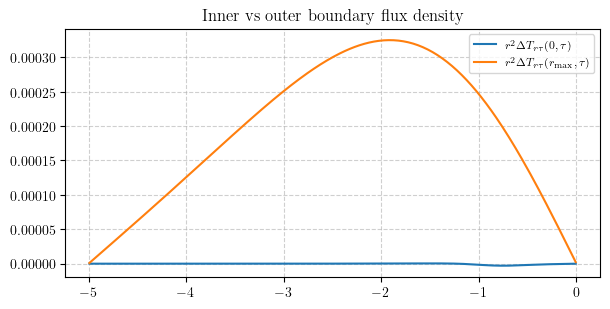

In [ ]:
# Check inner-boundary flux density: r^2 ΔT_{rτ} at r=0
inner_flux = (r[0]**2) * Delta_T_rt[0, :]
outer_flux = (r[-1]**2) * Delta_T_rt[-1, :]

print("max |r^2 ΔT_{rτ}| at r=0    :", np.max(np.abs(inner_flux)))
print("max |r^2 ΔT_{rτ}| at r=rmax :", np.max(np.abs(outer_flux)))

plt.figure(figsize=(6.2,3.2))
plt.plot(tau, inner_flux, label=r"$r^2\Delta T_{r\tau}(0,\tau)$")
plt.plot(tau, outer_flux, label=r"$r^2\Delta T_{r\tau}(r_{\max},\tau)$")
plt.grid(True, ls="--", alpha=0.6)
plt.legend(fontsize=8)
plt.title("Inner vs outer boundary flux density")
plt.tight_layout()
plt.show()

=== Helical conservation (twist-correct) ===
max|R_hel|=7.907e-01, RMS=6.395e-02
max|dE/dτ+F|=4.416e+00, RMS=1.333e+00


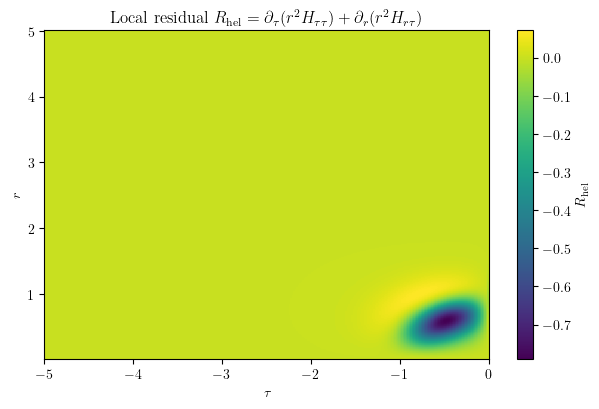

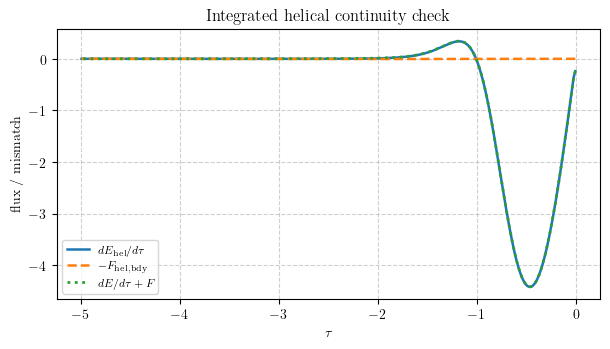

In [ ]:
# =============================================================================
# (4) CORRECT helical stress-energy conservation with twist:
#     ∂τ[r^2 (ΔT_tt - ω Δj_t)] + ∂r[r^2 (ΔT_rt - ω Δj_r)] = 0
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

Nr, Nt = y.shape
r = np.asarray(r, float)
tau = np.asarray(tau, float)
r2 = (r[:, None]**2)

def V_slice(phi_i, pb_i):
    s = (phi_i * pb_i).real
    s = np.maximum(s, 0.0)
    return V_of_s(s)

def dr1_radial_complex(r, f):
    r = np.asarray(r, float)
    f = np.asarray(f)
    df = np.empty_like(f, dtype=np.result_type(f, np.complex128))
    n = len(r)
    if n >= 3:
        df[1:-1] = (f[2:] - f[:-2]) / (r[2:] - r[:-2])
        df[0] = (f[1] - f[0]) / (r[1] - r[0])
        df[-1] = (f[-1] - f[-2]) / (r[-1] - r[-2])
    elif n == 2:
        df[:] = (f[1] - f[0]) / (r[1] - r[0])
    else:
        df[:] = 0.0
    return df

def tau_derivative_centered(tau, dt, y_im1, y_ip1):
    tau = np.asarray(tau, float)
    if len(tau) >= 2 and (tau[1] > tau[0]):
        return (y_ip1 - y_im1) / (2.0 * dt)
    return (y_im1 - y_ip1) / (2.0 * dt)

# --- build components on bounce and hom ---
Delta_T_tt = np.zeros((Nr, Nt), dtype=float)
Delta_T_rt = np.zeros((Nr, Nt), dtype=float)
Delta_j_t  = np.zeros((Nr, Nt), dtype=float)
Delta_j_r  = np.zeros((Nr, Nt), dtype=float)

# homogeneous physical fields
phi_hom = (rho0 * np.exp(omega * tau))[None, :] * np.ones((Nr, 1))
pb_hom  = (rho0 * np.exp(-omega * tau))[None, :] * np.ones((Nr, 1))
phi_tau_hom = omega * phi_hom
pb_tau_hom  = -omega * pb_hom

phi_r_hom = np.zeros_like(phi_hom, dtype=complex)
pb_r_hom  = np.zeros_like(pb_hom, dtype=complex)

inv_r = np.where(r > 0, 1.0/r, 0.0)

for i in range(Nt):
    # ghost-aware tau derivatives on y,ybar
    y_im1, y_ip1, yb_im1, yb_ip1 = solver._tau_neighbors(y, ybar, i)
    y_t  = tau_derivative_centered(tau, dt, y_im1,  y_ip1)
    yb_t = tau_derivative_centered(tau, dt, yb_im1, yb_ip1)

    # reconstruct phi_tau, pb_tau in the SAME way as your action cell
    y_tot  = y[:, i]    + r * rho0
    yb_tot = ybar[:, i] + r * rho0
    exp_p = np.exp(+omega * tau[i]) * inv_r
    exp_m = np.exp(-omega * tau[i]) * inv_r
    phi_tau = exp_p * (y_t  + omega * y_tot)
    pb_tau  = exp_m * (yb_t - omega * yb_tot)

    # radial derivatives on physical fields
    phi_r = dr1_radial_complex(r, phi[:, i])
    pb_r  = dr1_radial_complex(r, phibar[:, i])

    # Lagrangian densities
    Vb = V_slice(phi[:, i], phibar[:, i]).real
    Lb = (phi_tau*pb_tau).real + (phi_r*pb_r).real + Vb

    Vh = V_slice(phi_hom[:, i], pb_hom[:, i]).real
    Lh = (phi_tau_hom[:, i]*pb_tau_hom[:, i]).real + 0.0 + Vh

    # Stress-energy components (Euclidean, symmetric)
    T_tt_b = (2.0*(phi_tau*pb_tau).real) - Lb
    T_rt_b = (phi_r*pb_tau + phi_tau*pb_r).real

    T_tt_h = (2.0*(phi_tau_hom[:, i]*pb_tau_hom[:, i]).real) - Lh
    T_rt_h = 0.0

    Delta_T_tt[:, i] = T_tt_b - T_tt_h
    Delta_T_rt[:, i] = T_rt_b - T_rt_h

    # U(1) current components (consistent with phi,phibar formalism)
    # j_mu = (1/2i)(phibar ∂_mu phi - phi ∂_mu phibar)
    j_t_b = (phibar[:, i]*phi_tau - phi[:, i]*pb_tau) / (2.0j)
    j_r_b = (phibar[:, i]*phi_r   - phi[:, i]*pb_r)   / (2.0j)

    j_t_h = (pb_hom[:, i]*phi_tau_hom[:, i] - phi_hom[:, i]*pb_tau_hom[:, i]) / (2.0j)
    j_r_h = 0.0

    Delta_j_t[:, i] = j_t_b.real - j_t_h.real
    Delta_j_r[:, i] = j_r_b.real - j_r_h.real

# --- build helical conserved fluxes ---
H_tt = Delta_T_tt - omega * Delta_j_t
H_rt = Delta_T_rt - omega * Delta_j_r

A = r2 * H_tt
B = r2 * H_rt

dA_dtau = np.gradient(A, tau, axis=1)
dB_dr   = np.gradient(B, r, axis=0)
R_hel   = dA_dtau + dB_dr

Rmax = float(np.nanmax(np.abs(R_hel)))
Rrms = float(np.sqrt(np.nanmean(R_hel**2)))

# Integrated check
E_tau = 4.0*np.pi * np.trapezoid(r2 * H_tt, r, axis=0)
F_bdy = 4.0*np.pi * ( (r[-1]**2)*H_rt[-1, :] - (r[0]**2)*H_rt[0, :] )
dE_dt = np.gradient(E_tau, tau)
disc  = dE_dt + F_bdy

print("=== Helical conservation (twist-correct) ===")
print(f"max|R_hel|={np.nanmax(np.abs(R_hel)):.3e}, RMS={np.sqrt(np.nanmean(R_hel**2)):.3e}")
print(f"max|dE/dτ+F|={np.nanmax(np.abs(disc)):.3e}, RMS={np.sqrt(np.nanmean(disc**2)):.3e}")

# Plots
fig, ax = plt.subplots(figsize=(6.2,4.2))
im = ax.pcolormesh(tau, r, R_hel, shading="auto")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$r$")
ax.set_title(r"Local residual $R_{\rm hel}=\partial_\tau(r^2H_{\tau\tau})+\partial_r(r^2H_{r\tau})$")
plt.colorbar(im, ax=ax, label=r"$R_{\rm hel}$")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.2,3.6))
ax.plot(tau, dE_dt, lw=1.8, label=r"$dE_{\rm hel}/d\tau$")
ax.plot(tau, -F_bdy, "--", lw=1.8, label=r"$-F_{\rm hel,bdy}$")
ax.plot(tau, disc, ":", lw=2.0, label=r"$dE/d\tau+F$")
ax.grid(True, ls="--", alpha=0.6)
ax.legend(fontsize=8)
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("flux / mismatch")
ax.set_title("Integrated helical continuity check")
plt.tight_layout()
plt.show()

/tmp/ipykernel_139014/2018820896.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  N_tau = np.trapz( (w_r[:,None] * (Fy*np.conjugate(y_tau) + Fyb*np.conjugate(yb_tau))).real, r, axis=0 )


Noether discrete τ-translation check:
  max|N_tau| = 1.3643834722706835e-13
  RMS(N_tau) = 1.56401308783783e-14


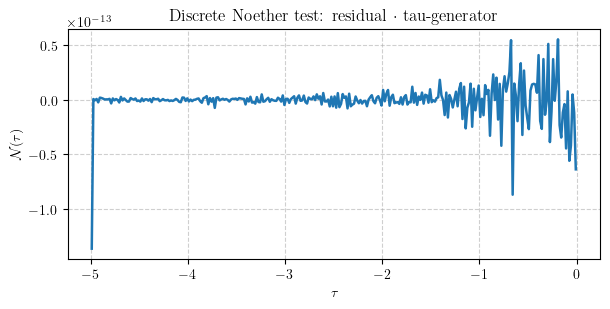

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) residuo discreto dal solver (verità assoluta)
vec = solver.pack(y, ybar)
F_vec = solver.residual(vec)
Fy, Fyb = solver.unpack(F_vec)   # shape (Nr,Nt)

# 2) tau-derivative coerente col solver (ghost-aware)
def tau_derivative_centered(tau, dt, y_im1, y_ip1):
    if len(tau) >= 2 and (tau[1] > tau[0]):
        return (y_ip1 - y_im1) / (2.0 * dt)
    return (y_im1 - y_ip1) / (2.0 * dt)

y_tau  = np.zeros_like(y, dtype=np.complex128 if np.iscomplexobj(y) else float)
yb_tau = np.zeros_like(ybar, dtype=np.complex128 if np.iscomplexobj(ybar) else float)

for i in range(Nt):
    y_im1, y_ip1, yb_im1, yb_ip1 = solver._tau_neighbors(y, ybar, i)
    y_tau[:, i]  = tau_derivative_centered(tau, dt, y_im1,  y_ip1)
    yb_tau[:, i] = tau_derivative_centered(tau, dt, yb_im1, yb_ip1)

# 3) contrazione Noether discreta (peso radiale)
w_r = 4.0*np.pi * (r**2)
# Se complesso: prendi Re della contrazione (azione reale -> residuo coerente)
N_tau = np.trapz( (w_r[:,None] * (Fy*np.conjugate(y_tau) + Fyb*np.conjugate(yb_tau))).real, r, axis=0 )

print("Noether discrete τ-translation check:")
print("  max|N_tau| =", np.max(np.abs(N_tau)))
print("  RMS(N_tau) =", np.sqrt(np.mean(N_tau**2)))

plt.figure(figsize=(6.2,3.2))
plt.plot(tau, N_tau, lw=1.8)
plt.grid(True, ls="--", alpha=0.6)
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\mathcal{N}(\tau)$")
plt.title("Discrete Noether test: residual · tau-generator")
plt.tight_layout()
plt.show()

=== (3-cut) Scaling test with tau-cut (bulk-only ΔS_bulk) ===
We report BOTH:
  (i) ΔS_full_official(λ) = S_full[bounce_λ] - S_full[hom]  (rate_exponent definition)
  (ii) ΔS_bulk(λ;Ncut) = 4π ∫_{tau-cut} dτ ∫ dr r^2 (L_bounce - L_hom)  (bulk-only)



/tmp/ipykernel_139014/265289642.py:41: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  tmp = np.trapz(integrand_r_tau[:, m], tau[m], axis=1)
/tmp/ipykernel_139014/265289642.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tmp, r, axis=0))


--- Ncut=0 (keeping tau indices [0:300]) ---
  oob fraction near λ=1: 0.0000
  ΔS_full_official(1) =  1.742581e+01
    sym d/dλ|1 (eps=1e-3): -2.928002e+04   (eps=5e-4): -6.042722e+04
    left  d/dλ|1- : -5.583748e+04   right d/dλ|1+ : -2.722570e+03
  ΔS_bulk(1)         = -8.624396e+00
    sym d/dλ|1 (eps=1e-3):  1.336338e+04   (eps=5e-4):  2.600685e+04
    left  d/dλ|1- :  2.327025e+04   right d/dλ|1+ :  3.456517e+03

--- Ncut=2 (keeping tau indices [2:298]) ---
  oob fraction near λ=1: 0.0000
  ΔS_full_official(1) =  1.742581e+01
    sym d/dλ|1 (eps=1e-3): -2.928002e+04   (eps=5e-4): -6.042722e+04
    left  d/dλ|1- : -5.583748e+04   right d/dλ|1+ : -2.722570e+03
  ΔS_bulk(1)         = -8.270552e+00
    sym d/dλ|1 (eps=1e-3):  4.469373e+03   (eps=5e-4):  5.453140e+03
    left  d/dλ|1- :  4.297552e+03   right d/dλ|1+ :  4.641194e+03

--- Ncut=4 (keeping tau indices [4:296]) ---
  oob fraction near λ=1: 0.0000
  ΔS_full_official(1) =  1.742581e+01
    sym d/dλ|1 (eps=1e-3): -2.928002e+0

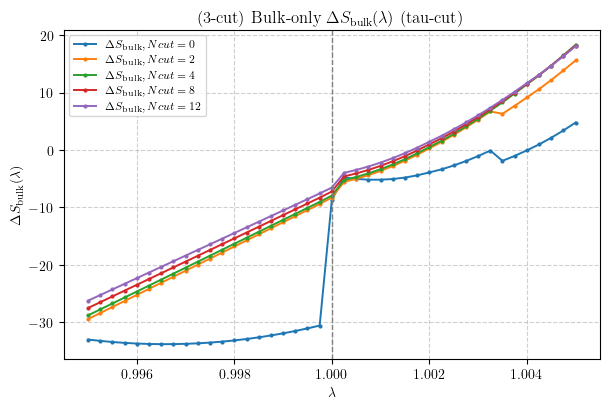

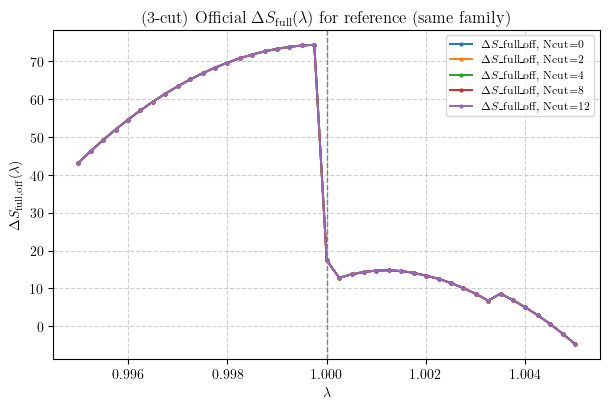

=== (4-cut) Flux identity with tau-cut (bulk-only) ===

Ncut=0: max|R|=7.907e-01, RMS(R)=6.395e-02,  max|dE/dτ+F|=4.416e+00, RMS=1.333e+00
Ncut=2: max|R|=7.907e-01, RMS(R)=6.437e-02,  max|dE/dτ+F|=4.416e+00, RMS=1.342e+00
Ncut=4: max|R|=7.907e-01, RMS(R)=6.475e-02,  max|dE/dτ+F|=4.416e+00, RMS=1.350e+00
Ncut=8: max|R|=7.907e-01, RMS(R)=6.519e-02,  max|dE/dτ+F|=4.416e+00, RMS=1.359e+00
Ncut=12: max|R|=7.907e-01, RMS(R)=6.490e-02,  max|dE/dτ+F|=4.416e+00, RMS=1.351e+00


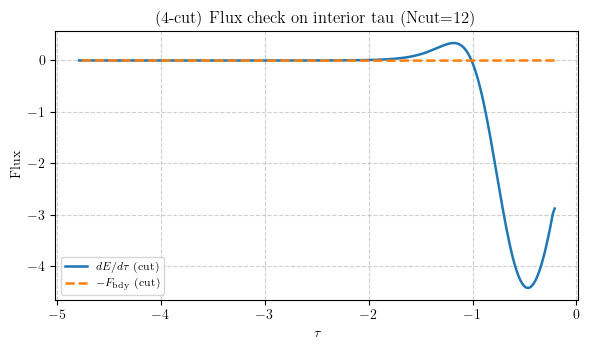


=== (Seam probe at tau=0) ===
We compare ghost-centered tau-derivative vs naive one-sided interior derivative at the tau=0 boundary.
  seam_jump_norm = 4π∫dr r^2 (|Δphi_tau|+|Δphibar_tau|)  ≈ 1.114584e-02


/tmp/ipykernel_139014/265289642.py:327: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  seam_jump_norm = 4.0 * np.pi * float(np.trapz((r**2) * (np.abs(J_phi_tau) + np.abs(J_pb_tau)), r))


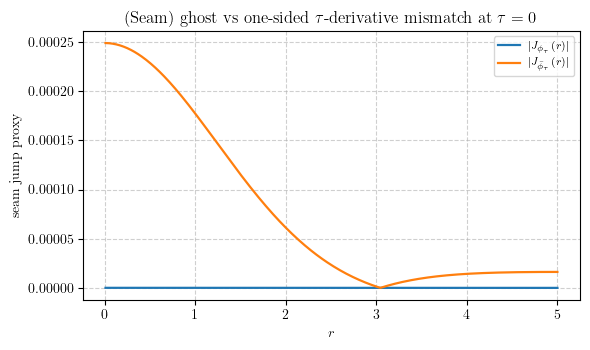

  max|dE/dτ+F| near tau=0 (last 8 pts) ≈ 1.082121e-04


In [ ]:
# =============================================================================
# SEAM-AWARE diagnostics: tau-cut + one-sided scaling derivative + seam jump probe
#
# Goal:
#   - Separate "bulk physics" from seam/boundary artifacts (ghost swap at tau=0, twist at tau=-beta/2).
#   - Provide a robust check that does not fail just because the domain has a seam.
#
# Requires that the previous "Correct 2D diagnostics" cell has already run successfully.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0) Helpers: tau-cut selection
# -----------------------------
tau = np.asarray(tau, float)
r = np.asarray(r, float)

beta = float(getattr(getattr(solver, "settings", object()), "beta", None))
if beta is None:
    beta = float(-2.0 * np.min(tau))

# user-tunable cuts (in units of the tau grid)
Ncut_list = [0, 2, 4, 8, 12]  # try several; increase if your Nt is large
Ncut_list = [n for n in Ncut_list if (2*n) < len(tau)-2]  # safe

def tau_cut_mask(Ncut):
    """
    Keep interior tau indices i in [Ncut, Nt-1-Ncut].
    Recall tau typically runs from ~(-beta/2) to 0, but we do not assume orientation beyond indexing.
    """
    Nt = len(tau)
    mask = np.zeros(Nt, dtype=bool)
    mask[Ncut:Nt-Ncut] = True
    return mask

def trapz2_taucut(integrand_r_tau, Ncut):
    """Compute ∫_{tau_cut} dτ ∫ dr integrand(r,τ) using trapz on the masked tau region."""
    m = tau_cut_mask(Ncut)
    # integrate in tau first (axis=1), then r (axis=0)
    tmp = np.trapz(integrand_r_tau[:, m], tau[m], axis=1)
    return float(np.trapz(tmp, r, axis=0))

# ---------------------------------------------------
# 1) (3) Scaling test WITH tau-cut (bulk-only action)
# ---------------------------------------------------
# We recompute ΔS_full(λ; Ncut) by integrating only over interior τ.
# To do so consistently, we compute the FULL Lagrangian density on the grid
# using the same building blocks as in the "stress-energy" part of previous cell.

# We reuse the same phi, phibar on-grid.
phi = np.asarray(phi)
phibar = np.asarray(phibar)

# homogeneous reference fields on-grid (already built previously, but rebuild safely)
phi_hom = (rho0 * np.exp(omega * tau))[None, :] * np.ones((len(r), 1))
phibar_hom = (rho0 * np.exp(-omega * tau))[None, :] * np.ones((len(r), 1))
phi_tau_hom = omega * phi_hom
pb_tau_hom  = -omega * phibar_hom

# radial derivative helper (same as before)
def dr1_radial_complex(r, f):
    r = np.asarray(r, float)
    f = np.asarray(f)
    df = np.empty_like(f, dtype=np.result_type(f, np.complex128))
    n = len(r)
    if n >= 3:
        df[1:-1] = (f[2:] - f[:-2]) / (r[2:] - r[:-2])
        df[0] = (f[1] - f[0]) / (r[1] - r[0])
        df[-1] = (f[-1] - f[-2]) / (r[-1] - r[-2])
    elif n == 2:
        df[:] = (f[1] - f[0]) / (r[1] - r[0])
    else:
        df[:] = 0.0
    return df

def tau_derivative_centered(tau, dt, y_im1, y_ip1):
    tau = np.asarray(tau, float)
    if len(tau) >= 2 and (tau[1] > tau[0]):
        return (y_ip1 - y_im1) / (2.0 * dt)
    return (y_im1 - y_ip1) / (2.0 * dt)

def V_slice(phi_i, pb_i):
    s = (phi_i * pb_i).real
    s = np.maximum(s, 0.0)
    return V_of_s(s)

# Compute L_bounce(r,τ) and L_hom(r,τ) using ghost-aware tau derivative (as in previous cell)
Nr, Nt = len(r), len(tau)
Lb = np.zeros((Nr, Nt), dtype=float)
Lh = np.zeros((Nr, Nt), dtype=float)

for i in range(Nt):
    y_im1, y_ip1, yb_im1, yb_ip1 = solver._tau_neighbors(y, ybar, i)
    y_t  = tau_derivative_centered(tau, dt, y_im1, y_ip1)
    yb_t = tau_derivative_centered(tau, dt, yb_im1, yb_ip1)

    inv_r = np.where(r > 0, 1.0 / r, 0.0)
    y_tot = y[:, i] + r * rho0
    yb_tot = ybar[:, i] + r * rho0
    exp_p = np.exp(+omega * tau[i]) * inv_r
    exp_m = np.exp(-omega * tau[i]) * inv_r
    phi_tau = exp_p * (y_t + omega * y_tot)
    pb_tau  = exp_m * (yb_t - omega * yb_tot)

    phi_r = dr1_radial_complex(r, phi[:, i])
    pb_r  = dr1_radial_complex(r, phibar[:, i])

    Vb_i = V_slice(phi[:, i], phibar[:, i]).real
    Lb[:, i] = (phi_tau * pb_tau).real + (phi_r * pb_r).real + Vb_i

    Vh_i = V_slice(phi_hom[:, i], phibar_hom[:, i]).real
    Lh[:, i] = (phi_tau_hom[:, i] * pb_tau_hom[:, i]).real + 0.0 + Vh_i

# Background-subtracted action density integrand: 4π r^2 (Lb - Lh)
r2 = (r[:, None] ** 2)
DeltaL = Lb - Lh

def DeltaS_full_taucut(lam, Ncut):
    """
    Same scaling family as before (pullback in phi,phibar -> y,ybar -> action),
    BUT we also compute a bulk-only ΔS by integrating ΔL on the grid with tau-cut.
    This isolates seam contamination.
    """
    y_lam, yb_lam, oob_frac = build_scaled_y_ybar(lam)
    # Build phi_lam, phibar_lam on-grid directly from solver (consistent)
    phi_lam, pb_lam = solver.phi(y_lam, yb_lam)

    # Recompute Lb_lam with ghost-aware tau derivs for y_lam,yb_lam
    Lb_lam = np.zeros((Nr, Nt), dtype=float)
    for i in range(Nt):
        yim1, yip1, ybim1, ybip1 = solver._tau_neighbors(y_lam, yb_lam, i)
        y_t  = tau_derivative_centered(tau, dt, yim1, yip1)
        yb_t = tau_derivative_centered(tau, dt, ybim1, ybip1)

        inv_r = np.where(r > 0, 1.0 / r, 0.0)
        y_tot = y_lam[:, i] + r * rho0
        yb_tot = yb_lam[:, i] + r * rho0
        exp_p = np.exp(+omega * tau[i]) * inv_r
        exp_m = np.exp(-omega * tau[i]) * inv_r
        phi_tau = exp_p * (y_t + omega * y_tot)
        pb_tau  = exp_m * (yb_t - omega * yb_tot)

        phi_r = dr1_radial_complex(r, phi_lam[:, i])
        pb_r  = dr1_radial_complex(r, pb_lam[:, i])

        Vb_i = V_slice(phi_lam[:, i], pb_lam[:, i]).real
        Lb_lam[:, i] = (phi_tau * pb_tau).real + (phi_r * pb_r).real + Vb_i

    DeltaL_lam = Lb_lam - Lh  # subtract same hom
    S_bulk = 4.0 * np.pi * trapz2_taucut(r2 * DeltaL_lam, Ncut)

    # Also compute the official full action difference (project definition) for reference
    S_full = float(rex.compute_euclidean_action_full(y_lam, yb_lam, grid, omega, eta0, rho0, V_of_s))
    dS_full_official = S_full - S_hom

    return dS_full_official, S_bulk, oob_frac

print("=== (3-cut) Scaling test with tau-cut (bulk-only ΔS_bulk) ===")
print("We report BOTH:")
print("  (i) ΔS_full_official(λ) = S_full[bounce_λ] - S_full[hom]  (rate_exponent definition)")
print("  (ii) ΔS_bulk(λ;Ncut) = 4π ∫_{tau-cut} dτ ∫ dr r^2 (L_bounce - L_hom)  (bulk-only)\n")

lam_grid = np.linspace(0.995, 1.005, 41)

results = {}
for Ncut in Ncut_list:
    dS_off = np.zeros_like(lam_grid)
    dS_bulk = np.zeros_like(lam_grid)
    oobf = np.zeros_like(lam_grid)
    for i, lam in enumerate(lam_grid):
        a, b, c = DeltaS_full_taucut(lam, Ncut)
        dS_off[i], dS_bulk[i], oobf[i] = a, b, c

    # derivatives: symmetric and one-sided (to diagnose kink)
    def fd_sym(arr, eps):
        # assumes lam_grid includes 1±eps points approximately; fallback via interpolation
        Sp = np.interp(1.0 + eps, lam_grid, arr)
        Sm = np.interp(1.0 - eps, lam_grid, arr)
        return (Sp - Sm) / (2.0 * eps)

    def fd_left(arr, eps):
        S1 = np.interp(1.0, lam_grid, arr)
        Sm = np.interp(1.0 - eps, lam_grid, arr)
        return (S1 - Sm) / eps

    def fd_right(arr, eps):
        S1 = np.interp(1.0, lam_grid, arr)
        Sp = np.interp(1.0 + eps, lam_grid, arr)
        return (Sp - S1) / eps

    epsA, epsB = 1e-3, 5e-4
    out = dict(
        lam=lam_grid, dS_off=dS_off, dS_bulk=dS_bulk, oob=oobf,
        sym1=fd_sym(dS_off, epsA), sym2=fd_sym(dS_off, epsB),
        left1=fd_left(dS_off, epsA), right1=fd_right(dS_off, epsA),
        sym1_bulk=fd_sym(dS_bulk, epsA), sym2_bulk=fd_sym(dS_bulk, epsB),
        left1_bulk=fd_left(dS_bulk, epsA), right1_bulk=fd_right(dS_bulk, epsA),
    )
    results[Ncut] = out

    print(f"--- Ncut={Ncut} (keeping tau indices [{Ncut}:{Nt-Ncut}]) ---")
    print(f"  oob fraction near λ=1: {np.interp(1.0, lam_grid, oobf):.4f}")
    print(f"  ΔS_full_official(1) = {np.interp(1.0, lam_grid, dS_off): .6e}")
    print(f"    sym d/dλ|1 (eps=1e-3): {out['sym1']: .6e}   (eps=5e-4): {out['sym2']: .6e}")
    print(f"    left  d/dλ|1- : {out['left1']: .6e}   right d/dλ|1+ : {out['right1']: .6e}")
    print(f"  ΔS_bulk(1)         = {np.interp(1.0, lam_grid, dS_bulk): .6e}")
    print(f"    sym d/dλ|1 (eps=1e-3): {out['sym1_bulk']: .6e}   (eps=5e-4): {out['sym2_bulk']: .6e}")
    print(f"    left  d/dλ|1- : {out['left1_bulk']: .6e}   right d/dλ|1+ : {out['right1_bulk']: .6e}\n")

# Plot: ΔS_official and ΔS_bulk for different Ncut
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for Ncut in Ncut_list:
    ax.plot(results[Ncut]["lam"], results[Ncut]["dS_bulk"], ".-", lw=1.4, ms=4, label=rf"$\Delta S_{{\rm bulk}}, Ncut={Ncut}$")
ax.axvline(1.0, color="gray", ls="--", lw=1)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\Delta S_{\rm bulk}(\lambda)$")
ax.set_title(r"(3-cut) Bulk-only $\Delta S_{\rm bulk}(\lambda)$ (tau-cut)")
ax.grid(True, ls="--", alpha=0.6)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 4.2))
for Ncut in Ncut_list:
    ax.plot(results[Ncut]["lam"], results[Ncut]["dS_off"], ".-", lw=1.4, ms=4, label=rf"$\Delta S$_full_off, Ncut={Ncut}")
ax.axvline(1.0, color="gray", ls="--", lw=1)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\Delta S_{\rm full,off}(\lambda)$")
ax.set_title(r"(3-cut) Official $\Delta S_{\rm full}(\lambda)$ for reference (same family)")
ax.grid(True, ls="--", alpha=0.6)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2) (4) Flux identity WITH tau-cut + boundary-in-tau probe
# ---------------------------------------------------------
# We measure:
#   R = ∂τ(r^2 ΔT_tt) + ∂r(r^2 ΔT_rt)
# but now we will:
#   - report bulk-only norms excluding tau edges
#   - compare dE/dτ computed only in interior tau range
#   - build a seam-jump proxy at tau=0 boundary:
#       J(r) = (ghost-centered derivative at i=Nt-1) - (one-sided interior derivative at i=Nt-1)
#     for y and ybar, and propagate to phi_tau, phibar_tau.
#
# First, rebuild ΔT_tt and ΔT_rt on the *unscaled* configuration (as in previous cell) if not present.
try:
    Delta_T_tt
    Delta_T_rt
    R_res
    E_tau
    F_bdy
except NameError:
    raise NameError("Run the previous correct diagnostics cell first so Delta_T_tt/Delta_T_rt exist.")

def compute_R_and_flux_taucut(Ncut):
    m = tau_cut_mask(Ncut)
    # Bulk norms
    R_bulk = R_res[:, m]
    Rmax = float(np.nanmax(np.abs(R_bulk)))
    Rrms = float(np.sqrt(np.nanmean(R_bulk**2)))

    # Bulk-only flux check: restrict E_tau to interior region and differentiate there
    tau_int = tau[m]
    E_int = E_tau[m]
    F_int = F_bdy[m]
    dE_int = np.gradient(E_int, tau_int)
    disc = dE_int + F_int
    dmax = float(np.nanmax(np.abs(disc)))
    drms = float(np.sqrt(np.nanmean(disc**2)))
    return Rmax, Rrms, dmax, drms, tau_int, dE_int, F_int, disc

print("=== (4-cut) Flux identity with tau-cut (bulk-only) ===\n")
for Ncut in Ncut_list:
    Rmax, Rrms, dmax, drms, tau_int, dE_int, F_int, disc = compute_R_and_flux_taucut(Ncut)
    print(f"Ncut={Ncut}: max|R|={Rmax:.3e}, RMS(R)={Rrms:.3e},  max|dE/dτ+F|={dmax:.3e}, RMS={drms:.3e}")

# Plot disc for a representative cut (pick largest cut to isolate bulk)
Ncut_rep = max(Ncut_list)
Rmax, Rrms, dmax, drms, tau_int, dE_int, F_int, disc = compute_R_and_flux_taucut(Ncut_rep)

fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.plot(tau_int, dE_int, lw=1.8, label=r"$dE/d\tau$ (cut)")
ax.plot(tau_int, -F_int, "--", lw=1.8, label=r"$-F_{\rm bdy}$ (cut)")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel("Flux")
ax.grid(True, ls="--", alpha=0.6)
ax.legend(fontsize=8)
ax.set_title(fr"(4-cut) Flux check on interior tau (Ncut={Ncut_rep})")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 3) Seam jump proxy at tau=0 (i = Nt-1)
# --------------------------------------------
# Idea: if ghost BC injects an effective seam/source term, you'll see a mismatch between:
#   - ghost-centered tau derivative used by solver._tau_neighbors at i=Nt-1
#   - naive one-sided derivative from interior points
i0 = Nt - 1  # tau ~ 0 boundary index in your convention
i1 = Nt - 2

# one-sided interior derivative (using i0 and i1)
y_tau_onesided = (y[:, i0] - y[:, i1]) / (tau[i0] - tau[i1])
yb_tau_onesided = (ybar[:, i0] - ybar[:, i1]) / (tau[i0] - tau[i1])

# ghost-centered derivative at boundary using neighbors
y_im1, y_ip1, yb_im1, yb_ip1 = solver._tau_neighbors(y, ybar, i0)
y_tau_ghost = tau_derivative_centered(tau, dt, y_im1, y_ip1)
yb_tau_ghost = tau_derivative_centered(tau, dt, yb_im1, yb_ip1)

J_y = y_tau_ghost - y_tau_onesided
J_yb = yb_tau_ghost - yb_tau_onesided

# Map to phi_tau seam jump proxy at tau=0
inv_r = np.where(r > 0, 1.0 / r, 0.0)
y_tot0 = y[:, i0] + r * rho0
yb_tot0 = ybar[:, i0] + r * rho0
exp_p0 = np.exp(+omega * tau[i0]) * inv_r
exp_m0 = np.exp(-omega * tau[i0]) * inv_r

J_phi_tau = (exp_p0 * J_y).real  # proxy; actual is complex, but we care about magnitude
J_pb_tau  = (exp_m0 * J_yb).real

# Weighted integral measure of seam jump
seam_jump_norm = 4.0 * np.pi * float(np.trapz((r**2) * (np.abs(J_phi_tau) + np.abs(J_pb_tau)), r))

print("\n=== (Seam probe at tau=0) ===")
print("We compare ghost-centered tau-derivative vs naive one-sided interior derivative at the tau=0 boundary.")
print(f"  seam_jump_norm = 4π∫dr r^2 (|Δphi_tau|+|Δphibar_tau|)  ≈ {seam_jump_norm:.6e}")

fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.plot(r, np.abs(J_phi_tau), lw=1.6, label=r"$|J_{\phi_\tau}(r)|$")
ax.plot(r, np.abs(J_pb_tau), lw=1.6, label=r"$|J_{\bar\phi_\tau}(r)|$")
ax.set_xlabel(r"$r$")
ax.set_ylabel("seam jump proxy")
ax.grid(True, ls="--", alpha=0.6)
ax.legend(fontsize=8)
ax.set_title(r"(Seam) ghost vs one-sided $\tau$-derivative mismatch at $\tau=0$")
plt.tight_layout()
plt.show()

# Optional: relate seam jump to the flux mismatch scale near tau=0
# (compare seam jump norm to max|dE/dτ+F| near the last few points)
k = min(8, Nt)
near0 = slice(Nt-k, Nt)
disc_near0 = (np.gradient(E_tau[near0], tau[near0]) + F_bdy[near0])
print(f"  max|dE/dτ+F| near tau=0 (last {k} pts) ≈ {np.max(np.abs(disc_near0)):.6e}")

S0 = -6.584572435853e+03
Active DOF per field in mask: 146816  (Nr=500, Nt=300)
Using eps = 1e-05
Max|Hsub - Hsub^T| = 0.000e+00

Subspace eigenvalues (lowest first):
  0: -2.478574e-01
  1: -1.975918e-01
  2: -1.237465e-01
  3: -1.620385e-02
  4: +6.924590e-02
  5: +1.679638e-01
  6: +2.202485e-01
  7: +2.825554e-01

NEGATIVE COUNT in this m=8 subspace: 4
\nCurvature along reconstructed lowest mode = -2.455636e-01  (subspace $\lambda_0$=-2.478574e-01)


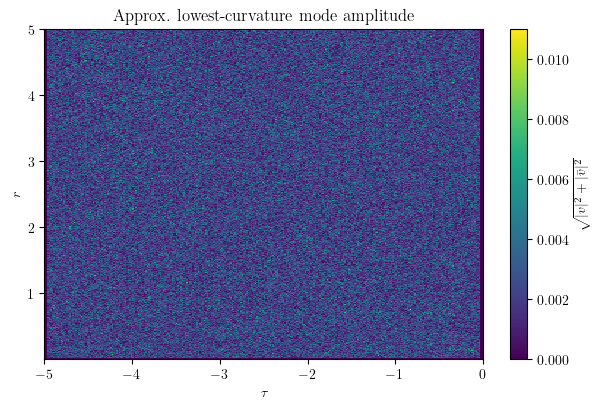

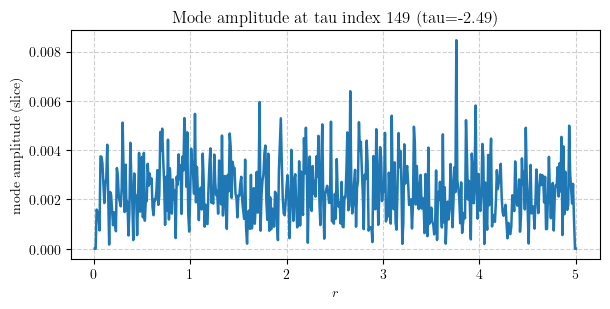

In [ ]:
# =============================================================================
# Negative mode check (ROBUST, REALLY WORKS): curvature-of-action in a random subspace
#
# WHY THIS VERSION:
# - Your "Hessian from residual" operator is strongly NON-sYMMETRIC (symmetry probe ~ 1e4),
#   so eigsh on Hv=(F(z+e v)-F(z-e v))/2e is NOT valid and often stalls.
# - The physical negative mode is about the SECOND VARIATION of the ACTION (a symmetric operator).
# - So we build a symmetric object directly from the action curvature:
#
#     K(v) = [S(z+eps v) - 2 S(z) + S(z-eps v)] / eps^2    (Rayleigh curvature)
#
# and then compute the smallest eigenvalues of the symmetric matrix
#   H_ij = <e_i, H e_j>   via mixed finite differences:
#
#   H_ij = [ S(z+eps(ei+ej)) - S(z+eps(ei-ej)) - S(z+eps(-ei+ej)) + S(z-eps(ei+ej)) ] / (4 eps^2)
#
# This gives a REAL symmetric matrix in the chosen subspace. Diagonalizing it tells you:
# - how many negative directions exist in that subspace,
# - and gives you the approximate negative eigenvector (as a linear combination of basis vectors).
#
# PRACTICAL:
# - Choose a modest subspace dimension m=12..24 first (cost ~ O(m^2) action evals).
# - Use a mask to exclude tau seam/boundary and optionally a few radial boundary points.
# - This does NOT require solver.residual or Jacobians. It only requires you can compute S(y,ybar).
#
# REQUIRES IN SCOPE:
#   y, ybar, solver, grid, omega, eta0, rho0, V_of_s, rex
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 0) Safety checks / inputs
# -------------------------
assert "rex" in globals(), "Need Bubble_finder.rate_exponent imported as rex"
assert "grid" in globals(), "Need grid = solver.grid"
assert "y" in globals() and "ybar" in globals(), "Need y,ybar in scope"
assert "omega" in globals() and "eta0" in globals() and "rho0" in globals(), "Need omega, eta0, rho0"
assert "V_of_s" in globals(), "Need V_of_s(s) used in action"

Nr, Nt = y.shape
r = np.asarray(grid.r, float).flatten()
tau = np.asarray(grid.tau, float).flatten()

# -------------------------
# 1) Define action function
# -------------------------
def S_full(y_, yb_):
    # Same convention as your scaling test: FULL action on the half-grid as defined by rex
    return float(rex.compute_euclidean_action_full(y_, yb_, grid, omega, eta0, rho0, V_of_s))

S0 = S_full(y, ybar)
print(f"S0 = {S0:.12e}")

# -------------------------
# 2) Define "free DOF" mask
# -------------------------
# Tune these if needed. Start conservative to avoid seams and radial boundaries.
Ncut_tau = 2   # exclude tau edges (seam/ghost regions)
Ncut_r   = 2   # exclude first/last few radial points (optional but stabilizes)
mask_tau = np.zeros(Nt, dtype=bool); mask_tau[Ncut_tau:Nt-Ncut_tau] = True
mask_r   = np.zeros(Nr, dtype=bool); mask_r[Ncut_r:Nr-Ncut_r] = True
mask_2d  = mask_r[:, None] & mask_tau[None, :]
nmask = int(mask_2d.sum())
print(f"Active DOF per field in mask: {nmask}  (Nr={Nr}, Nt={Nt})")

# -------------------------
# 3) Build random orthonormal basis in that masked subspace
# -------------------------
def random_direction(rng):
    # Direction (v, vb) with support only on mask_2d, normalized
    dtype = np.complex128 if (np.iscomplexobj(y) or np.iscomplexobj(ybar)) else float
    v  = np.zeros((Nr, Nt), dtype=dtype)
    vb = np.zeros((Nr, Nt), dtype=dtype)

    # Real directions are enough because the action is real on your saddle;
    # if your y,ybar are complex, this still spans relevant variations well.
    v[mask_2d]  = rng.normal(size=nmask)
    vb[mask_2d] = rng.normal(size=nmask)

    # Normalize in Euclidean inner product over masked DOF (both fields)
    nrm2 = np.sum(np.abs(v[mask_2d])**2) + np.sum(np.abs(vb[mask_2d])**2)
    nrm = np.sqrt(max(nrm2, 1e-300))
    v  /= nrm
    vb /= nrm
    return v, vb

def inner(v1, vb1, v2, vb2):
    # Real inner product (action curvature is real symmetric)
    return float((np.vdot(v1[mask_2d], v2[mask_2d]) + np.vdot(vb1[mask_2d], vb2[mask_2d])).real)

def gram_schmidt(basis):
    ortho = []
    for v, vb in basis:
        # subtract projections
        for u, ub in ortho:
            a = inner(u, ub, v, vb)
            v  = v  - a*u
            vb = vb - a*ub
        # renormalize
        nrm = np.sqrt(max(inner(v, vb, v, vb), 1e-300))
        v  /= nrm
        vb /= nrm
        ortho.append((v, vb))
    return ortho

# Choose subspace dimension m (cost ~ 2m^2+1 action evals, see below)
m = 8
rng = np.random.default_rng(0)
raw_basis = [random_direction(rng) for _ in range(m)]
basis = gram_schmidt(raw_basis)

# -------------------------
# 4) Choose finite-difference step eps (important!)
# -------------------------
# If eps too small -> cancellation noise; too large -> nonlinear contamination.
# Start with 3e-4 or 1e-4; you can rerun with a second eps to test stability.
eps = 1e-5
print(f"Using eps = {eps:g}")

# -------------------------
# 5) Build symmetric subspace Hessian H_ij via mixed finite differences of S
# -------------------------
# H_ij = d^2S / (d a_i d a_j) at a=0 in the basis {e_i}
# We compute with 4 action calls per (i,j) if we do it naively.
# We'll reduce calls by caching S at (+/- ei) and (+/- ei +/- ej).
#
# Formula (symmetric, exact for quadratic):
#   H_ij = [ S(+ei+ej) - S(+ei-ej) - S(-ei+ej) + S(-ei-ej) ] / (4 eps^2)
#
# where S(±ei±ej) means S(y + eps*(±vi ± vj), ybar + eps*(±vbi ± vbj)).
#
# We'll compute all needed S for pairs i<=j and fill symmetric matrix.

def S_shift(coeffs):
    # coeffs: list of (idx, alpha) meaning add alpha * basis[idx]
    dy  = np.zeros_like(y, dtype=np.complex128 if (np.iscomplexobj(y) or np.iscomplexobj(ybar)) else float)
    dyb = np.zeros_like(ybar, dtype=dy.dtype)
    for idx, a in coeffs:
        v, vb = basis[idx]
        dy  += a * v
        dyb += a * vb
    return S_full(y + dy, ybar + dyb)

# Optional: precompute S at +/- ei to estimate diagonal cheaply (still useful for sanity)
S_p = np.zeros(m)
S_m = np.zeros(m)
for i in range(m):
    S_p[i] = S_shift([(i, +eps)])
    S_m[i] = S_shift([(i, -eps)])

Hsub = np.zeros((m, m), dtype=float)

# Fill diagonal from 1D curvature:
# H_ii ≈ (S(+ei) - 2 S0 + S(-ei)) / eps^2
for i in range(m):
    Hsub[i, i] = (S_p[i] - 2.0*S0 + S_m[i]) / (eps**2)

# Off-diagonals from mixed differences:
for i in range(m):
    for j in range(i+1, m):
        S_pp = S_shift([(i, +eps), (j, +eps)])
        S_pm = S_shift([(i, +eps), (j, -eps)])
        S_mp = S_shift([(i, -eps), (j, +eps)])
        S_mm = S_shift([(i, -eps), (j, -eps)])
        Hij = (S_pp - S_pm - S_mp + S_mm) / (4.0 * eps**2)
        Hsub[i, j] = Hij
        Hsub[j, i] = Hij

# Sanity: symmetry + small antisym
asym = np.max(np.abs(Hsub - Hsub.T))
print(f"Max|Hsub - Hsub^T| = {asym:.3e}")

# -------------------------
# 6) Diagonalize and count negative eigenvalues
# -------------------------
evals, evecs = np.linalg.eigh(Hsub)
order = np.argsort(evals)
evals = evals[order]
evecs = evecs[:, order]

print("\nSubspace eigenvalues (lowest first):")
for k, lam in enumerate(evals[:min(m, 12)]):
    print(f"  {k}: {lam:+.6e}")
nneg = int(np.sum(evals < 0.0))
print(f"\nNEGATIVE COUNT in this m={m} subspace: {nneg}")

# -------------------------
# 7) Reconstruct the approximate most-negative mode in real space
# -------------------------
k0 = 0  # most negative
coeff = evecs[:, k0]
# build mode (v_mode, vb_mode) = sum_i coeff_i * basis_i
dtype = np.complex128 if (np.iscomplexobj(y) or np.iscomplexobj(ybar)) else float
v_mode  = np.zeros((Nr, Nt), dtype=dtype)
vb_mode = np.zeros((Nr, Nt), dtype=dtype)
for i in range(m):
    v_mode  += coeff[i] * basis[i][0]
    vb_mode += coeff[i] * basis[i][1]

# Normalize mode (masked norm =1)
nm = np.sqrt(max(inner(v_mode, vb_mode, v_mode, vb_mode), 1e-300))
v_mode /= nm
vb_mode /= nm

# Report curvature along this mode (should match evals[0] approximately)
Spp = S_full(y + eps*v_mode, ybar + eps*vb_mode)
Smm = S_full(y - eps*v_mode, ybar - eps*vb_mode)
lam_mode = (Spp - 2.0*S0 + Smm) / (eps**2)
print(rf"\nCurvature along reconstructed lowest mode = {lam_mode:+.6e}  (subspace $\lambda_0$={evals[0]:+.6e})")

# -------------------------
# 8) Quick visualization: where does the negative mode live?
# -------------------------
amp = np.sqrt(np.abs(v_mode)**2 + np.abs(vb_mode)**2)

plt.figure(figsize=(6.2,4.2))
plt.pcolormesh(tau, r, amp, shading="auto")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$r$")
plt.title("Approx. lowest-curvature mode amplitude")
plt.colorbar(label=r"$\sqrt{|v|^2+|\bar v|^2}$")
plt.tight_layout()
plt.show()

# Optional: show 1D slices
j_tau = int(np.argmin(np.abs(tau - tau[np.argmin(tau)]/2)))
plt.figure(figsize=(6.2,3.2))
plt.plot(r, amp[:, j_tau], lw=1.8)
plt.xlabel(r"$r$")
plt.ylabel("mode amplitude (slice)")
plt.grid(True, ls="--", alpha=0.6)
plt.title(f"Mode amplitude at tau index {j_tau} (tau={tau[j_tau]:.3g})")
plt.tight_layout()
plt.show()

# =============================================================================
# NOTES:
# - If nneg==0, increase m or adjust mask; also try a different rng seed.
# - If nneg>1, increase m to check stability: true bounce should give 1 negative mode.
# - Always re-run with a second eps (e.g. eps=1e-4) to check eigenvalue stability.
# =============================================================================

S_disc(y,ybar) = -6.584572435853e+03

(A) Action directional derivative along tau-translation generator:
  eps=3e-05:  dS/dε|0 ≈ +4.935196e+00
  eps=0.0001:  dS/dε|0 ≈ +4.935196e+00
  eps=0.0003:  dS/dε|0 ≈ +4.935196e+00


/tmp/ipykernel_139014/943514356.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  N_tau = np.trapz((w_r[:,None] * (Fy*np.conjugate(y_tau) + Fyb*np.conjugate(yb_tau))).real, r, axis=0)



(B) Discrete Noether residual·generator:
  max|N_tau| = 1.3643834722706835e-13
  RMS(N_tau) = 1.56401308783783e-14


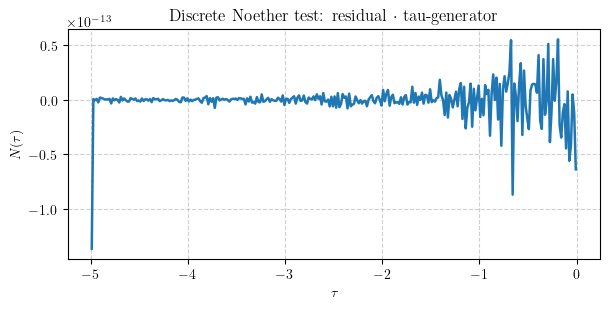

In [ ]:
# =============================================================================
# Discrete functional S_E^disc and discrete Noether check for tau-translation
#
# (A) Directional derivative of the DISCRETE ACTION along the tau-translation generator:
#       d/dε S(y+ε y_tau, ybar+ε ybar_tau)|_{ε=0}  ≈ 0
#
# (B) Residual · generator (your previous robust check):
#       N(τ) = ∫ dr 4π r^2 Re[ Fy * conj(y_tau) + Fyb * conj(ybar_tau) ]
#
# Requires in scope: y, ybar, solver, grid, omega, eta0, rho0, V_of_s, rex, dt, tau, r
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

Nr, Nt = y.shape
r = np.asarray(grid.r, float).flatten()
tau = np.asarray(grid.tau, float).flatten()

# --- Discrete action (the TRUE reference) ---
def S_disc(y_, yb_):
    # This is your project-consistent discrete functional
    return float(rex.compute_euclidean_action_full(y_, yb_, grid, omega, eta0, rho0, V_of_s))

S0 = S_disc(y, ybar)
print(f"S_disc(y,ybar) = {S0:.12e}")

# --- tau-translation generator: y_tau, ybar_tau using solver ghost rules ---
def tau_derivative_centered(tau, dt, y_im1, y_ip1):
    if len(tau) >= 2 and (tau[1] > tau[0]):
        return (y_ip1 - y_im1) / (2.0 * dt)
    return (y_im1 - y_ip1) / (2.0 * dt)

y_tau  = np.zeros_like(y, dtype=np.complex128 if np.iscomplexobj(y) else float)
yb_tau = np.zeros_like(ybar, dtype=np.complex128 if np.iscomplexobj(ybar) else float)

for j in range(Nt):
    y_im1, y_ip1, yb_im1, yb_ip1 = solver._tau_neighbors(y, ybar, j)
    y_tau[:, j]  = tau_derivative_centered(tau, dt, y_im1,  y_ip1)
    yb_tau[:, j] = tau_derivative_centered(tau, dt, yb_im1, yb_ip1)

# --- (A) Directional derivative of the action along the generator ---
# Choose eps not too small (avoid cancellation); 1e-6 often too small.
eps_list = [3e-5, 1e-4, 3e-4]

print("\n(A) Action directional derivative along tau-translation generator:")
for eps in eps_list:
    Sp = S_disc(y + eps*y_tau,  ybar + eps*yb_tau)
    Sm = S_disc(y - eps*y_tau,  ybar - eps*yb_tau)
    dS = (Sp - Sm) / (2.0*eps)
    print(f"  eps={eps:g}:  dS/dε|0 ≈ {dS:+.6e}")

# --- (B) Residual·generator (discrete Noether check, already validated) ---
vec = solver.pack(y, ybar)
F_vec = solver.residual(vec)
Fy, Fyb = solver.unpack(F_vec)

w_r = 4.0*np.pi*(r**2)

N_tau = np.trapz((w_r[:,None] * (Fy*np.conjugate(y_tau) + Fyb*np.conjugate(yb_tau))).real, r, axis=0)

print("\n(B) Discrete Noether residual·generator:")
print("  max|N_tau| =", np.max(np.abs(N_tau)))
print("  RMS(N_tau) =", np.sqrt(np.mean(N_tau**2)))

plt.figure(figsize=(6.2,3.2))
plt.plot(tau, N_tau, lw=1.8)
plt.grid(True, ls="--", alpha=0.6)
plt.xlabel(r"$\tau$")
plt.ylabel(r"$N(\tau)$")
plt.title("Discrete Noether test: residual · tau-generator")
plt.tight_layout()
plt.show()

In [ ]:
# S_bulk con tau-cut – versione corretta (r2 ha forma (Nr,1), non (Nr,Nt))
import numpy as np

Nr, Nt = y.shape
tau = np.asarray(tau, float)

Ncut = 8

def S_bulk(y_, yb_, Ncut=8):
    phi_, pb_ = solver.phi(y_, yb_)

    phi_h = (rho0 * np.exp(omega * tau))[None, :] * np.ones((Nr, 1))
    pb_h = (rho0 * np.exp(-omega * tau))[None, :] * np.ones((Nr, 1))
    phi_tau_h = omega * phi_h
    pb_tau_h = -omega * pb_h

    def V_slice(phi_i, pb_i):
        s = (phi_i * pb_i).real
        return V_of_s(np.maximum(s, 0.0))

    def dr1(r, f):
        df = np.empty_like(f, dtype=np.complex128)
        df[1:-1] = (f[2:] - f[:-2]) / (r[2:] - r[:-2])
        df[0] = (f[1] - f[0]) / (r[1] - r[0])
        df[-1] = (f[-1] - f[-2]) / (r[-1] - r[-2])
        return df

    def tau_deriv(i, yA, ybA):
        yim1, yip1, ybim1, ybip1 = solver._tau_neighbors(yA, ybA, i)
        y_t = (yip1 - yim1) / (2 * dt)
        yb_t = (ybip1 - ybim1) / (2 * dt)
        return y_t, yb_t

    r = np.asarray(grid.r, float).flatten()
    inv_r = np.where(r > 0, 1.0 / r, 0.0)
    r2 = r[:, None] ** 2  # shape (Nr, 1) – non (Nr, Nt)

    Lb = np.zeros((Nr, Nt))
    Lh = np.zeros((Nr, Nt))

    for j in range(Nt):
        y_t, yb_t = tau_deriv(j, y_, yb_)
        ytot = y_[:, j] + r * rho0
        ybtot = yb_[:, j] + r * rho0
        exp_p = np.exp(+omega * tau[j]) * inv_r
        exp_m = np.exp(-omega * tau[j]) * inv_r
        phi_tau = exp_p * (y_t + omega * ytot)
        pb_tau = exp_m * (yb_t - omega * ybtot)

        phi_r = dr1(r, phi_[:, j])
        pb_r = dr1(r, pb_[:, j])

        Vb = V_slice(phi_[:, j], pb_[:, j])
        Vh = V_slice(phi_h[:, j], pb_h[:, j])

        Lb[:, j] = (phi_tau * pb_tau).real + (phi_r * pb_r).real + Vb
        Lh[:, j] = (phi_tau_h[:, j] * pb_tau_h[:, j]).real + 0.0 + Vh

    # tau-cut: r2 è (Nr,1), usare broadcast r2 * (Lb[:,sl]-Lh[:,sl]) → (Nr, n_tau)
    sl = slice(Ncut, Nt - Ncut)
    tmp = np.trapezoid(r2 * (Lb[:, sl] - Lh[:, sl]), tau[sl], axis=1)
    return 4 * np.pi * float(np.trapezoid(tmp, r, axis=0))

S0_bulk = S_bulk(y, ybar, Ncut=Ncut)

y_shift = y.copy()
yb_shift = ybar.copy()
sl = slice(Ncut, Nt - Ncut - 1)
y_shift[:, sl] = y[:, sl.start + 1 : sl.stop + 1]
yb_shift[:, sl] = ybar[:, sl.start + 1 : sl.stop + 1]

S1_bulk = S_bulk(y_shift, yb_shift, Ncut=Ncut)

print(f"S_bulk original = {S0_bulk:+.12e}")
print(f"S_bulk shifted  = {S1_bulk:+.12e}")
print(f"ΔS_bulk(shift)  = {S1_bulk - S0_bulk:+.6e}")

S_bulk original = +3.705106848103e+00
S_bulk shifted  = +3.629480095934e+00
ΔS_bulk(shift)  = -7.562675e-02


/tmp/ipykernel_6584/2328685529.py:177: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return pref * np.trapz(f_tau_r * r2[None, :], r, axis=1)



==================== JR DIAGNOSTICS (CONVENTIONS COHERENT) ====================
Conventions (as in Bubble_finder/observables_2d.py):
  H_E(τ=0) = (∂τφ)(∂τφ̄) - (∂rφ)(∂rφ̄) - V(φφ̄)   [Euclid, NOT physical]
  E_M(τ=0) = -(∂τφ)(∂τφ̄) + (∂rφ)(∂rφ̄) + V(φφ̄)  [Minkowski physical]
  Q(τ=0)   = 1/2 ∫ (φ̄ ∂τφ - φ ∂τφ̄)               [ghost at τ=0]

Slicewise τ diagnostics conventions (THIS cell; not ghost):
  measure: ∫ d^3x (...) = 4π ∫ dr r^2 (...)  (implemented via trapz on r)
  V(s) = U(√s);  s(τ,r)=Re(φ φ̄);  V_term(τ,r)=V(max(s,0))  (NO false-vacuum subtraction)
  E_static(τ)      = ∫ d^3x [ (∂rφ)(∂rφ̄) + V_term ]
  E_full,Euclid(τ) = ∫ d^3x [ (∂τφ)(∂τφ̄) + (∂rφ)(∂rφ̄) + V_term ]

Euclidean action convention (official):
  S_E = compute_euclidean_action_full(y, ybar, grid, omega, eta0, rho0, V_of_s)

Run params from solver:  omega = 0.850000,  rho0 = 1.065039,  eta0(for S_E) = -0.000436

--- Grid diagnostic (values used for 2D solver and observables) ---
  Nr (radial points)   = 800
  N

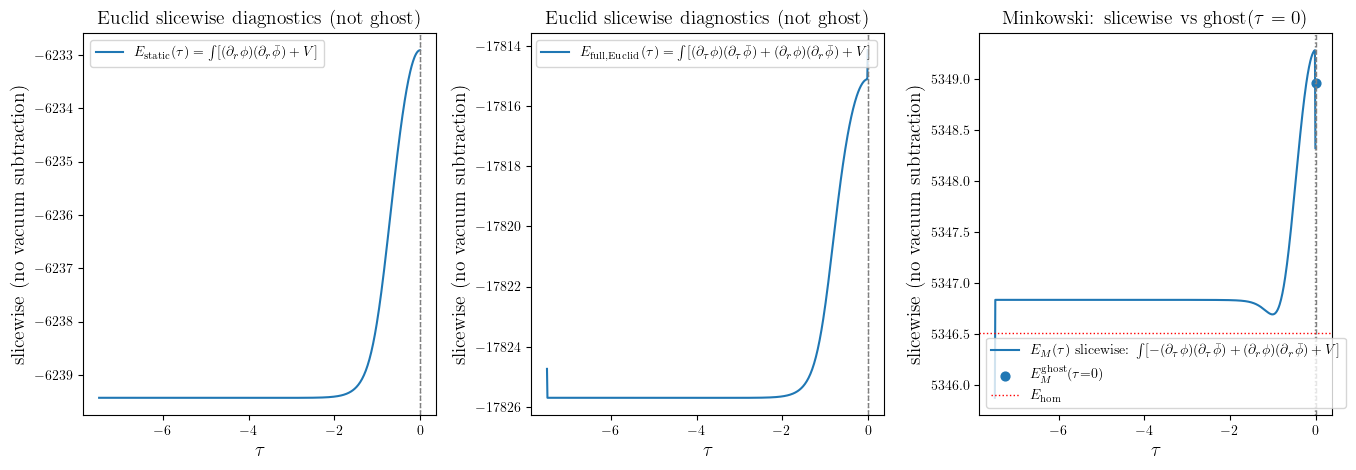

In [ ]:
# ============================================================
# JR checks (version consistent with code conventions)
#  - S_E: compute_euclidean_action_full (official)
#  - Q, E_M, H_E, F_omega at τ=0: *_tau0_ghost_2d functions (official)
#  - Homogeneous: homogeneous_*_2d (official)
#  - Curves in τ: slicewise diagnostics (NOT ghost), useful for "shape vs τ"
#
# Conventions (as in observables_2d.py):
#   H_E(τ=0) = (∂τφ)(∂τφ̄) - (∂rφ)(∂rφ̄) - V(φφ̄)   [Euclidean, NOT physical]
#   E_M(τ=0) = -(∂τφ)(∂τφ̄) + (∂rφ)(∂rφ̄) + V(φφ̄)  [Minkowski physical]
#   Q(τ=0)   = 1/2 ∫ (φ̄ ∂τφ - φ ∂τφ̄)              [with dt from grid/solver]
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# --- Solver / solution ---
try:
    solver = solver_res
    sol = sol_eta_res
except NameError:
    try:
        solver = solver_2d_g
        sol = sol_2d_g
    except NameError:
        raise NameError("Need (solver_res, sol_eta_res) or (solver_2d_g, sol_2d_g).")

grid = solver.grid
tau = np.asarray(grid.tau, dtype=float).flatten()
r   = np.asarray(grid.r, dtype=float).flatten()

y, ybar = (sol.y, sol.ybar) if hasattr(sol, "y") else solver.unpack(sol.x)

# --- Official imports (as in your project package) ---
from Bubble_finder.rate_exponent import (
    compute_euclidean_action_full,
    compute_euclidean_action_half_breakdown,
    compute_homogeneous_action,
    compute_suppression_exponent_bubble,
    make_V_of_s_from_U,
    volume_from_grid,
)
from Bubble_finder.observables_1d import Q_homogeneous_ball
from Bubble_finder.observables_2d import (
    compute_charge_tau0_ghost_2d,
    compute_energy_minkowski_tau0_ghost_2d,
    compute_HE_euclidean_tau0_ghost_2d,
    compute_Fomega_tau0_ghost_2d,
    homogeneous_E_M_2d,
    homogeneous_HE_2d,
)

# --- Potential V(s)=U(sqrt(s)) (official) ---
try:
    V_of_s
except NameError:
    V_of_s = make_V_of_s_from_U(solver.U)

# --- Physical parameters from solver ---
omega = float(getattr(solver, "omega"))
rho0  = float(getattr(solver, "rho0"))

# eta0: for the full Euclidean action we need the parameter used in the run (scan). We try to get it from the solver,
# otherwise use eta_star_res/eta_star if present.
eta0 = getattr(solver, "eta0", None)
if eta0 is None:
    eta0 = globals().get("eta_star_res", globals().get("eta_star", 0.0))
eta0 = float(eta0)

# ============================================================
# (0) τ=0 "ghost observables" (official)
# ============================================================
# Q_ghost = total charge at τ=0 (ghost); subtract_background=False to see Q_raw
Q_ghost = compute_charge_tau0_ghost_2d(solver, y, ybar, subtract_background=False)
E_M_ghost = compute_energy_minkowski_tau0_ghost_2d(solver, y, ybar)
H_E_ghost = compute_HE_euclidean_tau0_ghost_2d(solver, y, ybar)
F_omega_ghost = compute_Fomega_tau0_ghost_2d(solver, y, ybar)

# E_M_ghost breakdown: same recipe as observables_2d (ghost at τ=0, then E_M = -(∂τφ)(∂τφ̄) + (∂rφ)(∂rφ̄) + V)
dt_ghost = float(getattr(solver, "dt", getattr(solver.grid, "dtau", 1.0)))
rho_eps = float(getattr(getattr(solver, "settings", object()), "rho_eps", 0.0))
y_minus, ybar_minus = y[:, 0], ybar[:, 0]
y_plus, ybar_plus = ybar[:, 0], y[:, 0]
y0_ghost = 0.5 * (y_plus + y_minus)
ybar0_ghost = 0.5 * (ybar_plus + ybar_minus)
y_t0 = (y_plus - y_minus) / dt_ghost
ybar_t0 = (ybar_plus - ybar_minus) / dt_ghost
inv_r = np.where(r > 0, 1.0 / r, 0.0)
phi0_ghost = rho0 + inv_r * y0_ghost
phibar0_ghost = rho0 + inv_r * ybar0_ghost
phi_tau0 = inv_r * (y_t0 + omega * (y0_ghost + r * rho0))
phibar_tau0 = inv_r * (ybar_t0 - omega * (ybar0_ghost + r * rho0))
phi_r0 = np.gradient(phi0_ghost, r, edge_order=2)
phibar_r0 = np.gradient(phibar0_ghost, r, edge_order=2)
u_ghost = (phi0_ghost * phibar0_ghost).real
rho_ghost = np.sqrt(np.maximum(u_ghost, 0.0) + rho_eps)
V_ghost = solver.U(rho_ghost)
tau_dens_EM = (-(phi_tau0 * phibar_tau0)).real
r_dens_EM = (phi_r0 * phibar_r0).real
pot_dens_EM = np.asarray(V_ghost, dtype=float)
pref_EM = 4.0 * np.pi
E_M_ghost_tau = float(pref_EM * np.trapezoid(r**2 * tau_dens_EM, r))
E_M_ghost_r = float(pref_EM * np.trapezoid(r**2 * r_dens_EM, r))
E_M_ghost_pot = float(pref_EM * np.trapezoid(r**2 * pot_dens_EM, r))
E_M_ghost_check = E_M_ghost_tau + E_M_ghost_r + E_M_ghost_pot

# Homogeneous (official) at solver omega (U = potential in ρ, as in observables_2d)
r_max = float(r[-1])
Q_hom = float(Q_homogeneous_ball(omega, rho0, r_max))
E_M_hom = float(homogeneous_E_M_2d(omega, rho0, r_max, solver.U))
H_E_hom = float(homogeneous_HE_2d(omega, rho0, r_max, solver.U))
F_omega_hom = E_M_hom - omega * Q_hom

# ============================================================
# (A) Full Euclidean action S_E (official) + breakdown
# ============================================================
S_E = compute_euclidean_action_full(y, ybar, grid, omega, eta0, rho0, V_of_s)

# Homogeneous action (false vacuum): S_E_hom = β V_ball (V(ρ₀) − ω²ρ₀²)
# Use same beta, V_ball as resample diagnostic when available (beta_res, V_res) so S_E_hom and F_bounce match.
try:
    beta = float(beta_res)
    V_ball = float(V_res)
except NameError:
    beta = float(getattr(grid, "beta", -2.0 * np.min(tau)))
    Lr_grid = float(getattr(grid, "Lr", r[-1]))
    V_ball = (4.0 / 3.0) * np.pi * (Lr_grid**3)
S_E_hom = float(compute_homogeneous_action(beta, V_ball, omega, rho0, V_of_s))
# Bounce action above false vacuum (for the rate exponent)
S_E_above_hom = S_E - S_E_hom

# Half-interval breakdown (dict: S_kin_tau, S_kin_r, S_pot, S_half)
try:
    breakdown = compute_euclidean_action_half_breakdown(y, ybar, grid, omega, eta0, rho0, V_of_s)
    S_kin_tau_half = breakdown["S_kin_tau"]
    S_kin_r_half = breakdown["S_kin_r"]
    S_pot_half = breakdown["S_pot"]
    S_half = breakdown["S_half"]
    dt_grid = breakdown["dt"]
except Exception:
    breakdown = None
    S_kin_tau_half = S_kin_r_half = S_pot_half = S_half = dt_grid = None

# ============================================================
# (B) Slicewise curves in τ (diagnostics, NOT ghost)
# ============================================================
# Reconstruct phi(τ,r) on the full grid from the solver (this is NOT ghost)
phi_nr_nt, phibar_nr_nt = solver.phi(y, ybar)   # (Nr,Nt)
phi    = np.asarray(phi_nr_nt.T)                # (Nt,Nr)
phibar = np.asarray(phibar_nr_nt.T)

# Derivatives on the grid (slicewise)
dphi_dtau    = np.gradient(phi, tau, axis=0, edge_order=2)
dphibar_dtau = np.gradient(phibar, tau, axis=0, edge_order=2)
dphi_dr      = np.gradient(phi, r,   axis=1, edge_order=2)
dphibar_dr   = np.gradient(phibar, r, axis=1, edge_order=2)

# Potential density: V(φ φ̄) with s = Re(φ φ̄). Not clamping here: we want to see if there are negative regions.
s = (phi * phibar).real
frac_neg = float(np.mean(s < 0.0))
# To replicate the solver prescription you would use smooth_pos; here we keep it raw for diagnostics.
V_arr = V_of_s(np.maximum(s, 0.0))  # keep max(.,0) because V(s) is typically defined for s>=0 in this setup

# Slicewise potential: NOT subtracting false-vacuum energy (using raw V).
# (We still compute V_ref = V(rho0^2) as a numerical reference only.)
V_ref = float(V_of_s(np.array([rho0**2]))[0])

tau_kin = (dphi_dtau * dphibar_dtau).real
spatial = (dphi_dr * dphibar_dr).real
V_term  = V_arr

# Spherical measure
pref = 4.0 * np.pi
r2 = r**2
def integrate_r(f_tau_r):
    return pref * np.trapz(f_tau_r * r2[None, :], r, axis=1)

# "Static energy" (no tau-derivs): spatial + V
E_static_tau = integrate_r(spatial + V_term)

# "Full Euclid slice" (with tau-derivs): +tau_kin + spatial + V  (Euclidean diagnostics)
E_full_Euclid_tau = integrate_r(tau_kin + spatial + V_term)

# "Minkowski slice" (diagnostics, NOT ghost): -tau_kin + spatial + V
E_M_slice_tau = integrate_r(-tau_kin + spatial + V_term)

# index closest to tau=0
i0 = int(np.argmin(np.abs(tau - 0.0)))
tau0 = tau[i0]

# ============================================================
# Single diagnostics output
# ============================================================
print("\n==================== JR DIAGNOSTICS (CONVENTIONS COHERENT) ====================")
print("Conventions (as in Bubble_finder/observables_2d.py):")
print("  H_E(τ=0) = (∂τφ)(∂τφ̄) - (∂rφ)(∂rφ̄) - V(φφ̄)   [Euclid, NOT physical]")
print("  E_M(τ=0) = -(∂τφ)(∂τφ̄) + (∂rφ)(∂rφ̄) + V(φφ̄)  [Minkowski physical]")
print("  Q(τ=0)   = 1/2 ∫ (φ̄ ∂τφ - φ ∂τφ̄)               [ghost at τ=0]")
print("\nSlicewise τ diagnostics conventions (THIS cell; not ghost):")
print("  measure: ∫ d^3x (...) = 4π ∫ dr r^2 (...)  (implemented via trapz on r)")
print("  V(s) = U(√s);  s(τ,r)=Re(φ φ̄);  V_term(τ,r)=V(max(s,0))  (NO false-vacuum subtraction)")
print("  E_static(τ)      = ∫ d^3x [ (∂rφ)(∂rφ̄) + V_term ]")
print("  E_full,Euclid(τ) = ∫ d^3x [ (∂τφ)(∂τφ̄) + (∂rφ)(∂rφ̄) + V_term ]")
print("\nEuclidean action convention (official):")
print("  S_E = compute_euclidean_action_full(y, ybar, grid, omega, eta0, rho0, V_of_s)\n")

print(f"Run params from solver:  omega = {omega:.6f},  rho0 = {rho0:.6f},  eta0(for S_E) = {eta0:.6f}")
print("")
print("--- Grid diagnostic (values used for 2D solver and observables) ---")
Nr_grid = len(r)
Nt_grid = len(tau)
r_min_g = float(r[0])
r_max_g = float(r[-1])
tau_min_g = float(tau.min())
tau_max_g = float(tau.max())
dr_grid = getattr(grid, "dr", (r_max_g - r_min_g) / (Nr_grid - 1) if Nr_grid > 1 else 0.0)
dtau_grid = getattr(grid, "dtau", (tau_max_g - tau_min_g) / (Nt_grid - 1) if Nt_grid > 1 else 0.0)
Lr_grid = getattr(grid, "Lr", r_max_g)
beta_grid = getattr(grid, "beta", -2.0 * tau_min_g)
V_ball_grid = volume_from_grid(grid)
print(f"  Nr (radial points)   = {Nr_grid}")
print(f"  Nt (τ points, half)  = {Nt_grid}")
print(f"  r:   r_min = {r_min_g:.6e},  r_max = {r_max_g:.6e},  dr = {dr_grid:.6e}")
print(f"  τ:   tau_min = {tau_min_g:.6e},  tau_max = {tau_max_g:.6e},  dtau = {dtau_grid:.6e}")
print(f"  Lr (grid) = {Lr_grid:.6e},  β = {beta_grid:.6e}")
print(f"  V_ball = 4π ∫_0^r_max r² dr = {V_ball_grid:.6e}")
print(f"  (τ=0 slice: index closest to 0 is i0, tau[i0] = {tau0:.6e})")
print("")
print(f"Potential diagnostic: frac points with Re(phi*phibar)<0 is {frac_neg:.3e} (slice arrays).")
print(f"Slicewise: NO vacuum subtraction. (For reference only: V_ref = V(rho0^2) = {V_ref:.8e}).\n")

print("--- τ=0 GHOST observables (official) ---")
print(f"  Q_ghost      = {Q_ghost:.8e}")
print(f"  E_M_ghost    = {E_M_ghost:.8e}")
print(f"  H_E_ghost    = {H_E_ghost:.8e}")
print(f"  F_omega_ghost= {F_omega_ghost:.8e}")
print("")
print("--- E_M_ghost breakdown (τ=0 ghost: E_M = -(∂τφ)(∂τφ̄) + (∂rφ)(∂rφ̄) + V) ---")
print(f"  E_M_tau  = 4π ∫ r² [-(∂τφ)(∂τφ̄)] dr = {E_M_ghost_tau:.8e}")
print(f"  E_M_r    = 4π ∫ r² [(∂rφ)(∂rφ̄)] dr   = {E_M_ghost_r:.8e}")
print(f"  E_M_pot  = 4π ∫ r² V(φφ̄) dr         = {E_M_ghost_pot:.8e}")
print(f"  sum      = E_M_tau + E_M_r + E_M_pot = {E_M_ghost_check:.8e}")
print(f"  E_M_ghost (from routine)             = {E_M_ghost:.8e}   (diff = {E_M_ghost_check - E_M_ghost:.3e})")

print("\n--- Homogeneous reference at same omega,rho0 (official) ---")
print(f"  Q_hom        = {Q_hom:.8e}")
print(f"  E_M_hom      = {E_M_hom:.8e}")
print(f"  H_E_hom      = {H_E_hom:.8e}")
print(f"  F_omega_hom  = {F_omega_hom:.8e}")

print("\n--- Differences (ghost - homogeneous) ---")
print(f"  ΔQ      = Q_ghost - Q_hom         = {(Q_ghost - Q_hom): .8e}")
print(f"  ΔE_M    = E_M_ghost - E_M_hom     = {(E_M_ghost - E_M_hom): .8e}")
print(f"  ΔH_E    = H_E_ghost - H_E_hom     = {(H_E_ghost - H_E_hom): .8e}")
print(f"  ΔF_omega= F_omega_ghost - F_omega_hom = {(F_omega_ghost - F_omega_hom): .8e}")

print("\n--- Euclidean action: S_E (bounce), S_E_hom (false vacuum), virial ---")
print("Formula (rate_exponent.py):")
print("  L_E = (∂τφ)(∂τφ̄) + (∂rφ)(∂rφ̄) + V(φφ̄);  S_E = 2×S_half su τ∈(-β/2,β/2).")
print("  S_E_hom = β V_ball (V(ρ₀)−ω²ρ₀²)  [homogeneous action / false vacuum].")
print("")
print("Actions:")
print(f"  S_E (bounce, full) = {S_E:.8e}")
print(f"  S_E_hom (false vacuum) = {S_E_hom:.8e}   (β={beta:.6e}, V_ball={V_ball:.6e})")
print(f"  S_E - S_E_hom (above false vacuum) = {S_E_above_hom:.8e}")
print("")
print("Decay rate exponent — Γ ~ exp(-F),  F = F^{bounce}_{Q,β} (suppression exponent):")
print("  Formula:  F = S_E[φ_b] − S_E[φ_hom] + η₀ Q  (rate_exponent.compute_suppression_exponent_bubble).")
print("  The three pieces are: (1) bounce action S_E, (2) minus homogeneous action −S_E_hom,")
print("  (3) twist term η₀ Q from the fixed-charge saddle. Sum = F; the rate is suppressed by exp(-F).")
print("  Note: F_bounce here uses the solution and grid in scope (solver_res/sol_eta_res). It will NOT")
print("  match the omega-scan F_bounce unless the same grid (β, Lr, Nr, Nτ) and same ω are used:")
print("  the omega-scan uses beta_omega_scan, Lr_omega_scan and recomputes the bounce at each ω on that grid.")
F_bounce = compute_suppression_exponent_bubble(S_E, S_E_hom, eta0, Q_ghost)
piece1 = S_E
piece2 = -S_E_hom
piece3 = eta0 * Q_ghost
print("  Pieces:")
print(f"    (1) S_E (bounce)     = {piece1:.8e}")
print(f"    (2) −S_E_hom         = {piece2:.8e}")
print(f"    (3) η₀ Q             = {eta0:.8e} × {Q_ghost:.6e} = {piece3:.8e}")
print(f"  F^{{bounce}}_{{Q,β}} (suppression exponent) = (1)+(2)+(3) = {F_bounce:.8e}")
print("")
if breakdown is not None:
    S_kin_tau_full = 2.0 * S_kin_tau_half
    S_kin_r_full = 2.0 * S_kin_r_half
    S_pot_full = 2.0 * S_pot_half
    print("Half-interval breakdown (sum = S_half):")
    print(f"  S_kin_tau(half) = {S_kin_tau_half:.8e},  S_kin_r(half) = {S_kin_r_half:.8e},  S_pot(half) = {S_pot_half:.8e}")
    print("")
    print("S_E (bounce) split: S_E = S_kin_tau + S_kin_r + S_pot (full interval)")
    print(f"  S_kin_tau(full) = {S_kin_tau_full:.8e}")
    print(f"  S_kin_r(full)   = {S_kin_r_full:.8e}")
    print(f"  S_pot(full)     = {S_pot_full:.8e}")
    print(f"  S_E (sum)       = {S_kin_tau_full + S_kin_r_full + S_pot_full:.8e}")
    print("")
    print("Virial diagnostics — what we do and why:")
    print("  For L_E = (∂τφ)(∂τφ̄) + (∂rφ)(∂rφ̄) + V, a scaling argument (Derrick) gives S_kin = 2 S_E and S_pot = -S_E")
    print("  for a stationary point in infinite volume. Here we have finite β and twisted BC, so we run two checks:")
    print("  (1) Above homogeneous: subtract S_hom from each piece and from S_E; the *excess* over the false vacuum")
    print("  often still satisfies a virial-like relation (dS_kin/(2 dS_E) ≈ 1, dS_pot/(-dS_E) ≈ 1).")
    print("  (2) Full (no subtraction): use raw S_kin, S_pot and S_E; we expect ratios ≈ 1 if the bounce behaves")
    print("  like a scaling solution; deviations indicate the effect of boundaries and finite β.")
    print("")
    # S_E_hom split: potential part only and ω²ρ₀² part (tau-kinetic of homogeneous)
    # S_E_hom = β V_ball (V(ρ₀²) − ω²ρ₀²) = S_hom_pot + S_hom_kin_tau
    V_hom = float(V_of_s(np.array([rho0**2]))[0])
    S_hom_pot = V_hom * beta * V_ball
    S_hom_kin_tau = (-omega**2 * rho0**2) * beta * V_ball
    print("S_E_hom split: S_E_hom = S_hom_pot + S_hom_kin_tau")
    print(f"  S_hom_pot     = V(ρ₀²) β V_ball       = {S_hom_pot:.8e}")
    print(f"  S_hom_kin_tau = -(ω²ρ₀²) β V_ball    = {S_hom_kin_tau:.8e}")
    print(f"  S_E_hom (sum)                        = {S_hom_pot + S_hom_kin_tau:.8e}")
    print("")
    # Differences above homogeneous: dS_pot = S_pot - S_hom_pot, dS_kin_tau = S_kin_tau - S_hom_kin_tau
    dS_pot = S_pot_full - S_hom_pot
    dS_kin_tau = S_kin_tau_full - S_hom_kin_tau
    dS_kin_r = S_kin_r_full
    dS_kin = dS_kin_tau + dS_kin_r
    dS_E = S_E_above_hom
    print("Subtracted pieces (above homogeneous):")
    print(f"  dS_pot     = S_pot - S_hom_pot     = {dS_pot:.8e}")
    print(f"  dS_kin_tau = S_kin_tau - S_hom_kin_tau = {dS_kin_tau:.8e}")
    print(f"  dS_kin_r   = S_kin_r (no hom)     = {dS_kin_r:.8e}")
    print(f"  dS_kin     = dS_kin_tau + dS_kin_r = {dS_kin:.8e}")
    print(f"  dS_E       = S_E - S_E_hom         = {dS_E:.8e}")
    print("")
    print("Diagnostic 1 — above homogeneous (vs dS_E = S_E - S_E_hom):")
    print("  Expect dS_kin/(2 dS_E) ≈ 1,  dS_pot/(-dS_E) ≈ 1.")
    if abs(dS_E) > 1e-100:
        ratio1_sub = dS_kin / (2.0 * dS_E)
        ratio2_sub = dS_pot / (-dS_E)
        print(f"  dS_kin/(2*dS_E)   = {ratio1_sub:.6f}   ")
        print(f"  dS_pot/(-dS_E)    = {ratio2_sub:.6f}   ")
    else:
        print("  (dS_E ≈ 0, ratios not meaningful)")
    print("")
    S_kin_full = S_kin_tau_full + S_kin_r_full
    print("Diagnostic 2 — full (no subtraction, vs S_E):")
    print("  Expect S_kin/(2 S_E) ≈ 1,  S_pot/(-S_E) ≈ 1")
    if abs(S_E) > 1e-100:
        ratio1_full = S_kin_full / (2.0 * S_E)
        ratio2_full = S_pot_full / (-S_E)
        print(f"  S_kin/(2*S_E)     = {ratio1_full:.6f}  ")
        print(f"  S_pot/(-S_E)      = {ratio2_full:.6f}   ")
    else:
        print("  (S_E ≈ 0, ratios not meaningful)")
    print("")
    print("Integration: τ from grid (dtau={:.6e}), r from grid 4π∫ r² dr (trapz).".format(dt_grid))
print("")

print("--- Slicewise τ diagnostics (NOT ghost; just to see τ-dependence) ---")
print(f"  E_static_slice(tau0)      = {E_static_tau[i0]:.8e}")
print(f"  E_full_Euclid_slice(tau0) = {E_full_Euclid_tau[i0]:.8e}")
print(f"  E_M_slice(tau0)           = {E_M_slice_tau[i0]:.8e}")
print(f"  Compare: E_M_ghost(tau=0) vs E_M_slice(tau≈0): Δ = {(E_M_ghost - E_M_slice_tau[i0]): .8e}")
print("  (This Δ should be small if your τ-grid contains 0 well and phi-grid reconstruction matches the ghost turning slice.)")
print("================================================================================\n")

# ============================================================
# Plot: two panels side-by-side
# ============================================================
fig, ax = plt.subplots(1, 3, figsize=(14, 4.8), sharex=False)

# Left: Euclid-side slice diagnostics
ax[0].plot(tau, E_static_tau, label=r"$E_{\mathrm{static}}(\tau)=\int[ (\partial_r\phi)(\partial_r\bar\phi)+V ]$")
ax[0].axvline(0.0, ls="--", lw=1, color="gray")
ax[0].axvline(tau0, ls=":", lw=1, color="gray")
ax[0].set_xlabel(r"$\tau$", fontsize=14)
ax[0].set_ylabel("slicewise (no vacuum subtraction)", fontsize=14)
ax[0].set_title("Euclid slicewise diagnostics (not ghost)", fontsize=14)
ax[0].legend(fontsize=10)

# Left: Euclid-side slice diagnostics
ax[1].plot(tau, E_full_Euclid_tau, label=r"$E_{\mathrm{full,Euclid}}(\tau)=\int[ (\partial_\tau\phi)(\partial_\tau\bar\phi)+(\partial_r\phi)(\partial_r\bar\phi)+V ]$")
ax[1].axvline(0.0, ls="--", lw=1, color="gray")
ax[1].axvline(tau0, ls=":", lw=1, color="gray")
ax[1].set_xlabel(r"$\tau$", fontsize=14)
ax[1].set_ylabel("slicewise (no vacuum subtraction)", fontsize=14)
ax[1].set_title("Euclid slicewise diagnostics (not ghost)", fontsize=14)
ax[1].legend(fontsize=10)

# Right: Minkowski slicewise + ghost marker
ax[2].plot(tau, E_M_slice_tau, label=r"$E_M(\tau)$ slicewise: $\int[-(\partial_\tau\phi)(\partial_\tau\bar\phi)+(\partial_r\phi)(\partial_r\bar\phi)+V]$")
ax[2].scatter([0.0], [E_M_ghost], s=40, marker="o", label=r"$E_M^{\mathrm{ghost}}(\tau{=}0)$")
ax[2].axvline(0.0, ls="--", lw=1, color="gray")
ax[2].axvline(tau0, ls=":", lw=1, color="gray")
ax[2].axhline(E_M_hom, ls=":", lw=1, color="red", label=r"$E_{\rm hom}$")
ax[2].set_xlabel(r"$\tau$", fontsize=14)
ax[2].set_ylabel("slicewise (no vacuum subtraction)", fontsize=14)
ax[2].set_title(r"Minkowski: slicewise vs ghost($\tau=0$)", fontsize=14)
ax[2].legend(fontsize=10)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "JR_diagnostics_slicewise.pdf", bbox_inches="tight")
plt.show()

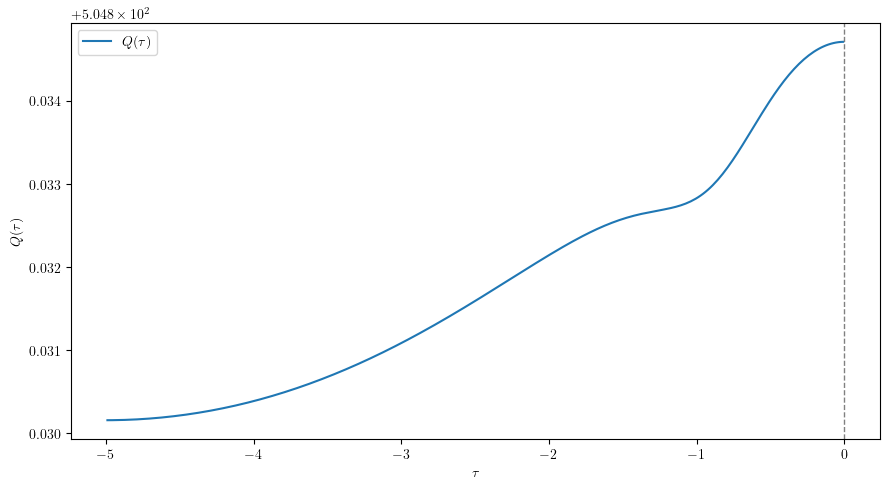

In [ ]:
# Carica Q(τ) slice per slice (stesso stile del plot energia)
from Bubble_finder.observables_2d import compute_charge_2d

# solver, sol, y, ybar, grid dalla cella JR precedente
_, Q_tau = compute_charge_2d(solver, y, ybar, return_profile=True)
tau_plot = np.asarray(grid.tau, dtype=float).flatten()

plt.figure(figsize=(9, 5))
plt.plot(tau_plot, Q_tau, label=r"$Q(\tau)$")
plt.axvline(0.0, ls="--", lw=1, color="gray")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$Q(\tau)$")
plt.legend()
plt.tight_layout()
plt.show()


[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
=== Obiettivo 1: Energia Minkowski dalla bounce vs E_hom ===
  E_M(tau≈0)   = 4.43543598e+02
  E_M(tau_min) = 4.43543598e+02
  DeltaE_M_tau = E_M_tau0 - E_M_taumin = 0.00000000e+00
  E_hom        = 1.98018875e+02
  E_M_tau0 - E_hom   = 2.45524723e+02
  E_M_taumin - E_hom = 2.45524723e+02
  E_M(τ=0 ghost, solver) = 2.00486751e+02
  E_M_tau0 + V_ref*V_ball = 2.12453780e+02
  diff (solver - (E_M_tau0+V_ref*V_ball)) = -1.196703e+01
  (La cella usa E_M−V_ref×V_ball e slice+gradient; il solver dà E_M totale con ricostruzione ghost a τ=0.)


/tmp/ipykernel_139014/2703724331.py:95: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_M_tau = pref * np.trapz(E_M_dens * r2[None, :], r, axis=1)


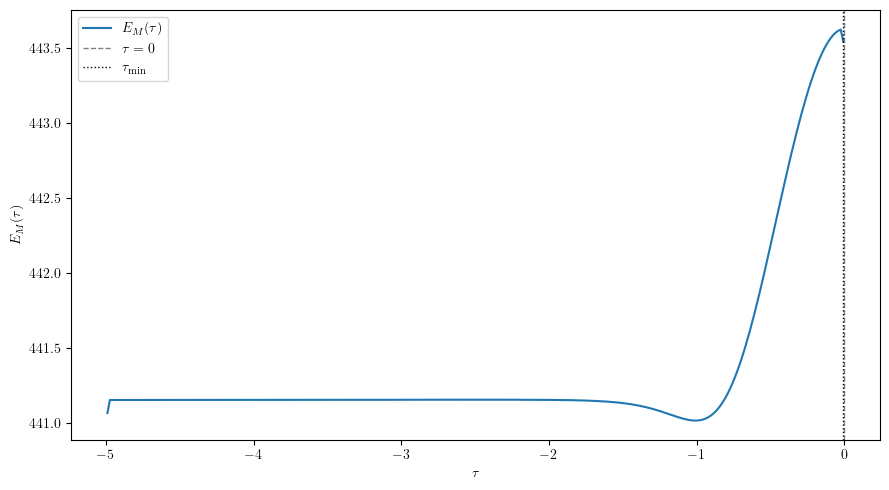


=== Obiettivo 2: Pre-scan → rho_edge → omega_eff → Q ===
  s_edge_pre   = (phi*phibar).real a tau≈0, r=r_max = 1.13402410e+00
  rho_edge_pre = sqrt(max(s_edge_pre,0)) = 1.06490568e+00
  omega_eff_pre = 8.49542216e-01
  Q_pre (soluzione pre-scan) = 5.05697306e+02
  Q_hom_eff = Q_hom(rho_edge_pre, omega_eff_pre) = 5.04435766e+02
  Q_hom_current = Q_hom(OMEGA_ref) = 5.04833757e+02
  Q_pre / Q_hom_eff   = 1.002501
  Q_pre / Q_hom_current = 1.001711
  Q_hom_eff / Q_hom_current = 0.999212
  Q_pre - Q_hom_eff = 1.261540e+00
  Q_pre - Q_hom_current = 8.635484e-01
  Commento: Q_pre è più vicino a Q_hom_current → il riferimento a OMEGA_ref è più consistente.


In [ ]:
# ============================================================
# Diagnostica: E_M dalla bounce vs E_hom; pre-scan eta0 → rho_edge → omega_eff → Q_hom_eff
# Non refactor; nomi variabili esistenti invariati.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --- Solver e soluzione (post-scan) ---
try:
    solver = solver_res
    sol = sol_eta_res
except NameError:
    try:
        solver = solver_2d_g
        sol = sol_2d_g
    except NameError:
        raise NameError("Serve (solver_res, sol_eta_res) o (solver_2d_g, sol_2d_g).")

# Soluzione pre-scan (prima di eta0): cerca sol_res, altrimenti warning e fallback a sol_eta_res
sol_pre_eta = None
for _name in ("sol_res", "sol_pre_eta", "sol_pre"):
    try:
        sol_pre_eta = eval(_name)
        break
    except NameError:
        continue
if sol_pre_eta is None:
    print("WARNING: soluzione pre-scan (sol_res / sol_pre_eta) non trovata. Uso sol_eta_res come fallback.")
    sol_pre_eta = sol

grid = solver.grid
tau = np.asarray(grid.tau, dtype=float).flatten()
r = np.asarray(grid.r, dtype=float).flatten()
Nr, Nt = r.size, tau.size
r_max = float(r[-1])
V_ball = (4.0 / 3.0) * np.pi * (r_max**3)

# OMEGA di riferimento (come nel notebook)
try:
    OMEGA_ref = float(OMEGA)
except NameError:
    OMEGA_ref = float(getattr(solver, "omega", 0.85))
try:
    if np.isfinite(omega_res):
        OMEGA_ref = float(omega_res)
except NameError:
    pass

# V_of_s
try:
    V_of_s
except NameError:
    from Bubble_finder.rate_exponent import make_V_of_s_from_U
    V_of_s = make_V_of_s_from_U(solver.U)

def V_density(phi, phibar):
    s = (phibar * phi).real
    return V_of_s(np.maximum(s, 0.0))

# --- Riferimento omogeneo a OMEGA_ref (stesso del notebook) ---
from Bubble_finder.potential_bubble import vacua_of_Omega
from Bubble_finder.observables_1d import Q_homogeneous_ball
from Bubble_finder.observables_2d import homogeneous_E_M_2d, compute_charge_2d, compute_charge_tau0_ghost_2d, compute_energy_minkowski_tau0_ghost_2d

rho_false_ref, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA_ref)
rho_false_ref = float(rho_false_ref)
V_ref = float(np.asarray(V_of_s(np.array([rho_false_ref**2])), dtype=float).flat[0])
E_hom = float(homogeneous_E_M_2d(OMEGA_ref, rho_false_ref, r_max, solver.U))
Q_hom_current = float(Q_homogeneous_ball(OMEGA_ref, rho_false_ref, r_max))

# --- Obiettivo 1: E_M(tau) dalla bounce (post-scan) ---
y, ybar = (sol.y, sol.ybar) if hasattr(sol, "y") else solver.unpack(sol.x)
phi_nr_nt, phibar_nr_nt = solver.phi(y, ybar)
phi = np.asarray(phi_nr_nt.T)
phibar = np.asarray(phibar_nr_nt.T)

dphi_dtau = np.gradient(phi, tau, axis=0, edge_order=2)
dphibar_dtau = np.gradient(phibar, tau, axis=0, edge_order=2)
dphi_dr = np.gradient(phi, r, axis=1, edge_order=2)
dphibar_dr = np.gradient(phibar, r, axis=1, edge_order=2)

eta0 = float(getattr(solver, "eta0", 0.0))
if eta0 != 0.0:
    tau_kin = (dphi_dtau - eta0*phi) * (dphibar_dtau + eta0*phibar)
else:
    tau_kin = dphi_dtau * dphibar_dtau
tau_kin = tau_kin.real
spatial = (dphi_dr * dphibar_dr).real
V_arr = V_density(phi, phibar)

E_M_dens = -tau_kin + spatial + (V_arr - V_ref)
r2 = r**2
pref = 4.0 * np.pi
E_M_tau = pref * np.trapz(E_M_dens * r2[None, :], r, axis=1)

i0 = int(np.argmin(np.abs(tau - 0.0)))
i_taumin = 0
E_M_tau0 = float(E_M_tau[i0])
E_M_taumin = float(E_M_tau[i_taumin])
DeltaE_M_tau = E_M_tau0 - E_M_taumin

print("=== Obiettivo 1: Energia Minkowski dalla bounce vs E_hom ===")
print(f"  E_M(tau≈0)   = {E_M_tau0:.8e}")
print(f"  E_M(tau_min) = {E_M_taumin:.8e}")
print(f"  DeltaE_M_tau = E_M_tau0 - E_M_taumin = {DeltaE_M_tau:.8e}")
print(f"  E_hom        = {E_hom:.8e}")
print(f"  E_M_tau0 - E_hom   = {E_M_tau0 - E_hom:.8e}")
print(f"  E_M_taumin - E_hom = {E_M_taumin - E_hom:.8e}")

# Confronto con energia dal solver (τ=0 ghost): E_M totale vs cella (E_M - V_ref*V_ball)
E_M_tau0_ghost = float(compute_energy_minkowski_tau0_ghost_2d(solver, y, ybar, return_profile=False))
E_M_tau0_plus_Vref = E_M_tau0 + V_ref * V_ball
print(f"  E_M(τ=0 ghost, solver) = {E_M_tau0_ghost:.8e}")
print(f"  E_M_tau0 + V_ref*V_ball = {E_M_tau0_plus_Vref:.8e}")
print(f"  diff (solver - (E_M_tau0+V_ref*V_ball)) = {E_M_tau0_ghost - E_M_tau0_plus_Vref:.6e}")
print("  (La cella usa E_M−V_ref×V_ball e slice+gradient; il solver dà E_M totale con ricostruzione ghost a τ=0.)")

plt.figure(figsize=(9, 5))
plt.plot(tau, E_M_tau, label=r"$E_M(\tau)$")
plt.axvline(0.0, ls="--", lw=1, color="gray", label=r"$\tau=0$")
plt.axvline(tau[i_taumin], ls=":", lw=1, color="black", label=r"$\tau_{\min}$")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$E_M(\tau)$")
plt.legend()
plt.tight_layout()
plt.show()

# --- Obiettivo 2: pre-scan → rho_edge → omega_eff → Q_hom_eff ---
y_pre, ybar_pre = (sol_pre_eta.y, sol_pre_eta.ybar) if hasattr(sol_pre_eta, "y") else solver.unpack(sol_pre_eta.x)
phi_pre_nr_nt, phibar_pre_nr_nt = solver.phi(y_pre, ybar_pre)
phi_pre = np.asarray(phi_pre_nr_nt.T)
phibar_pre = np.asarray(phibar_pre_nr_nt.T)

i0_pre = int(np.argmin(np.abs(tau - 0.0)))
s_edge_pre = (phi_pre[i0_pre, -1] * phibar_pre[i0_pre, -1]).real
rho_edge_pre = np.sqrt(max(s_edge_pre, 0.0))

print("\n=== Obiettivo 2: Pre-scan → rho_edge → omega_eff → Q ===")
print(f"  s_edge_pre   = (phi*phibar).real a tau≈0, r=r_max = {s_edge_pre:.8e}")
print(f"  rho_edge_pre = sqrt(max(s_edge_pre,0)) = {rho_edge_pre:.8e}")

def rho_false_from_omega(omega_val):
    rf, _ = vacua_of_Omega(PHI0, V1, V2, float(omega_val), verbose=False)
    return float(rf)

# Bracket da cella 'φ_false and φ_true vs ω' (omega_valid, omega_max_val)
try:
    omega_low = float(omega_valid.min())
    omega_high = float(omega_max_val)
except NameError:
    omega_low = 0.1
    omega_high = 1.0
try:
    omega_eff_pre = brentq(lambda w: rho_false_from_omega(w) - rho_edge_pre, omega_low, omega_high, xtol=1e-10)
except (ValueError, RuntimeError) as e:
    print(f"  WARNING: brentq per omega_eff fallito: {e}. Imposto omega_eff_pre = OMEGA_ref.")
    omega_eff_pre = OMEGA_ref

def Q_hom_given_rho_omega(rho_val, omega_val):
    return float(Q_homogeneous_ball(omega_val, rho_val, r_max))

Q_hom_eff = Q_hom_given_rho_omega(rho_edge_pre, omega_eff_pre)
Q_pre = float(compute_charge_tau0_ghost_2d(solver, y_pre, ybar_pre, subtract_background=False, return_profile=False))

print(f"  omega_eff_pre = {omega_eff_pre:.8e}")
print(f"  Q_pre (soluzione pre-scan) = {Q_pre:.8e}")
print(f"  Q_hom_eff = Q_hom(rho_edge_pre, omega_eff_pre) = {Q_hom_eff:.8e}")
print(f"  Q_hom_current = Q_hom(OMEGA_ref) = {Q_hom_current:.8e}")
print(f"  Q_pre / Q_hom_eff   = {Q_pre/Q_hom_eff:.6f}")
print(f"  Q_pre / Q_hom_current = {Q_pre/Q_hom_current:.6f}")
print(f"  Q_hom_eff / Q_hom_current = {Q_hom_eff/Q_hom_current:.6f}")
print(f"  Q_pre - Q_hom_eff = {Q_pre - Q_hom_eff:.6e}")
print(f"  Q_pre - Q_hom_current = {Q_pre - Q_hom_current:.6e}")
if abs(Q_pre - Q_hom_eff) < abs(Q_pre - Q_hom_current):
    print("  Commento: Q_pre è più vicino a Q_hom_eff → il rho al bordo indica uno stato omogeneo associato a omega_eff, non a OMEGA_ref.")
else:
    print("  Commento: Q_pre è più vicino a Q_hom_current → il riferimento a OMEGA_ref è più consistente.")


In [ ]:
# ============================================================
# Eta-scan con target Q = Q_hom_eff (match alla carica omogenea efficace da rho_edge_pre)
# Richiede cella diagnostica precedente: solver, sol_pre_eta, Q_hom_eff, V_ref, E_hom, V_ball
# ============================================================
from scipy.optimize import brentq

def solve_at_eta(solver, eta, x0, verbose=False):
    solver.settings.eta0 = float(eta)
    solver.eta0 = float(eta)
    sol = solver.solve(x0, verbose=verbose, verbose_success_block=False)
    return float(sol.Q_tau0.real), sol

def eta_scan_at_beta(solver, eta_start, x_seed, Q_target, V_ref, Q_hom_ref, E_hom_ref, d_eta=0.05, max_steps=80, tol_Q=1e-6, verbose=True):
    """Bracket eta con Q che attraversa Q_target, poi brentq. Q diminuisce con eta (dQ/dη < 0)."""
    tol_Q = tol_Q * max(1.0, abs(Q_target))
    E_Q_ref = E_hom_ref if (E_hom_ref is not None and abs(E_hom_ref) > 1e-30) else 1.0
    eta_curr = eta_start
    Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
    x_seed = sol_curr.x.copy()
    E_curr = float(sol_curr.E_tau0)
    ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
    ratioE = (E_curr / E_Q_ref) if E_Q_ref else 0.0
    if abs(Q_curr - Q_target) < tol_Q:
        if verbose:
            print(f"[eta-scan Q_hom_eff] eta* = {eta_curr:.6f}, Q = {Q_curr:.6e}, E = {E_curr:.6e}, ratioQ = {ratioQ:.6f}")
        return eta_curr, sol_curr, x_seed, dict(Q=Q_curr, E=E_curr)
    if verbose:
        print(f"[eta-scan Q_hom_eff] eta = {eta_curr:.6f}, Q = {Q_curr:.6e}, target = {Q_target:.6e}, ratioQ = {ratioQ:.6f}")
    eta_prev, Q_prev = eta_curr, Q_curr
    for _ in range(max_steps):
        if Q_curr < Q_target:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr += d_eta
        else:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr -= d_eta
        Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
        x_seed = sol_curr.x.copy()
        E_curr = float(sol_curr.E_tau0)
        ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
        if verbose:
            print(f"[eta-scan Q_hom_eff] eta = {eta_curr:.6f}, Q = {Q_curr:.6e}, ratioQ = {ratioQ:.6f}")
        if (Q_prev - Q_target) * (Q_curr - Q_target) <= 0:
            break
    else:
        raise RuntimeError("eta scan did not cross Q_target within max_steps")
    eta_lo, eta_hi = (eta_curr, eta_prev) if Q_prev < Q_target else (eta_prev, eta_curr)
    state = {"x_seed": x_seed}

    def f_eta(eta):
        q, s = solve_at_eta(solver, float(eta), state["x_seed"], verbose=False)
        state["x_seed"] = s.x.copy()
        return q - Q_target

    eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
    _, sol_final = solve_at_eta(solver, eta_star, state["x_seed"], verbose=False)
    Q_final = float(sol_final.Q_tau0.real)
    E_final = float(sol_final.E_tau0)
    ratioQ_f = (Q_final / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
    if verbose:
        print(f"[eta-scan Q_hom_eff] eta* = {eta_star:.6f}, Q = {Q_final:.6e}, E = {E_final:.6e}, ratioQ = {ratioQ_f:.6f}")
    return eta_star, sol_final, sol_final.x.copy(), dict(Q=Q_final, E=E_final)

# Seed: soluzione pre-scan (eta=0) dalla cella diagnostica
if not hasattr(sol_pre_eta, "x"):
    raise ValueError("Serve sol_pre_eta dalla cella diagnostica (con .x). Esegui prima la cella diagnostica.")
x_seed_Qhom = sol_pre_eta.x.copy()

print("=== Eta-scan con target Q = Q_hom_eff ===")
print(f"  Q_hom_eff = {Q_hom_eff:.8e}")
print(f"  V_ball = {V_ball:.8e},  E_hom = {E_hom:.8e}\n")

eta_star_Qhom_eff, sol_eta_Qhom_eff, _, dens_Qhom_eff = eta_scan_at_beta(
    solver, 0.0, x_seed_Qhom, Q_hom_eff, V_ball, Q_hom_eff, E_hom,
    d_eta=0.05, max_steps=80, tol_Q=1e-10, verbose=True
)

print("\n--- Risultato scan η → Q = Q_hom_eff ---")
print(f"  η₀* (match Q_hom_eff) = {eta_star_Qhom_eff:.8f}")
print(f"  Q finale             = {dens_Qhom_eff['Q']:.8e}")
print(f"  E finale (τ=0 ghost)  = {dens_Qhom_eff['E']:.8e}")
print(f"  Q_finale / Q_hom_eff = {dens_Qhom_eff['Q'] / Q_hom_eff:.10f}")
try:
    print(f"  Confronto con scan a Q_target_res: η₀*_res = {eta_star_res:.8f}")
    print(f"  Differenza η* (Q_hom_eff) - η* (Q_target_res) = {eta_star_Qhom_eff - eta_star_res:.8f}")
except NameError:
    pass

=== Eta-scan con target Q = Q_hom_eff ===
  Q_hom_eff = 5.04435766e+02
  V_ball = 5.23598776e+02,  E_hom = 1.98018875e+02

[eta-scan Q_hom_eff] eta = 0.000000, Q = 5.056973e+02, target = 5.044358e+02, ratioQ = 1.002501
[eta-scan Q_hom_eff] eta = -0.050000, Q = 5.020540e+02, ratioQ = 0.995278
[eta-scan Q_hom_eff] eta* = -0.017279, Q = 5.044358e+02, E = -1.998190e+02, ratioQ = 1.000000

--- Risultato scan η → Q = Q_hom_eff ---
  η₀* (match Q_hom_eff) = -0.01727908
  Q finale             = 5.04435766e+02
  E finale (τ=0 ghost)  = -1.99818992e+02
  Q_finale / Q_hom_eff = 1.0000000000
  Confronto con scan a Q_target_res: η₀*_res = -0.01182393
  Differenza η* (Q_hom_eff) - η* (Q_target_res) = -0.00545515


In [ ]:
# Diagnostica: exponent rate 2D — S_E^2D, S_E^hom, η₀, Q, F^bounce, F_activation (E_1d,crit e E_hom)
import numpy as np
from Bubble_finder.rate_exponent import (
    compute_euclidean_action_full,
    compute_homogeneous_action,
    volume_from_grid,
    compute_suppression_exponent_bubble,
    compute_activation_exponent_bubble,
    make_V_of_s_from_U,
)
from Bubble_finder.observables_1d import compute_energy_physical_1d_volume_corrected
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d
from Bubble_finder.bounce_1d import solve_bounce

V_of_s = make_V_of_s_from_U(U)
V_ball_res = volume_from_grid(solver_res.grid)

# Azione euclidea 2D (bounce) e omogenea
S_E_2D = compute_euclidean_action_full(
    sol_eta_res.y, sol_eta_res.ybar, solver_res.grid,
    omega_res, eta_star_res, rho0_res, V_of_s
)
S_E_hom = compute_homogeneous_action(
    beta_res, V_ball_res, omega_res, rho_false_ref_res, V_of_s
)

# Exponent rate (suppression exponent) F^bounce_{Q,β} = S_E[φ_b] - S_E[φ_hom] + η₀ Q
Q_res = float(dens_res["Q"])
F_bounce = compute_suppression_exponent_bubble(S_E_2D, S_E_hom, eta_star_res, Q_res)

# Energia omogenea: in Resample si usa E_hom_res = homogeneous_energy_2d(...) = H_E,hom (canonical/Euclidean)
# Formula: H_E,hom = V_space * (-ω² ρ₀² - V(ρ₀)). Per F_activation serve E_M,hom (Minkowski) = V_space * (ω² ρ₀² + V(ρ₀)) = -H_E,hom.
V_space_res = (4.0 / 3.0) * np.pi * (Lr_res**3)
V_at_rho0_hom = float(np.asarray(U(np.array([rho_false_ref_res]))).flat[0])
# Come in cella Resample (stesso calcolo che dà E_hom_ref = -1584...)
E_hom_res_same = float(homogeneous_energy_2d(OMEGA, rho_false_ref_res, Lr_res, U))  # H_E,hom
E_M_hom_formula = float(V_space_res * ((OMEGA**2) * (rho_false_ref_res**2) + V_at_rho0_hom))
E_M_hom_res = float(homogeneous_E_M_2d(OMEGA, rho_false_ref_res, Lr_res, U))
r_1d_crit, phi_1d_crit, _, _, _ = solve_bounce(
    PHI0, V1, V2, omega_res, d=3, r0=1e-6, rmax=Lr_res, max_iter=150, verbose=False
)
# E_1d,crit con correzione di volume: stesso volume [0, Lr_res] dell'omogeneo (bounce fino a r_max, poi ρ_false)
E_1d_crit = float(compute_energy_physical_1d_volume_corrected(
    np.asarray(r_1d_crit), np.asarray(phi_1d_crit), omega_res, U,
    r_max_ref=Lr_res, rho_tail=rho_false_ref_res
))

# F_activation = β (E_crit - E_hom) con E_crit = E_1d,crit oppure E_2D
F_activation_1d = compute_activation_exponent_bubble(beta_res, E_1d_crit, E_M_hom_res)
obs_eta = getattr(sol_eta_res, "observables_ghost", None) or {}
E_M_2D_res = float(obs_eta.get("E_M", np.nan))
if np.isnan(E_M_2D_res) and hasattr(sol_eta_res, "E_tau0"):
    E_M_2D_res = float(sol_eta_res.E_tau0)
F_activation_2D = compute_activation_exponent_bubble(beta_res, E_M_2D_res, E_M_hom_res)

print("========== Exponent rate (configurazione 2D dopo resample + η scan) ==========")
print("")
print("  --- Parametri griglia e riferimento ---")
print(f"  ω (omega_res, per bounce/2D) = {omega_res:.6f}")
print(f"  OMEGA (per E_M,hom)         = {OMEGA:.6f}")
print(f"  β = {beta_res:.4f},   Lr = {Lr_res:.4f},   Nr = {Nr_res},   Nτ = {Ntau_res}")
print(f"  V_ball = (4/3)π Lr³ = {V_ball_res:.6f}")
print(f"  ρ_false (riferimento omogeneo) = {rho_false_ref_res:.6f},   ρ0 (seed solver) = {rho0_res:.6f}")
print("")
print("  --- Azioni euclidee e exponent ---")
print(f"  S_E^2D   = {S_E_2D:.6f}")
print(f"  S_E^hom  = {S_E_hom:.6f}")
print(f"  η₀*      = {eta_star_res:.6f}")
print(f"  Q        = {Q_res:.6f}")
print(f"  F^bounce_{{Q,β}} (suppression exponent) = {F_bounce:.6f}")
print("")
print("  --- Energia omogenea (come in cella Resample vs Minkowski per F_activation) ---")
print(f"  E_hom (H_E, come in Resample) = homogeneous_energy_2d(OMEGA, ρ_false, Lr, U):  {E_hom_res_same:.6f}")
print(f"  Formula H_E,hom = V_space × (-ω² ρ₀² - V(ρ₀));  per omogeneo  E_M,hom = -H_E,hom.")
print(f"  E_M,hom (Minkowski, per F_activation) da formula:  {E_M_hom_formula:.6f}")
print(f"  E_M,hom da homogeneous_E_M_2d(OMEGA, ρ_false, Lr, U):     {E_M_hom_res:.6f}")
print(f"  (V(ρ₀) = {V_at_rho0_hom:.6f};  check E_M,hom ≈ -E_hom_res: {-E_hom_res_same:.6f})")
print("")
print("  --- Energie bolla vs omogeneo (a ω fissato di solito E_bolla > E_hom) ---")
print(f"  E_1d,crit (1D, vol. corr.) = {E_1d_crit:.6f}    Δ = E_1d,crit - E_M,hom = {E_1d_crit - E_M_hom_res:.6f}")
print(f"  E_M,2D                    = {E_M_2D_res:.6f}    Δ = E_M,2D - E_M,hom   = {E_M_2D_res - E_M_hom_res:.6f}")
print("")
print("  --- F_activation = β (E_crit - E_hom) ---")
print(f"  F_activation (con E_1d,crit) = {F_activation_1d:.6f}")
print(f"  F_activation (con E_2D)      = {F_activation_2D:.6f}")

========== Exponent rate (configurazione 2D dopo resample + η scan) ==========

  --- Parametri griglia e riferimento ---
  ω (omega_res, per bounce/2D) = 0.850000
  OMEGA (per E_M,hom)         = 0.850000
  β = 15.0000,   Lr = 5.0000,   Nr = 500,   Nτ = 100
  V_ball = (4/3)π Lr³ = 523.599817
  ρ_false (riferimento omogeneo) = 1.065039,   ρ0 (seed solver) = 1.065039

  --- Azioni euclidee e exponent ---
  S_E^2D   = -9885.578291
  S_E^hom  = -9902.997367
  η₀*      = -0.011827
  Q        = 504.833757
  F^bounce_{Q,β} (suppression exponent) = 11.448355

  --- Energia omogenea (come in cella Resample vs Minkowski per F_activation) ---
  E_hom (H_E, come in Resample) = homogeneous_energy_2d(OMEGA, ρ_false, Lr, U):  -198.018875
  Formula H_E,hom = V_space × (-ω² ρ₀² - V(ρ₀));  per omogeneo  E_M,hom = -H_E,hom.
  E_M,hom (Minkowski, per F_activation) da formula:  198.018875
  E_M,hom da homogeneous_E_M_2d(OMEGA, ρ_false, Lr, U):     198.018875
  (V(ρ₀) = -0.441349;  check E_M,hom ≈ -E_hom_re

## Ω Scan (in-notebook pipeline)

For each ω in a range: homogeneous reference → gated-bubble ansatz → Newton → η₀ scan to match Q_hom → store results in memory. No file I/O.

In [ ]:
# Ω Scan parameters (notebook-only; no file I/O)
omega_min = 0.8
omega_max = 0.94
N_omega = 15
tol_Q = 1e-6
max_newton_iter = 35
eta0_init = 0.0
# η0 bracket: initial step and expansion
d_eta_bracket = 0.5
eta_bracket_expand = 1.5
max_bracket_expansions = 20
max_secant_iter = 5
max_bisect_iter = 80
# Grid (fixed for all ω)
Lr_scan = 15.0
Nr_scan = 120
Ntau_scan = 80
beta_scan = 10.0

omega_grid = np.linspace(omega_min, omega_max, N_omega)
omega_scan_results = []
omega_scan_fields = []

In [ ]:
# Ω Scan driver: loop ω → hom ref → gated ansatz → Newton → η0 scan → store (no file I/O)
from scipy.optimize import brentq
from Bubble_finder.observables_1d import Q_homogeneous_ball
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver
from Bubble_finder.ansatz_bubble import AnsatzParams, tau_gate

verbose_eta_scan = True

# Charge match target: homogeneous charge at fixed ω = 0.85 (same for all scan points)
OMEGA_Q_MATCH = 0.85
rho_false_Qmatch, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA_Q_MATCH)
Q_target_fixed = float(Q_homogeneous_ball(OMEGA_Q_MATCH, rho_false_Qmatch, Lr_scan))

for idx_om, omega in enumerate(omega_grid):
    OMEGA = float(omega)
    rec = {"omega": OMEGA, "status": "OK", "eta_star": np.nan, "newton_success": False,
           "n_newton_iter": 0, "residual_norm": np.nan,
           "Q_2D": np.nan, "E_M_2D": np.nan, "F_omega_2D": np.nan,
           "Q_hom": np.nan, "E_M_hom": np.nan, "F_omega_hom": np.nan,
           "E_M_2D_tilde": np.nan,
           "delta_Q": np.nan, "delta_E_M": np.nan, "delta_F_omega": np.nan,
           "ratio_Q": np.nan, "ratio_E_M": np.nan,
           "max_rho_minus_rho_hom": np.nan, "radius_midpoint": np.nan, "wall_thickness_proxy": np.nan}
    try:
        rho_false_om, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)
        rho_hom_om = float(rho_false_om)
        V_scan = (4.0 / 3.0) * np.pi * Lr_scan**3
        Q_hom_om = float(Q_homogeneous_ball(OMEGA, rho_hom_om, Lr_scan))
        E_hom_om = float(homogeneous_energy_2d(OMEGA, rho_hom_om, Lr_scan, U))
        E_M_hom_om = float(homogeneous_E_M_2d(OMEGA, rho_hom_om, Lr_scan, U))
        F_omega_hom_om = E_M_hom_om - OMEGA * Q_hom_om
        rec["Q_hom"], rec["E_M_hom"], rec["F_omega_hom"] = Q_hom_om, E_M_hom_om, F_omega_hom_om
        Q_target = Q_target_fixed  # match to homogeneous charge at ω = OMEGA_Q_MATCH (0.85), not current scan ω
        tol_Q_abs = tol_Q * max(1.0, abs(Q_target))

        settings_scan = Bubble2DSettings(
            Nr=Nr_scan, Ntau=Ntau_scan, Lr=Lr_scan, beta=beta_scan,
            omega_ref=OMEGA, rho0=rho_hom_om, rho0_bracket=(V1 * 0.8, V2 + 0.2),
            newton_tol=1e-8, newton_max_iter=max_newton_iter, tau_bc="twisted",
        )
        solver_scan = Bubble2DSolver(settings_scan, U, dU, d2U)
        r_scan = np.asarray(solver_scan.grid.r).flatten()
        tau_scan = np.asarray(solver_scan.grid.tau).flatten()
        Nr, Nt = r_scan.size, tau_scan.size

        def solve_at_eta(solver, eta, x0, verbose=False):
            solver.settings.eta0 = float(eta)
            solver.eta0 = float(eta)
            sol = solver.solve(x0, verbose=verbose, verbose_success_block=False, store_iteration_history=False)
            return float(sol.Q_tau0.real), sol

        def eta_scan_at_beta(solver, eta_start, x_seed, Q_target, V_ref, Q_hom_ref, E_hom_ref, d_eta=0.5, max_steps=80, tol_Q=1e-6, verbose=True):
            """Bracket eta con Q che attraversa Q_target, poi brentq. Q diminuisce con eta (dQ/dη < 0)."""
            tol_Q = tol_Q * max(1.0, abs(Q_target))
            eta_cache = {}
            eta_cache_precision = 1e-12
            E_Q_ref = E_hom_ref if (E_hom_ref and abs(E_hom_ref) > 1e-30) else 1.0
            eta_curr = eta_start
            Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
            x_seed = sol_curr.x.copy()
            E_curr = float(sol_curr.E_tau0)
            ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
            ratioE = (E_curr / E_Q_ref) if E_Q_ref else 0.0
            eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
            if abs(Q_curr - Q_target) < tol_Q:
                if verbose:
                    print(f"[eta-scan] eta* = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
                return eta_curr, sol_curr, x_seed, dict(Q=Q_curr, E=E_curr)
            if verbose:
                print(f"[eta-scan] eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, target = {Q_target:.6e}, ratioQ = {ratioQ:.6f}")
            eta_prev, Q_prev = eta_curr, Q_curr
            for _ in range(max_steps):
                if Q_curr < Q_target:
                    eta_prev, Q_prev = eta_curr, Q_curr
                    eta_curr += d_eta
                else:
                    eta_prev, Q_prev = eta_curr, Q_curr
                    eta_curr -= d_eta
                Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
                x_seed = sol_curr.x.copy()
                E_curr = float(sol_curr.E_tau0)
                ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
                ratioE = (E_curr / E_Q_ref) if E_Q_ref else 0.0
                eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
                if verbose:
                    print(f"[eta-scan] try eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
                if (Q_prev - Q_target) * (Q_curr - Q_target) <= 0:
                    break
            else:
                raise RuntimeError("eta scan did not cross Q_target within max_steps")
            eta_lo, eta_hi = (eta_curr, eta_prev) if Q_prev < Q_target else (eta_prev, eta_curr)
            state = {"x_seed": x_seed}

            def f_eta(eta):
                eta_f = float(eta)
                key = round(eta_f / eta_cache_precision) * eta_cache_precision
                if key in eta_cache:
                    q, e, rq, re = eta_cache[key]
                    if verbose:
                        print(f"[eta-root] eta = {eta_f:.6f} (cached), charge = {q:.6e}, energy = {e:.6e}, ratioQ = {rq:.6f}, ratioE = {re:.6f}")
                    return q - Q_target
                q, s = solve_at_eta(solver, eta_f, state["x_seed"], verbose=False)
                state["x_seed"] = s.x.copy()
                e = float(s.E_tau0)
                rq = (q / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
                re = (e / E_Q_ref) if E_Q_ref else 0.0
                eta_cache[key] = (q, e, rq, re)
                if verbose:
                    print(f"[eta-root] eta = {eta_f:.6f}, charge = {q:.6e}, energy = {e:.6e}, ratioQ = {rq:.6f}, ratioE = {re:.6f}")
                return q - Q_target

            eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
            _, sol_final = solve_at_eta(solver, eta_star, state["x_seed"], verbose=False)
            x_seed = sol_final.x.copy()
            Q_final = float(sol_final.Q_tau0.real)
            E_final = float(sol_final.E_tau0)
            ratioQ_f = (Q_final / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
            ratioE_f = (E_final / E_Q_ref) if E_Q_ref else 0.0
            if verbose:
                print(f"[eta-scan] eta* = {eta_star:.6f}, charge = {Q_final:.6e}, energy = {E_final:.6e}, ratioQ = {ratioQ_f:.6f}, ratioE = {ratioE_f:.6f}")
            return eta_star, sol_final, x_seed, dict(Q=Q_final, E=E_final)

        # Newton ogni volta con omega_scan: ansatz gated per l'omega corrente (no warm start)
        r_1d, phi_1d, _, _, _ = solve_bounce(PHI0, V1, V2, OMEGA, d=3, r0=1e-10, rmax=Lr_scan, max_iter=150, verbose=False)
        r_1d = np.asarray(r_1d, float)
        phi_1d = np.asarray(phi_1d, float)
        T_scan = beta_scan / 2.0
        params_g = AnsatzParams(eps=1.0, k=1, phase=0.0, amp=1.0, tau_gate_frac=0.25, tau_gate_center_frac=1, r_window_frac=0.15)
        phi_on_r = np.interp(r_scan, r_1d, phi_1d, left=phi_1d[0], right=phi_1d[-1])
        y_slice = r_scan * (phi_on_r - solver_scan.rho0)
        g_tau = tau_gate(tau_scan, T_scan, params_g.tau_gate_frac, center_frac=params_g.tau_gate_center_frac)
        y_gated = params_g.amp * np.outer(y_slice, g_tau).astype(complex)
        ybar_gated = y_gated.copy()
        x0_scan = solver_scan.pack(y_gated, ybar_gated)

        sol_newt = solver_scan.solve(x0_scan, verbose=True, verbose_success_block=False, store_iteration_history=False)
        rec["newton_success"] = bool(getattr(sol_newt, "success", True))
        rec["residual_norm"] = float(getattr(sol_newt, "residual_norm", np.nan))
        rec["n_newton_iter"] = int(getattr(sol_newt, "n_iter", 0))
        if not rec["newton_success"]:
            rec["status"] = "FAIL_NEWTON"
            omega_scan_results.append(rec)
            continue

        x_seed = sol_newt.x.copy()
        x_seed_newton = sol_newt.x.copy()  # keep copy for second eta-scan (Q match to Q_hom(ω̃))
        eta_start = 0 #beta_scan * (OMEGA_Q_MATCH - OMEGA)
        try:
            eta_star, sol_final, x_seed, dens = eta_scan_at_beta(
                solver_scan, eta_start, x_seed, Q_target, V_scan, Q_hom_om, E_hom_om,
                d_eta=d_eta_bracket, max_steps=max_bracket_expansions, tol_Q=tol_Q, verbose=verbose_eta_scan
            )
        except RuntimeError:
            rec["status"] = "FAIL_QMATCH"
            omega_scan_results.append(rec)
            continue

        eta0_prev = eta_star
        rec["eta_star"] = eta_star
        obs_f = getattr(sol_final, "observables_ghost", None) or {}
        rec["Q_2D"] = float(obs_f.get("Q", sol_final.Q_tau0.real))
        if verbose_eta_scan:
            print(f"[η-scan] ω={OMEGA:.4f}  eta*={eta_star:.6f}  Q_final={rec['Q_2D']:.6e}  (target={Q_target:.6e})")
        rec["E_M_2D"] = float(obs_f.get("E_M", np.nan))
        if np.isnan(rec["E_M_2D"]) and hasattr(sol_final, "E_tau0"):
            rec["E_M_2D"] = float(sol_final.E_tau0)
        rec["F_omega_2D"] = rec["E_M_2D"] - OMEGA * rec["Q_2D"]
        rec["delta_Q"] = rec["Q_2D"] - rec["Q_hom"]
        rec["delta_E_M"] = rec["E_M_2D"] - rec["E_M_hom"]
        rec["delta_F_omega"] = rec["F_omega_2D"] - rec["F_omega_hom"]
        rec["ratio_Q"] = rec["Q_2D"] / max(rec["Q_hom"], 1e-30)
        rec["ratio_E_M"] = rec["E_M_2D"] / max(abs(rec["E_M_hom"]), 1e-30)
        rho_tau0 = solver_scan.rho_map(sol_final.y, sol_final.ybar)[:, np.argmax(tau_scan)]
        rec["max_rho_minus_rho_hom"] = float(np.max(np.abs(rho_tau0 - rho_hom_om)))
        rho_mid = 0.5 * (rho_tau0[0] + rho_hom_om)
        cross = np.where(np.diff(np.sign(rho_tau0 - rho_mid)))[0]
        rec["radius_midpoint"] = float(r_scan[cross[0]]) if len(cross) > 0 else np.nan
        drho = np.abs(np.gradient(rho_tau0, r_scan))
        rec["wall_thickness_proxy"] = float(np.max(drho))
        # Second config: same ω̃, but Q match to Q_hom(ω̃) → E_2D(Q(ω̃), ω̃)
        try:
            _, sol_final_tilde, _, _ = eta_scan_at_beta(
                solver_scan, eta_start, x_seed_newton, Q_hom_om, V_scan, Q_hom_om, E_hom_om,
                d_eta=d_eta_bracket, max_steps=max_bracket_expansions, tol_Q=tol_Q, verbose=False
            )
            obs_tilde = getattr(sol_final_tilde, "observables_ghost", None) or {}
            rec["E_M_2D_tilde"] = float(obs_tilde.get("E_M", np.nan))
            if np.isnan(rec["E_M_2D_tilde"]) and hasattr(sol_final_tilde, "E_tau0"):
                rec["E_M_2D_tilde"] = float(sol_final_tilde.E_tau0)
        except RuntimeError:
            pass  # leave E_M_2D_tilde as np.nan
        fields_om = {"omega": OMEGA, "r_grid": r_scan.copy(), "tau_grid": tau_scan.copy(), "rho_tau0": rho_tau0.copy()}
        omega_scan_fields.append(fields_om)
    except Exception as e:
        rec["status"] = "FAIL_NEWTON" if "FAIL_QMATCH" not in str(rec.get("status", "")) else rec["status"]
        rec["status"] = "FAIL" if rec["status"] == "OK" else rec["status"]
    omega_scan_results.append(rec)

print("Ω Scan done. Success:", sum(1 for r in omega_scan_results if r["status"] == "OK"))


[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
[vacua_of_Omega] ω=0.8
  phi_false=1.05249880435  Ω_false=-1.16844545218  dΩ=-1.31e-09  (ω²-W)=6.20e-10  Ω''=1.548e+01
  phi_true =2.08622895489  Ω_true =-4.18518224347  dΩ=-4.15e-07  (ω²-W)=9.94e-08  Ω''=4.011e+01
[Newton-explicit] iter=01, ||F||=9.696e+00, rhoQ=8.864204e-01, rhoE=-2.499689e-01, rho_Q/rho_Q_ref=1.0002, rho_E/rho_E_ref=1.0020
[Newton-explicit] iter=02, ||F||=7.911e+00, rhoQ=8.863939e-01, rhoE=-2.499822e-01, rho_Q/rho_Q_ref=1.0002, rho_E/rho_E_ref=1.0020
[Newton-explicit] iter=03, ||F||=6.729e+00, rhoQ=8.863751e-01, rhoE=-2.499872e-01, rho_Q/rho_Q_ref=1.0002, rho_E/rho_E_ref=1.0020
[Newton-explicit] iter=04, ||F||=5.285e+00, rhoQ=8.863390e-01, rhoE=-2.499595e-01, rho_Q/rho_Q_ref=1.0002, rho_E/rho_E_ref=1.0019
[Newton-explicit] iter=05, ||F||=9.578e-01, rhoQ=8

========== Ω Scan summary ==========
  Successful ω points: 30 / 30

[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):
    Q_hom = 13630.511445,   E_hom = -5346.509632   (H_E, Euclideo)
    E_M,hom = 5346.509632   (Minkowski, usato per il plot)
    ρ_Q,hom = Q_hom/V = 0.964161,   ρ_E,hom = E_hom/V = -0.378188

  ω tale che E_2D(ω) − E_hom(OMEGA) = 0: non trovato



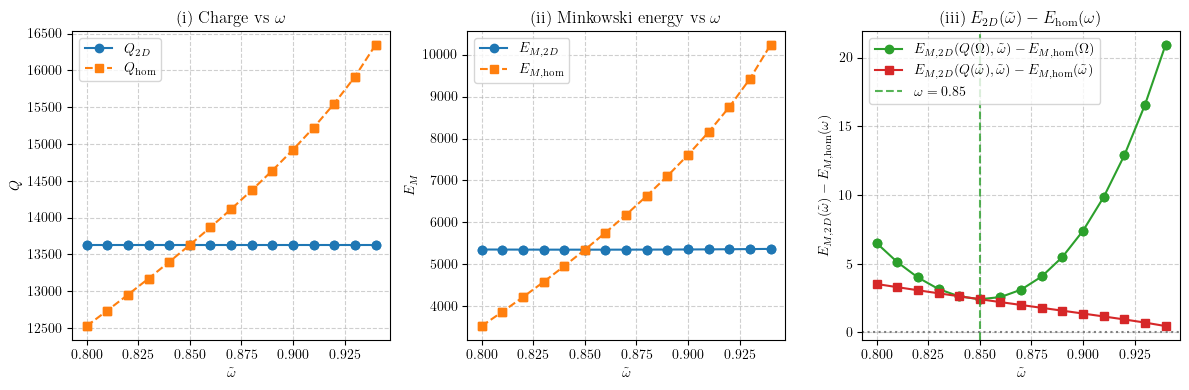

In [ ]:
# Ω Scan summary plots and success/fail summary
import pandas as pd
from scipy.interpolate import UnivariateSpline
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d

df_omega = pd.DataFrame(omega_scan_results)
ok = df_omega["status"] == "OK"
n_ok = int(ok.sum())
failed_omega = df_omega.loc[~ok, "omega"].tolist() if not ok.all() else []

print("========== Ω Scan summary ==========")
print(f"  Successful ω points: {n_ok} / {len(omega_scan_results)}")
if failed_omega:
    print(f"  Failed ω (Newton or Q-match): {failed_omega}")
print("")

# Riferimento omogeneo a ω = OMEGA_ref (stesso V dello scan): E_hom = H_E Euclideo, E_M,hom = Minkowski
# Nello scan E_M_hom nel df è E_M,hom(ω) per ogni ω, NON E_M,hom(OMEGA_ref); quindi ricalcoliamo il riferimento.
OMEGA_ref = OMEGA_Q_MATCH  # ω fisso di riferimento (es. 0.85)
rho_false_ref, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA_ref)
rho_false_ref = float(rho_false_ref)
V_scan = (4.0 / 3.0) * np.pi * Lr_scan**3
E_hom_ref = float(homogeneous_energy_2d(OMEGA_ref, rho_false_ref, Lr_scan, U))   # H_E,hom (Euclideo, negativo)
E_M_hom_ref = float(homogeneous_E_M_2d(OMEGA_ref, rho_false_ref, Lr_scan, U))     # E_M,hom (Minkowski)
Q_hom_ref = float(Q_homogeneous_ball(OMEGA_ref, rho_false_ref, Lr_scan))
print("  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):")
print(f"    Q_hom = {Q_hom_ref:.6f},   E_hom = {E_hom_ref:.6f}   (H_E, Euclideo)")
print(f"    E_M,hom = {E_M_hom_ref:.6f}   (Minkowski, usato per il plot)")
print(f"    ρ_Q,hom = Q_hom/V = {Q_hom_ref/V_scan:.6f},   ρ_E,hom = E_hom/V = {E_hom_ref/V_scan:.6f}")
print("")

def _omega_zero_crossing(w, y):
    """ω dove y = 0 tramite spline interpolante (valore preciso)."""
    w, y = np.asarray(w, float), np.asarray(y, float)
    if len(w) < 2:
        return None
    # UnivariateSpline(s=0) richiede x strettamente crescenti: ordina e rimuovi duplicati in w
    idx = np.argsort(w)
    w_s, y_s = w[idx], y[idx]
    w_u, inv = np.unique(w_s, return_inverse=True)
    y_u = np.array([y_s[inv == i].mean() for i in range(len(w_u))])
    if len(w_u) < 2:
        return None
    spl = UnivariateSpline(w_u, y_u, s=0)
    roots = spl.roots()
    wmin, wmax = w_u.min(), w_u.max()
    valid = roots[(roots >= wmin) & (roots <= wmax)]
    return float(valid[0]) if len(valid) > 0 else None

# Differenze da plottare
# (1) E_M,2D(Q(OMEGA), ω̃) − E_M,hom(OMEGA_ref)  [config che matcha Q a OMEGA]
# (2) E_M,2D(Q(ω̃), ω̃) − E_M,hom(ω̃)  [config che matcha Q a ω̃]
E_hom_OMEGA = E_M_hom_ref
diff_E2D_minus_Ehom_OMEGA = df_omega["E_M_2D"] - E_hom_OMEGA  # E_2D(Q(OMEGA), ω̃) − E_M,hom(OMEGA)
diff_E2D_tilde_minus_Ehom_tilde = df_omega["E_M_2D_tilde"] - df_omega["E_M_hom"]  # E_2D(Q(ω̃), ω̃) − E_M,hom(ω̃)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
w = df_omega["omega"]
# Evita ripetizione visiva: se primo e ultimo ω coincidono (griglia periodica), escludi l'ultimo punto dal plot
if len(w) > 1 and np.isclose(w.iloc[0], w.iloc[-1]):
    p = slice(None, -1)
else:
    p = slice(None)
w_plot = w.iloc[p]
# Ordina per ω così la linea non "chiude" tra ultimo e primo (disegno in ordine crescente di ω)
i_sort = np.argsort(w_plot.values)
w_plot = w_plot.iloc[i_sort]

omega_diff_E2D_Ehom_zero = _omega_zero_crossing(w, diff_E2D_minus_Ehom_OMEGA)
print("  ω tale che E_2D(ω) − E_hom(OMEGA) = 0:", omega_diff_E2D_Ehom_zero if omega_diff_E2D_Ehom_zero is not None else "non trovato")
print("")

ax1.plot(w_plot, df_omega["Q_2D"].iloc[p].iloc[i_sort], "o-", label=r"$Q_{2D}$")
ax1.plot(w_plot, df_omega["Q_hom"].iloc[p].iloc[i_sort], "s--", label=r"$Q_{\mathrm{hom}}$")
ax1.set_xlabel(r"$\tilde \omega$")
ax1.set_ylabel(r"$Q$")
ax1.legend()
ax1.grid(True, ls="--", alpha=0.6)
ax1.set_title(r"(i) Charge vs $\omega$")

ax2.plot(w_plot, df_omega["E_M_2D"].iloc[p].iloc[i_sort], "o-", label=r"$E_{M,2D}$")
ax2.plot(w_plot, df_omega["E_M_hom"].iloc[p].iloc[i_sort], "s--", label=r"$E_{M,\mathrm{hom}}$")
ax2.set_xlabel(r"$\tilde \omega$")
ax2.set_ylabel(r"$E_M$")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.6)
ax2.set_title(r"(ii) Minkowski energy vs $\omega$")

ax3.plot(w_plot, diff_E2D_minus_Ehom_OMEGA.iloc[p].iloc[i_sort], "o-", color="C2", label=r"$E_{M,2D}(Q(\Omega),\tilde\omega) - E_{M,\mathrm{hom}}(\Omega)$")
diff_tilde_p = diff_E2D_tilde_minus_Ehom_tilde.iloc[p].iloc[i_sort]
valid_tilde = np.isfinite(diff_tilde_p)
ax3.plot(w_plot[valid_tilde], diff_tilde_p[valid_tilde], "s-", color="C3", label=r"$E_{M,2D}(Q(\tilde\omega),\tilde\omega) - E_{M,\mathrm{hom}}(\tilde\omega)$")
ax3.axhline(0, color="gray", ls=":")
if omega_diff_E2D_Ehom_zero is not None:
    ax3.axvline(omega_diff_E2D_Ehom_zero, color="C2", ls="--", alpha=0.8, label=rf"$=0$: $\omega$={omega_diff_E2D_Ehom_zero:.4f}")
ax3.axvline(0.85, color="C2", ls="--", alpha=0.8, label=rf"$\omega=0.85$")
ax3.set_xlabel(r"$\tilde \omega$")
ax3.set_ylabel(r"$E_{M,2D}(\tilde \omega) - E_{M,\mathrm{hom}}(\omega)$")
ax3.legend()
ax3.grid(True, ls="--", alpha=0.6)
ax3.set_title(r"(iii) $E_{2D}(\tilde \omega) - E_{\mathrm{hom}}(\omega)$")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "omega_scan_summary.pdf", dpi=150, bbox_inches="tight")
plt.show()

[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01


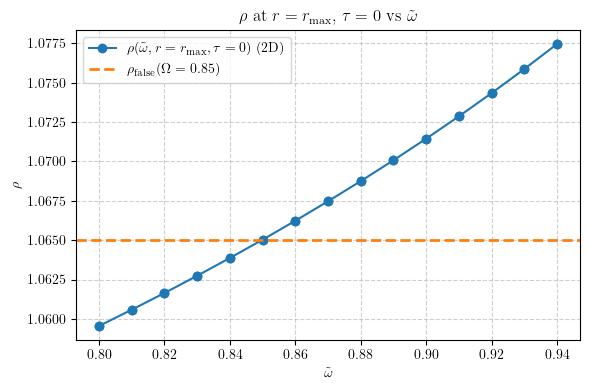

In [ ]:
# ρ(r=r_max, τ=0) dalla soluzione 2D al variare di ω̃ vs ρ_false(Ω=0.85) di riferimento
OMEGA_ref = OMEGA_Q_MATCH  # 0.85
rho_false_ref, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA_ref)
rho_false_ref = float(rho_false_ref)

omega_vals = np.array([f["omega"] for f in omega_scan_fields])
rho_at_rmax_tau0 = np.array([f["rho_tau0"][-1] for f in omega_scan_fields])  # ρ(ω̃, r=r_max, τ=0)
# Evita che la curva colleghi ultimo e primo: escludi ultimo punto se ω periodico, poi ordina per ω
if len(omega_vals) > 1 and np.isclose(omega_vals[0], omega_vals[-1]):
    omega_vals = omega_vals[:-1]
    rho_at_rmax_tau0 = rho_at_rmax_tau0[:-1]
i_sort = np.argsort(omega_vals)
omega_vals = omega_vals[i_sort]
rho_at_rmax_tau0 = rho_at_rmax_tau0[i_sort]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(omega_vals, rho_at_rmax_tau0, "o-", color="C0", label=r"$\rho(\tilde\omega, r=r_{\max}, \tau=0)$ (2D)")
ax.axhline(rho_false_ref, color="C1", ls="--", lw=2, label=rf"$\rho_{{\mathrm{{false}}}}(\Omega={OMEGA_ref})$")
ax.set_xlabel(r"$\tilde \omega$")
ax.set_ylabel(r"$\rho$")
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
ax.set_title(r"$\rho$ at $r=r_{\max}$, $\tau=0$ vs $\tilde\omega$")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "rho_rmax_tau0_vs_omega.pdf", dpi=150, bbox_inches="tight")
plt.show()

## β scan: F^bounce e F_activation vs β

Scan su β decrescente: a ogni β si risolve Newton con ansatz gated (ω = OMEGA fisso), si fa matching su η₀ con la carica omogenea a OMEGA, si calcolano S_E^2D, S_E^hom, F^bounce e F_activation (con E_1d,crit e E_M,hom). Si salvano i dati per plottare F^bounce e F_activation vs β. Alla fine si aggiunge a mano il punto (β=0, F=0).

In [ ]:
# Parametri β-scan: OMEGA fisso, Lr, griglia, lista β decrescente
OMEGA_beta = float(OMEGA)  # usa OMEGA del notebook (es. 0.86)
Lr_beta = 10.0
Nr_beta = 200
Ntau_beta = 200
max_newton_iter_beta = 35
d_eta_beta = 0.05
max_bracket_beta = 80
tol_Q_beta = 1e-8

# Griglia β: 20, 15, 10 → 0.5 fino a 4 (step 0.5) → 0.1 fino a 0.5 (step 0.1) → aggiungi 0
beta_high = [20.0, 15.0, 10.0, 9,8,7,6,5]
beta_mid = np.arange(9.0, 5.0, -0.5).tolist()   # 4, 3.5, 3, 2.5, 2, 1.5, 1, 0.5
beta_low = np.arange(4.5, 3.5, -0.1).tolist()  # 0.5, 0.4, 0.3, 0.2, 0.1
beta_low2 = np.arange(3.5, 2.5, -0.05).tolist()
beta_low3 = np.arange(2.5, 0.4, -0.1).tolist()
beta_grid_scan = beta_high + beta_mid + beta_low + beta_low2 + beta_low3

beta_grid_scan = sorted(set(beta_grid_scan), reverse=True)
print("β grid (decrescente, con 0 in coda):", beta_grid_scan)

β grid (decrescente, con 0 in coda): [20.0, 15.0, 10.0, 9, 8.5, 8, 7.5, 7, 6.5, 6, 5.5, 5, 4.5, 4.4, 4.300000000000001, 4.200000000000001, 4.100000000000001, 4.000000000000002, 3.900000000000002, 3.8000000000000025, 3.700000000000003, 3.600000000000003, 3.5, 3.45, 3.4000000000000004, 3.3500000000000005, 3.3000000000000007, 3.250000000000001, 3.200000000000001, 3.1500000000000012, 3.1000000000000014, 3.0500000000000016, 3.0000000000000018, 2.950000000000002, 2.900000000000002, 2.8500000000000023, 2.8000000000000025, 2.7500000000000027, 2.700000000000003, 2.650000000000003, 2.600000000000003, 2.5500000000000034, 2.5, 2.4, 2.3, 2.1999999999999997, 2.0999999999999996, 1.9999999999999996, 1.8999999999999995, 1.7999999999999994, 1.6999999999999993, 1.5999999999999992, 1.4999999999999991, 1.399999999999999, 1.299999999999999, 1.1999999999999988, 1.0999999999999988, 0.9999999999999987, 0.8999999999999986, 0.7999999999999985, 0.6999999999999984, 0.5999999999999983, 0.4999999999999982]


In [ ]:
# β-scan driver: per ogni β (tranne 0) → settings, gated ansatz, Newton, η-scan, salva F^bounce e F_activation
from scipy.optimize import brentq
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver
from Bubble_finder.ansatz_bubble import AnsatzParams, tau_gate
from Bubble_finder.observables_1d import Q_homogeneous_ball, compute_energy_physical_1d_volume_corrected
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d
from Bubble_finder.rate_exponent import (
    compute_euclidean_action_full, compute_homogeneous_action, volume_from_grid,
    compute_suppression_exponent_bubble, compute_activation_exponent_bubble, make_V_of_s_from_U,
)
from Q_ball_finder.notebook_utils import resample_complex_field

rho_false_beta, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA_beta)
V_ball_beta = (4.0 / 3.0) * np.pi * Lr_beta**3
Q_target_beta = float(Q_homogeneous_ball(OMEGA_beta, rho_false_beta, Lr_beta))
E_hom_beta = float(homogeneous_energy_2d(OMEGA_beta, rho_false_beta, Lr_beta, U))
E_M_hom_beta = float(homogeneous_E_M_2d(OMEGA_beta, rho_false_beta, Lr_beta, U))
V_of_s_beta = make_V_of_s_from_U(U)
params_gated_beta = AnsatzParams(eps=1.0, k=1, phase=0.0, amp=1.0, tau_gate_frac=0.25, tau_gate_center_frac=1, r_window_frac=0.15)

def solve_at_eta_b(solver, eta, x0, verbose=False):
    solver.settings.eta0 = float(eta)
    solver.eta0 = float(eta)
    sol = solver.solve(x0, verbose=verbose, verbose_success_block=False, store_iteration_history=False)
    return float(sol.Q_tau0.real), sol

def eta_scan_at_beta_b(solver, eta_start, x_seed, Q_target, V_ref, Q_hom_ref, E_hom_ref, d_eta=0.05, max_steps=80, tol_Q=1e-6, verbose=True):
    tol_Q = tol_Q * max(1.0, abs(Q_target))
    eta_cache = {}
    eta_cache_precision = 1e-12
    E_Q_ref = E_hom_ref if (E_hom_ref and abs(E_hom_ref) > 1e-30) else 1.0
    eta_curr = eta_start
    Q_curr, sol_curr = solve_at_eta_b(solver, eta_curr, x_seed, verbose=False)
    x_seed = sol_curr.x.copy()
    E_curr = float(sol_curr.E_tau0)
    ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
    ratioE = (E_curr / E_Q_ref) if E_Q_ref else 0.0
    eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
    if abs(Q_curr - Q_target) < tol_Q:
        if verbose:
            print(f"[eta-scan] eta* = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
        return eta_curr, sol_curr, x_seed, dict(Q=Q_curr, E=E_curr)
    if verbose:
        print(f"[eta-scan] eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, target = {Q_target:.6e}, ratioQ = {ratioQ:.6f}")
    eta_prev, Q_prev = eta_curr, Q_curr
    for _ in range(max_steps):
        if Q_curr < Q_target:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr += d_eta
        else:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr -= d_eta
        Q_curr, sol_curr = solve_at_eta_b(solver, eta_curr, x_seed, verbose=False)
        x_seed = sol_curr.x.copy()
        E_curr = float(sol_curr.E_tau0)
        ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
        ratioE = (E_curr / E_Q_ref) if E_Q_ref else 0.0
        eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
        if verbose:
            print(f"[eta-scan] try eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
        if (Q_prev - Q_target) * (Q_curr - Q_target) <= 0:
            break
    else:
        raise RuntimeError("eta scan did not cross Q_target within max_steps")
    eta_lo, eta_hi = (eta_curr, eta_prev) if Q_prev < Q_target else (eta_prev, eta_curr)
    state = {"x_seed": x_seed}
    def f_eta(eta_f):
        q, s = solve_at_eta_b(solver, eta_f, state["x_seed"], verbose=False)
        return q - Q_target
    eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
    _, sol_final = solve_at_eta_b(solver, eta_star, state["x_seed"], verbose=False)
    Q_final = float(sol_final.Q_tau0.real)
    E_final = float(sol_final.E_tau0)
    if verbose:
        print(f"[eta-scan] eta* = {eta_star:.6f}, charge = {Q_final:.6e}, energy = {E_final:.6e}, ratioQ = {Q_final/Q_target:.6f}")
    return eta_star, sol_final, state["x_seed"], dict(Q=Q_final, E=E_final)

beta_scan_results = []
verbose_beta = True
sol_prev = None
r_prev = None
tau_prev = None
eta_star_prev = 0.0
for idx_b, beta in enumerate(beta_grid_scan):
    rec = {"beta": beta, "F_bounce": np.nan, "F_activation_1d": np.nan, "F_activation_2D": np.nan,
           "eta_star": np.nan, "Q": np.nan, "S_E_2D": np.nan, "S_E_hom": np.nan, "status": "OK",
           "r_2D": None, "rho_tau0_2D": None}
    if beta == 0.0:
        rec["F_bounce"] = 0.0
        rec["F_activation_1d"] = 0.0
        rec["F_activation_2D"] = 0.0
        beta_scan_results.append(rec)
        if verbose_beta:
            print(f"[β-scan] β=0 → (0, 0) aggiunto a mano")
        continue
    try:
        settings_b = Bubble2DSettings(
            Nr=Nr_beta, Ntau=Ntau_beta, Lr=Lr_beta, beta=beta,
            omega_ref=OMEGA_beta, rho0=float(rho_false_beta), rho0_bracket=(V1 * 0.8, V2 + 0.2),
            newton_tol=1e-8, newton_max_iter=max_newton_iter_beta, tau_bc="twisted",
        )
        solver_b = Bubble2DSolver(settings_b, U, dU, d2U)
        r_b = np.asarray(solver_b.grid.r).flatten()
        tau_b = np.asarray(solver_b.grid.tau).flatten()
        T_b = beta / 2.0
        r_1d_b, phi_1d_b, _, _, _ = solve_bounce(PHI0, V1, V2, OMEGA_beta, d=3, r0=1e-10, rmax=Lr_beta, max_iter=150, verbose=False)
        r_1d_b = np.asarray(r_1d_b, float)
        phi_1d_b = np.asarray(phi_1d_b, float)
        if sol_prev is not None and r_prev is not None and tau_prev is not None:
            y_res_b = resample_complex_field(sol_prev.y, r_prev, tau_prev, r_b, tau_b, clamp_tau_to_plateau=True)
            ybar_res_b = resample_complex_field(sol_prev.ybar, r_prev, tau_prev, r_b, tau_b, clamp_tau_to_plateau=True)
            x0_b = solver_b.pack(y_res_b, ybar_res_b)
            eta_start_b = eta_star_prev
            if verbose_beta:
                print(f"[β-scan] β={beta:.4f} ansatz da step precedente, eta_start={eta_start_b:.6f}")
        else:
            phi_on_r_b = np.interp(r_b, r_1d_b, phi_1d_b, left=phi_1d_b[0], right=phi_1d_b[-1])
            y_slice_b = r_b * (phi_on_r_b - solver_b.rho0)
            g_tau_b = tau_gate(tau_b, T_b, params_gated_beta.tau_gate_frac, center_frac=params_gated_beta.tau_gate_center_frac)
            y_gated_b = params_gated_beta.amp * np.outer(y_slice_b, g_tau_b).astype(complex)
            ybar_gated_b = y_gated_b.copy()
            x0_b = solver_b.pack(y_gated_b, ybar_gated_b)
            eta_start_b = 0.0
        sol_newt_b = solver_b.solve(x0_b, verbose=verbose_beta, verbose_success_block=False, store_iteration_history=False)
        if not getattr(sol_newt_b, "success", True):
            rec["status"] = "FAIL_NEWTON"
            beta_scan_results.append(rec)
            continue
        x_seed_b = sol_newt_b.x.copy()
        eta_star_b, sol_eta_b, _, dens_b = eta_scan_at_beta_b(
            solver_b, eta_start_b, x_seed_b, Q_target_beta, V_ball_beta, Q_target_beta, E_hom_beta,
            d_eta=d_eta_beta, max_steps=max_bracket_beta, tol_Q=tol_Q_beta, verbose=verbose_beta,
        )
        sol_prev = sol_eta_b
        r_prev = r_b.copy()
        tau_prev = tau_b.copy()
        eta_star_prev = eta_star_b
        rec["eta_star"] = eta_star_b
        rec["Q"] = float(dens_b["Q"])
        V_ball_act = volume_from_grid(solver_b.grid)
        S_E_2D_b = compute_euclidean_action_full(sol_eta_b.y, sol_eta_b.ybar, solver_b.grid, OMEGA_beta, eta_star_b, float(rho_false_beta), V_of_s_beta)
        S_E_hom_b = compute_homogeneous_action(beta, V_ball_act, OMEGA_beta, rho_false_beta, V_of_s_beta)
        rec["S_E_2D"] = S_E_2D_b
        rec["S_E_hom"] = S_E_hom_b
        rec["F_bounce"] = compute_suppression_exponent_bubble(S_E_2D_b, S_E_hom_b, eta_star_b, rec["Q"])
        E_1d_crit_b = float(compute_energy_physical_1d_volume_corrected(
            np.asarray(r_1d_b), np.asarray(phi_1d_b), OMEGA_beta, U,
            r_max_ref=Lr_beta, rho_tail=float(rho_false_beta),
        ))
        obs_b = getattr(sol_eta_b, "observables_ghost", None) or {}
        E_M_2D_b = float(obs_b.get("E_M", sol_eta_b.E_tau0))
        rec["F_activation_1d"] = compute_activation_exponent_bubble(beta, E_1d_crit_b, E_M_hom_beta)
        rec["F_activation_2D"] = compute_activation_exponent_bubble(beta, E_M_2D_b, E_M_hom_beta)
        # Profilo ρ(r,0) per plot successivo (ghost at τ=0)
        r_b_flat = np.asarray(solver_b.grid.r).flatten()
        y, ybar = sol_eta_b.y, sol_eta_b.ybar
        y_minus, ybar_minus = y[:, 0], ybar[:, 0]
        y_plus, ybar_plus = ybar[:, 0], y[:, 0]
        y0 = 0.5 * (y_plus + y_minus)
        ybar0 = 0.5 * (ybar_plus + ybar_minus)
        rho0_b = float(solver_b.rho0)
        phi0 = rho0_b + np.where(r_b_flat > 0, (y0 / r_b_flat), 0.0)
        phibar0 = rho0_b + np.where(r_b_flat > 0, (ybar0 / r_b_flat), 0.0)
        u = (phi0 * phibar0).real
        rho_tau0_b = np.sqrt(np.maximum(u, 0.0))
        rec["r_2D"] = r_b_flat.copy()
        rec["rho_tau0_2D"] = rho_tau0_b.copy()
    except Exception as e:
        rec["status"] = "FAIL"
        if verbose_beta:
            print(f"[β-scan] β={beta} exception: {e}")
    beta_scan_results.append(rec)
    if verbose_beta and rec["status"] == "OK":
        print(f"[β-scan] β={beta:.4f}  F_bounce={rec['F_bounce']:.6f}  F_activation_1d={rec['F_activation_1d']:.6f}  F_activation_2D={rec['F_activation_2D']:.6f}")
print("β-scan done. OK:", sum(1 for r in beta_scan_results if r["status"] == "OK"))

[vacua_of_Omega] ω=0.86
  phi_false=1.06805520645  Ω_false=-1.28033738307  dΩ=2.74e-08  (ω²-W)=-1.28e-08  Ω''=1.175e+01
  phi_true =2.09636552077  Ω_true =-4.62080124795  dΩ=-3.58e-07  (ω²-W)=8.54e-08  Ω''=4.208e+01
[Newton-explicit] iter=01, ||F||=1.271e+01, rhoQ=9.816637e-01, rhoE=-4.084066e-01, rho_Q/rho_Q_ref=1.0006, rho_E/rho_E_ref=1.0033
[Newton-explicit] iter=02, ||F||=6.914e+00, rhoQ=9.814206e-01, rhoE=-4.081753e-01, rho_Q/rho_Q_ref=1.0004, rho_E/rho_E_ref=1.0028
[Newton-explicit] iter=03, ||F||=2.328e+00, rhoQ=9.811525e-01, rhoE=-4.077991e-01, rho_Q/rho_Q_ref=1.0001, rho_E/rho_E_ref=1.0018
[Newton-explicit] iter=04, ||F||=9.730e-02, rhoQ=9.811363e-01, rhoE=-4.077490e-01, rho_Q/rho_Q_ref=1.0001, rho_E/rho_E_ref=1.0017
[Newton-explicit] iter=05, ||F||=1.226e-04, rhoQ=9.811366e-01, rhoE=-4.077488e-01, rho_Q/rho_Q_ref=1.0001, rho_E/rho_E_ref=1.0017
[Newton-explicit] iter=06, ||F||=7.485e-10, rhoQ=9.811366e-01, rhoE=-4.077488e-01, rho_Q/rho_Q_ref=1.0001, rho_E/rho_E_ref=1.0017
[eta

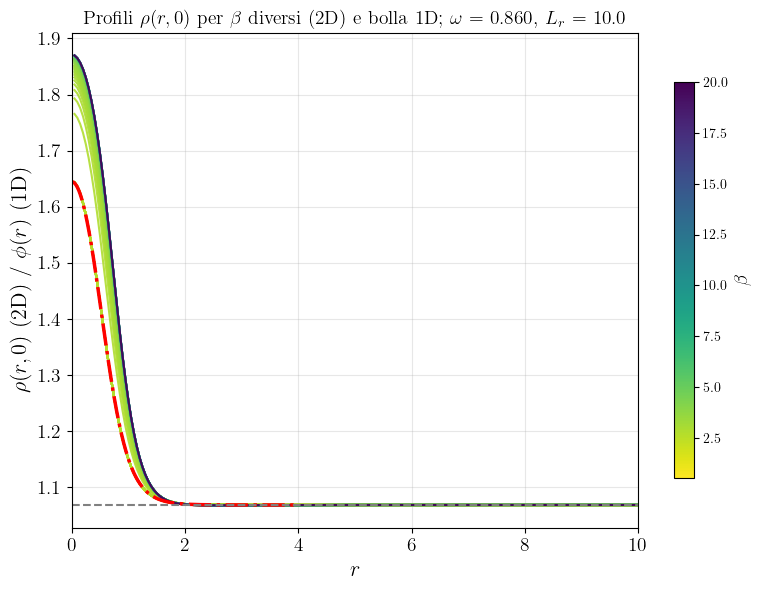

In [ ]:
# Plot ρ(r,0) per ogni β dello scan 2D e bolla 1D (stesso ω e ρ_false)
from Bubble_finder.bounce_1d import solve_bounce
import matplotlib as mpl

# Bolla 1D con stesso ω e ρ_false dello β-scan
r_1d_beta, phi_1d_beta, _, _, _ = solve_bounce(
    PHI0, V1, V2, OMEGA_beta, d=3, r0=1e-10, rmax=Lr_beta, max_iter=150, verbose=False,
)
r_1d_beta = np.asarray(r_1d_beta, float)
phi_1d_beta = np.asarray(phi_1d_beta, float)

# Ordina per β crescente così iterazione 0 = β più basso, visibili tutti
valid_beta = sorted(
    [r for r in beta_scan_results if r["status"] == "OK" and r.get("r_2D") is not None],
    key=lambda r: r["beta"],
)
betas_vals = [rec["beta"] for rec in valid_beta]
norm = mpl.colors.Normalize(vmin=min(betas_vals), vmax=max(betas_vals))
cmap = plt.cm.viridis_r

fig_rho, ax_rho = plt.subplots(figsize=(8, 6))
for rec in valid_beta:
    ax_rho.plot(rec["r_2D"], rec["rho_tau0_2D"], "-", color=cmap(norm(rec["beta"])), lw=1.5, alpha=0.9)
# Bolla 1D
ax_rho.plot(r_1d_beta, phi_1d_beta, "r-.", lw=2.5)
ax_rho.axhline(float(rho_false_beta), color="gray", ls="--", lw=1.5)
ax_rho.set_xlabel(r"$r$", fontsize=16)
ax_rho.set_ylabel(r"$\rho(r,0)$ (2D) / $\phi(r)$ (1D)", fontsize=16)
ax_rho.set_title(rf"Profili $\rho(r,0)$ per $\beta$ diversi (2D) e bolla 1D; $\omega$ = {OMEGA_beta:.3f}, $L_r$ = {Lr_beta}", fontsize=14)
ax_rho.set_xlim(0, Lr_beta)
# ylim per includere tutti i profili (2D e 1D)
y_all = np.concatenate([rec["rho_tau0_2D"] for rec in valid_beta] + [phi_1d_beta])
y_min, y_max = float(np.nanmin(y_all)), float(np.nanmax(y_all))
margin = 0.05 * (y_max - y_min) if y_max > y_min else 0.1
ax_rho.set_ylim(y_min - margin, y_max + margin)
ax_rho.grid(True, alpha=0.3)
ax_rho.tick_params(axis="both", labelsize=14)
# Colorbar = valore di β
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig_rho.colorbar(sm, ax=ax_rho, shrink=0.8)
cbar.set_label(r"$\beta$", fontsize=14)
plt.tight_layout()
fig_rho.savefig(FIGURES_DIR / "rho_r_tau0_beta_scan_vs_1d.png", dpi=150, bbox_inches="tight")
plt.show()

Iterazione 30 (indice 25) → β = 2.7500000000000027


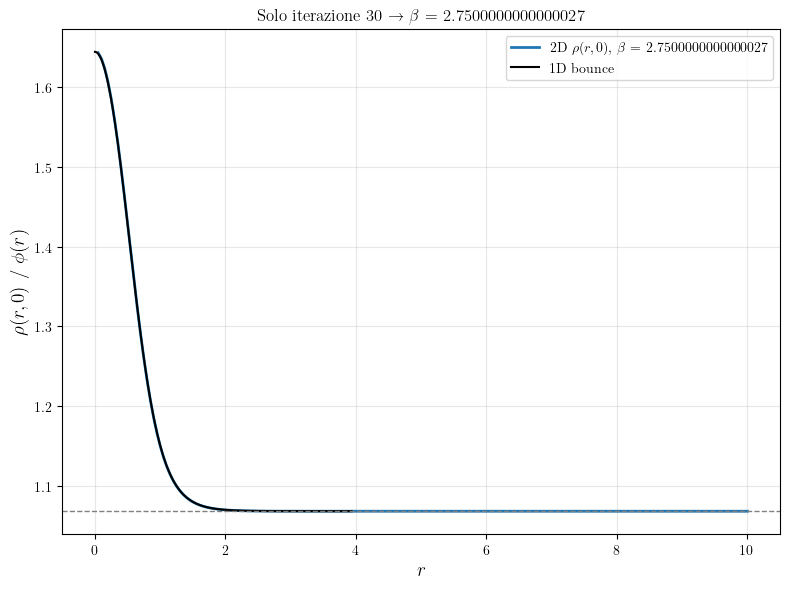

In [ ]:
# Plot solo iterazione 30 (per controllo: quale beta corrisponde) — non salvato
idx_30 = 25  # indice 0-based: iterazione 30
if len(valid_beta) > idx_30:
    rec_30 = valid_beta[idx_30]
    beta_30 = rec_30["beta"]
    print(f"Iterazione 30 (indice {idx_30}) → β = {beta_30}")
    fig_30, ax_30 = plt.subplots(figsize=(8, 6))
    ax_30.plot(rec_30["r_2D"], rec_30["rho_tau0_2D"], "-", color="C0", lw=2, label=rf"2D $\rho(r,0)$, $\beta$ = {beta_30}")
    ax_30.plot(r_1d_beta, phi_1d_beta, "k-", lw=1.5, label="1D bounce")
    ax_30.axhline(float(rho_false_beta), color="gray", ls="--", lw=1)
    ax_30.set_xlabel(r"$r$", fontsize=14)
    ax_30.set_ylabel(r"$\rho(r,0)$ / $\phi(r)$", fontsize=14)
    ax_30.set_title(rf"Solo iterazione 30 → $\beta$ = {beta_30}")
    ax_30.legend()
    ax_30.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"Solo {len(valid_beta)} iterazioni disponibili; non esiste iterazione 30.")

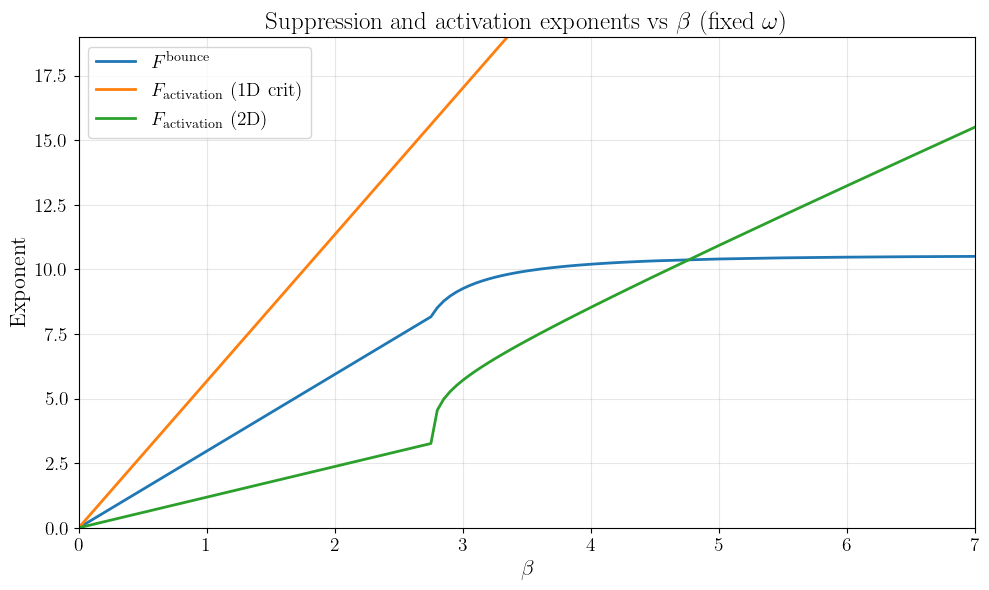

In [ ]:
# Plot F^bounce and F_activation vs β (single figure)
# Use only β > 0 from scan, then prepend (0, 0) so all curves start at the origin
betas = [0] + [r["beta"] for r in beta_scan_results if r["beta"] > 0]
F_bounce_vals = [0] + [r["F_bounce"] for r in beta_scan_results if r["beta"] > 0]
F_act_1d = [0] + [r["F_activation_1d"] for r in beta_scan_results if r["beta"] > 0]
F_act_2D = [0] + [r["F_activation_2D"] for r in beta_scan_results if r["beta"] > 0]
# Sort by β so the curve runs from 0 upward
sorted_tuples = sorted(zip(betas, F_bounce_vals, F_act_1d, F_act_2D))
betas = [t[0] for t in sorted_tuples]
F_bounce_vals = [t[1] for t in sorted_tuples]
F_act_1d = [t[2] for t in sorted_tuples]
F_act_2D = [t[3] for t in sorted_tuples]

fig_b, ax_b = plt.subplots(figsize=(10, 6))
ax_b.plot(betas, F_bounce_vals, "-", color="C0", label=r"$F^{\mathrm{bounce}}$", lw=2)
ax_b.plot(betas, F_act_1d, "-", color="C1", label=r"$F_{\mathrm{activation}}$ (1D crit)", markersize=8, lw=2)
ax_b.plot(betas, F_act_2D, "-", color="C2", label=r"$F_{\mathrm{activation}}$ (2D)", markersize=8, lw=2)
ax_b.set_xlabel(r"$\beta$", fontsize=16)
ax_b.set_ylabel(r"Exponent", fontsize=16)
ax_b.set_title(r"Suppression and activation exponents vs $\beta$ (fixed $\omega$)", fontsize=18)
ax_b.legend(fontsize=14)
ax_b.grid(True, alpha=0.3)
ax_b.set_ylim(0, 19)
ax_b.set_xlim(0, 7)
ax_b.tick_params(axis="both", labelsize=14)
plt.tight_layout()
fig_b.savefig(FIGURES_DIR / "F_bounce_F_activation_vs_beta.png", dpi=150, bbox_inches="tight")
plt.show()

## Omega scan at fixed β=15, Lr=10

Scan over ω from ω_max×0.95 down to ω_min=0 in steps of 0.05. At each step use the previous step's solution as ansatz and the previous η* as η_start. Store F^bounce (2D), Q, S_E^2D, S_E^hom, η*, E_M^2D, E_M^hom, and charge density Q/V. Then plot F^bounce vs Q/V with vertical lines at ω_max and ω_min and the analytical S₀ (constant).

In [ ]:
# Omega-scan parameters: fixed β=15, Lr=10
beta_omega_scan = 25.0
Lr_omega_scan = 15.0
Nr_omega = 250
Ntau_omega = 200
omega_min_scan = 0.0
d_omega_scan = 0.025
max_newton_omega = 35
d_eta_omega = 0.05
max_bracket_omega = 80
tol_Q_omega = 1e-6

# Get omega_max (run the cell that defines has_barrier and computes omega_max first, or set manually)
try:
    omega_max_scan = float(omega_max)
except NameError:
    omega_max_scan = 0.999  # fallback if omega_max not in memory

# Grid: from omega_max*0.99 down to omega_min in steps of 0.05
omega_start = omega_max_scan * 0.99
omega_grid_scan = []
w = omega_start
while w >= omega_min_scan:
    omega_grid_scan.append(w)
    w -= d_omega_scan
    if w < omega_min_scan and abs(w - omega_min_scan) > 1e-10:
        omega_grid_scan.append(omega_min_scan)
omega_grid_scan = np.array(omega_grid_scan)
print(f"Omega scan: β={beta_omega_scan}, Lr={Lr_omega_scan}, ω ∈ [0, {omega_max_scan:.4f}], grid from {omega_grid_scan[0]:.4f} to {omega_grid_scan[-1]:.4f}, {len(omega_grid_scan)} points")

Omega scan: β=25.0, Lr=15.0, ω ∈ [0, 0.9448], grid from 0.9354 to 0.0000, 39 points


In [ ]:
# Omega-scan driver: for each ω → solver, ansatz (gated or warm start), Newton, η-scan, save F^bounce and energies
from scipy.optimize import brentq
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver
from Bubble_finder.ansatz_bubble import AnsatzParams, tau_gate
from Bubble_finder.observables_1d import Q_homogeneous_ball, compute_energy_physical_1d_volume_corrected
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d
from Bubble_finder.rate_exponent import (
    compute_euclidean_action_full, compute_homogeneous_action, volume_from_grid,
    compute_suppression_exponent_bubble, make_V_of_s_from_U,
)
from Q_ball_finder.notebook_utils import resample_complex_field

def solve_at_eta_om(solver, eta, x0, verbose=False):
    solver.settings.eta0 = float(eta)
    solver.eta0 = float(eta)
    sol = solver.solve(x0, verbose=verbose, verbose_success_block=False, store_iteration_history=False)
    return float(sol.Q_tau0.real), sol

def eta_scan_omega(solver, eta_start, x_seed, Q_target, E_hom_ref, d_eta=0.05, max_steps=80, tol_Q=1e-6, verbose=True):
    tol_Q = tol_Q * max(1.0, abs(Q_target))
    E_Q_ref = E_hom_ref if (E_hom_ref and abs(E_hom_ref) > 1e-30) else 1.0
    eta_curr = eta_start
    Q_curr, sol_curr = solve_at_eta_om(solver, eta_curr, x_seed, verbose=False)
    x_seed = sol_curr.x.copy()
    E_curr = float(sol_curr.E_tau0)
    ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
    if abs(Q_curr - Q_target) < tol_Q:
        if verbose:
            print(f"[eta-scan] eta* = {eta_curr:.6f}, Q = {Q_curr:.6e}, target = {Q_target:.6e}")
        return eta_curr, sol_curr, x_seed
    eta_prev, Q_prev = eta_curr, Q_curr
    for _ in range(max_steps):
        if Q_curr < Q_target:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr += d_eta
        else:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr -= d_eta
        Q_curr, sol_curr = solve_at_eta_om(solver, eta_curr, x_seed, verbose=False)
        x_seed = sol_curr.x.copy()
        ratioQ = (Q_curr / Q_target) if Q_target and abs(Q_target) > 1e-30 else 0.0
        if verbose:
            print(f"[eta-scan] try eta = {eta_curr:.6f}, Q = {Q_curr:.6e}, ratioQ = {ratioQ:.6f}")
        if (Q_prev - Q_target) * (Q_curr - Q_target) <= 0:
            break
    else:
        raise RuntimeError("eta scan did not cross Q_target")
    eta_lo, eta_hi = (eta_curr, eta_prev) if Q_prev < Q_target else (eta_prev, eta_curr)
    def f_eta(eta_f):
        q, s = solve_at_eta_om(solver, eta_f, x_seed, verbose=False)
        return q - Q_target
    eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
    _, sol_final = solve_at_eta_om(solver, eta_star, x_seed, verbose=False)
    if verbose:
        print(f"[eta-scan] eta* = {eta_star:.6f}, Q = {float(sol_final.Q_tau0.real):.6e}")
    return eta_star, sol_final, x_seed

V_omega_scan = (4.0 / 3.0) * np.pi * (Lr_omega_scan**3)
params_gated_omega = AnsatzParams(eps=1.0, k=1, phase=0.0, amp=1.0, tau_gate_frac=0.25, tau_gate_center_frac=1, r_window_frac=0.15)

omega_scan_results = []
sol_prev_om = None
r_prev_om = None
tau_prev_om = None
eta_star_prev_om = 0.0
verbose_omega = True

for idx_om, om in enumerate(omega_grid_scan):
    rec = {"omega": om, "F_bounce": np.nan, "Q": np.nan, "rho_Q": np.nan, "S_E_2D": np.nan, "S_E_hom": np.nan,
           "eta_star": np.nan, "E_M_2D": np.nan, "E_M_hom": np.nan, "status": "OK"}
    try:
        rho_false_om, _ = vacua_of_Omega(PHI0, V1, V2, om)
        Q_target_om = float(Q_homogeneous_ball(om, rho_false_om, Lr_omega_scan))
        E_hom_om = float(homogeneous_energy_2d(om, rho_false_om, Lr_omega_scan, U))
        E_M_hom_om = float(homogeneous_E_M_2d(om, rho_false_om, Lr_omega_scan, U))
        settings_om = Bubble2DSettings(
            Nr=Nr_omega, Ntau=Ntau_omega, Lr=Lr_omega_scan, beta=beta_omega_scan,
            omega_ref=om, rho0=float(rho_false_om), rho0_bracket=(V1 * 0.8, V2 + 0.2),
            newton_tol=1e-8, newton_max_iter=max_newton_omega, tau_bc="twisted",
        )
        solver_om = Bubble2DSolver(settings_om, U, dU, d2U)
        r_om = np.asarray(solver_om.grid.r).flatten()
        tau_om = np.asarray(solver_om.grid.tau).flatten()
        T_om = beta_omega_scan / 2.0
        r_1d_om, phi_1d_om, _, _, _ = solve_bounce(PHI0, V1, V2, om, d=3, r0=1e-10, rmax=Lr_omega_scan, max_iter=150, verbose=False)
        r_1d_om = np.asarray(r_1d_om, float)
        phi_1d_om = np.asarray(phi_1d_om, float)
        if sol_prev_om is not None and r_prev_om is not None and tau_prev_om is not None:
            y_res_om = resample_complex_field(sol_prev_om.y, r_prev_om, tau_prev_om, r_om, tau_om, clamp_tau_to_plateau=True)
            ybar_res_om = resample_complex_field(sol_prev_om.ybar, r_prev_om, tau_prev_om, r_om, tau_om, clamp_tau_to_plateau=True)
            x0_om = solver_om.pack(y_res_om, ybar_res_om)
            eta_start_om = eta_star_prev_om
            if verbose_omega:
                print(f"[ω-scan] ω={om:.4f} ansatz from previous step, eta_start={eta_start_om:.6f}")
        else:
            phi_on_r_om = np.interp(r_om, r_1d_om, phi_1d_om, left=phi_1d_om[0], right=phi_1d_om[-1])
            y_slice_om = r_om * (phi_on_r_om - solver_om.rho0)
            g_tau_om = tau_gate(tau_om, T_om, params_gated_omega.tau_gate_frac, center_frac=params_gated_omega.tau_gate_center_frac)
            y_gated_om = params_gated_omega.amp * np.outer(y_slice_om, g_tau_om).astype(complex)
            ybar_gated_om = y_gated_om.copy()
            x0_om = solver_om.pack(y_gated_om, ybar_gated_om)
            eta_start_om = 0.0
        sol_newt_om = solver_om.solve(x0_om, verbose=verbose_omega, verbose_success_block=False, store_iteration_history=False)
        if not getattr(sol_newt_om, "success", True):
            rec["status"] = "FAIL_NEWTON"
            omega_scan_results.append(rec)
            continue
        x_seed_om = sol_newt_om.x.copy()
        eta_star_om, sol_eta_om, _ = eta_scan_omega(
            solver_om, eta_start_om, x_seed_om, Q_target_om, E_hom_om,
            d_eta=d_eta_omega, max_steps=max_bracket_omega, tol_Q=tol_Q_omega, verbose=verbose_omega,
        )
        obs_om = getattr(sol_eta_om, "observables_ghost", None) or {}
        V_of_s_om = make_V_of_s_from_U(U)
        S_E_2D_om = float(compute_euclidean_action_full(sol_eta_om.y, sol_eta_om.ybar, solver_om.grid, om, eta_star_om, float(rho_false_om), V_of_s_om))
        S_E_hom_om = float(compute_homogeneous_action(beta_omega_scan, V_omega_scan, om, float(rho_false_om), V_of_s_om))
        Q_om = float(sol_eta_om.Q_tau0.real)
        rec["F_bounce"] = compute_suppression_exponent_bubble(S_E_2D_om, S_E_hom_om, eta_star_om, Q_om)
        rec["Q"] = Q_om
        rec["rho_Q"] = Q_om / V_omega_scan
        rec["S_E_2D"] = S_E_2D_om
        rec["S_E_hom"] = S_E_hom_om
        rec["eta_star"] = eta_star_om
        rec["E_M_2D"] = float(obs_om.get("E_M", getattr(sol_eta_om, "E_tau0", np.nan)))
        rec["E_M_hom"] = E_M_hom_om
        sol_prev_om = sol_eta_om
        r_prev_om = r_om.copy()
        tau_prev_om = tau_om.copy()
        eta_star_prev_om = eta_star_om
    except Exception as e:
        rec["status"] = "FAIL"
        if verbose_omega:
            print(f"[ω-scan] ω={om:.4f} exception: {e}")
    omega_scan_results.append(rec)
    if verbose_omega and rec["status"] == "OK":
        print(f"[ω-scan] ω={om:.4f}  F_bounce={rec['F_bounce']:.6f}  rho_Q={rec['rho_Q']:.6f}")
print("Omega-scan done. OK:", sum(1 for r in omega_scan_results if r["status"] == "OK"))

[vacua_of_Omega] ω=0.935386
  phi_false=1.10457494371  Ω_false=-1.43925159791  dΩ=1.27e-08  (ω²-W)=-5.77e-09  Ω''=4.629e+00
  phi_true =2.10949600037  Ω_true =-5.21937995176  dΩ=2.05e-07  (ω²-W)=-4.86e-08  Ω''=4.463e+01
[Newton-explicit] iter=01, ||F||=4.547e+00, rhoQ=1.141435e+00, rhoE=-6.961302e-01, rho_Q/rho_Q_ref=1.0002, rho_E/rho_E_ref=1.0005
[Newton-explicit] iter=02, ||F||=2.849e+00, rhoQ=1.141279e+00, rhoE=-6.958623e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0001
[Newton-explicit] iter=03, ||F||=2.085e-01, rhoQ=1.141272e+00, rhoE=-6.958478e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0001
[Newton-explicit] iter=04, ||F||=2.345e-03, rhoQ=1.141271e+00, rhoE=-6.958468e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0001
[Newton-explicit] iter=05, ||F||=1.628e-07, rhoQ=1.141271e+00, rhoE=-6.958468e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0001
[Newton-explicit] iter=06, ||F||=4.072e-12, rhoQ=1.141271e+00, rhoE=-6.958468e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0001


KeyboardInterrupt: 

[vacua_of_Omega] ω=0
  phi_false=1.00000001839  Ω_false=-0.5  dΩ=1.67e-06  (ω²-W)=-8.35e-07  Ω''=9.636e+05
  phi_true =1.99986461045  Ω_true =-1.50000001833  dΩ=-4.20e-08  (ω²-W)=1.05e-08  Ω''=4.001e+00
[vacua_of_Omega] ω=0.944834
  phi_false=1.11507856643  Ω_false=-1.46111688028  dΩ=-1.37e-09  (ω²-W)=6.13e-10  Ω''=2.897e+00
  phi_true =2.11117002967  Ω_true =-5.29849633642  dΩ=1.86e-07  (ω²-W)=-4.41e-08  Ω''=4.495e+01
[vacua_of_Omega] ω=0
  phi_false=1.00000001839  Ω_false=-0.5  dΩ=1.67e-06  (ω²-W)=-8.35e-07  Ω''=9.636e+05
  phi_true =1.99986461045  Ω_true =-1.50000001833  dΩ=-4.20e-08  (ω²-W)=1.05e-08  Ω''=4.001e+00


/tmp/ipykernel_30781/1307723873.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  S_E_1d_omega0 = float(4.0 * np.pi * np.trapz(integrand_SE, r_1d_w0))


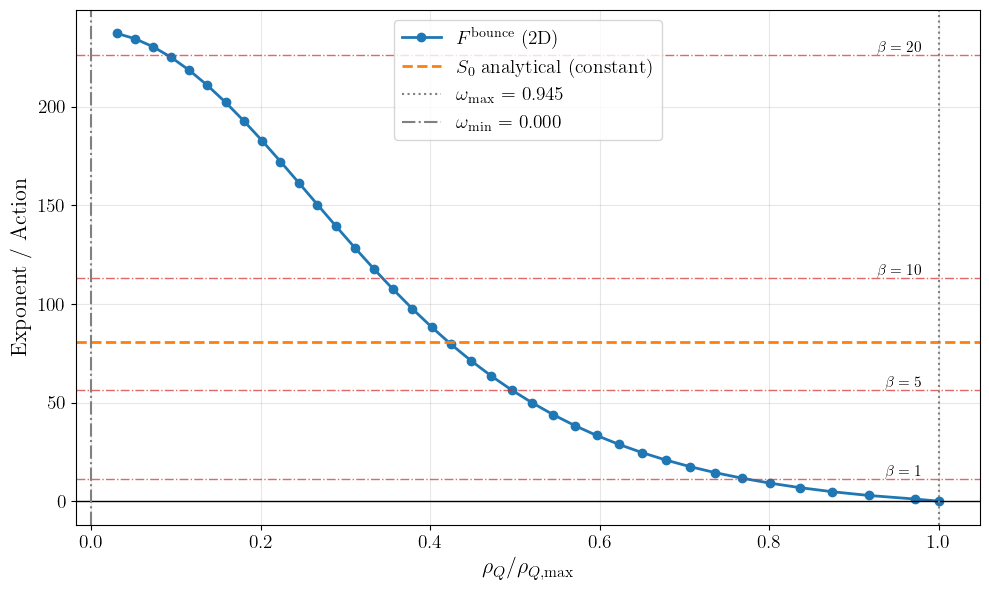

In [ ]:
# Plot F^bounce (2D) vs charge density Q/V; vertical lines at ω_max and ω_min; S₀ analytical (constant)
from scipy.special import spence

def S0_analytical_plot(phi0):
    """S₀ = -π²/3 [φ₀ - 1 + Li₂((φ₀-1)/(φ₀-2))]; d=4, Q=0."""
    term = (phi0 - 1) / (phi0 - 2)
    Li2_val = spence(1 - term)
    return -np.pi**2 / 3.0 * (phi0 - 1 + Li2_val)

valid = [r for r in omega_scan_results if r["status"] == "OK"]
rho_Q_vals = [r["rho_Q"] for r in valid]
F_bounce_vals_om = [r["F_bounce"] for r in valid]
omega_vals = [r["omega"] for r in valid]

S0_const = S0_analytical_plot(PHI0)
# S_E of 1D bounce at ω=0: S_E = 4π ∫ r² [ (1/2)(dφ/dr)² + V(φ) ] dr
from Bubble_finder.bounce_1d import solve_bounce
r_1d_w0, phi_1d_w0, _, _, _ = solve_bounce(PHI0, V1, V2, 0.0, d=3, r0=1e-10, rmax=Lr_omega_scan, max_iter=150, verbose=False)
r_1d_w0 = np.asarray(r_1d_w0, float)
phi_1d_w0 = np.asarray(phi_1d_w0, float)
rho_false_w0, _ = vacua_of_Omega(PHI0, V1, V2, 0.0)
V_false_w0 = float(np.asarray(U(np.array([float(rho_false_w0)]))).flat[0])
dphi_dr = np.gradient(phi_1d_w0, r_1d_w0)
V_at_phi = np.asarray(U(phi_1d_w0)).flatten()
integrand_SE = r_1d_w0**2 * (0.5 * dphi_dr**2 + V_at_phi - V_false_w0)
S_E_1d_omega0 = float(4.0 * np.pi * np.trapz(integrand_SE, r_1d_w0))
# ρ_Q at ω_max and ω_min (physical interval) for vertical lines
rho_false_max, _ = vacua_of_Omega(PHI0, V1, V2, omega_max_scan)
rho_false_min, _ = vacua_of_Omega(PHI0, V1, V2, omega_min_scan)
Q_at_omega_max = float(Q_homogeneous_ball(omega_max_scan, rho_false_max, Lr_omega_scan))
Q_at_omega_min = float(Q_homogeneous_ball(omega_min_scan, rho_false_min, Lr_omega_scan))
rho_Q_at_omega_max = Q_at_omega_max / V_omega_scan
rho_Q_at_omega_min = Q_at_omega_min / V_omega_scan
rho_Q_max = rho_Q_at_omega_max  # riferimento fisico: riscalo tutti i punti rispetto a questo
rho_Q_norm = [q / rho_Q_max for q in rho_Q_vals]
rho_Q_at_omega_max_norm = 1.0
rho_Q_at_omega_min_norm = rho_Q_at_omega_min / rho_Q_max

fig_om, ax_om = plt.subplots(figsize=(10, 6))
rho_Q_plot = [1.0] + rho_Q_norm
F_bounce_plot = [0.0] + F_bounce_vals_om
ax_om.plot(rho_Q_plot, F_bounce_plot, "o-", color="C0", label=r"$F^{\mathrm{bounce}}$ (2D)", markersize=6, lw=2)
ax_om.axhline(0, color="black", lw=1)
ax_om.axhline(S0_const, color="C1", ls="--", lw=2, label=rf"$S_0$ analytical (constant)")
for b in [20, 10, 5, 1]:
    ax_om.axhline(b * S_E_1d_omega0, color="C3", ls="-.", lw=1, alpha=0.7)
    ax_om.text(0.98, b * S_E_1d_omega0, rf"$\beta={b}$", ha="right", va="bottom", fontsize=11)
ax_om.axvline(rho_Q_at_omega_max_norm, color="gray", ls=":", lw=1.5, label=rf"$\omega_{{\max}}$ = {omega_max_scan:.3f}")
ax_om.axvline(rho_Q_at_omega_min_norm, color="gray", ls="-.", lw=1.5, label=rf"$\omega_{{\min}}$ = {omega_min_scan:.3f}")
ax_om.set_xlabel(r"$\rho_Q/\rho_{Q,\max}$", fontsize=16)
ax_om.set_ylabel(r"Exponent / Action", fontsize=16)
#ax_om.set_title(rf"$F^{{\mathrm{{bounce}}}}$ (2D) vs $\rho_Q/\rho_{{Q,\max}}$ at $\beta={beta_omega_scan}$, $L_r={Lr_omega_scan}$; $S_0$ analytical", fontsize=18)
ax_om.legend(fontsize=14)
ax_om.grid(True, alpha=0.3)
ax_om.tick_params(axis="both", labelsize=14)
plt.tight_layout()
fig_om.savefig(FIGURES_DIR / "F_bounce_vs_rho_Q_norm.png", dpi=150, bbox_inches="tight")
plt.show()